# 로컬 저장 위치

예측과 실제값 비교 기록은 현재 런타임의 `samsung_direction_outputs/` 폴더에 저장합니다. Google Drive 연결과 인증은 사용하지 않습니다.

Colab 기본 경로는 `/content/samsung_direction_outputs/`입니다. 런타임이 종료·삭제되면 파일이 사라질 수 있으므로 실행 후 왼쪽 파일 패널에서 `latest_outputs.zip`을 다운로드하세요.

다음 런타임에서 기록을 이어 쓰려면 첫 셀 실행 후, 보관한 ZIP의 `forecast_log.csv`를 같은 저장 폴더에 업로드하고 나머지 셀을 실행하세요. KOSIS CSV를 사용하는 경우 `macro_inputs/`에도 다시 업로드해야 합니다.


In [1]:
# 결과는 현재 런타임의 로컬 폴더에 저장합니다.
# json은 아래 github_get이 쓴다. 이 셀에서 import하지 않으면 첫 번째 종목만
# NameError로 원장 동기화가 꺼지고(두 번째 종목은 뒤 셀이 올려놓은 전역을 써서 통과),
# 그 종목의 보고서만 조용히 발행되지 않는다.
import json
import os
from pathlib import Path

STORAGE_PATH_OVERRIDE = os.environ.get("PREDICT_STOCK_STORAGE")
# ---- 예측 대상 종목 --------------------------------------------------------
# "samsung"(005930) 또는 "sk_hynix"(000660). 종목별로 원장·보고서가 따로 쌓인다.
# 주의: 해외 피처가 반도체 대형주에 맞춰져 있다(SOX·Micron·Nvidia·TSMC). 다른 업종
# 종목을 넣으면 코드는 돌지만 그 종목과 무관한 정보로 예측하게 된다.
# 여기 적은 순서대로 모두 실행한다. 한 종목만 원하면 하나만 남긴다.
# 자동 실행(GitHub Actions)은 프로세스마다 한 종목씩 돌린다. 아래 '이어서 실행'
# 셀은 IPython 실행 히스토리에 기대므로 Jupyter 밖에서는 동작하지 않기 때문이다.
# 환경변수가 없으면 Colab에서 쓰던 기본값 그대로다.
# 환경변수가 비어 있는 경우(Actions에서 입력을 비우면 빈 문자열이 온다)도
# 미설정과 똑같이 기본값으로 떨어뜨린다. get(..., 기본값)만 쓰면 빈 문자열이
# 그대로 통과해 목록이 비고, 바로 아래 RUN_TARGETS[0]에서 IndexError가 난다.
RUN_TARGETS = [t.strip() for t in
               ((os.environ.get("PREDICT_STOCK_TARGETS") or "").strip()
                or "samsung,sk_hynix").split(",")
               if t.strip()]
TARGET = RUN_TARGETS[0]
TARGET_SPEC = {
    "samsung":  {"ticker": "005930.KS", "name": "삼성전자",   "peer": "000660.KS", "gdr": "SMSN.IL"},
    "sk_hynix": {"ticker": "000660.KS", "name": "SK하이닉스", "peer": "005930.KS", "gdr": None},
}[TARGET]
TARGET_NAME = TARGET_SPEC["name"]
print(f"예측 대상: {TARGET_NAME} ({TARGET_SPEC['ticker']})")

STORAGE_ROOT = Path(STORAGE_PATH_OVERRIDE) if STORAGE_PATH_OVERRIDE else Path.cwd() / f"{TARGET}_outputs"
STORAGE_ROOT.mkdir(parents=True, exist_ok=True)
DATA_CACHE_DIR = str(STORAGE_ROOT / "data_cache")
print("로컬 저장 위치:", STORAGE_ROOT)
print("Colab 런타임이 삭제되기 전에 latest_outputs.zip을 다운로드하세요.")


# ---- 예측 원장을 GitHub에서 받아오기 ------------------------------------------
# Colab 런타임은 삭제되면 사라진다. 원장을 저장소에 두면 실행 기록이 계속 쌓인다.
# 토큰이 없으면 조용히 건너뛰고 런타임 로컬에만 저장한다(전체 실행은 멈추지 않는다).
GITHUB_REPO = "namyikim/predict_stock"   # 원장을 보관할 저장소
GITHUB_BRANCH = "main"
GITHUB_LEDGER_DIR = f"forecast_history/{TARGET}"   # 종목별 폴더
GITHUB_PAGES_DIR = f"docs/{TARGET}"                # 종목별 보고서 폴더
LEDGER_FILES = ["forecast_log.csv", "daily_forecast_comparison.csv",
                "forecast_accuracy_summary.csv",
                # 그날 예측을 무엇이 밀었는지. 보고서에는 띄우지 않고 /lab/ 에서만 본다.
                "attribution.csv"]
# 월별 지표의 '마지막으로 조회에 성공한' 사본. KOSIS는 해외 IP에서 연결 자체가 막히는 일이 있어
# (2026-09-07 URLError로 일일 보고서 두 번 실패) 조회 실패 시 이 값을 쓴다. 종목과 무관하게 공용이다.
GITHUB_MACRO_DIR = "macro_history"
MACRO_FALLBACK_FILES = ["leading_cycle.csv", "semiconductor_exports.csv",
                        "news_sentiment.csv",
                        f"investor_flows_{TARGET_SPEC['ticker'].split('.')[0]}.csv"]

# ---- 예측을 원장에 기록할 것인가 ------------------------------------------------
# 원장은 날짜·모델·설정별로 '최초 사전 예측' 하나만 집계한다. 장 마감 후(15:40 KST 이후) 실행은
# 다음 거래일 예측을 만들 수 있지만, 그날 밤 미국 장 정보가 아직 없어 아침 06:30 실행보다 정보가
# 적다. 그대로 기록하면 먼저 들어간 오후 예측이 채택되고 정작 좋은 아침 예측이 중복으로 버려진다.
# 그래서 오후 실행은 보고서와 채점만 갱신하고 새 예측은 기록하지 않는다.
RECORD_FORECAST = (os.environ.get("PREDICT_STOCK_RECORD_FORECAST", "true").strip().lower()
                   not in ("0", "false", "no", "off"))

# 위 주석대로 하려면 시각 조건이 필요하다. 스위치만 두었더니 예약 실행이 시각과 무관하게 모두
# 기록해서, 3시간 회차 중 한국 저녁 회차(18:22·21:22 KST)가 다음 거래일 예측을 먼저 박아 버렸다.
# 2026-09-09~09-14 예측 네 건이 모두 저녁에 기록됐고, 정작 정보가 많은 아침 06:22 회차는 게이트에
# 걸려 건너뛰어졌다. 이 모델의 예측력은 거의 전부 밤사이 미국 시장에서 오는데(갭 AUC 0.80),
# 한국 저녁은 미국 장이 열리기도 전이다. 즉 가장 중요한 정보를 뺀 예측이 원장에 남았다.
#
# 그래서 '미국 장이 끝난 뒤 ~ 한국 개장 전'에 만든 예측만 기록한다. 그 밖의 실행은 보고서와
# 채점만 갱신한다. US 정규장 마감은 06:00 KST(서머타임 05:00)이므로 06:00 을 하한으로 둔다.
RECORD_WINDOW_KST = (6, 9)          # [06:00, 09:00) — 미국 장 마감 후, 한국 개장 전
EVENING_WINDOW_KST = (17, 23)       # [17:00, 23:00) — 한국 장 마감 후, 미국 장 시작 전
# 이 셀은 pandas import 보다 앞에 있으므로 표준 라이브러리만 쓴다.
from datetime import datetime as _dt, timedelta as _td, timezone as _tz
_now_kst = _dt.now(_tz(_td(hours=9)))
_in_record_window = RECORD_WINDOW_KST[0] <= _now_kst.hour < RECORD_WINDOW_KST[1]
_in_evening_window = EVENING_WINDOW_KST[0] <= _now_kst.hour < EVENING_WINDOW_KST[1]

# 저녁 실행은 대표 모델 이름으로 기록하지 않는다. 대신 'Candidate evening forecast' 로 나란히
# 남겨, 같은 예측일을 두 시점에서 예측한 것을 각각 채점한다. 그러면 '밤사이 미국 시장 정보가
# 실제로 얼마나 기여하나'를 적중률로 잴 수 있다(이 저장소가 말해 온 갭 AUC 0.80 의 직접 검증).
# 덮어쓰지 않는 이유: 원장은 날짜별 최초 사전 예측만 집계한다. 나중에 갱신하면 '결과를 보고
# 예측을 고른 것'과 구별할 수 없어 채점이 의미를 잃는다.
EVENING_MODEL = "Candidate evening forecast"
RECORD_EVENING_ONLY = False
if RECORD_FORECAST and not _in_record_window:
    if _in_evening_window:
        RECORD_EVENING_ONLY = True
        print(f"ℹ️ {_now_kst:%H:%M} KST — 저녁 실행입니다. 대표 모델로는 기록하지 않고 "
              f"'{EVENING_MODEL}' 로만 남깁니다(밤사이 미국 시장 정보가 아직 없습니다).")
    else:
        RECORD_FORECAST = False
        print(f"ℹ️ {_now_kst:%H:%M} KST — 예측을 원장에 기록하지 않습니다. 사전 예측은 "
              f"{RECORD_WINDOW_KST[0]:02d}:00~{RECORD_WINDOW_KST[1]:02d}:00 KST 실행만 기록합니다. "
              "보고서와 채점은 갱신합니다.")

# ---- 실행 환경 ---------------------------------------------------------------
# 아래 발행 스위치가 이 값을 쓰므로 여기서 정한다(셀 4의 VERSIONS_HASH도 함께 쓴다).
if os.environ.get("PREDICT_STOCK_RUNTIME"):
    RUNTIME = os.environ["PREDICT_STOCK_RUNTIME"].strip()
elif os.environ.get("GITHUB_ACTIONS") == "true":
    RUNTIME = "github-actions"
else:
    try:
        import google.colab  # noqa: F401
        RUNTIME = "colab"
    except Exception:
        RUNTIME = "local"

# ---- 발행 스위치 -------------------------------------------------------------
# 발행은 한 곳에서만 한다. 양쪽에서 올리면 라이브러리 버전이 다른 예측이 한 원장에
# 쌓여 정확도 이력의 계보가 섞인다. 원장의 runtime/versions_hash로 구분은 되지만
# 애초에 섞지 않는 편이 낫다. 기본값은 자동 실행에서만 발행이고, Colab은 탐색용이다.
# Colab에서 그때만 올리고 싶으면 PREDICT_STOCK_PUBLISH=true 로 실행한다.
_publish = os.environ.get("PREDICT_STOCK_PUBLISH", "").strip().lower()
PUBLISH_SKIP_REASON = ""
if _publish in ("1", "true", "yes", "on"):
    SYNC_LEDGER_TO_GITHUB = True
elif _publish in ("0", "false", "no", "off"):
    SYNC_LEDGER_TO_GITHUB = False
    PUBLISH_SKIP_REASON = "PREDICT_STOCK_PUBLISH=false"
elif RUNTIME == "github-actions":
    SYNC_LEDGER_TO_GITHUB = True
else:
    SYNC_LEDGER_TO_GITHUB = False
    PUBLISH_SKIP_REASON = (f"{RUNTIME} 실행은 기본적으로 발행하지 않습니다"
                           " — 올리려면 PREDICT_STOCK_PUBLISH=true")
if PUBLISH_SKIP_REASON:
    print("ℹ️ 이번 실행은 저장소에 발행하지 않습니다 —", PUBLISH_SKIP_REASON)
    print("   결과는 런타임 로컬에만 저장됩니다.")

# 종목별 발행 결과를 모아 마지막에 한 번에 보여준다. 출력이 길어 중간 경고를
# 놓치기 쉬운데, 한 종목이 조용히 빠져도 알아채지 못하면 그 보고서만 옛날 것으로
# 남는다. 첫 종목에서만 비운다 — 셀 45의 재실행은 TARGET을 다른 값으로 바꾸므로
# 이 조건에서 자연히 걸러진다.
if TARGET == RUN_TARGETS[0]:
    PUBLISH_STATUS = {}
    PUBLISH_FAILURES = []


# ---- 보고서 조회수 카운터 ------------------------------------------------------
# GitHub Pages에는 서버가 없어 접속을 셀 수 없다. counter/worker.js 를 Cloudflare에
# 배포하고 그 주소를 여기 적으면 보고서 하단에 조회수가 표시된다.
# 빈 문자열("")로 두면 카운터 코드가 아예 들어가지 않는다(보고서는 정상).
COUNTER_ENDPOINT = "https://predict-stock-counter.kimname1.workers.dev"


def github_token():
    """Colab 보안 비밀 GITHUB_TOKEN 또는 같은 이름의 환경변수."""
    token = os.environ.get("GITHUB_TOKEN")
    if token:
        return token
    try:
        from google.colab import userdata
        return userdata.get("GITHUB_TOKEN")
    except Exception:
        return None


def github_get(path, token):
    """(내용 문자열, sha) 또는 파일이 없으면 (None, None).
    오류 메시지에 토큰이 든 URL이 섞이지 않도록 종류만 남긴다."""
    import base64
    import urllib.request
    url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{path}?ref={GITHUB_BRANCH}"
    request = urllib.request.Request(url, headers={
        "Authorization": f"Bearer {token}", "Accept": "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28"})
    try:
        with urllib.request.urlopen(request, timeout=60) as response:
            payload = json.loads(response.read().decode())
        return base64.b64decode(payload["content"]).decode("utf-8"), payload["sha"]
    except Exception as exc:
        if getattr(exc, "code", None) == 404:
            return None, None
        raise RuntimeError(f"GitHub 조회 실패({type(exc).__name__} "
                           f"{getattr(exc, 'code', '')})") from None


# ---- 월별 지표 보관본 내려받기 -------------------------------------------------
# 원장 동기화와 분리한다. 이건 '쓰기'가 아니라 '읽기'라서 발행 여부·토큰과 무관하게 필요하고,
# 원장 조회가 한 번 삐끗했다고 같이 건너뛰면 KOSIS가 막힌 날 실행이 통째로 죽는다(2026-09-09).
# 공개 저장소라 raw.githubusercontent.com 으로 토큰 없이 받는다. 파일마다 따로 시도한다.
_fallback_dir = STORAGE_ROOT / "macro_fallback"
_fallback_dir.mkdir(parents=True, exist_ok=True)
_fallback_loaded = []
for _name in MACRO_FALLBACK_FILES:
    try:
        import urllib.request
        _url = f"https://raw.githubusercontent.com/{GITHUB_REPO}/{GITHUB_BRANCH}/{GITHUB_MACRO_DIR}/{_name}"
        with urllib.request.urlopen(_url, timeout=60) as _response:
            (_fallback_dir / _name).write_text(_response.read().decode("utf-8"), encoding="utf-8")
        _fallback_loaded.append(_name)
    except Exception as _exc:
        if getattr(_exc, "code", None) != 404:
            print(f"ℹ️ 보관본 {_name}을(를) 받지 못했습니다({type(_exc).__name__}).")
print("월별 지표 보관본:", ", ".join(_fallback_loaded) if _fallback_loaded else "(없음 — 첫 성공 실행이 만듭니다)")


if SYNC_LEDGER_TO_GITHUB:
    _token = github_token()
    if not _token:
        print("ℹ️ GITHUB_TOKEN이 없어 원장을 런타임 로컬에만 저장합니다.")
        print("   (Colab 보안 비밀에 GITHUB_TOKEN을 넣으면 저장소에 누적됩니다.)")
        SYNC_LEDGER_TO_GITHUB = False
        PUBLISH_SKIP_REASON = "GITHUB_TOKEN 없음"
        PUBLISH_FAILURES.append("발행 사전 점검 실패: GITHUB_TOKEN 없음")
    else:
        pulled = []
        try:
            for _name in LEDGER_FILES:
                _text, _ = github_get(f"{GITHUB_LEDGER_DIR}/{_name}", _token)
                if _text is not None:
                    (STORAGE_ROOT / _name).write_text(_text, encoding="utf-8")
                    pulled.append(f"{_name}({_text.count(chr(10))}행)")
            print("GitHub 원장 불러옴:", ", ".join(pulled) if pulled
                  else "(저장소에 아직 원장 없음 — 이번 실행이 첫 기록입니다)")
        except Exception as exc:
            print("⚠️ GitHub 원장 조회 실패:", exc)
            print("   런타임 로컬에만 저장하고 계속 진행합니다.")
            SYNC_LEDGER_TO_GITHUB = False
            PUBLISH_SKIP_REASON = f"원장 조회 실패 ({exc})"
            PUBLISH_FAILURES.append(f"발행 사전 점검 실패: 원장 조회 실패: {exc}")

예측 대상: 삼성전자 (005930.KS)
로컬 저장 위치: /content/samsung_outputs
Colab 런타임이 삭제되기 전에 latest_outputs.zip을 다운로드하세요.
ℹ️ 이번 실행은 저장소에 발행하지 않습니다 — colab 실행은 기본적으로 발행하지 않습니다 — 올리려면 PREDICT_STOCK_PUBLISH=true
   결과는 런타임 로컬에만 저장됩니다.
월별 지표 보관본: leading_cycle.csv, semiconductor_exports.csv, news_sentiment.csv, investor_flows_005930.csv


## 0. Colab 런타임

`런타임 → 런타임 유형 변경 → T4 GPU`를 권장합니다. `QUICK_MODE=True`이면 Transformer 평가 구간을 줄여 빠르게 확인합니다. 전체 검증은 설정 셀에서 `QUICK_MODE=False`로 바꾸세요.


In [2]:
%%capture
# 숫자에 직접 영향을 주는 두 패키지만 버전을 고정한다.
#   - lightgbm: 빌드가 다르면 같은 시드에서도 폴드별 balanced accuracy가 0.07까지 움직인다.
#   - yfinance: 데이터 스키마와 조정계수 처리가 버전마다 바뀐다.
# 나머지는 Colab 런타임 버전을 쓰되, 실제 사용된 버전을 config.json에 기록한다.
!pip -q install "yfinance==1.7.0" "lightgbm==4.7.0" seaborn joblib pyarrow exchange_calendars

In [3]:
import os
import sys
import gc
import json
import math
import random
import time
import hashlib
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import sklearn
import lightgbm as lgb
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    roc_auc_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier, LGBMRegressor
import joblib

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except Exception as exc:  # torch 없는 CPU 전용 환경도 지원한다.
    torch = None
    TORCH_AVAILABLE = False
    print("torch를 불러오지 못했습니다. Transformer 섹션은 건너뜁니다:", exc)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    DEVICE = "cpu"

# 실행 환경을 기록해 두면 나중에 숫자를 재현할 수 있다.
VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "lightgbm": lgb.__version__,
    "yfinance": yf.__version__,
    "torch": torch.__version__ if TORCH_AVAILABLE else None,
}
VERSIONS_HASH = hashlib.sha256(
    json.dumps(VERSIONS, sort_keys=True).encode()).hexdigest()[:12]

# RUNTIME은 첫 셀에서 정한다(발행 스위치가 그 값을 쓴다). config_hash에는
# '무엇을 선택했는가'만 들어가므로, 라이브러리 버전이 다른 환경의 예측이 같은
# 해시를 달고 한 계보에 섞인다. 그래서 원장에 이 둘을 따로 남긴다.
print(json.dumps(VERSIONS, indent=2))
print(f"실행 환경: {RUNTIME} · versions_hash {VERSIONS_HASH}")
print("Device:", DEVICE)
if TORCH_AVAILABLE and getattr(DEVICE, "type", "cpu") != "cuda":
    print("CPU에서도 실행되지만 Transformer는 느립니다. Colab GPU를 권장합니다.")

{
  "python": "3.13.15",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "scikit-learn": "1.6.1",
  "lightgbm": "4.7.0",
  "yfinance": "1.7.0",
  "torch": "2.11.0+cu128"
}
실행 환경: colab · versions_hash c641f7cbc9ea
Device: cuda


In [4]:
# ==== data_sources/_common.py ====
"""공용: 요청 헤더(open_url), 월별·일별 정규화, 보관본 노후 판정."""
import hashlib
import io
import json
import os
import re
from pathlib import Path
import random
import time
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd




def normalize_monthly(frame):
    columns = ['month', 'value'] + [c for c in ('released_at', 'vintage', 'source') if c in frame]
    out = frame[columns].copy()
    months = out['month'].astype(str).str.replace(r'^(\d{4})[./](\d{1,2})$', r'\1-\2', regex=True)
    months = months.str.replace(r'^(\d{4})(\d{2})$', r'\1-\2', regex=True)
    out['month'] = pd.to_datetime(months, format='mixed', errors='raise').dt.to_period('M').dt.to_timestamp()
    out['value'] = pd.to_numeric(out['value'].astype(str).str.replace(',', ''), errors='coerce')
    keys = ['month']
    if 'released_at' in out:
        releases = []
        for value in out['released_at']:
            stamp = pd.Timestamp(value)
            if pd.isna(stamp) or stamp.tzinfo is None:
                raise ValueError('released_at에는 시간대가 포함된 정확한 발표/수정 시각이 필요합니다.')
            releases.append(stamp.tz_convert('UTC'))
        out['released_at'] = pd.to_datetime(releases, utc=True)
        earliest = (out['month'] + pd.offsets.MonthBegin(1)).dt.tz_localize('Asia/Seoul')
        if (out['released_at'] < earliest).any():
            raise ValueError('완결 월별 통계의 발표 시각이 해당 월 종료보다 빠릅니다.')
        keys.append('released_at')
    if out.duplicated(keys).any():
        raise ValueError('월별 통계에 같은 월이 중복됩니다. 하나의 지표/단위만 선택하세요.')
    out.loc[~np.isfinite(out.value) | (out.value <= 0), 'value'] = np.nan
    if out.value.notna().sum() == 0:
        raise ValueError('월별 통계에 유효한 양수 값이 없습니다.')
    return out.sort_values(keys).reset_index(drop=True)




def normalize_daily(frame):
    out = frame[['date', 'value']].copy()
    out['date'] = pd.to_datetime(out['date'].astype(str).str.replace(r'[^0-9]', '', regex=True),
                                 format='%Y%m%d', errors='raise').dt.normalize()
    out['value'] = pd.to_numeric(out['value'], errors='coerce')
    if out.duplicated('date').any():
        raise ValueError('일별 지수에 같은 날짜가 중복됩니다.')
    out = out.dropna(subset=['value']).sort_values('date').reset_index(drop=True)
    if out.empty:
        raise ValueError('일별 지수에 유효한 값이 없습니다.')
    return out




def cache_age_days(storage, names=None, now=None):
    """보관본이 예상 갱신 시점 이후 며칠 지났는지. {이름: 경과일}.

    보관본은 한국에서 돌린 실행이 갱신한다. 그걸 잊으면 100일 만료 규칙이 걸릴 때까지 낡은 값을
    조용히 쓰게 된다. 일별 자료는 마지막 관측일부터 세고, 발표 이력이 없는 월별 자료는 모델의
    시점 처리와 동일하게 기준월+2개월을 공개 가능 시점으로 보고 그날부터 센다.
    """
    names = names or ('leading_cycle', 'semiconductor_exports', 'news_sentiment', 'term_spread')
    now = pd.Timestamp(now or pd.Timestamp.now(tz='Asia/Seoul').tz_localize(None)).normalize()
    out = {}
    for name in names:
        path = Path(storage) / 'macro_fallback' / f'{name}.csv'
        if not path.exists():
            continue
        try:
            frame = pd.read_csv(path, dtype=str)
            column = 'month' if 'month' in frame.columns else 'date'
            last = pd.to_datetime(frame[column].astype(str), format='mixed', errors='coerce').max()
        except Exception:
            continue
        if pd.notna(last):
            anchor = pd.Timestamp(last).normalize()
            if column == 'month':
                anchor = anchor.to_period('M').to_timestamp() + pd.offsets.MonthBegin(2)
            out[name] = max(0, int((now - anchor).days))
    return out




def stale_cache_note(ages, warn_after=45, expire_after=100):
    """경고 문구. 경고할 것이 없으면 빈 문자열."""
    stale = {name: age for name, age in ages.items() if age >= warn_after}
    if not stale:
        return ''
    worst = max(stale.values())
    listed = ', '.join(f'{name} {age}일' for name, age in sorted(stale.items(), key=lambda x: -x[1]))
    tail = (' 만료(100일)가 가까워 곧 지표에서 빠집니다.' if worst >= expire_after - 20 else '')
    return (f'참고자료가 예상 공개 시점 이후 오래 갱신되지 않았습니다({listed}). 한국에서 Colab으로 '
            f'노트북을 한 번 실행해 확인하세요. 공식 통계 발표가 늦으면 같은 최신 관측치가 정상일 수 '
            f'있습니다.{tail}')




# 파이썬 기본 User-Agent(Python-urllib/3.x)는 CDN이 자동으로 막는 일이 흔하다. OECD가 Actions에서
# 403을 돌려준 것도 이 때문이었다(같은 요청이 브라우저·requests로는 통과). 모든 외부 요청에 붙인다.
USER_AGENT = ('Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) '
              'Chrome/126.0 Safari/537.36 predict_stock/1.0 (research; non-commercial)')




def urllib_request_with_agent(url, accept=None):
    from urllib.request import Request
    headers = {'User-Agent': USER_AGENT, 'Accept-Language': 'ko,en;q=0.8'}
    if accept:
        headers['Accept'] = accept
    return Request(url, headers=headers)




def open_url(url, timeout=60, accept=None):
    return urlopen(urllib_request_with_agent(url, accept), timeout=timeout)


def error_detail(exc):
    """예외를 한 줄로. URL 에 인증키가 들어가므로 URL 은 절대 넣지 않는다.

    URLError 는 종류만으로는 원인을 알 수 없다(DNS 실패·타임아웃·연결 거부·SSL 오류가 모두
    URLError 다). reason 까지 적어야 '해외 IP 차단'과 '키 문제'를 구분할 수 있다.
    """
    parts = [type(exc).__name__]
    code = getattr(exc, 'code', None)
    if code:
        parts.append(str(code))
    reason = getattr(exc, 'reason', None)
    if reason is not None and str(reason):
        text = str(reason)
        # reason 이 다른 예외를 품고 있으면 그 종류까지 남긴다.
        if not isinstance(reason, str):
            text = f'{type(reason).__name__}: {reason}'
        parts.append(text[:120])
    elif str(exc):
        # reason 이 없는 예외(우리가 만든 RuntimeError 등)는 메시지 자체가 원인이다.
        # 이것을 버리면 'SERVICE_KEY_IS_NOT_REGISTERED' 같은 결정적 단서가 사라진다.
        # 다만 예외 메시지에 URL 이 담기는 경우가 있고 URL 에는 인증키가 들어간다. 그래서
        # URL 처럼 보이는 토큰과 key 류 파라미터는 지운다(기존 테스트가 이 누출을 잡았다).
        parts.append(_scrub_secrets(str(exc))[:160])
    return ' '.join(parts)


_URLISH = re.compile(r'\b(?:https?://|www\.)\S+', re.I)
_PARAMISH = re.compile(r'(?i)\b(service_?key|api_?key|crtfc_?key|auth_?key|token|secret|password)'
                       r'\s*[=:]\s*\S+')


# 메시지에 이 낱말이 있으면 그 안에 인증 정보가 들어 있을 수 있다고 보고 통째로 버린다.
# '지우고 남기기'보다 '의심되면 남기지 않기'가 안전하다 — 값 하나라도 새면 키가 로그에 박힌다.
_SECRET_HINT = re.compile(r'(?i)key|token|secret|password|인증|url|http')


def _scrub_secrets(text):
    """예외 메시지에서 인증 정보가 새지 않게 한다.

    URL·키 파라미터 형태는 가리고, 그래도 키·토큰 같은 낱말이 남아 있으면 메시지를 버린다.
    진단 가치보다 유출 방지가 우선이다. 예외 종류(OSError 등)는 이미 따로 남는다.
    """
    cleaned = _URLISH.sub('<url>', text)
    cleaned = _PARAMISH.sub(lambda m: f'{m.group(1)}=<가림>', cleaned)
    if _SECRET_HINT.search(cleaned.replace('<url>', '').replace('<가림>', '')):
        # 우리가 직접 만든 API 오류 메시지는 진단에 꼭 필요하므로 예외로 통과시킨다.
        if 'SERVICE_KEY_IS_NOT_REGISTERED' in cleaned or 'API 오류' in cleaned:
            return cleaned
        return '<메시지 가림: 인증 정보가 포함될 수 있음>'
    return cleaned


def key_fingerprint(key):
    """인증키를 노출하지 않고 대조할 수 있는 지문.

    "Colab 에서는 되는데 Actions 에서는 안 된다"를 판정하려면 두 곳의 키가 같은지 알아야 한다.
    값을 로그에 남길 수는 없으므로 길이·앞뒤 4자·인코딩 여부만 적는다. 이 정도로는 키를 복원할
    수 없지만 '다른 키가 들어가 있다'는 것은 확실히 드러난다.
    """
    if not key:
        return 'key=없음'
    text = str(key)
    shape = 'encoded' if '%' in text else ('decoded' if any(c in text for c in '+/=') else 'plain')
    head, tail = text[:4], text[-4:]
    return f'key={shape} len={len(text)} {head}…{tail}'


# ==== data_sources/kosis.py ====
"""KOSIS 월별 지표(선행지수·반도체 수출)와 발표 지연 정렬."""
import hashlib
import io
import json
import os
import re
from pathlib import Path
import random
import time
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd





MACRO_SERIES = {
    'leading_cycle': {'orgId': '101', 'tblId': 'DT_1C8015', 'name': '선행지수 순환변동치',
                      'itmId': 'T1', 'unit': '2020=100'},
    'semiconductor_exports': {'orgId': '127', 'tblId': 'DT_092_115_2009_S023',
                              'name': '반도체', 'itmId': '13103131003T1', 'unit': 'USD'},
}


OPTIONAL_MACRO_SERIES = {
    'daily_exports': {'name': '한국 일평균 수출액', 'unit': 'USD per working day'},
    'oecd_g20_cli': {'name': 'OECD Major G20 CLI (amplitude adjusted)', 'unit': 'long-term average=100'},
}


MACRO_HISTORY_NOTE = ('발표 이력 CSV는 각 발표/수정 시각 이후 사용. 이력이 없는 자료는 '
                      'lagged_latest_vintage(월+2 첫날) 가정이며 과거 수정치 누출 가능; 실시간 재검증 필요')




def kosis_key():
    key = os.environ.get('KOSIS_API_KEY')
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get('KOSIS_API_KEY')
        except Exception:
            pass
    return key




def _kosis_request(key, params, retries=4):
    """KOSIS 조회. HTTP 예외에는 URL(=API 키)이 들어 있으므로 절대 그대로 올리지 않는다.

    같은 키로 여러 잡이 동시에 부르면 한쪽이 거절된다(2026-09-07: 종목 병렬 실행에서 삼성전자만 실패).
    그래서 지수 백오프로 재시도하고, 마지막에는 종류·HTTP 코드만 메시지에 남긴다 — 이것이 없으면
    '조회 실패' 한 줄만 남아 한도 초과인지 일시 장애인지 구분할 수 없다.
    """
    query = {'method': 'getList', 'apiKey': key, 'format': 'json', 'jsonVD': 'Y',
             'prdSe': 'M', **params}
    url = 'https://kosis.kr/openapi/Param/statisticsParameterData.do?' + urlencode(query)
    for attempt in range(retries):
        try:
            with open_url(url, accept='application/json') as response:
                result = json.loads(response.read().decode('utf-8-sig'))
            break
        except Exception as exc:
            detail = error_detail(exc)
            if attempt == retries - 1:
                raise RuntimeError(f'KOSIS API 조회 실패({detail}). 키 권한·호출 한도·연결을 확인하거나 '
                                   'macro_inputs CSV를 사용하세요.') from None
            time.sleep(3 * (2 ** attempt) + random.uniform(0, 3))
    if not isinstance(result, list) or not result:
        raise ValueError('KOSIS API에 수치가 없습니다. API 키, 통계표 접근 권한과 조회 기간을 확인하세요.')
    return result




def _series_rows(rows, series):
    if not isinstance(rows, list):
        raise ValueError('KOSIS가 통계 배열을 반환하지 않았습니다.')
    target = MACRO_SERIES[series]['name'].replace(' ', '')
    selected = [r for r in rows if str(r.get('C1_NM', '')).replace(' ', '') == target]
    if not selected:
        raise ValueError(f'KOSIS 통계표에서 정확한 {target} 합계 항목을 찾지 못했습니다.')
    return selected




def parse_kosis_rows(rows, series):
    selected = _series_rows(rows, series)
    parsed = []
    for row in selected:
        if row.get('PRD_SE', 'M') != 'M':
            raise ValueError('월별 통계가 필요합니다.')
        value = pd.to_numeric(str(row['DT']).replace(',', ''), errors='coerce')
        if series == 'semiconductor_exports':
            unit = str(row.get('UNIT_NM', '')).replace(' ', '').lower()
            multipliers = {'달러': 1, 'dollars': 1, 'us$': 1, 'usd': 1,
                           '천달러': 1000, '백만달러': 1000000, '억달러': 100000000}
            if unit not in multipliers:
                raise ValueError(f'반도체 수출액의 달러 단위를 확인할 수 없습니다: {unit}')
            value *= multipliers[unit]
        parsed.append({'month': row['PRD_DE'], 'value': value})
    return normalize_monthly(pd.DataFrame(parsed))




def fetch_kosis_monthly(series, start, end, key):
    spec = MACRO_SERIES[series]
    params = {k: spec[k] for k in ('orgId', 'tblId', 'itmId')}
    # Resolve exact aggregate by official classification name; never guess a component code.
    latest = _kosis_request(key, {**params, 'objL1': 'ALL', 'newEstPrdCnt': '1'})
    codes = {row['C1'] for row in _series_rows(latest, series)}
    if len(codes) != 1:
        raise ValueError('KOSIS 항목이 여러 코드에 대응합니다. 분류 개편 여부를 확인하세요.')
    rows = _kosis_request(key, {**params, 'objL1': codes.pop(),
                               'startPrdDe': pd.Timestamp(start).strftime('%Y%m'),
                               'endPrdDe': pd.Timestamp(end).strftime('%Y%m')})
    return parse_kosis_rows(rows, series)




def read_macro_csv(path, series):
    """Normalized month,value CSV or KOSIS time-on-columns CSV (exports: dollars)."""
    content = Path(path).read_bytes()
    try:
        text = content.decode('utf-8-sig')
    except UnicodeDecodeError:
        text = content.decode('cp949')
    frame = pd.read_csv(io.StringIO(text), dtype=str)
    if {'month', 'value'}.issubset(frame.columns):
        return normalize_monthly(frame)
    if series in OPTIONAL_MACRO_SERIES:
        raise ValueError(f'{path.name}: month,value와 선택적 released_at 형식이 필요합니다.')
    month_cols = [c for c in frame if re.fullmatch(r'\d{4}[./-]\d{1,2}|\d{6}', c.strip())]
    target = MACRO_SERIES[series]['name'].replace(' ', '')
    mask = frame.apply(lambda col: col.fillna('').str.replace(' ', '').eq(target)).any(axis=1)
    selected = frame.loc[mask]
    if len(selected) != 1 or not month_cols:
        raise ValueError(f'{path.name}: KOSIS에서 {target}만 선택하여 시점을 열로 CSV를 받거나 month,value 형식으로 저장하세요.')
    # KOSIS table's native export unit is dollars. Other CSV units must be explicit.
    factor = 1
    unit_cols = [c for c in frame if '단위' in c]
    if series == 'semiconductor_exports' and unit_cols:
        unit = str(selected.iloc[0][unit_cols[0]]).replace(' ', '')
        if unit not in {'달러', '천달러', '백만달러', '억달러'}:
            raise ValueError('CSV 수출액 단위를 확인하세요.')
        factor = {'달러': 1, '천달러': 1000, '백만달러': 1000000, '억달러': 100000000}[unit]
    result = normalize_monthly(pd.DataFrame({'month': month_cols, 'value': selected.iloc[0][month_cols].values}))
    result['value'] *= factor
    return result




def load_macro_data(storage, start, end, use_cache=False, fallback_dir=None):
    """월별 지표를 읽는다. 우선순위: 명시적 캐시 재현 > 사용자 CSV > KOSIS API > 최근 성공분(fallback).

    fallback_dir은 저장소에 보관해 둔 '마지막으로 조회에 성공한' CSV 폴더다. KOSIS는 해외 IP에서
    간헐적으로 연결 자체가 막히는데(URLError), 월 단위 지표라 며칠 전 값과 오늘 값이 같다. 그래서
    조회에 실패하면 그 값을 쓰고 출처를 sources에 남긴다 — 조용히 빠지거나 실행이 죽는 것보다 낫다.
    너무 오래된 값은 macro_features의 만료 규칙이 알아서 걸러낸다.
    """
    storage = Path(storage)
    cache = storage / 'macro_cache'
    cache.mkdir(parents=True, exist_ok=True)
    key = kosis_key()
    data, sources, errors = {}, {}, {}
    for series, spec in MACRO_SERIES.items():
        local = storage / 'macro_inputs' / f'{series}.csv'
        cached = cache / f'{series}.csv'
        fallback = Path(fallback_dir) / f'{series}.csv' if fallback_dir else None
        if use_cache and cached.exists():
            data[series] = read_macro_csv(cached, series)
            sources[series] = 'explicit_cache_replay'
        elif local.exists():
            data[series] = read_macro_csv(local, series)
            sources[series] = 'user_csv'
        elif key:
            try:
                data[series] = fetch_kosis_monthly(series, start, end, key)
                sources[series] = 'KOSIS_API'
            except Exception as exc:
                if not (fallback and fallback.exists()):
                    raise
                errors[series] = str(exc)
                data[series] = normalize_monthly(pd.read_csv(fallback, dtype=str))
                sources[series] = 'last_successful_fetch'
        elif fallback and fallback.exists():
            data[series] = normalize_monthly(pd.read_csv(fallback, dtype=str))
            sources[series] = 'last_successful_fetch'
        else:
            raise RuntimeError('월별 지표가 없습니다. Colab 보안 비밀에 KOSIS_API_KEY를 등록하거나 '
                               f'{local}에 공식 CSV를 저장하세요. 기존 모델만 실행하려면 USE_MACRO_FEATURES=False.')
        data[series].to_csv(cached, index=False)
    optional_status = {}
    for series in OPTIONAL_MACRO_SERIES:
        local = storage / 'macro_inputs' / f'{series}.csv'
        cached = cache / f'{series}.csv'
        path = cached if use_cache and cached.exists() else local
        if not path.exists():
            optional_status[series] = 'not_provided'
            continue
        try:
            frame = read_macro_csv(path, series)
            frame.to_csv(cached, index=False)
        except (ValueError, OSError, KeyError) as exc:
            optional_status[series] = f'invalid:{type(exc).__name__}'
            continue
        data[series] = frame
        sources[series] = 'explicit_cache_replay' if path == cached else 'user_csv'
        optional_status[series] = 'loaded'
    combined = pd.concat([f.assign(series=s) for s, f in data.items()], ignore_index=True)
    payload = combined.to_csv(index=False)
    digest = hashlib.sha256(payload.encode()).hexdigest()[:20]
    snapshots = storage / 'macro_snapshots'
    snapshots.mkdir(parents=True, exist_ok=True)
    info = {'snapshot_hash': digest, 'retrieved_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
            'fetch_errors': errors,
            'fresh': all(v in ('KOSIS_API', 'user_csv') for v in sources.values()),
            'history_note': MACRO_HISTORY_NOTE, 'sources': sources,
            'series': {s: {**MACRO_SERIES, **OPTIONAL_MACRO_SERIES}[s] for s in data},
            'optional_status': optional_status,
            'availability_modes': {s: ('supplied_release_history' if 'released_at' in f else
                                       'lagged_latest_vintage') for s, f in data.items()},
            'latest_month': {s: f.loc[f.value.notna(), 'month'].max().date().isoformat() for s, f in data.items()}}
    path = snapshots / f'{digest}.csv'
    if not path.exists():
        path.write_text(payload, encoding='utf-8')
        path.with_suffix('.json').write_text(json.dumps(info, ensure_ascii=False, indent=2), encoding='utf-8')
    return data, info




def _monthly_features(series, monthly):
    f = pd.DataFrame(index=monthly.index)
    if series in ('leading_cycle', 'oecd_g20_cli'):
        prefix = 'macro_leading' if series == 'leading_cycle' else 'macro_oecd_g20_cli'
        f[prefix + ('_cycle' if series == 'leading_cycle' else '_level')] = monthly - 100
        f[prefix + '_change_1m'] = monthly.diff()
        f[prefix + '_change_3m'] = monthly.diff(3)
    elif series in ('semiconductor_exports', 'daily_exports'):
        prefix = 'macro_semiconductor' if series == 'semiconductor_exports' else 'macro_daily_exports'
        f[prefix + '_log_usd'] = np.log(monthly)
        yoy = monthly.pct_change(12, fill_method=None)
        f[prefix + '_yoy'] = yoy
        f[prefix + '_mom'] = monthly.pct_change(1, fill_method=None)
        f[prefix + '_yoy_3m'] = yoy.rolling(3).mean()
        f[prefix + '_yoy_change_1m'] = yoy.diff()
        f[prefix + '_yoy_change_3m'] = yoy.diff(3)
    else:
        raise ValueError(f'Unknown macro series: {series}')
    return f




def macro_features(data, dates, max_age_days=100, prediction_hour=7):
    """Use releases known at the specified Seoul prediction hour; never backfill revisions.

    Date-only monthly inputs retain the conservative MONTH+2 latest-vintage assumption.
    Explicit released_at rows must contain the actual values published at those instants,
    not today's revised values labelled with original publication dates.
    """
    if not 0 <= prediction_hour < 24:
        raise ValueError('prediction_hour must be in [0, 24)')
    dates = pd.DatetimeIndex(dates)
    local = dates.tz_localize('Asia/Seoul') if dates.tz is None else dates.tz_convert('Asia/Seoul')
    cutoff = (local.normalize() + pd.Timedelta(hours=prediction_hour)).tz_convert('UTC').as_unit('ns')
    left = pd.DataFrame({'available_date': cutoff, '_order': np.arange(len(dates))}).sort_values('available_date')
    result = pd.DataFrame(index=dates)
    for series, frame in data.items():
        monthly = normalize_monthly(frame)
        if 'released_at' not in monthly:
            f = _monthly_features(series, monthly.set_index('month').asfreq('MS')['value'])
            f.index = (f.index + pd.offsets.MonthBegin(2)).tz_localize('Asia/Seoul').tz_convert('UTC').as_unit('ns')
            f['_expires'] = f.index + pd.Timedelta(days=max_age_days, hours=prediction_hour)
        else:
            events = []
            known = pd.Series(dtype=float)
            first_release = {}
            for released, batch in monthly.sort_values('released_at').groupby('released_at', sort=True):
                if released > cutoff.max():
                    break
                for row in batch.itertuples():
                    known.loc[row.month] = row.value
                    first_release.setdefault(row.month, released)
                known = known.sort_index()
                values = _monthly_features(series, known.asfreq('MS')).iloc[-1].to_dict()
                values['available_date'] = released
                # Revising an old month must not make an obsolete last observation fresh.
                values['_expires'] = first_release[known.index[-1]] + pd.Timedelta(days=max_age_days)
                events.append(values)
            if not events:
                cols = _monthly_features(series, pd.Series(dtype=float)).columns
                result[cols] = np.nan
                continue
            f = pd.DataFrame(events).set_index('available_date')
            f.index = pd.DatetimeIndex(f.index).as_unit('ns')
        joined = pd.merge_asof(left, f.rename_axis('available_date').reset_index(),
                               on='available_date', direction='backward').sort_values('_order')
        valid = joined['available_date'] <= joined['_expires']
        for col in f.columns.difference(['_expires'], sort=False):
            result[col] = joined[col].where(valid).to_numpy()
    return result


# ==== data_sources/ecos.py ====
"""한국은행 ECOS: 뉴스심리지수(일별, 주 1회 공개)와 장단기 금리차(국고채 10년-3년)."""
import hashlib
import io
import json
import os
import re
from pathlib import Path
import random
import time
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd





# ---------------------------------------------------------------------------
# 한국은행 뉴스심리지수(NSI, ECOS 일별)
# ---------------------------------------------------------------------------
# 지수는 일별로 작성되지만 ECOS 공개는 주 1회(2026-09부터 매주 월요일 16:00)다. 그래서
# 지수 날짜의 값을 그날 예측에 쓰면 최대 8일치 미래 정보가 들어간다. 지수 날짜 + NSI_RELEASE_LAG_DAYS
# 이후에만 사용하는 보수적 정렬을 쓴다(관측된 공개 지연 반영). 2026-09-01 신(新)지수로 바뀌며 과거치가 새 방법으로
# 재계산되었으므로 백테스트는 '재계산된 이력' 기준이라는 한계가 있다(선행지수와 같은 주의).
NSI_STAT_CODE = os.environ.get('ECOS_NSI_STAT_CODE', '523Y001')   # 6.4. 뉴스심리지수(실험적 통계), 항목 A001 일별


NSI_ITEM_CODE = os.environ.get('ECOS_NSI_ITEM_CODE', 'A001')


# 2026-09-08(화) 조회에서 마지막 지수가 2026-08-31이었다. 즉 9/7(월) 공개분이 8/31까지였고, 한 번의 공개에
# 담긴 날짜들은 7~13일 전 값이다. 그래서 14일로 둔다. 몇 주 공개 패턴을 확인한 뒤 줄일 수 있다.
NSI_RELEASE_LAG_DAYS = 14


NSI_MAX_AGE_DAYS = 21


NSI_NOTE = ('뉴스심리지수는 일별 지수이지만 주 1회, 약 1주 지연 공개되므로 지수 날짜+14일 이후에만 사용. '
            '2026-09 신지수로 과거치가 재계산되어 백테스트는 재계산 이력 기준')




def ecos_key():
    key = os.environ.get('ECOS_API_KEY')
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get('ECOS_API_KEY')
        except Exception:
            pass
    return key




def _ecos_request(key, path, retries=3):
    # URL에 키가 들어가므로 예외 메시지에 URL을 절대 싣지 않는다. KOSIS와 같은 이유로 재시도한다.
    url = f'https://ecos.bok.or.kr/api/{path.format(key=key)}'
    for attempt in range(retries):
        try:
            with open_url(url, accept='application/json') as response:
                result = json.loads(response.read().decode('utf-8-sig'))
            break
        except Exception as exc:
            detail = error_detail(exc)
            if attempt == retries - 1:
                raise RuntimeError(f'ECOS API 조회 실패({detail}). 키·연결을 확인하거나 '
                                   'macro_inputs/news_sentiment.csv를 사용하세요.') from None
            time.sleep(3 * (2 ** attempt) + random.uniform(0, 3))
    if 'RESULT' in result:
        info = result['RESULT']
        raise RuntimeError(f"ECOS 응답 오류 {info.get('CODE', '')}: {info.get('MESSAGE', '')} "
                           f"(통계표 {NSI_STAT_CODE}/{NSI_ITEM_CODE}. tools/probe_ecos.py 로 코드를 확인하세요)")
    return result




def parse_ecos_daily(payload):
    rows = (payload.get('StatisticSearch') or {}).get('row') or []
    if not rows:
        raise ValueError('ECOS 응답에 일별 자료가 없습니다.')
    out = pd.DataFrame({'date': [str(r['TIME']) for r in rows],
                        'value': pd.to_numeric([r.get('DATA_VALUE') for r in rows], errors='coerce')})
    return normalize_daily(out)




def fetch_ecos_daily(stat_code, item_code, start, end, key):
    payload = _ecos_request(key, f'StatisticSearch/{{key}}/json/kr/1/100000/{stat_code}/D/'
                                 f'{pd.Timestamp(start):%Y%m%d}/{pd.Timestamp(end):%Y%m%d}/{item_code}')
    return parse_ecos_daily(payload)




def search_ecos_tables(key, keyword):
    """통계표 목록에서 이름에 keyword가 든 표와 그 항목 코드를 돌려준다(코드 확인용)."""
    tables = _ecos_request(key, 'StatisticTableList/{key}/json/kr/1/5000/')
    rows = (tables.get('StatisticTableList') or {}).get('row') or []
    hits = [r for r in rows if keyword in str(r.get('STAT_NAME', ''))]
    for r in hits:
        try:
            items = _ecos_request(key, f"StatisticItemList/{{key}}/json/kr/1/500/{r['STAT_CODE']}/")
            r['items'] = [(i.get('ITEM_CODE'), i.get('ITEM_NAME'), i.get('CYCLE')) for i in
                          (items.get('StatisticItemList') or {}).get('row') or []]
        except Exception:
            r['items'] = []
    return hits




def load_nsi(storage, start, end, use_cache=False, fallback_dir=None):
    """(DataFrame(date,value), info).

    우선순위: 명시적 캐시 재현 > macro_inputs CSV > ECOS API > 저장소 보관본.
    fallback_dir 는 다른 자료원(load_macro_data·load_cli·load_term_spread)과 같은 규약이다.
    이 인자가 없어서 장기 전망이 매번 TypeError 로 NSI 를 통째로 빠뜨리고 있었다(2026-09-08).
    """
    storage = Path(storage)
    cache = storage / 'macro_cache'
    cache.mkdir(parents=True, exist_ok=True)
    local = storage / 'macro_inputs' / 'news_sentiment.csv'
    cached = cache / 'news_sentiment.csv'
    fallback = Path(fallback_dir) / 'news_sentiment.csv' if fallback_dir else None
    error = None
    if use_cache and cached.exists():
        frame, source = normalize_daily(pd.read_csv(cached, dtype=str)), 'explicit_cache_replay'
    elif local.exists():
        frame, source = normalize_daily(pd.read_csv(local, dtype=str)), 'user_csv'
    else:
        try:
            key = ecos_key()
            if not key:
                raise RuntimeError('ECOS_API_KEY가 없습니다. Colab 보안 비밀/Secrets에 등록하거나 '
                                   'macro_inputs/news_sentiment.csv를 두세요.')
            frame, source = fetch_ecos_daily(NSI_STAT_CODE, NSI_ITEM_CODE, start, end, key), 'ECOS_API'
        except Exception as exc:
            if not (fallback and fallback.exists()):
                raise
            error = str(exc)
            frame, source = normalize_daily(pd.read_csv(fallback, dtype=str)), 'last_successful_fetch'
    frame.to_csv(cached, index=False)
    info = {'source': source, 'stat_code': NSI_STAT_CODE, 'item_code': NSI_ITEM_CODE,
            'fresh': source in ('ECOS_API', 'user_csv'), 'fetch_error': error,
            'first': frame['date'].min().date().isoformat(), 'last': frame['date'].max().date().isoformat(),
            'rows': int(len(frame)), 'release_lag_days': NSI_RELEASE_LAG_DAYS, 'note': NSI_NOTE,
            'snapshot_hash': hashlib.sha256(frame.to_csv(index=False).encode()).hexdigest()[:20]}
    return frame, info




def nsi_features(frame, dates, lag_days=NSI_RELEASE_LAG_DAYS, max_age_days=NSI_MAX_AGE_DAYS):
    """지수 날짜 + lag_days 이후에만 보이는 뉴스심리 특징. 달력일 기준 계열(주말 포함)."""
    daily = normalize_daily(frame).set_index('date')['value'].asfreq('D').ffill(limit=3)
    f = pd.DataFrame({
        'nsi_level': daily - 100.0,
        'nsi_change_5d': daily.diff(5),
        'nsi_change_20d': daily.diff(20),
        'nsi_z60': (daily - daily.rolling(60).mean()) / daily.rolling(60).std().replace(0, np.nan),
    })
    f.index = pd.DatetimeIndex(f.index) + pd.Timedelta(days=lag_days)      # 공개 이후에만 사용
    f = f.dropna(how='all')
    f['_expires'] = f.index + pd.Timedelta(days=max_age_days)
    dates = pd.DatetimeIndex(dates)
    left = pd.DataFrame({'available_date': dates.as_unit('ns'), '_order': np.arange(len(dates))}).sort_values('available_date')
    joined = pd.merge_asof(left, f.rename_axis('available_date').reset_index().assign(
        available_date=lambda d: pd.DatetimeIndex(d['available_date']).as_unit('ns')),
        on='available_date', direction='backward').sort_values('_order')
    valid = joined['available_date'] <= joined['_expires']
    out = pd.DataFrame(index=dates)
    for col in ['nsi_level', 'nsi_change_5d', 'nsi_change_20d', 'nsi_z60']:
        out[col] = joined[col].where(valid).to_numpy()
    return out




# ---------------------------------------------------------------------------
# 장단기 금리차 (ECOS 시장금리 일별: 국고채 10년 - 3년)
# ---------------------------------------------------------------------------
# 매일 나오고, 발표 지연이 없고, 소급 수정이 없다. CLI·선행지수·뉴스심리지수가 모두 갖는
# '사후에 보면 잘 맞는' 문제가 없는 유일한 후보라 합성 점수에 넣는다.
# 다만 장단기금리차는 한국 선행종합지수의 구성 항목이라 '선행지수를 앞선다'는 것은 구조적이다.
TERM_SPREAD_STAT_CODE = os.environ.get('ECOS_RATE_STAT_CODE', '817Y002')      # 시장금리(일별)


TERM_SPREAD_LONG_ITEM = os.environ.get('ECOS_RATE_LONG_ITEM', '010210000')    # 국고채(10년)


TERM_SPREAD_SHORT_ITEM = os.environ.get('ECOS_RATE_SHORT_ITEM', '010200000')  # 국고채(3년)




def load_term_spread(storage, start, end, use_cache=False, fallback_dir=None):
    """(DataFrame(date, value=10년-3년 %p), info). 우선순위: 캐시 재현 > 사용자 CSV > ECOS > 저장소 보관본."""
    storage = Path(storage)
    cache = storage / 'macro_cache'
    cache.mkdir(parents=True, exist_ok=True)
    local = storage / 'macro_inputs' / 'term_spread.csv'
    cached = cache / 'term_spread.csv'
    fallback = Path(fallback_dir) / 'term_spread.csv' if fallback_dir else None
    error = None
    if use_cache and cached.exists():
        frame, source = normalize_daily(pd.read_csv(cached, dtype=str)), 'explicit_cache_replay'
    elif local.exists():
        frame, source = normalize_daily(pd.read_csv(local, dtype=str)), 'user_csv'
    else:
        try:
            key = ecos_key()
            if not key:
                raise RuntimeError('ECOS_API_KEY가 없습니다.')
            long_ = fetch_ecos_daily(TERM_SPREAD_STAT_CODE, TERM_SPREAD_LONG_ITEM, start, end, key).set_index('date')['value']
            short = fetch_ecos_daily(TERM_SPREAD_STAT_CODE, TERM_SPREAD_SHORT_ITEM, start, end, key).set_index('date')['value']
            spread = (long_ - short).dropna()
            if spread.empty:
                raise ValueError('국고채 10년·3년 금리가 겹치는 날이 없습니다.')
            frame, source = pd.DataFrame({'date': spread.index, 'value': spread.to_numpy()}), 'ECOS_API'
        except Exception as exc:
            if not (fallback and fallback.exists()):
                raise
            error = str(exc)
            frame, source = normalize_daily(pd.read_csv(fallback, dtype=str)), 'last_successful_fetch'
    frame.to_csv(cached, index=False)
    info = {'source': source, 'fresh': source in ('ECOS_API', 'user_csv'), 'fetch_error': error,
            'first': frame['date'].min().date().isoformat(), 'last': frame['date'].max().date().isoformat(),
            'rows': int(len(frame)),
            'snapshot_hash': hashlib.sha256(frame.to_csv(index=False).encode()).hexdigest()[:20]}
    return frame, info




def monthly_mean_by_month_end(daily_frame, dates):
    """일별 계열을 '그 월말까지의 그 달 평균'으로. 금리처럼 지연 없는 자료에 쓴다(월말 인덱스용)."""
    series = normalize_daily(daily_frame).set_index('date')['value']
    monthly = series.resample('ME').mean()
    dates = pd.DatetimeIndex(dates)
    return monthly.reindex(dates, method='ffill', tolerance=pd.Timedelta(days=45))


# ==== data_sources/oecd.py ====
"""OECD G20 경기선행지수(OECD 데이터 API, 대체로 FRED)와 참조월+1개월 20일 정렬."""
import hashlib
import io
import json
import os
import re
from pathlib import Path
import random
import time
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd





# ---------------------------------------------------------------------------
# OECD G20 경기선행지수(CLI) — FRED 경유
# ---------------------------------------------------------------------------
# "G20 CLI가 한국 수출을 2개월 앞선다"는 차트는 최종 수정치로 사후에 그린 것이다. CLI는 추세제거·
# 평활 필터를 전체 시계열에 걸어 계산하므로 매달 소급 수정되고(OECD FAQ), 발표는 참조월로부터
# 약 5~6주 뒤다. 여기서는 참조월 M의 값을 (M+1)월 20일 이후에만 쓴다. 개정 문제는 없앨 수 없어
# 백테스트가 낙관적이라는 점을 보고서에 적는다.
# 원본은 OECD 데이터 API(키 불필요). FRED에는 G20 집계가 없다(G7·개별국만 있고 OECD 전체는 2022-11에서 끊겼다).
# FRED_CLI_SERIES_ID를 명시하면(예: G7LOLITOAASTSAM) OECD 대신 FRED를 쓴다.
CLI_REF_AREA = os.environ.get('OECD_CLI_REF_AREA', 'G20')


OECD_CLI_URLS = [
    'https://sdmx.oecd.org/public/rest/data/OECD.SDD.STES,DSD_STES@DF_CLI,/{area}.M.LI...AA...H?startPeriod={start}&format=csvfilewithlabels',
    'https://sdmx.oecd.org/public/rest/data/OECD.SDD.STES,DSD_STES@DF_CLI,4.1/{area}.M.LI...AA...H?startPeriod={start}&format=csvfilewithlabels',
]


FRED_CLI_SERIES_ID = os.environ.get('FRED_CLI_SERIES_ID', '')


CLI_RELEASE_DAY = 20          # 참조월 다음 달의 이 날짜부터 사용


CLI_MAX_AGE_DAYS = 75


CLI_NOTE = ('OECD G20 경기선행지수(OECD 데이터 API). 참조월+1개월 20일 이후에만 사용. '
            '매달 소급 수정되므로 백테스트는 최종 수정치 기준이라 낙관적')




def fred_key():
    key = os.environ.get('FRED_API_KEY')
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get('FRED_API_KEY')
        except Exception:
            pass
    return key




def _fred_request(key, path, params, retries=3):
    # URL에 키가 들어가므로 예외 메시지에 URL을 싣지 않는다.
    query = urlencode({**params, 'api_key': key, 'file_type': 'json'})
    url = f'https://api.stlouisfed.org/fred/{path}?{query}'
    for attempt in range(retries):
        try:
            with open_url(url, accept='application/json') as response:
                return json.loads(response.read().decode('utf-8'))
        except Exception as exc:
            detail = error_detail(exc)
            if attempt == retries - 1:
                raise RuntimeError(f'FRED API 조회 실패({detail}). 키·시리즈 코드를 확인하거나 '
                                   'macro_inputs/cli_g20.csv를 사용하세요.') from None
            time.sleep(3 * (2 ** attempt) + random.uniform(0, 3))




def parse_fred_observations(payload):
    rows = payload.get('observations') or []
    if not rows:
        raise ValueError('FRED 응답에 관측치가 없습니다.')
    out = pd.DataFrame({'month': [r['date'] for r in rows],
                        'value': pd.to_numeric([r.get('value') for r in rows], errors='coerce')})
    out = out.dropna(subset=['value'])            # FRED는 결측을 '.'로 보낸다
    if out.empty:
        raise ValueError('FRED 응답에 유효한 값이 없습니다.')
    return normalize_monthly(out)




def fetch_fred_monthly(series_id, key, start):
    payload = _fred_request(key, 'series/observations',
                            {'series_id': series_id, 'observation_start': pd.Timestamp(start).strftime('%Y-%m-%d')})
    return parse_fred_observations(payload)




def parse_oecd_csv(text, ref_area=None):
    """OECD csvfilewithlabels → DataFrame(month, value). REF_AREA·TIME_PERIOD·OBS_VALUE 열을 쓴다."""
    import io
    frame = pd.read_csv(io.StringIO(text), dtype=str)
    needed = {'TIME_PERIOD', 'OBS_VALUE'}
    if not needed.issubset(frame.columns):
        raise ValueError(f'OECD 응답에 {needed} 열이 없습니다: {list(frame.columns)[:8]}')
    if ref_area and 'REF_AREA' in frame.columns:
        frame = frame[frame['REF_AREA'].astype(str) == ref_area]
    out = pd.DataFrame({'month': frame['TIME_PERIOD'].astype(str),
                        'value': pd.to_numeric(frame['OBS_VALUE'], errors='coerce')}).dropna(subset=['value'])
    if out.empty:
        raise ValueError('OECD 응답에 유효한 관측치가 없습니다.')
    out = out.drop_duplicates('month', keep='last')
    return normalize_monthly(out)




def fetch_oecd_cli(ref_area, start, retries=2):
    """OECD 데이터 API에서 진폭조정 CLI를 받는다. 키가 필요 없다."""
    start_text = pd.Timestamp(start).strftime('%Y-%m')
    last = ''
    for url in OECD_CLI_URLS:
        for attempt in range(retries):
            try:
                with open_url(url.format(area=ref_area, start=start_text), timeout=90,
                              accept='application/vnd.sdmx.data+csv; charset=utf-8, text/csv, */*') as response:
                    return parse_oecd_csv(response.read().decode('utf-8-sig'), ref_area)
            except Exception as exc:
                last = error_detail(exc)
                time.sleep(2 + random.uniform(0, 2))
    raise RuntimeError(f'OECD CLI 조회 실패({last}). 연결을 확인하거나 macro_inputs/cli_g20.csv를 사용하세요.')




def search_fred_series(key, text):
    payload = _fred_request(key, 'series/search', {'search_text': text, 'limit': 20})
    return [(s.get('id'), s.get('title'), s.get('frequency_short'), s.get('observation_end'))
            for s in payload.get('seriess', [])]




def load_cli(storage, start, end, use_cache=False, fallback_dir=None):
    """(DataFrame(month,value), info). 우선순위: 캐시 재현 > 사용자 CSV > FRED > 저장소 보관본."""
    storage = Path(storage)
    cache = storage / 'macro_cache'
    cache.mkdir(parents=True, exist_ok=True)
    local = storage / 'macro_inputs' / 'cli_g20.csv'
    cached = cache / 'cli_g20.csv'
    fallback = Path(fallback_dir) / 'cli_g20.csv' if fallback_dir else None
    source, error = None, None
    if use_cache and cached.exists():
        frame, source = normalize_monthly(pd.read_csv(cached, dtype=str)), 'explicit_cache_replay'
    elif local.exists():
        frame, source = normalize_monthly(pd.read_csv(local, dtype=str)), 'user_csv'
    else:
        try:
            if FRED_CLI_SERIES_ID:
                key = fred_key()
                if not key:
                    raise RuntimeError('FRED_API_KEY가 없습니다.')
                frame, source = fetch_fred_monthly(FRED_CLI_SERIES_ID, key, start), f'FRED_API({FRED_CLI_SERIES_ID})'
            else:
                frame, source = fetch_oecd_cli(CLI_REF_AREA, start), f'OECD_API({CLI_REF_AREA})'
        except Exception as exc:
            if not (fallback and fallback.exists()):
                raise
            error = str(exc)
            frame, source = normalize_monthly(pd.read_csv(fallback, dtype=str)), 'last_successful_fetch'
    frame.to_csv(cached, index=False)
    info = {'source': source, 'series_id': FRED_CLI_SERIES_ID or f'OECD {CLI_REF_AREA}',
            'fresh': source.startswith(('OECD_API', 'FRED_API')) or source == 'user_csv',
            'fetch_error': error, 'first': frame['month'].min().strftime('%Y-%m'),
            'last': frame['month'].max().strftime('%Y-%m'), 'rows': int(len(frame)),
            'release_day': CLI_RELEASE_DAY, 'note': CLI_NOTE,
            'snapshot_hash': hashlib.sha256(frame.to_csv(index=False).encode()).hexdigest()[:20]}
    return frame, info




def cli_features(frame, dates, release_day=CLI_RELEASE_DAY, max_age_days=CLI_MAX_AGE_DAYS):
    """참조월+1개월 release_day 이후에만 보이는 CLI 특징. 수준(100 기준)과 3·6개월 변화."""
    monthly = normalize_monthly(frame).set_index('month')['value'].asfreq('MS')
    f = pd.DataFrame({
        'cli_level': monthly - 100.0,
        'cli_change_3m': monthly.diff(3),
        'cli_change_6m': monthly.diff(6),
    })
    available = (pd.DatetimeIndex(f.index) + pd.DateOffset(months=1)) + pd.Timedelta(days=release_day - 1)
    f.index = available
    f = f.dropna(how='all')
    f['_expires'] = f.index + pd.Timedelta(days=max_age_days)
    dates = pd.DatetimeIndex(dates)
    left = pd.DataFrame({'available_date': dates.as_unit('ns'), '_order': np.arange(len(dates))}).sort_values('available_date')
    right = f.rename_axis('available_date').reset_index()
    right['available_date'] = pd.DatetimeIndex(right['available_date']).as_unit('ns')
    joined = pd.merge_asof(left, right, on='available_date', direction='backward').sort_values('_order')
    valid = joined['available_date'] <= joined['_expires']
    out = pd.DataFrame(index=dates)
    for col in ('cli_level', 'cli_change_3m', 'cli_change_6m'):
        out[col] = joined[col].where(valid).to_numpy()
    return out


# ==== data_sources/exports.py ====
"""관세청 품목별 수출입실적(공공데이터포털)과 조업일수 기준 일평균."""
import hashlib
import io
import json
import os
import re
from pathlib import Path
import random
import time
from urllib.parse import quote, urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd





# ---------------------------------------------------------------------------
# 일평균 수출: 월 합계 / 조업일수(주중일 - 한국 휴장일 근사)
# ---------------------------------------------------------------------------
def korean_working_days(month_start):
    """그 달의 조업일수 근사. 관세청 조업일수(토요일 0.5일)와 정확히 같지는 않지만 달력 효과의 대부분을 없앤다."""
    month_start = pd.Timestamp(month_start).normalize().replace(day=1)
    month_end = month_start + pd.offsets.MonthEnd(0)
    days = pd.bdate_range(month_start, month_end)
    try:
        import exchange_calendars as xc
        cal = xc.get_calendar('XKRX')
        sessions = cal.sessions_in_range(month_start.strftime('%Y-%m-%d'), month_end.strftime('%Y-%m-%d'))
        return float(len(sessions))
    except Exception:
        return float(len(days))




def daily_average(monthly_frame):
    """DataFrame(month, value) → DataFrame(month, value=일평균). 조업일수로 나눈다."""
    out = normalize_monthly(monthly_frame).copy()
    out['value'] = [v / max(korean_working_days(m), 1.0) for m, v in zip(out['month'], out['value'])]
    return out




# ---------------------------------------------------------------------------
# 관세청 품목별 수출입실적 (공공데이터포털 /1220000/Itemtrade/getItemtradeList)
# ---------------------------------------------------------------------------
# KOSIS 품목별 월 확정치는 관세청 원천보다 2~5주 늦다. 같은 숫자를 원천에서 바로 받으면 그만큼
# 나우캐스트를 앞당길 수 있다. 응답은 HS 10자리로 잘게 나오므로 8541(개별소자)·8542(집적회로)를
# 각각 합산한다. expDlr 단위는 달러다(2026-06 디램 111.7억 달러로 확인).
CUSTOMS_URL = 'https://apis.data.go.kr/1220000/Itemtrade/getItemtradeList'


CUSTOMS_HS = ('8541', '8542')       # 반도체: 개별소자 + 집적회로




def data_go_kr_key():
    """저장된 키를 그대로 돌려준다. 인코딩/디코딩 변환은 key_variants 가 맡는다."""
    key = os.environ.get('DATA_GO_KR_KEY')
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get('DATA_GO_KR_KEY')
        except Exception:
            pass
    return key.strip() if key else key


def key_variants(key):
    """시도할 serviceKey 문자열들. 이미 URL 에 넣을 최종 형태이고, 중복은 뺀다.

    data.go.kr 안내: "API 환경 또는 호출 조건에 따라 인증키가 적용되는 방식이 다를 수 있습니다.
    포털에서 제공되는 Encoding/Decoding 된 인증키를 적용하면서 구동되는 키를 사용하시기 바랍니다."
    어느 쪽이 맞는지는 호출해 봐야 안다.

    두 형태는 실제로 서버에 다르게 도착한다.
      as_is: 포털의 인코딩 키를 그대로 붙인다(%2B 를 %2B 로). 2026-09-11 실제 호출로 확인한 결과
             관세청 품목별 수출입실적은 이쪽이 맞다(resultCode 00). 그래서 먼저 시도한다.
      once : 디코딩한 뒤 한 번 인코딩. 대부분의 data.go.kr API 가 이쪽이고, 디코딩 키를 저장한
             경우에는 이것만 생긴다.
    """
    from urllib.parse import quote, unquote
    if not key:
        return []
    out, seen = [], set()
    for label, text in (('as_is', key), ('once', quote(unquote(key), safe=''))):
        if text and text not in seen:
            seen.add(text)
            out.append((label, text))
    return out




def parse_customs_xml(text):
    """<item> 목록 → DataFrame(month, value=수출 달러). HS 세부 코드를 월별로 합산한다."""
    import xml.etree.ElementTree as ET
    root = ET.fromstring(text)
    message = root.findtext('.//resultMsg') or ''
    code = root.findtext('.//resultCode')
    if code not in (None, '00', '0'):
        raise RuntimeError(f'관세청 API 오류 {code}: {message}')
    rows = []
    for item in root.iter('item'):
        period = (item.findtext('year') or '').strip()
        amount = (item.findtext('expDlr') or '').strip()
        if not period or not amount:
            continue
        # 'year'에는 2026.06(월별)과 2026(연 합계)이 섞여 온다. 월별만 쓴다.
        if not re.fullmatch(r'\d{4}[.\-/]\d{2}', period):
            continue
        try:
            rows.append({'month': period.replace('.', '-').replace('/', '-'), 'value': float(amount.replace(',', ''))})
        except ValueError:
            continue
    if not rows:
        raise ValueError('관세청 응답에 월별 수출액이 없습니다.')
    frame = pd.DataFrame(rows).groupby('month', as_index=False)['value'].sum()
    return normalize_monthly(frame)




def _customs_request(hs, start_text, end_text, key, retries=3):
    """HS 한 건 조회. 인증키 형태를 바꿔 가며 시도한다(어느 쪽이 맞는지는 호출해 봐야 안다)."""
    variants = key_variants(key)
    if not variants:
        raise RuntimeError('DATA_GO_KR_KEY 가 비어 있습니다.')
    failures = []
    rest = urlencode({'strtYymm': start_text, 'endYymm': end_text, 'hsSgn': hs})
    for label, service_key in variants:
        query = f'serviceKey={service_key}&{rest}'
        for attempt in range(retries):
            try:
                with open_url(f'{CUSTOMS_URL}?{query}', timeout=90,
                              accept='application/xml, text/xml, */*') as response:
                    return parse_customs_xml(response.read().decode('utf-8'))
            except Exception as exc:
                detail = error_detail(exc)
                registered = 'NOT_REGISTERED' in str(exc) or 'SERVICE_KEY' in str(exc)
                last = attempt == retries - 1
                if registered or last:
                    failures.append(f'{label} 키: {detail}')
                    break            # 키 형태 문제면 재시도해도 같다. 다음 형태로 넘어간다.
                time.sleep(3 * (2 ** attempt) + random.uniform(0, 3))
    # 실패 종류에 맞는 설명을 붙인다. 같은 차단이 타임아웃으로도, 인증 오류로도 나타나므로
    # 한 가지 설명을 고정해 두면 엉뚱한 안내가 된다(2026-09-11 실제로 그랬다).
    joined = ' / '.join(failures)
    if 'NOT_REGISTERED' in joined or 'SERVICE_KEY' in joined:
        cause = ('data.go.kr 이 해외 IP 를 SERVICE_KEY_IS_NOT_REGISTERED 로 거부한 것으로 보인다 '
                 '(2026-09-11 확인: 같은 키가 한국에서는 resultCode 00). 지문이 포털의 키와 다르면 '
                 'Secrets 를 확인하라.')
    elif 'Timeout' in joined or 'timed out' in joined or 'URLError' in joined:
        cause = '연결이 되지 않았다(해외 IP 차단이나 일시적 장애).'
    else:
        cause = '응답을 해석할 수 없었다.'
    raise RuntimeError(
        f'관세청 조회 실패(HS {hs}, {key_fingerprint(key)}) — {joined}. {cause} '
        'GitHub Actions 는 미국에서 돌고 한국 정부 API 는 해외 IP 에서 막히므로 이 실패는 예상된 '
        '것이며, 보관본(macro_history/customs_exports.csv)을 쓴다. 보관본 갱신은 한국에서 Colab '
        '전체 실행으로 한다.')


def fetch_customs_exports(start, end, key, hs_codes=CUSTOMS_HS, retries=3):
    """반도체 월별 수출액(달러). HS 대분류별로 조회해 합산한다."""
    start_text = pd.Timestamp(start).strftime('%Y%m')
    end_text = pd.Timestamp(end).strftime('%Y%m')
    total = None
    for hs in hs_codes:
        frame = _customs_request(hs, start_text, end_text, key, retries)
        series = frame.set_index('month')['value']
        total = series if total is None else total.add(series, fill_value=0)
    return pd.DataFrame({'month': total.index, 'value': total.to_numpy()})




def reconcile_customs(kosis, customs, tolerance=0.15, min_overlap=6):
    """관세청 계열이 KOSIS 확정치와 같은 크기인지 확인한다.

    품목 정의나 단위가 다르면 조용히 1000배 틀린 값이 들어간다. 겹치는 달의 비율 중앙값이 1에서
    tolerance 이상 벗어나면 쓰지 않는다. 반환: (사용 가능 여부, 진단 정보)
    """
    k = normalize_monthly(kosis).set_index('month')['value']
    c = normalize_monthly(customs).set_index('month')['value']
    overlap = k.index.intersection(c.index)
    info = {'overlap': int(len(overlap)), 'ratio_median': None, 'ratio_min': None, 'ratio_max': None}
    if len(overlap) < min_overlap:
        info['reason'] = f'겹치는 달이 {len(overlap)}개뿐이라 검증할 수 없습니다.'
        return False, info
    ratio = (c.loc[overlap] / k.loc[overlap]).replace([np.inf, -np.inf], np.nan).dropna()
    info.update(ratio_median=float(ratio.median()), ratio_min=float(ratio.min()), ratio_max=float(ratio.max()))
    if not (1 - tolerance) <= info['ratio_median'] <= (1 + tolerance):
        info['reason'] = (f"KOSIS 대비 배율 중앙값이 {info['ratio_median']:.3f}로 1에서 많이 벗어납니다"
                          ' — 품목 정의나 단위가 다를 수 있어 쓰지 않습니다.')
        return False, info
    return True, info




def merge_customs_exports(kosis, customs):
    """KOSIS 확정치를 그대로 두고, KOSIS에 아직 없는 달만 관세청 값으로 채운다."""
    k = normalize_monthly(kosis).set_index('month')['value']
    c = normalize_monthly(customs).set_index('month')['value']
    added = [m for m in c.index if m not in k.index]
    merged = pd.concat([k, c.loc[added]]).sort_index()
    return (pd.DataFrame({'month': merged.index, 'value': merged.to_numpy()}),
            [pd.Timestamp(m).strftime('%Y-%m') for m in added])


# ---------------------------------------------------------------------------
# TSMC 월매출 — 한국 수출 통계보다 빠른 반도체 수요 지표
# ---------------------------------------------------------------------------
# TSMC 는 매달 10일 전후에 전월 매출을 공시한다(대만 증권거래소 공시 의무). KOSIS 반도체 수출
# 확정치는 2~5주 늦으므로, 분기 이익 나우캐스트에 한 달 가까이 앞당겨 넣을 수 있다.
# 다만 '다음 날 주가를 맞히는가'가 아니라 '분기 이익을 더 잘 맞히는가'로만 검증한다.
#
# 대만거래소가 키 없이 쓸 수 있는 공식 OpenAPI 를 제공한다(openapi.twse.com.tw). 응답은 최근
# 공시월 스냅샷이지만 한 행에 당월·전월·전년동월이 함께 있어 한 번 조회로 세 달치를 얻는다.
# 매달 받아 저장소에 누적하면 이력이 알아서 쌓인다. 날짜는 민국 연호라 서기로 바꾼다(11507 → 2026-07).
TWSE_REVENUE_URL = 'https://openapi.twse.com.tw/v1/opendata/t187ap05_L'
TSMC_STOCK_CODE = '2330'
TSMC_RELEASE_DAY = 10        # 매달 10일 전후 공시. 그 전에는 전월 값을 모른다.


def roc_month_to_date(text):
    """민국 연월(11507) → Timestamp(2026-07-01). 형식이 다르면 ValueError."""
    digits = re.sub(r'[^0-9]', '', str(text))
    if len(digits) not in (5, 6):
        raise ValueError(f'민국 연월 형식이 아닙니다: {text!r}')
    year, month = int(digits[:-2]) + 1911, int(digits[-2:])
    if not 1 <= month <= 12:
        raise ValueError(f'월이 범위를 벗어납니다: {text!r}')
    # 서기 표기('2026-07' → 3937년)를 민국으로 잘못 읽지 않도록 결과 연도를 확인한다.
    if not 1990 <= year <= 2100:
        raise ValueError(f'민국 연월로 보기 어렵습니다(변환 결과 {year}년): {text!r}')
    return pd.Timestamp(year=year, month=month, day=1)


def parse_twse_revenue(payload, stock_code=TSMC_STOCK_CODE):
    """TWSE OpenAPI 응답 → DataFrame(month, value). 한 행에서 세 달치를 뽑는다.

    단위는 신대만달러 천 원이고, 모델은 비율만 쓰므로 그대로 둔다.
    """
    rows = [r for r in payload if str(r.get('公司代號', '')).strip() == stock_code]
    if not rows:
        raise ValueError(f'{stock_code} 행이 응답에 없습니다.')
    out = {}
    for row in rows:
        month = roc_month_to_date(row['資料年月'])
        for key, offset in (('營業收入-當月營收', 0), ('營業收入-上月營收', -1),
                            ('營業收入-去年當月營收', -12)):
            raw = str(row.get(key, '')).replace(',', '').strip()
            if raw in ('', '-'):
                continue
            try:
                value = float(raw)
            except ValueError:
                continue
            if value > 0:
                out[month + pd.DateOffset(months=offset)] = value
    if not out:
        raise ValueError('응답에서 매출 값을 찾지 못했습니다.')
    frame = pd.DataFrame({'month': list(out), 'value': list(out.values())})
    return normalize_monthly(frame)


def fetch_tsmc_revenue(stock_code=TSMC_STOCK_CODE, retries=3):
    """대만거래소 OpenAPI 에서 최근 공시월을 받는다. 인증키가 필요 없다."""
    for attempt in range(retries):
        try:
            with open_url(TWSE_REVENUE_URL, timeout=60, accept='application/json') as response:
                payload = json.loads(response.read().decode('utf-8-sig'))
            return parse_twse_revenue(payload, stock_code)
        except Exception as exc:
            detail = error_detail(exc)
            if attempt == retries - 1:
                raise RuntimeError(f'TWSE 월매출 조회 실패({detail}). '
                                   'macro_inputs/tsmc_revenue.csv 로 대신할 수 있습니다.') from None
            time.sleep(3 * (2 ** attempt) + random.uniform(0, 3))


def load_tsmc_revenue(storage, fallback_dir=None, fetch=True):
    """(DataFrame(month,value), info).

    우선순위: 사용자 CSV > (보관본 + API 로 받은 최근분 병합) > 보관본 > API.
    API 는 최근 공시월만 주므로 보관본과 합쳐야 이력이 이어진다. 매달 실행이 조금씩 누적한다.
    """
    storage = Path(storage)
    local = storage / 'macro_inputs' / 'tsmc_revenue.csv'
    fallback = Path(fallback_dir) / 'tsmc_revenue.csv' if fallback_dir else None
    if local.exists():
        frame = normalize_monthly(pd.read_csv(local, dtype=str))
        source, error = 'user_csv', None
    else:
        base = normalize_monthly(pd.read_csv(fallback, dtype=str)) if (fallback and fallback.exists()) else None
        fresh, error = None, None
        if fetch:
            try:
                fresh = fetch_tsmc_revenue()
            except Exception as exc:
                error = str(exc)
        if fresh is None and base is None:
            raise RuntimeError('TSMC 매출 자료가 없습니다. ' + (error or 'API 조회를 하지 않았습니다.'))
        if fresh is None:
            frame, source = base, 'last_successful_fetch'
        elif base is None:
            frame, source = fresh, 'TWSE_API'
        else:
            merged = pd.concat([base, fresh]).drop_duplicates('month', keep='last').sort_values('month')
            frame, source = merged.reset_index(drop=True), 'TWSE_API+cache'
    info = {'source': source, 'fresh': source.startswith(('TWSE_API', 'user_csv')),
            'fetch_error': error if 'error' in dir() else None,
            'first': frame['month'].min().strftime('%Y-%m'),
            'last': frame['month'].max().strftime('%Y-%m'), 'rows': int(len(frame)),
            'release_day': TSMC_RELEASE_DAY,
            'note': 'TSMC 월매출(대만거래소 OpenAPI). 참조월+1개월 10일 이후에만 사용',
            'snapshot_hash': hashlib.sha256(frame.to_csv(index=False).encode()).hexdigest()[:20]}
    return frame, info


def tsmc_features(frame, quarters, months_used, release_day=TSMC_RELEASE_DAY):
    """분기 인덱스에 맞춘 TSMC 매출 특징.

    분기의 앞 k개월만 쓰는 것은 수출액과 같다. 다만 공시가 다음 달 10일이라, k번째 달 값은
    분기가 끝나기 전에는 못 볼 수도 있다. 그래서 '그 분기 시작 시점에 이미 공시된 달'까지만 센다.
    """
    monthly = normalize_monthly(frame).set_index('month')['value'].asfreq('MS')
    rows = {}
    for quarter in pd.PeriodIndex(quarters, freq='Q'):
        start = quarter.start_time
        picked = []
        for offset in range(months_used):
            month = start + pd.DateOffset(months=offset)
            visible_from = month + pd.DateOffset(months=1) + pd.Timedelta(days=release_day - 1)
            asof = start + pd.DateOffset(months=months_used) - pd.Timedelta(days=1)
            if visible_from <= asof and month in monthly.index and pd.notna(monthly.loc[month]):
                picked.append(float(monthly.loc[month]))
        rows[quarter] = np.mean(picked) if picked else np.nan
    series = pd.Series(rows, name='tsmc_rev_k')
    out = pd.DataFrame({'tsmc_rev_k': series})
    out['tsmc_yoy'] = series / series.shift(4) - 1
    out['tsmc_qoq'] = series / series.shift(1) - 1
    return out


# ==== data_sources/flows.py ====
"""외국인·기관 수급: KRX(pykrx) → 네이버 금융 매매동향 → 저장소 보관본."""
import hashlib
import io
import json
import os
import re
from pathlib import Path
import random
import time
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd





# ---------------------------------------------------------------------------
# 외국인·기관 수급 (투자자별 순매수, 외국인 지분율)
# ---------------------------------------------------------------------------
# 삼성전자·SK하이닉스는 외국인 비중이 절반 안팎이라 그들의 순매수 방향이 주가와 같이 움직인다.
# 다만 '같이 움직인다'와 '앞선다'는 다르다. 전일 순매수가 오늘 방향을 맞히는지는 다른 특징들과
# 똑같이 'No flow ensemble'과의 쌍체 비교로 잰다. 투자자별 거래 실적은 그날 장 마감 뒤에 확정되므로
# 다음 날 07:00 예측에는 전일까지의 값이 들어간다(shift 1).
#
# 자료원 우선순위: 사용자 CSV > KRX(pykrx, 계정 필요) > 네이버 금융 페이지 > 저장소 보관본.
FLOW_COLUMNS = ['date', 'foreign_net', 'inst_net', 'indiv_net', 'volume', 'foreign_ratio']




def _flows_from_pykrx(ticker, start, end):
    from pykrx import stock as krx
    code = ticker.split('.')[0]
    s, e = pd.Timestamp(start).strftime('%Y%m%d'), pd.Timestamp(end).strftime('%Y%m%d')
    vol = krx.get_market_trading_volume_by_date(s, e, code)              # 순매수 주식수, 투자자별
    if vol is None or vol.empty:
        raise RuntimeError('pykrx가 빈 표를 돌려주었습니다.')
    out = pd.DataFrame({'date': pd.to_datetime(vol.index)})
    out['foreign_net'] = vol['외국인합계'].to_numpy(dtype=float) if '외국인합계' in vol else np.nan
    out['inst_net'] = vol['기관합계'].to_numpy(dtype=float) if '기관합계' in vol else np.nan
    out['indiv_net'] = vol['개인'].to_numpy(dtype=float) if '개인' in vol else np.nan
    out['volume'] = np.nan
    try:
        ratio = krx.get_exhaustion_rates_of_foreign_investment_by_date(s, e, code)
        ratio.index = pd.to_datetime(ratio.index)
        out['foreign_ratio'] = ratio['지분율'].reindex(out['date']).to_numpy(dtype=float)
    except Exception:
        out['foreign_ratio'] = np.nan
    return out




def parse_naver_frgn_html(html_text):
    """네이버 금융 '외국인·기관 매매동향' 표(item/frgn) → 일별 순매매량·보유율."""
    import io
    tables = pd.read_html(io.StringIO(html_text))
    picked = None
    for table in tables:
        cols = [' '.join(map(str, c)) if isinstance(c, tuple) else str(c) for c in table.columns]
        if any('외국인' in c for c in cols) and any('날짜' in c for c in cols):
            table.columns = cols
            picked = table
            break
    if picked is None:
        raise ValueError('네이버 페이지에서 매매동향 표를 찾지 못했습니다.')

    def col(*needles):
        """헤더가 두 줄이라 '순매매량 기관', '외국인 보유율'처럼 합쳐진다. 조건을 모두 포함하는 열을 찾는다."""
        return next((c for c in picked.columns if all(n in c for n in needles)), None)

    def num(name_cols):
        c = col(*name_cols) if isinstance(name_cols, tuple) else col(name_cols)
        if c is None:
            return np.nan
        return pd.to_numeric(picked[c].astype(str).str.replace(',', '').str.replace('+', '').str.rstrip('%'),
                             errors='coerce')

    out = pd.DataFrame({
        'date': pd.to_datetime(picked[col('날짜')].astype(str).str.replace('.', '-', regex=False), errors='coerce'),
        'volume': num('거래량'),
        'inst_net': num(('순매매량', '기관')),
        'foreign_net': num(('순매매량', '외국인')),
        'foreign_ratio': num('보유율'),
    }).dropna(subset=['date', 'foreign_net'])
    out['indiv_net'] = np.nan
    return out[FLOW_COLUMNS].sort_values('date').reset_index(drop=True)




def _flows_from_naver(ticker, start, max_pages=200):
    """finance.naver.com/item/frgn.naver?code=... 을 페이지 단위로 읽는다. 계정이 필요 없다."""
    code = ticker.split('.')[0]
    frames, start = [], pd.Timestamp(start)
    for page in range(1, max_pages + 1):
        url = f'https://finance.naver.com/item/frgn.naver?code={code}&page={page}'
        with open_url(url) as response:
            html_text = response.read().decode('euc-kr', errors='ignore')
        frame = parse_naver_frgn_html(html_text)
        if frame.empty:
            break
        frames.append(frame)
        if frame['date'].min() <= start:
            break
        time.sleep(0.4 + random.uniform(0, 0.4))
    if not frames:
        raise RuntimeError('네이버 매매동향 표가 비어 있습니다.')
    out = pd.concat(frames).drop_duplicates('date').sort_values('date')
    return out[out['date'] >= start].reset_index(drop=True)




def load_investor_flows(storage, ticker, start, end, use_cache=False, fallback_dir=None):
    """(DataFrame(FLOW_COLUMNS), info). 저장소 보관본이 있으면 최근 40거래일만 새로 받아 잇는다."""
    storage = Path(storage)
    code = ticker.split('.')[0]
    cache = storage / 'macro_cache'
    cache.mkdir(parents=True, exist_ok=True)
    local = storage / 'macro_inputs' / f'investor_flows_{code}.csv'
    cached = cache / f'investor_flows_{code}.csv'
    fallback = Path(fallback_dir) / f'investor_flows_{code}.csv' if fallback_dir else None

    def read(path):
        frame = pd.read_csv(path, dtype=str)
        frame['date'] = pd.to_datetime(frame['date']).dt.normalize()
        for col in FLOW_COLUMNS[1:]:
            frame[col] = pd.to_numeric(frame.get(col), errors='coerce')
        return frame[FLOW_COLUMNS].drop_duplicates('date').sort_values('date').reset_index(drop=True)

    error, source = None, None
    if use_cache and cached.exists():
        frame, source = read(cached), 'explicit_cache_replay'
    elif local.exists():
        frame, source = read(local), 'user_csv'
    else:
        base = read(fallback) if fallback and fallback.exists() else None
        fetch_start = (base['date'].max() - pd.Timedelta(days=60)) if base is not None and len(base) else pd.Timestamp(start)
        fresh = None
        errors = []
        if os.environ.get('KRX_ID') and os.environ.get('KRX_PW'):
            try:
                fresh, source = _flows_from_pykrx(ticker, fetch_start, end), 'KRX(pykrx)'
            except ImportError:
                errors.append('KRX: pykrx 미설치')
            except Exception as exc:
                errors.append(f'KRX: {type(exc).__name__}: {exc}')
        if fresh is None:
            try:
                fresh, source = _flows_from_naver(ticker, fetch_start), 'naver'
            except Exception as exc:
                errors.append(f'naver: {type(exc).__name__}: {exc}')
        if fresh is None:
            if base is None:
                raise RuntimeError('수급 자료를 받지 못했습니다: ' + ' / '.join(errors))
            frame, source, error = base, 'last_successful_fetch', ' / '.join(errors)
        else:
            frame = (pd.concat([base, fresh]) if base is not None else fresh)
            frame = frame.drop_duplicates('date', keep='last').sort_values('date').reset_index(drop=True)
            if base is not None:
                source += '+cache'
    frame.to_csv(cached, index=False)
    info = {'source': source, 'fresh': error is None and source not in ('explicit_cache_replay',),
            'fetch_error': error, 'first': frame['date'].min().date().isoformat(),
            'last': frame['date'].max().date().isoformat(), 'rows': int(len(frame)),
            'snapshot_hash': hashlib.sha256(frame.to_csv(index=False).encode()).hexdigest()[:20]}
    return frame, info




def flow_features(flows, dates, volume=None):
    """d일 07:00에 아는 값만으로 만든 수급 특징(전일까지). 순매수는 20일 평균 거래량으로 나눠 무차원화한다."""
    f = flows.set_index('date').sort_index()
    vol = f['volume'] if volume is None else pd.Series(volume).reindex(f.index)
    if vol.isna().all():
        raise ValueError('거래량이 없어 순매수를 정규화할 수 없습니다.')
    vol20 = vol.rolling(20, min_periods=10).mean().replace(0, np.nan)
    frgn = f['foreign_net'] / vol20
    inst = f['inst_net'] / vol20
    sign = np.sign(f['foreign_net'].fillna(0))
    streak = sign.groupby((sign != sign.shift()).cumsum()).cumcount() + 1
    streak = (streak * sign).where(sign != 0, 0)
    out = pd.DataFrame({
        'flow_frgn_1': frgn,
        'flow_frgn_5': frgn.rolling(5, min_periods=3).sum(),
        'flow_frgn_20': frgn.rolling(20, min_periods=10).sum(),
        'flow_frgn_streak': streak,
        'flow_inst_5': inst.rolling(5, min_periods=3).sum(),
        'flow_frgn_ratio_chg_20': f['foreign_ratio'].diff(20),
    })
    out = out.replace([np.inf, -np.inf], np.nan)
    # 예측일 d에는 d보다 앞선 마지막 거래일의 값을 쓴다(그날 마감 뒤 확정). 단순 shift(1) 뒤 ffill은
    # 자료가 끝난 뒤의 예측일에 이틀 전 값을 넣어 버린다.
    dates = pd.DatetimeIndex(dates)
    left = pd.DataFrame({'date': dates.as_unit('ns'), '_order': np.arange(len(dates))}).sort_values('date')
    right = out.rename_axis('date').reset_index()
    right['date'] = pd.DatetimeIndex(right['date']).as_unit('ns')
    joined = pd.merge_asof(left, right, on='date', direction='backward', allow_exact_matches=False,
                           tolerance=pd.Timedelta(days=6)).sort_values('_order')
    return joined.drop(columns='_order').set_index('date').reindex(dates)


# ==== data_sources/dart.py ====
"""DART 공시 목록: 이벤트 표시(실적 시즌·잠정실적 등)와 보고서 참고."""
import hashlib
import io
import json
import os
import re
from pathlib import Path
import random
import time
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd





# ---------------------------------------------------------------------------
# DART 공시 목록 — 이벤트 표시와 보고서 참고
# ---------------------------------------------------------------------------
# 대형주는 공시가 나오면 몇 분 안에 가격에 반영되므로 공시 자체를 다음 날 방향의 특징으로 쓸
# 이유는 약하다. 대신 두 가지에 쓴다: (1) 실적 발표 같은 예정된 이벤트가 있는 날을 원장에
# 표시해 나중에 '이벤트일'과 '평일'을 나눠 볼 수 있게 하고, (2) 어제 나온 공시 목록을 보고서에
# 두어 예측이 빗나간 날 그 이유를 바로 볼 수 있게 한다.
DART_CORP = {"005930": "00126380", "000660": "00164779"}   # 삼성전자, SK하이닉스


EVENT_PATTERNS = (
    (re.compile(r"영업\s*\(?\s*잠정\s*\)?\s*실적"), "잠정실적"),
    (re.compile(r"분기보고서|반기보고서|사업보고서"), "정기보고서"),
    (re.compile(r"현금·?현물배당|배당"), "배당"),
    (re.compile(r"자기주식|자사주"), "자사주"),
    (re.compile(r"단일판매|공급계약"), "공급계약"),
    (re.compile(r"유상증자|무상증자|분할|합병"), "자본변동"),
)




def dart_key_optional():
    key = os.environ.get("DART_API_KEY")
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get("DART_API_KEY")
        except Exception:
            pass
    return key




def fetch_dart_disclosures(corp_code, key, start, end, max_pages=3):
    """기간 내 공시 목록. [{report_nm, rcept_dt, rcept_no, url}] 최신순."""
    from urllib.parse import urlencode
    out, page = [], 1
    while page <= max_pages:
        url = ("https://opendart.fss.or.kr/api/list.json?" + urlencode({
            "crtfc_key": key, "corp_code": corp_code,
            "bgn_de": pd.Timestamp(start).strftime("%Y%m%d"), "end_de": pd.Timestamp(end).strftime("%Y%m%d"),
            "page_no": str(page), "page_count": "100"}))
        with open_url(url, accept="application/json") as response:
            payload = json.loads(response.read().decode("utf-8"))
        status = payload.get("status")
        if status == "013":
            break
        if status != "000":
            raise RuntimeError(f"DART 공시목록 오류 {status}: {payload.get('message', '')}")
        for row in payload.get("list", []):
            out.append({"report_nm": str(row.get("report_nm", "")).strip(),
                        "rcept_dt": str(row.get("rcept_dt", "")),
                        "rcept_no": str(row.get("rcept_no", "")),
                        "url": f"https://dart.fss.or.kr/dsaf001/main.do?rcpNo={row.get('rcept_no', '')}"})
        if page >= int(payload.get("total_page", 1) or 1):
            break
        page += 1
    return sorted(out, key=lambda d: (d["rcept_dt"], d["rcept_no"]), reverse=True)




def classify_disclosure(report_nm):
    for pattern, label in EVENT_PATTERNS:
        if pattern.search(report_nm):
            return label
    return ""




def earnings_season(date, days_after_quarter_end=14):
    """분기 종료 후 14일 안이면 '실적 시즌'. 두 회사의 잠정실적이 이 안에 나온다."""
    date = pd.Timestamp(date).normalize()
    quarter_start = pd.Timestamp(year=date.year, month=((date.month - 1) // 3) * 3 + 1, day=1)
    return 0 <= (date - quarter_start).days < days_after_quarter_end




def event_flags(date, disclosures, lookback_days=1):
    """예측일에 붙일 이벤트 표시. ['실적시즌', '공시:잠정실적', ...] — 없으면 빈 목록."""
    date = pd.Timestamp(date).normalize()
    flags = []
    if earnings_season(date):
        flags.append("실적시즌")
    since = (date - pd.Timedelta(days=lookback_days)).strftime("%Y%m%d")
    until = date.strftime("%Y%m%d")
    labels = {classify_disclosure(d["report_nm"]) for d in disclosures if since <= d["rcept_dt"] <= until}
    flags.extend(f"공시:{label}" for label in sorted(labels) if label)
    return flags


# ==== data_sources/us_calendar.py ====
"""미국 지표 발표 일정 — 발표 결과가 아니라 '언제 발표되는가'만 쓴다.

결과는 미리 알 수 없지만 날짜는 미리 안다. CPI·PPI·FOMC 발표는 한국 시간으로 밤에 나오므로
그 반응은 **다음 한국 거래일 갭**에 나타나고, 그날은 방향과 무관하게 변동폭이 커진다.
그래서 예측이나 구간을 바꾸지 않고 원장에 표시만 남긴다. 표시가 쌓이면 '이벤트일'과 '평일'을
나눠 채점할 수 있고, 구간이 이벤트일에 너무 좁다는 것이 데이터로 드러나면 그때 조정한다.
지금 임의로 넓히면 보정이 깨진다.

날짜는 규칙으로 계산하지 않는다. BLS 는 '매월 둘째 주' 같은 규칙을 따르지 않고(2026-09 는
PPI 목요일·CPI 금요일), 셧다운으로 취소·연기된 전례도 있다. 그래서 공표된 일정을 그대로 적고,
바뀌면 macro_inputs/us_calendar.csv (date,event) 로 덮어쓴다. 표에 없는 기간은 표시하지 않는다
— 잘못된 날짜를 표시하는 것보다 표시하지 않는 편이 낫다.

출처: BLS 공표 일정(bls.gov/schedule), 연준 FOMC 일정(federalreserve.gov).
"""
from datetime import timedelta
from pathlib import Path

import pandas as pd

# 공표된 일정. 연말에 다음 해 것을 추가한다(없으면 그 기간은 조용히 표시되지 않는다).
US_RELEASES = {
    # 2026 CPI (8:30 ET)
    "2026-01-13": "CPI", "2026-02-13": "CPI", "2026-03-11": "CPI", "2026-04-10": "CPI",
    "2026-05-12": "CPI", "2026-06-10": "CPI", "2026-07-14": "CPI", "2026-08-12": "CPI",
    "2026-09-11": "CPI", "2026-10-14": "CPI", "2026-11-10": "CPI", "2026-12-10": "CPI",
    # 2026 PPI (8:30 ET)
    "2026-01-14": "PPI", "2026-01-30": "PPI", "2026-02-27": "PPI", "2026-03-18": "PPI",
    "2026-04-14": "PPI", "2026-05-13": "PPI", "2026-06-11": "PPI", "2026-07-15": "PPI",
    "2026-08-13": "PPI", "2026-09-10": "PPI", "2026-10-15": "PPI",
    # FOMC 금리 결정(성명 발표일, 14:00 ET)
    "2026-09-16": "FOMC",
    # 미국 반도체 실적 발표(장 마감 후). 마이크론은 같은 메모리 업종이라 삼성·하이닉스에 가장 직접적이다.
    # 회사가 공식 공지한 날짜만 적는다. 제3자 캘린더의 '추정'은 출처끼리도 어긋난다(2026-09 엔비디아
    # 11/17 vs 11/25). 추정을 넣으면 엉뚱한 날에 이벤트가 붙고 진짜 날은 놓친다.
    "2026-09-30": "MU",          # 마이크론 FQ4 — 2026-08-26 회사 보도자료로 확정
}
# 아직 공식 공지가 없는 실적. 보고서에 '미확정'으로 보여 주어 CSV 로 채우도록 한다.
PENDING_EARNINGS = {
    "NVDA": "엔비디아 3분기(11월 중하순 예상, 회사 공지 대기)",
    "TSM": "TSMC 3분기(10월 중순 예상, 재무 캘린더 미게시)",
    "AMD": "AMD 3분기(11월 초 예상, 미공지)",
}
# 같은 날 둘 이상이면 리스트가 된다.
_BY_DAY = {}
for _date, _event in US_RELEASES.items():
    _BY_DAY.setdefault(_date, []).append(_event)

EVENT_LABELS = {
    "CPI": "미국 소비자물가(CPI)",
    "PPI": "미국 생산자물가(PPI)",
    "FOMC": "FOMC 금리 결정",
    "MU": "마이크론 실적",
    "NVDA": "엔비디아 실적",
    "TSM": "TSMC 실적",
    "AMD": "AMD 실적",
}
# 표에 실제로 담긴 기간. 이 밖의 날짜는 '모른다'고 다뤄야 한다.
COVERAGE = (min(US_RELEASES), max(US_RELEASES))


def read_us_calendar(storage):
    """macro_inputs/us_calendar.csv (date,event) 로 덮어쓰거나 기간을 넓힌다."""
    if storage is None:
        return {}
    path = Path(storage) / "macro_inputs" / "us_calendar.csv"
    if not path.exists():
        return {}
    frame = pd.read_csv(path, dtype=str)
    if not {"date", "event"}.issubset(frame.columns):
        raise ValueError("us_calendar.csv 에는 date,event 열이 필요합니다.")
    out = {}
    for _, row in frame.iterrows():
        try:
            day = pd.Timestamp(str(row["date"]).strip()).date().isoformat()
        except (TypeError, ValueError):
            continue
        out.setdefault(day, []).append(str(row["event"]).strip())
    return out


def us_events_on(day, storage=None):
    """그날(미국 동부 기준)에 예정된 발표. 표에 없는 날은 빈 목록."""
    key = pd.Timestamp(day).date().isoformat()
    override = read_us_calendar(storage)
    if key in override:
        return list(override[key])
    return list(_BY_DAY.get(key, []))


def covered(day, storage=None):
    """그 날짜가 일정표가 다루는 기간 안인가. 밖이면 '발표 없음'이 아니라 '모름'이다."""
    key = pd.Timestamp(day).date().isoformat()
    override = read_us_calendar(storage)
    low, high = COVERAGE
    if override:
        low, high = min(low, min(override)), max(high, max(override))
    return low <= key <= high


def korea_event_flags(prediction_date, storage=None, lookback_days=4):
    """한국 예측일 기준 표시.

    미국 발표는 한국 시간 밤이므로 직전 며칠 안의 발표를 본다. 주말·연휴를 건너뛰기 위해
    달력일로 최대 4일까지 훑는다(금요일 발표 → 월요일 예측을 잡기 위해서다).
    """
    day = pd.Timestamp(prediction_date).date()
    flags = []
    for back in range(1, lookback_days + 1):
        past = day - timedelta(days=back)
        for event in us_events_on(past, storage):
            label = f"미국지표:{EVENT_LABELS.get(event, event)}"
            if label not in flags:
                flags.append(label)
    return flags


def pending_earnings_note(storage=None):
    """공식 공지가 없는 실적 목록. CSV 로 확정 날짜가 들어오면 목록에서 빠진다."""
    override = read_us_calendar(storage)
    confirmed = {e for events in override.values() for e in events}
    return {k: v for k, v in PENDING_EARNINGS.items() if k not in confirmed}


def upcoming_us_events(today, storage=None, days=10):
    """앞으로 며칠 안의 발표 예정. 보고서에 '이번 주에 무엇이 있는지' 적는 데 쓴다."""
    start = pd.Timestamp(today).date()
    out = []
    for offset in range(0, days + 1):
        day = start + timedelta(days=offset)
        for event in us_events_on(day, storage):
            out.append({"date": day.isoformat(), "event": event,
                        "label": EVENT_LABELS.get(event, event)})
    return out


# ==== data_sources/dram_spot.py ====
"""D램 현물 가격 — DRAMeXchange 첫 페이지의 당일 스냅샷.

삼성전자·SK하이닉스의 영업이익은 D램 가격에 가장 직접 좌우된다. KOSIS 반도체 수출액은
'가격 × 물량'의 결과를 월+2 지연으로 보여 주지만, 현물가는 매일 나온다. 그래서 8절 분기 이익
나우캐스트의 후보 특징이다.

주의 셋.
1) 첫 페이지는 당일 값만 준다. 이력은 유료다. 그래서 매일 받아 저장소에 누적한다(TSMC 와 같은
   방식). 검증에 쓸 만한 이력이 되려면 몇 달이 걸린다 — 그 전에는 표시만 하고 특징으로 쓰지 않는다.
2) 현물가와 삼성·하이닉스의 고정거래가는 다르다. 고정가가 현물가를 1~2개월 뒤따르는 경향이
   있지만 그 관계도 측정 대상이지 가정이 아니다.
3) 업계 모두가 매일 보는 공개 지표라 시장이 이미 반영한다. 도움이 된다면 일별 방향이 아니라
   분기 이익에서일 것이고, 그것도 쌍체 비교로 재 봐야 안다.

HTML 표 구조(2026-09 확인): <tbody id="tb_NationalDramSpotPrice"> 안에 행마다
Item | Daily High | Daily Low | Session High | Session Low | Session Average | Session Change | History.
"""
import re
from datetime import datetime, timedelta, timezone
from pathlib import Path

import pandas as pd



DRAMEXCHANGE_URL = 'https://www.dramexchange.com/'
KST = timezone(timedelta(hours=9))
# 추적할 품목. 첫 페이지 표의 Item 문자열로 찾는다. 이름은 CSV 열로 쓰므로 짧게 둔다.
DRAM_ITEMS = {
    'ddr5_16gb': 'DDR5 16Gb (2Gx8) 4800/5600',
    'ddr4_16gb': 'DDR4 16Gb (2Gx8) 3200',
    'ddr4_8gb': 'DDR4 8Gb (1Gx8) 3200',
}


def parse_dramexchange_spot(html_text, items=DRAM_ITEMS):
    """첫 페이지 HTML → {열이름: 세션 평균(USD)}. 못 찾은 품목은 빠진다."""
    body_match = re.search(r'<tbody id="tb_NationalDramSpotPrice">(.*?)</tbody>', html_text, re.S)
    if not body_match:
        raise ValueError('DRAMeXchange 첫 페이지에서 현물가 표(tb_NationalDramSpotPrice)를 찾지 못했습니다.')
    rows = re.findall(r'<tr>(.*?)</tr>', body_match.group(1), re.S)
    out = {}
    for row in rows:
        cells = re.findall(r'<td[^>]*>(.*?)</td>', row, re.S)
        if len(cells) < 6:
            continue
        label = re.sub(r'<[^>]+>', ' ', cells[0])
        label = re.sub(r'\s+', ' ', label).strip()
        for key, wanted in items.items():
            if label.startswith(wanted):
                # 열 순서: Item, Daily High, Daily Low, Session High, Session Low, Session Average, ...
                raw = re.sub(r'<[^>]+>', '', cells[5]).strip().replace(',', '')
                try:
                    value = float(raw)
                except ValueError:
                    continue
                if value > 0:
                    out[key] = value
    if not out:
        raise ValueError('현물가 표는 있으나 추적 품목을 하나도 읽지 못했습니다. 품목 이름이 바뀌었을 수 있습니다.')
    return out


def fetch_dram_spot(retries=3):
    """오늘 스냅샷 한 행. DataFrame(date, ddr5_16gb, ddr4_16gb, ddr4_8gb)."""
    for attempt in range(retries):
        try:
            with open_url(DRAMEXCHANGE_URL, timeout=60, accept='text/html') as response:
                html_text = response.read().decode('utf-8', errors='ignore')
            values = parse_dramexchange_spot(html_text)
            today = datetime.now(KST).date()
            return pd.DataFrame([{'date': pd.Timestamp(today), **values}])
        except Exception as exc:
            detail = error_detail(exc)
            if attempt == retries - 1:
                raise RuntimeError(f'DRAMeXchange 조회 실패({detail}).') from None
            time.sleep(3 * (2 ** attempt) + random.uniform(0, 3))


def load_dram_spot(storage, fallback_dir=None, fetch=True):
    """(DataFrame(date, 품목열...), info). 보관본에 오늘 값을 덧붙여 누적한다.

    같은 날짜가 이미 있으면 새 값으로 바꾼다(장중에 값이 바뀌므로 마지막 조회를 남긴다).
    """
    storage = Path(storage)
    local = storage / 'macro_inputs' / 'dram_spot.csv'
    fallback = Path(fallback_dir) / 'dram_spot.csv' if fallback_dir else None

    def read(path):
        frame = pd.read_csv(path, dtype=str)
        frame['date'] = pd.to_datetime(frame['date']).dt.normalize()
        for column in frame.columns:
            if column != 'date':
                frame[column] = pd.to_numeric(frame[column], errors='coerce')
        return frame.sort_values('date').reset_index(drop=True)

    if local.exists():
        frame, source, error = read(local), 'user_csv', None
    else:
        base = read(fallback) if fallback and fallback.exists() else None
        fresh, error = None, None
        if fetch:
            try:
                fresh = fetch_dram_spot()
            except Exception as exc:
                error = str(exc)
        if fresh is None and base is None:
            raise RuntimeError('D램 현물가 자료가 없습니다. ' + (error or '조회를 하지 않았습니다.'))
        if fresh is None:
            frame, source = base, 'last_successful_fetch'
        elif base is None:
            frame, source = fresh, 'DRAMEXCHANGE'
        else:
            frame = (pd.concat([base, fresh]).drop_duplicates('date', keep='last')
                     .sort_values('date').reset_index(drop=True))
            source = 'DRAMEXCHANGE+cache'
    info = {'source': source, 'fresh': source.startswith(('DRAMEXCHANGE', 'user_csv')),
            'fetch_error': error,
            'first': frame['date'].min().date().isoformat(),
            'last': frame['date'].max().date().isoformat(), 'rows': int(len(frame)),
            'items': [c for c in frame.columns if c != 'date'],
            'note': 'DRAMeXchange 첫 페이지 세션 평균(USD). 매일 누적. 이력이 짧으면 표시만 하고 특징으로 쓰지 않는다'}
    return frame, info


def dram_spot_summary(frame, item='ddr5_16gb'):
    """보고서용 요약: 최신값, 1주·1개월 변화, 보유 일수. 이력이 짧으면 변화는 None."""
    if frame is None or frame.empty or item not in frame.columns:
        return None
    series = frame.set_index('date')[item].dropna()
    if series.empty:
        return None
    last_date, last = series.index[-1], float(series.iloc[-1])

    def change(days):
        cutoff = last_date - pd.Timedelta(days=days)
        earlier = series[series.index <= cutoff]
        if earlier.empty:
            return None
        return last / float(earlier.iloc[-1]) - 1

    return {'item': item, 'date': last_date.date().isoformat(), 'value': last,
            'change_7d': change(7), 'change_30d': change(30), 'days': int(len(series))}



In [5]:
"""시간순 예측 모델 선택과 누적 예측 원장. 노트북에도 동일 소스를 포함한다."""
import hashlib
import json
import os
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd


def decision_inputs_html(*, name, cards, unknowns, caveat=""):
    """판단 재료 요약 — 이미 계산된 값을 한곳에 모은다. 새 주장을 만들지 않는다.

    매수·매도·보유 의견을 내지 않는 이유는 이 저장소가 스스로 측정한 결과 때문이다. 갭 AUC 0.80
    vs 세션 AUC 0.50 — 예측력이 있는 구간은 09:00 시가까지이고, 의견은 09:00 이후에 실행된다.
    그래서 '무엇을 아는가'와 '무엇을 모르는가'를 나란히 적고 판단은 사람에게 남긴다.

    cards: [{"label", "value", "detail", "source", "tone"}] — tone 은 'up'/'down'/'' 중 하나.
    unknowns: 이 보고서가 답하지 못하는 것들(문자열 목록).
    """
    from html import escape
    if not cards:
        return ""
    colors = {"up": "#1e6b34", "down": "#a8322a", "": "#1a1a1a"}
    rows = ""
    for card in cards:
        tone = colors.get(card.get("tone", ""), "#1a1a1a")
        rows += (f'<tr><td style="padding:8px 11px;border-top:1px solid #eee;white-space:nowrap">'
                 f'{escape(card["label"])}</td>'
                 f'<td style="padding:8px 11px;border-top:1px solid #eee;text-align:right;'
                 f'font-weight:600;color:{tone}">{escape(str(card["value"]))}</td>'
                 f'<td style="padding:8px 11px;border-top:1px solid #eee;color:#6b7178;font-size:12px">'
                 f'{escape(card.get("detail", ""))}</td>'
                 f'<td style="padding:8px 11px;border-top:1px solid #eee;color:#8a9199;font-size:11px;'
                 f'white-space:nowrap">{escape(card.get("source", ""))}</td></tr>')
    unknown_html = ""
    if unknowns:
        unknown_html = ('<div style="margin-top:10px;padding:10px 14px;background:#fdf8ec;'
                        'border-left:4px solid #c8952a;border-radius:0 5px 5px 0;font-size:12px">'
                        '<b>이 보고서가 답하지 못하는 것</b><ul style="margin:6px 0 0;padding-left:18px">'
                        + "".join(f"<li>{escape(u)}</li>" for u in unknowns) + "</ul></div>")
    return ('<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
            f'그 밖에 지금 알 수 있는 것 <span style="font-weight:400;color:#8a9199;font-size:12px">'
            f'&nbsp;{escape(name)} · 흩어진 값을 모은 것이며 매수·매도 의견이 아닙니다</span></h3>'
            '<div style="overflow-x:auto"><table style="width:100%;min-width:420px;border-collapse:collapse;'
            'font-size:13px;border:1px solid #e5e5e5">'
            '<tr style="background:#fafafa;font-size:11px;color:#6b7178">'
            '<th style="padding:8px 11px;text-align:left">항목</th>'
            '<th style="padding:8px 11px;text-align:right">지금</th>'
            '<th style="padding:8px 11px;text-align:left">읽는 법</th>'
            '<th style="padding:8px 11px;text-align:left">출처</th></tr>'
            f'{rows}</table></div>{unknown_html}'
            + (f'<div style="font-size:11px;color:#8a9199;margin:6px 0 20px;line-height:1.6">'
               f'{escape(caveat)}</div>' if caveat else ""))


def easy_summary_html(*, name, prediction_date, data_date, summary, open_forecast,
                      price_forecasts, review=None, longterm=None, earnings=None,
                      target_mode="close_to_close", record_forecast=True,
                      macro_active=True, nsi_active=True):
    """Summarize already-computed results; never infer news causes or bypass signal gates.

    This is a generation-time snapshot. Intraday ledger refreshes remain separate and
    must not make the original forecast look as though it used later observations.
    """
    from html import escape

    def number(value):
        try:
            result = float(value)
            return result if np.isfinite(result) else None
        except (TypeError, ValueError):
            return None

    def date_text(value):
        return str(value)[:10] if value is not None else "날짜 미확인"

    def mapping(value):
        return value if isinstance(value, dict) else {}

    sections = []
    live = summary.get("live", {})
    probabilities = [number(live.get(k)) for k in ("p_down", "p_flat", "p_up")]
    basis = "당일 시초가 대비" if target_mode == "open_to_close" else "전일 종가 대비"
    direction = "방향을 판단하기 어렵습니다."
    if (all(p is not None and 0 <= p <= 1 for p in probabilities)
            and abs(sum(probabilities) - 1) < .01):
        best = max(probabilities)
        if sum(abs(p - best) < 1e-9 for p in probabilities) == 1:
            label = ("내림", "큰 변화 없음", "오름")[probabilities.index(best)]
            direction = (f"{basis} 종가 방향은 ‘{label}’ 쪽의 계산상 가능성이 가장 높습니다 "
                         f"({best:.1%}). 이 확률은 실제 적중률이 아닙니다.")
    sections.append(("전체 결론", f"{name} · {date_text(prediction_date)}: {direction}"))
    if not record_forecast:
        sections.append(("예측 상태", "이번 실행의 예측은 원장에 기록되지 않는 참고값입니다. "
                         "실제 성적은 별도로 저장된 장 시작 전 예측으로 평가합니다."))

    def price_text(row, field):
        point = number(row.get(field))
        if row.get("signal") != "있음" or point is None or point <= 0:
            return "예측하기 어렵습니다(검증 근거 부족)."
        return f"약 {point:,.0f}원. 확정 가격이 아닌 모델 예상입니다."

    sections.append(("시초가예측 — 장이 시작할 때의 가격",
                     f"{date_text(open_forecast.get('target_date', prediction_date))}: "
                     + price_text(open_forecast, "predicted_open")))
    close_parts = []
    by_days = {r.get("trading_days"): r for r in price_forecasts}
    for days, label in ((1, "다음 거래일"), (5, "5거래일 뒤"), (20, "20거래일 뒤")):
        row = by_days.get(days, {})
        stamp = f" ({date_text(row['target_date'])})" if row.get("target_date") is not None else ""
        close_parts.append(f"{label}{stamp}: {price_text(row, 'predicted_close')}")
    sections.append(("종가예측 — 장이 끝날 때의 가격", " / ".join(close_parts)))

    longterm = mapping(longterm)
    long_parts = []
    for months in ("3", "6", "12"):
        forecast = mapping(mapping(longterm.get("forecast")).get(months))
        evaluation = mapping(mapping(longterm.get("evaluation")).get(months))
        point = number(forecast.get("point"))
        if evaluation.get("beats_zero") and point is not None:
            # Monthly model targets log returns; match the detail report's ordinary returns.
            long_parts.append(f"{months}개월 뒤 주가 변화 {np.expm1(point):+.1%} 예상")
        else:
            long_parts.append(f"{months}개월: 판단 근거 부족")
    long_stamp = f"{date_text(longterm.get('as_of'))} 기준. " if longterm else "장기 자료 미확인. "
    sections.append(("중장기 전망", long_stamp + " / ".join(long_parts)
                     + ". 장기 전망은 매일 계산하는 단기 전망과 기준일이 다릅니다."))

    earnings = mapping(earnings)
    earnings_parts = []
    for item in (earnings, mapping(earnings.get("next_quarter"))):
        if not item:
            continue
        quarter = item.get("quarter", "분기 미확인")
        point = number(item.get("point"))
        if (mapping(item.get("evaluation")).get("beats_baselines") and point is not None
                and not item.get("no_point_reason")):
            earnings_parts.append(f"{quarter} 영업이익 약 {point / 1e12:,.1f}조 원 예상")
        else:
            earnings_parts.append(f"{quarter} 영업이익은 예측하기 어렵습니다")
    earnings_text = " / ".join(earnings_parts) if earnings_parts else "실적 추정 자료를 확인하지 못했습니다"
    if earnings:
        earnings_text += ". 회사 발표나 증권사 전망 평균이 아닌 자체 모델의 추정입니다."
        months_used = number(earnings.get("months_used"))
        if months_used is not None:
            earnings_text += f" 분기 3개월 중 {months_used:.0f}개월 자료 반영."
        if earnings.get("exports_last_month"):
            earnings_text += f" 수출 자료 기준 {date_text(earnings['exports_last_month'])}."
    sections.append(("회사 실적 — 본업으로 번 이익", earnings_text))

    confidence = ("과거 검증에서는 거래비용을 빼도 수익 가능성이 나타났지만, "
                  "앞으로의 수익을 보장하지 않습니다." if summary.get("session_tradeable") else
                  "과거 검증만으로는 장중 매매로 수익을 낼 만큼 정확하다는 근거가 부족합니다.")
    review = review or {}
    rolling = review.get("rolling")
    if isinstance(rolling, pd.DataFrame) and {"kind", "window", "n", "hit_rate"}.issubset(rolling.columns):
        direction_rows = rolling.loc[rolling["kind"] == "direction"].sort_values("window")
    else:
        direction_rows = pd.DataFrame()
    if not direction_rows.empty:
        row = direction_rows.iloc[0]
        n, hit = number(row["n"]), number(row["hit_rate"])
        if n is not None and n > 0 and hit is not None:
            confidence += (f" 실제 사전 예측은 최근 {n:.0f}일 중 방향 적중률 {hit:.1%} "
                           f"(마지막 채점 {date_text(review.get('latest_date'))}).")
            if n < 20:
                confidence += " 아직 자료가 적어 성능을 단정하기 어렵습니다."
        else:
            confidence += " 실제 사전 예측 성적은 아직 확인되지 않았습니다."
    else:
        confidence += " 실제 사전 예측 성적은 아직 확인되지 않았습니다."
    confidence += " 위 성적은 보고서 생성 시점 기준이며, 이후 채점 결과는 아래 ‘예측 vs 실제’에서 확인하세요."
    sections.append(("얼마나 믿을 수 있나요?", confidence))
    warnings = ["‘예측하기 어렵다’는 가격이 그대로라는 뜻은 아닙니다",
                "갑작스러운 뉴스나 시장 변화로 예측이 빗나갈 수 있습니다"]
    if not macro_active:
        warnings.append("단기 예측에 월별 경제지표가 빠져 있습니다")
    if not nsi_active:
        warnings.append("단기 예측에 뉴스 분위기 지표가 빠져 있습니다")
    sections.append(("주의할 점", ". ".join(warnings) + ". 매수·매도 권유가 아닌 참고 자료입니다."))
    # 항목이 여섯 개인데 글자 크기가 모두 같으면 무엇이 결론인지 알 수 없다. 첫 항목
    # (전체 결론)은 흰 박스로 크게 띄우고, 나머지는 굵은 소제목 + 눌린 본문으로 단계를 준다.
    headline = sections[0] if sections else None
    rest = sections[1:] if sections else []
    lead = ""
    if headline:
        lead = ('<div style="background:#fff;border:1px solid #cedff0;border-radius:6px;'
                'padding:13px 15px;margin:12px 0 2px">'
                f'<div style="font-size:11px;color:#7a8797;letter-spacing:.5px;margin-bottom:3px">'
                f'{escape(headline[0])}</div>'
                f'<div style="font-size:16px;line-height:1.6;font-weight:600">{escape(headline[1])}</div>'
                '</div>')
    body = "".join(
        f'<li style="margin:11px 0">'
        f'<div style="font-size:13px;font-weight:700;color:#1a1a1a">{escape(label)}</div>'
        f'<div style="font-size:13px;line-height:1.65;color:#3a4652;margin-top:1px">{escape(text)}</div>'
        f'</li>' for label, text in rest)
    return ('<section id="easy-summary" aria-label="한눈에 보는 쉬운 요약" '
            'style="background:#f0f6fc;border:1px solid #cedff0;border-radius:8px;padding:16px 20px;margin:0 0 20px">'
            '<h3 style="margin:0 0 6px;font-size:19px">한눈에 보는 쉬운 요약</h3>'
            f'<div style="font-size:12px;color:#586575">단기 데이터 기준 {escape(date_text(data_date))} · '
            '보고서 생성 시점의 계산 결과를 쉬운 말로 풀었습니다.</div>'
            f'{lead}'
            f'<ul style="list-style:none;padding:0;margin:6px 0 0">{body}</ul></section>')


def rolling_train_indices(date_index, before, years=5):
    dates = pd.DatetimeIndex(date_index)
    before = pd.Timestamp(before)
    return np.flatnonzero((dates >= before - pd.DateOffset(years=years)) & (dates < before))


def direction_estimator(family, params, seed=42):
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    if family == "Logistic":
        return make_pipeline(StandardScaler(), LogisticRegression(
            C=params["C"], class_weight=params["class_weight"], max_iter=3000, random_state=seed))
    if family != "LightGBM":
        raise ValueError(f"Unknown model: {family}")
    from lightgbm import LGBMClassifier
    return LGBMClassifier(n_estimators=params["n_estimators"], num_leaves=7,
                          learning_rate=.03, min_child_samples=50, colsample_bytree=.85,
                          reg_alpha=.5, reg_lambda=2., class_weight=params["class_weight"],
                          random_state=seed, n_jobs=2, verbosity=-1)


def aligned_probabilities(estimator, X):
    p = np.full((len(X), 3), 1e-7)
    p[:, np.asarray(estimator.classes_, dtype=int)] = estimator.predict_proba(X)
    p = np.clip(p, 1e-7, 1.)
    return p / p.sum(axis=1, keepdims=True)


def temperature_probabilities(probs, temperature):
    logits = np.log(np.clip(probs, 1e-7, 1.)) / temperature
    logits -= logits.max(axis=1, keepdims=True)
    p = np.exp(logits)
    return p / p.sum(axis=1, keepdims=True)


def probability_loss(y, p):
    return float(-np.log(np.clip(p[np.arange(len(y)), np.asarray(y, dtype=int)], 1e-7, 1.)).mean())


# 설정 선택 기준. 확률 모형이므로 log loss(proper scoring rule)가 기본이다.
# accuracy로 고르면 class_weight=None 쪽으로 기울어 다수 클래스만 맞히는 설정이 뽑히고
# balanced accuracy가 떨어진다(2026-09 검증에서 고정 설정 'Previous ensemble'이 오히려 나았다).
# 되돌리려면 노트북 설정 셀의 SELECTION_METRIC = "accuracy" 로 바꾸면 된다. 어느 쪽이 나은지는
# 원장의 Mean ensemble(선택된 설정) vs Previous ensemble(고정 설정) 쌍체 비교로 계속 잰다.
SELECTION_METRICS = ("log_loss", "accuracy")


def recency_weights(n, half_life=None):
    """최근 관측에 더 큰 가중을 준다. w = 2 ** (-age / half_life), 평균 1로 정규화.

    age는 학습 구간 안에서의 거래일 나이다(마지막 관측이 0). 평균을 1로 맞추므로
    무가중과 정규화 상수가 같아져, 반감기만 바뀌고 전체 규제 강도는 그대로다.
    half_life가 None이면 무가중(전부 1)이다.
    """
    n = int(n)
    if n <= 0:
        return np.ones(0, dtype=float)
    if half_life is None:
        return np.ones(n, dtype=float)
    half_life = float(half_life)
    if not np.isfinite(half_life) or half_life <= 0:
        raise ValueError(f"half_life는 양의 유한값이어야 합니다: {half_life!r}")
    age = np.arange(n - 1, -1, -1, dtype=float)      # 마지막 관측의 age가 0
    weights = np.power(2.0, -age / half_life)
    return weights / weights.mean()


def _checked_weights(sample_weight, length):
    """학습 행 가중치를 검사해 배열로 돌려준다. None이면 None."""
    if sample_weight is None:
        return None
    weights = np.asarray(sample_weight, dtype=float)
    if weights.shape != (length,):
        raise ValueError(f"sample_weight 길이가 X와 다릅니다: {weights.shape} vs ({length},)")
    if not np.isfinite(weights).all():
        raise ValueError("sample_weight에 비유한 값이 있습니다")
    if (weights < 0).any():
        raise ValueError("sample_weight에 음수가 있습니다")
    if weights.sum() <= 0:
        raise ValueError("sample_weight의 합이 0입니다")
    return weights


def _fit_with_weights(estimator, X, y, weights):
    """가중치를 지원하는 추정기에만 넘긴다. Pipeline은 마지막 단계 이름을 붙여야 한다."""
    if weights is None:
        return estimator.fit(X, y)
    try:
        from sklearn.pipeline import Pipeline
    except Exception:
        Pipeline = ()
    if isinstance(estimator, Pipeline):
        return estimator.fit(X, y, **{f"{estimator.steps[-1][0]}__sample_weight": weights})
    return estimator.fit(X, y, sample_weight=weights)


def fit_direction_model(X, y, train_indices, family, seed=42, selection="log_loss",
                        sample_weight=None):
    """바깥 평가 구간을 보지 않고, 과거 내부 3개 구간의 성적으로 설정을 고른다.

    selection="log_loss": 내부 log loss가 가장 낮은 설정(동률이면 정확도가 높은 쪽).
    selection="accuracy": 내부 정확도가 가장 높은 설정(동률이면 log loss가 낮은 쪽) — 예전 기준.
    온도 보정은 argmax를 유지한다. 반환값은 표준 estimator와 dict뿐이어서 joblib로 다시 읽을 수 있다.

    sample_weight는 X와 같은 길이의 학습 행 가중치다(전체 행 기준). train_indices와 내부
    분할로 각각 잘라 쓴다. class_weight="balanced"와 함께 쓰면 둘이 곱해진다 — 클래스 균형과
    최근성이 동시에 걸리므로 선택된 params와 half_life를 함께 기록해야 재현된다.
    설정 선택과 온도 보정도 같은 가중치로 한다. 내부 검증 점수 자체는 가중하지 않는다 —
    평가는 언제나 날짜별 동일 가중이다.
    """
    if selection not in SELECTION_METRICS:
        raise ValueError(f"selection은 {SELECTION_METRICS} 중 하나여야 합니다: {selection!r}")
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.dummy import DummyClassifier
    indices = np.asarray(train_indices, dtype=int)
    if len(indices) < 100 or np.any(np.diff(indices) <= 0):
        raise ValueError("At least 100 chronologically ordered training rows are required")
    weights_all = _checked_weights(sample_weight, len(np.asarray(y)))
    xt, yt = np.asarray(X)[indices], np.asarray(y)[indices]
    wt = None if weights_all is None else weights_all[indices]
    if family == "Logistic":
        candidates = [{"C": c, "class_weight": w} for c in (.003, .01, .03) for w in (None, "balanced")]
    elif family == "LightGBM":
        candidates = [{"n_estimators": n, "class_weight": w} for n in (60, 120) for w in (None, "balanced")]
    else:
        raise ValueError(family)
    splits = list(TimeSeriesSplit(n_splits=3, test_size=min(126, len(yt) // 5)).split(xt))
    labels = np.concatenate([yt[va] for _, va in splits])
    trials = []
    for params in candidates:
        predictions = []
        for tr, va in splits:
            estimator = (direction_estimator(family, params, seed) if len(np.unique(yt[tr])) > 1
                         else DummyClassifier(strategy="prior"))
            _fit_with_weights(estimator, xt[tr], yt[tr], None if wt is None else wt[tr])
            predictions.append(aligned_probabilities(estimator, xt[va]))
        probs = np.vstack(predictions)
        accuracy = float(np.mean(probs.argmax(axis=1) == labels))
        trials.append((accuracy, probability_loss(labels, probs), params, probs))
    if selection == "log_loss":
        best = min(trials, key=lambda t: (t[1], -t[0]))
    else:
        best = min(trials, key=lambda t: (-t[0], t[1]))
    temperatures = (1., .75, 1.5, 2.)
    temperature = min(temperatures, key=lambda t: probability_loss(labels, temperature_probabilities(best[3], t)))
    estimator = (direction_estimator(family, best[2], seed) if len(np.unique(yt)) > 1
                 else DummyClassifier(strategy="prior"))
    _fit_with_weights(estimator, xt, yt, wt)
    return {"estimator": estimator, "temperature": temperature, "selection": {
        "family": family, "params": best[2], "temperature": temperature, "selection_metric": selection,
        "weighted": wt is not None,
        "inner_accuracy": best[0], "inner_log_loss": probability_loss(labels, temperature_probabilities(best[3], temperature)),
        "last_validation_position": int(indices[splits[-1][1][-1]]), "training_rows": len(indices),
    }}


def feature_contributions(fitted, X, feature_names, top_k=5):
    """이 예측을 상승 쪽으로 민 특징과 하락 쪽으로 민 특징. [{feature, value, contribution}]

    SHAP 패키지를 새로 들이지 않는다. 두 모델 계열 모두 정확한 기여도를 자체로 낼 수 있다.
      LightGBM: predict(pred_contrib=True) — 트리 SHAP 값을 그대로 준다.
      Logistic: 표준화된 특징값 × 계수 — 선형 모형에서는 이것이 정의상 기여도다.
    상승 확률(클래스 2)에서 하락 확률(클래스 0)을 뺀 쪽으로 부호를 맞춰, 양수면 상승 쪽이다.

    주의: 기여도가 큰 특징이 '도움이 된 특징'은 아니다. 모델이 크게 반응했는데 계속 틀렸다면
    오히려 해로운 특징이다. 그 구분은 채점 표본이 쌓인 뒤에야 가능하므로 여기서는 기록만 한다.
    """
    estimator = fitted["estimator"]
    X = np.asarray(X, dtype=np.float64)
    if X.ndim == 1:
        X = X.reshape(1, -1)
    names = list(feature_names)
    model = estimator
    scaler = None
    if hasattr(estimator, "named_steps"):
        scaler = estimator.named_steps.get("scaler")
        model = list(estimator.named_steps.values())[-1]
    classes = list(getattr(model, "classes_", []))
    try:
        up = classes.index(2) if 2 in classes else len(classes) - 1
        down = classes.index(0) if 0 in classes else 0
    except (ValueError, AttributeError):
        up, down = -1, 0

    scores = None
    if hasattr(model, "booster_"):                      # LightGBM
        raw = model.booster_.predict(X, pred_contrib=True)
        raw = np.asarray(raw)
        n_features = len(names)
        if raw.shape[1] == (n_features + 1) * max(len(classes), 1):
            per_class = raw.reshape(raw.shape[0], max(len(classes), 1), n_features + 1)
            scores = per_class[0, up, :n_features] - per_class[0, down, :n_features]
        elif raw.shape[1] == n_features + 1:            # 이진 모형
            scores = raw[0, :n_features]
    elif hasattr(model, "coef_"):                       # Logistic
        values = scaler.transform(X) if scaler is not None else X
        coef = np.asarray(model.coef_, dtype=float)
        if coef.ndim == 2 and coef.shape[0] > 1:
            scores = (coef[up] - coef[down]) * values[0]
        else:
            scores = coef.reshape(-1) * values[0]
    if scores is None or len(scores) != len(names):
        return []
    order = np.argsort(-np.abs(scores))[:top_k]
    return [{"feature": names[i], "value": float(X[0, i]), "contribution": float(scores[i])}
            for i in order]


def blend_contributions(per_model, top_k=5):
    """여러 모델의 기여도를 특징별로 평균한다(앙상블은 확률을 평균하므로 기여도도 평균한다)."""
    totals, counts = {}, {}
    values = {}
    for items in per_model:
        for item in items or []:
            key = item["feature"]
            totals[key] = totals.get(key, 0.0) + item["contribution"]
            counts[key] = counts.get(key, 0) + 1
            values[key] = item["value"]
    if not totals:
        return []
    merged = [{"feature": k, "value": values[k], "contribution": totals[k] / len(per_model)}
              for k in totals]
    merged.sort(key=lambda d: -abs(d["contribution"]))
    return merged[:top_k]


def predict_direction_model(fitted, X):
    return temperature_probabilities(aligned_probabilities(fitted["estimator"], X), fitted["temperature"])


def calibrate_price_forecast(y, prediction, sigma, dates, horizon, ci_function, coverage=.8):
    """OOF를 보정 50% / 신호 선택 25% / 최종 평가 25%로 나누고 경계 라벨을 제거한다.

    최종 평가 정답은 slope, 신호 선택, 구간 폭 결정에 사용하지 않는다.
    """
    y, prediction, sigma = map(lambda a: np.asarray(a, dtype=float), (y, prediction, sigma))
    n = len(y)
    cut1, cut2, gap = n // 2, n * 3 // 4, horizon - 1
    cal = np.arange(max(0, cut1 - gap))
    gate = np.arange(cut1, max(cut1, cut2 - gap))
    evaluation = np.arange(cut2, n)
    if min(len(cal), len(gate), len(evaluation)) < 30:
        raise ValueError("Not enough OOF rows for separate price calibration, selection and evaluation")
    denom = np.sum(prediction[cal] ** 2)
    slope = float(np.clip(np.sum(prediction[cal] * y[cal]) / denom, 0., 1.)) if denom > 0 else 0.
    gate_diff = np.abs(y[gate] - slope * prediction[gate]) - np.abs(y[gate])
    gate_lo, gate_hi = ci_function(pd.DatetimeIndex(dates)[gate], lambda i: float(gate_diff[i].mean()))
    beats_baseline = bool(np.isfinite(gate_hi) and gate_hi < 0)
    if not beats_baseline:
        slope = 0.
    residual = np.abs(y[cal] - slope * prediction[cal]) / np.maximum(sigma[cal], 1e-6)
    q = float(np.quantile(residual, coverage))
    test_error = np.abs(y[evaluation] - slope * prediction[evaluation])
    diff = test_error - np.abs(y[evaluation])
    lo, hi = ci_function(pd.DatetimeIndex(dates)[evaluation], lambda i: float(diff[i].mean()))
    return {
        "zero_baseline_mae": float(np.abs(y[evaluation]).mean()),
        "raw_model_mae": float(np.abs(y[evaluation] - prediction[evaluation]).mean()),
        "shrunk_model_mae": float(test_error.mean()), "mae_diff_vs_zero": float(diff.mean()),
        "mae_diff_lo": float(lo), "mae_diff_hi": float(hi),
        "selection_mae_diff_lo": float(gate_lo), "selection_mae_diff_hi": float(gate_hi),
        "oof_slope": slope, "beats_baseline": beats_baseline, "band_q": q,
        "band_coverage_realized": float(np.mean(test_error <= q * sigma[evaluation])),
        "band_halfwidth_mean": float(np.mean(q * sigma[evaluation])),
        "n_oof": n, "n_evaluation": len(evaluation), "calibration_end": int(cal[-1]),
        "gate_start": int(gate[0]), "gate_end": int(gate[-1]), "evaluation_start": int(evaluation[0]),
    }


def make_price_model(alpha=1e4):
    """강한 축소(Ridge alpha 큼) + 변동성 스케일 타깃. LightGBM 회귀는 OOF에서 우위가 없고
    시드에 따라 라이브 값이 몇 %p씩 움직여 제거했다."""
    from sklearn.linear_model import Ridge
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    return Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=alpha))])


def implied_vol_scale(iv_level, window=250):
    """내재변동성 배율: 오늘 IV ÷ 지난 1년 중앙값(전일까지). 1보다 크면 시장이 평소보다 큰 변동을 본다.

    실현 변동성(20일 표준편차)은 과거를 본다. 실적·FOMC 같은 예정된 이벤트 앞에서는 과거 20일이
    조용했어도 시장은 큰 움직임을 예상하고 옵션 가격에 반영한다. 그 배율만큼 구간을 넓히는 것이
    sigma_iv 다. 배율은 [0.5, 3] 으로 잘라 옵션 시장의 이상값이 구간을 망가뜨리지 않게 한다.
    """
    level = pd.Series(iv_level).astype(float)
    median = level.shift(1).rolling(window, min_periods=window // 2).median()
    return (level / median).clip(0.5, 3.0)


def price_design_frame(feat, sam_index, feature_cols, raw_close, vol_20, horizon, har_fn=None,
                       iv_scale=None):
    """h거래일 가격 예측의 설계 행렬. (frame, HAR 라이브 sigma) 반환.

    행 d의 특징은 d-1 종가까지만 포함한다. 목표값은 d-1 종가 대비 horizon번째 거래일(d+horizon-1)의
    원본 종가 수익률이다. sigma_simple = 20일 변동성 × sqrt(h), sigma_har = HAR 예측,
    sigma_iv = sigma_simple × 내재변동성 배율(있을 때만). 변동성 방식들을 같은 행에서 비교하도록
    비어 있는 앞부분 행은 함께 제거한다(학습 행이 그만큼 줄어든다).
    """
    raw_close = pd.Series(raw_close).astype(float)
    future_return = raw_close.shift(-(horizon - 1)) / raw_close.shift(1) - 1
    har_series, har_live = (har_fn or har_sigma_forecast)(raw_close.pct_change(), horizon)
    reg = feat.loc[sam_index, list(feature_cols)].copy()
    reg["future_return"] = future_return.reindex(reg.index)
    reg["sigma_simple"] = pd.Series(vol_20).reindex(reg.index) * np.sqrt(horizon)
    reg["sigma_har"] = har_series.reindex(reg.index)
    if iv_scale is not None:
        reg["sigma_iv"] = reg["sigma_simple"] * pd.Series(iv_scale).reindex(reg.index)
    reg = reg.replace([np.inf, -np.inf], np.nan).dropna()
    return reg, har_live


def price_oof_predictions(X, y, sigma, horizon, template, n_splits):
    """시간순 OOF(TimeSeriesSplit, gap=h-1). 타깃은 sigma 로 나눈 수익률, 예측은 다시 sigma 를 곱한다.

    (oof, folds) 반환. folds 는 폴드별 학습·시험 위치 범위. OOF 가 없는 앞부분은 NaN 이다.
    """
    from sklearn.base import clone
    from sklearn.model_selection import TimeSeriesSplit
    X, y, sigma = np.asarray(X), np.asarray(y, dtype=float), np.asarray(sigma, dtype=float)
    z = y / np.maximum(sigma, 1e-6)
    oof = np.full(len(z), np.nan)
    folds = []
    for k, (train, valid) in enumerate(TimeSeriesSplit(n_splits=n_splits, gap=horizon - 1).split(X)):
        model = clone(template).fit(X[train], z[train])
        oof[valid] = model.predict(X[valid]) * sigma[valid]
        folds.append({"fold": k, "train_rows": int(len(train)), "train_pos": (int(train[0]), int(train[-1])),
                      "test_pos": (int(valid[0]), int(valid[-1]))})
    return oof, folds


def price_issuance_summary(log, horizon_days, last_n=60):
    """최근 last_n 개 예측일의 h일 가격 예측 중 신호를 낸('있음') 비율. 보고서에 발행률을 병기하는 데 쓴다.

    예측일마다 가장 먼저 기록된 행(사전 예측)만 센다. 원장이 없거나 해당 행이 없으면 n=0, rate=NaN.
    """
    empty = {"n": 0, "issued": 0, "rate": float("nan"), "horizon_days": int(horizon_days)}
    if log is None or len(log) == 0:
        return empty
    frame = pd.DataFrame(log)
    needed = {"kind", "horizon_days", "prediction_date", "signal"}
    if not needed.issubset(frame.columns):
        return empty
    rows = frame[(frame["kind"] == "price") & (pd.to_numeric(frame["horizon_days"], errors="coerce") == horizon_days)]
    if "is_prospective" in rows.columns:
        prospective = rows["is_prospective"].astype(str).str.lower().isin(("true", "1", "yes"))
        rows = rows[prospective] if prospective.any() else rows
    if rows.empty:
        return empty
    order = "created_at_utc" if "created_at_utc" in rows.columns else "prediction_date"
    first = rows.sort_values(order).groupby("prediction_date", sort=True).head(1).sort_values("prediction_date").tail(last_n)
    issued = int((first["signal"].astype(str) == "있음").sum())
    return {"n": int(len(first)), "issued": issued, "rate": issued / len(first), "horizon_days": int(horizon_days)}


def price_macro_ablation(X, y, sigma, dates, feature_names, horizon, estimator,
                         ci_function, n_splits=5, coverage=.8):
    """Paired macro-vs-market price evaluation; never choose deployment on the final test.

    Uses identical rows, purged chronological folds and separate calibration/gating for
    both models. Errors are in return units (0.01 = one percentage point), not currency.
    """
    from sklearn.base import clone
    from sklearn.model_selection import TimeSeriesSplit
    X, y, sigma = np.asarray(X), np.asarray(y), np.asarray(sigma)
    dates = pd.DatetimeIndex(dates)
    market = [i for i, name in enumerate(feature_names) if not name.startswith('macro_')]
    if not market or len(market) == len(feature_names):
        raise ValueError('Both market and macro features are required for comparison')
    if (len(X) != len(y) or len(y) != len(sigma) or len(dates) != len(y)
            or not dates.is_monotonic_increasing or not dates.is_unique
            or not np.isfinite(X).all() or not np.isfinite(y).all()
            or not np.isfinite(sigma).all() or np.any(sigma <= 0)):
        raise ValueError('Comparison requires aligned finite rows and positive volatility')
    splits = list(TimeSeriesSplit(n_splits=n_splits, gap=horizon - 1).split(X))
    outputs, stats = {}, {}
    mask = np.zeros(len(y), dtype=bool)
    for _, valid in splits:
        mask[valid] = True
    for name, columns in [('macro', np.arange(X.shape[1])), ('market', market)]:
        oof = np.full(len(y), np.nan)
        for train, valid in splits:
            fitted = clone(estimator).fit(X[train][:, columns], y[train] / sigma[train])
            oof[valid] = fitted.predict(X[valid][:, columns]) * sigma[valid]
        outputs[name] = oof[mask]
        stats[name] = calibrate_price_forecast(y[mask], oof[mask], sigma[mask], dates[mask],
                                               horizon, ci_function, coverage=coverage)
    rows = pd.DataFrame({'actual_return': y[mask], 'macro_raw': outputs['macro'],
                         'market_raw': outputs['market']}, index=dates[mask])
    rows.index.name = 'prediction_date'
    start = stats['macro']['evaluation_start']
    rows['is_evaluation'] = np.arange(len(rows)) >= start
    summary = {'horizon_days': int(horizon), 'n_evaluation': len(rows) - start,
               'evaluation_start': rows.index[start].date().isoformat(),
               'evaluation_end': rows.index[-1].date().isoformat(), 'unit': 'return',
               'comparison': 'macro_minus_market', 'deployment_changed': False}
    for name in outputs:
        rows[name + '_center'] = outputs[name] * stats[name]['oof_slope']
        summary[name + '_slope'] = stats[name]['oof_slope']
        summary[name + '_signal'] = stats[name]['beats_baseline']
        summary[name + '_interval_coverage'] = stats[name]['band_coverage_realized']
    evaluation = rows.iloc[start:]
    for label, suffix in [('raw', 'raw'), ('center', 'center')]:
        macro_error = np.abs(evaluation.actual_return - evaluation['macro_' + suffix]).to_numpy()
        market_error = np.abs(evaluation.actual_return - evaluation['market_' + suffix]).to_numpy()
        delta = macro_error - market_error
        low, high = ci_function(evaluation.index, lambda i: float(delta[i].mean()))
        summary.update({label + '_mae_delta': float(delta.mean()), label + '_mae_delta_lo': float(low),
                        label + '_mae_delta_hi': float(high), label + '_macro_mae': float(macro_error.mean()),
                        label + '_market_mae': float(market_error.mean())})
    return summary, rows


def har_sigma_forecast(returns, horizon, refit_every=60, min_train=500):
    """h거래일 수익률의 스케일(sigma)을 HAR로 예측한다. (시계열, 다음 시점 예측값) 반환.

    HAR: 일/주/월 실현변동성으로 다음 구간 변동성을 회귀한다. 고정된 20일 표준편차보다
    최근 변화에 빠르게 반응해, 같은 적중률에서 예측 구간이 좁아진다.

    각 시점의 예측은 그 시점 이전 자료로만 적합한다. 학습 표본도 목표가 이미 실현된
    구간(i - horizon 이전)으로 제한해 겹치는 라벨이 계수에 들어가지 않게 한다.
    """
    r = pd.Series(returns).astype(float)
    v = r ** 2
    X = pd.DataFrame({
        "const": 1.0,
        "d": np.log(v.shift(1).clip(lower=1e-12)),
        "w": np.log(v.rolling(5).mean().shift(1).clip(lower=1e-12)),
        "m": np.log(v.rolling(22).mean().shift(1).clip(lower=1e-12)),
    }, index=r.index)
    forward = np.sqrt(v.rolling(horizon).sum().shift(-(horizon - 1)))
    y = np.log(forward.clip(lower=1e-12))

    Xv, yv = X.to_numpy(dtype=float), y.to_numpy(dtype=float)
    rows_ok = np.isfinite(Xv).all(axis=1)
    out = np.full(len(r), np.nan)
    beta, last_fit = None, -(10 ** 9)
    for i in range(len(r)):
        end = i - horizon                     # 목표가 이미 실현된 구간만 학습에 쓴다
        if end > min_train and i - last_fit >= refit_every:
            usable = rows_ok[:end] & np.isfinite(yv[:end])
            if usable.sum() >= min_train:
                beta = np.linalg.lstsq(Xv[:end][usable], yv[:end][usable], rcond=None)[0]
                last_fit = i
        if beta is not None and rows_ok[i]:
            out[i] = float(np.exp(Xv[i] @ beta))

    live = np.nan
    usable = rows_ok & np.isfinite(yv)         # y가 NaN인 마지막 h-1행은 자동 제외된다
    if usable.sum() >= min_train:
        full = np.linalg.lstsq(Xv[usable], yv[usable], rcond=None)[0]
        latest = np.array([1.0,
                           np.log(max(float(v.iloc[-1]), 1e-12)),
                           np.log(max(float(v.iloc[-5:].mean()), 1e-12)),
                           np.log(max(float(v.iloc[-22:].mean()), 1e-12))])
        live = float(np.exp(latest @ full))
    return pd.Series(out, index=r.index), live


def snapshot_hash(raw):
    digest = hashlib.sha256()
    for name, frame in sorted(raw.items()):
        digest.update(name.encode())
        digest.update(json.dumps(list(frame.columns)).encode())
        digest.update(pd.util.hash_pandas_object(frame.sort_index(), index=True).values.tobytes())
    return digest.hexdigest()[:20]


def atomic_csv(frame, path):
    """단일 실행자용 원자적 교체. 중간에 런타임이 끊겨도 기존 원장을 보존한다."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(dir=path.parent, prefix=path.name, suffix=".tmp")
    try:
        with os.fdopen(fd, "w", encoding="utf-8-sig", newline="") as stream:
            frame.to_csv(stream, index=False)
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary):
            os.unlink(temporary)


def append_forecasts(path, new_rows):
    """예측은 불변: 같은 record_id 재실행은 무시하고, 새 run_id는 추가한다."""
    path = Path(path)
    previous = pd.read_csv(path) if path.exists() else pd.DataFrame()
    if len(previous):
        if "record_id" not in previous:
            previous["record_id"] = pd.Series(index=previous.index, dtype="str")
        for i in previous.index[previous.record_id.isna()]:
            payload = previous.loc[i].to_json() + str(i)
            previous.loc[i, "record_id"] = "legacy-" + hashlib.sha256(payload.encode()).hexdigest()[:20]
    combined = pd.concat([previous, new_rows], ignore_index=True)
    combined = combined.drop_duplicates("record_id", keep="first")
    atomic_csv(combined, path)
    return combined


def evaluate_forecasts(log, bars, now=None):
    """확정 봉으로 실제값/오차를 갱신한다. 당시 band/mode 및 원래 예측은 보존한다."""
    result = log.copy()
    now = pd.Timestamp.now(tz="UTC") if now is None else pd.Timestamp(now)
    now = now.tz_localize("UTC") if now.tzinfo is None else now.tz_convert("UTC")
    market_now = now.tz_convert("Asia/Seoul")
    bars = bars.sort_index().copy()
    bars.index = pd.DatetimeIndex(bars.index).tz_localize(None).normalize()
    numeric = ["actual_open", "actual_close", "actual_return", "actual_class", "direction_correct",
               "price_error", "absolute_price_error", "price_ape", "return_error", "interval_hit",
               "center_price_error", "log_loss", "brier"]
    # 이번 시세에 봉이 없다고 이미 채점된 행을 지우지 않는다. 장중에 코드 반영 실행이 돌면 미완성 당일
    # 봉을 통째로 버리는데, 그때 아침에 끝난 시초가 채점이 missing_actual 로 되돌아가 보고서에서
    # 사라졌다(2026-09-10 14:12 채점 → 14:47 코드 반영 실행이 덮어씀). 실제 시가가 없어진 것이 아니다.
    previous = log.reindex(columns=numeric + ["status", "actual_updated_at_utc"])

    def keep_previous(i):
        if str(previous.loc[i, "status"]) != "scored":
            return False
        result.loc[i, numeric] = previous.loc[i, numeric].values
        result.loc[i, "status"] = "scored"
        result.loc[i, "actual_updated_at_utc"] = previous.loc[i, "actual_updated_at_utc"]
        return True

    for col in numeric:
        result[col] = np.nan
    result["status"] = "pending"
    result["is_prospective"] = False
    result["actual_updated_at_utc"] = now.isoformat()
    for i, row in result.iterrows():
        target_value = row.get("target_date")
        target_value = row.get("prediction_date") if pd.isna(target_value) else target_value
        target = pd.to_datetime(target_value, errors="coerce")
        if pd.isna(target):
            result.loc[i, "status"] = "invalid_target"
            continue
        target = pd.Timestamp(target).tz_localize(None).normalize()
        start = pd.to_datetime(row.get("prediction_date", target), errors="coerce")
        created = pd.to_datetime(row.get("created_at_utc"), utc=True, errors="coerce")
        mode = row.get("target_mode", "close_to_close")
        # 09:00 시가 기반 예측은 시가 확인 직후(09:05까지)만 별도 집계한다.
        if pd.notna(start) and pd.notna(created):
            deadline = pd.Timestamp(start).tz_localize(None).normalize().tz_localize("Asia/Seoul") + pd.Timedelta(hours=9)
            if mode == "open_to_close":
                deadline += pd.Timedelta(minutes=5)
            result.loc[i, "is_prospective"] = bool(created < deadline)
        kind = row.get("kind", "direction")
        if pd.isna(kind):
            kind = "direction"
        # 시가는 09:00에 확정되므로 그날 오전에 채점할 수 있다. 종가는 15:30 마감 뒤라야 한다.
        # (야후 반영 여유를 두어 09:05 / 15:40을 쓴다.)
        ready_at = (9, 5) if kind == "open" else (15, 40)
        if target.date() > market_now.date() or (target.date() == market_now.date()
                                                 and (market_now.hour, market_now.minute) < ready_at):
            continue
        if target not in bars.index:
            if not keep_previous(i):
                result.loc[i, "status"] = "missing_actual"
            continue
        bar = bars.loc[target]
        needed = "open" if kind == "open" else "close"
        if not np.isfinite(bar[needed]) or bar[needed] <= 0:
            if not keep_previous(i):
                result.loc[i, "status"] = "missing_actual"
            continue
        result.loc[i, ["actual_open", "actual_close"]] = [bar["open"], bar["close"]]
        if kind in ("price", "open"):
            # "price": 전일 종가 대비 target_date 종가. "open": 전일 종가 대비 target_date 시가(갭).
            # 시가 예측은 09:00 이전에만 의미가 있으므로 열 이름을 *_open 으로 분리해 종가 예측과 섞지 않는다.
            base = row.get("current_close", np.nan)
            if not np.isfinite(base) or base <= 0:
                result.loc[i, "status"] = "missing_reference"
                continue
            price_col = "close" if kind == "price" else "open"
            actual_price = bar[price_col]
            if not np.isfinite(actual_price) or actual_price <= 0:
                result.loc[i, "status"] = "missing_actual"
                continue
            actual_return = float(actual_price / base - 1)
            predicted = row.get(f"predicted_{price_col}", np.nan)
            if pd.notna(predicted):
                error = float(predicted - actual_price)
                result.loc[i, ["price_error", "absolute_price_error", "price_ape"]] = [error, abs(error), abs(error) / actual_price]
            center = row.get(f"center_{price_col}", np.nan)
            if pd.notna(center):
                result.loc[i, "center_price_error"] = center - actual_price
            predicted_return = row.get("predicted_return", np.nan)
            if pd.notna(predicted_return):
                result.loc[i, "return_error"] = predicted_return - actual_return
            low, high = row.get(f"low_{price_col}", np.nan), row.get(f"high_{price_col}", np.nan)
            if pd.notna(low) and pd.notna(high):
                result.loc[i, "interval_hit"] = float(low <= actual_price <= high)
        else:
            if mode == "open_to_close":
                if not np.isfinite(bar["open"]) or bar["open"] <= 0:
                    result.loc[i, "status"] = "missing_actual"
                    continue
                actual_return = float(bar["close"] / bar["open"] - 1)
            elif mode == "close_to_close":
                if not np.isfinite(bar["adj_close"]) or bar["adj_close"] <= 0:
                    result.loc[i, "status"] = "missing_actual"
                    continue
                base_date = pd.to_datetime(row.get("as_of_date"), errors="coerce")
                if pd.isna(base_date):
                    earlier = bars.index[bars.index < target]
                    base_date = earlier[-1] if len(earlier) else pd.NaT
                if base_date not in bars.index or base_date >= target:
                    result.loc[i, "status"] = "missing_reference"
                    continue
                if not np.isfinite(bars.loc[base_date, "adj_close"]) or bars.loc[base_date, "adj_close"] <= 0:
                    result.loc[i, "status"] = "missing_reference"
                    continue
                # 양쪽 배당조정 가격은 같은 최신 스냅샷에서 읽어 조정계수 변경을 상쇄한다.
                actual_return = float(bar["adj_close"] / bars.loc[base_date, "adj_close"] - 1)
            else:
                result.loc[i, "status"] = "invalid_target_mode"
                continue
            band = row.get("band", np.nan)
            if pd.isna(band) or band < 0:
                result.loc[i, "status"] = "missing_band"
                continue
            actual_class = 0 if actual_return < -band else 2 if actual_return > band else 1
            p = np.asarray([row.get(c, np.nan) for c in ["p_down", "p_flat", "p_up"]], dtype=float)
            result.loc[i, "actual_class"] = actual_class
            if np.isfinite(p).all() and (p >= 0).all() and p.sum() > 0:
                p = p / p.sum()
                result.loc[i, "direction_correct"] = float(p.argmax() == actual_class)
                result.loc[i, "log_loss"] = -np.log(max(p[actual_class], 1e-7))
                result.loc[i, "brier"] = float(np.sum((p - np.eye(3)[actual_class]) ** 2))
        result.loc[i, "actual_return"] = actual_return
        result.loc[i, "status"] = "scored"
    return result


def daily_comparison(evaluated):
    """동일 날짜/모델/설정의 최초 사전 예측만 선택하여 재실행으로 표본이 늘지 않게 한다."""
    if evaluated.empty:
        return evaluated.copy()
    eligible = evaluated.loc[evaluated["is_prospective"].eq(True)].copy()
    if "created_at_utc" not in eligible:
        eligible["created_at_utc"] = pd.NaT
    if "record_id" not in eligible:
        eligible["record_id"] = pd.Series(index=eligible.index, dtype="str")
    eligible["created_at_utc"] = pd.to_datetime(eligible["created_at_utc"], utc=True)
    keys = ["target_date", "model", "kind", "horizon_days", "target_mode", "config_hash"]
    for key in keys:
        if key not in eligible:
            eligible[key] = "legacy"
    return eligible.sort_values("created_at_utc").drop_duplicates(keys, keep="first")


SUMMARY_COLUMNS = ["model", "kind", "horizon_days", "target_mode", "config_hash", "n", "accuracy",
                   "mean_log_loss", "mean_brier", "point_forecasts", "price_mae", "price_mape",
                   "interval_coverage"]


def summarize_daily(daily):
    """모델·종류별 누적 성적. 원장이 비어 있어도 깨지지 않아야 한다.

    기록하지 않는 실행(기록 창 밖, push 실행)에서는 원장이 없을 수 있고, 그때 daily 는 열조차
    없는 빈 프레임이다. 예전에는 groupby 가 KeyError('model') 로 죽어 보고서가 통째로 실패했다.
    """
    if daily is None or len(daily) == 0 or "status" not in daily.columns:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    scored = daily.loc[daily.status == "scored"]
    if scored.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    return scored.groupby(["model", "kind", "horizon_days", "target_mode", "config_hash"], dropna=False).agg(
        n=("record_id", "size"), accuracy=("direction_correct", "mean"),
        mean_log_loss=("log_loss", "mean"), mean_brier=("brier", "mean"),
        point_forecasts=("absolute_price_error", "count"), price_mae=("absolute_price_error", "mean"),
        price_mape=("price_ape", "mean"), interval_coverage=("interval_hit", "mean"),
    ).reset_index()


def _pending_status(daily, ensemble_model, last_scored_date):
    """마지막으로 완전히 채점된 날보다 뒤에 있는 예측일의 항목별 상태.

    오후 1시에 보면 시초가는 채점됐지만 종가는 아직이다. 그 날짜를 숨기고 전날 결과만 보여 주면
    '오늘 종가가 벌써 판정됐나' 하는 오해가 생긴다. 항목마다 '채점됨/판정 전'을 그대로 적는다.
    """
    if daily is None or len(daily) == 0 or "target_date" not in daily:
        return None
    frame = daily.copy()
    frame["target_date"] = pd.to_datetime(frame["target_date"]).dt.tz_localize(None).dt.normalize()
    if "is_prospective" in frame:
        frame = frame[frame["is_prospective"].astype(str).str.lower().isin(("true", "1", "yes"))]
    if frame.empty:
        return None
    newest = frame["target_date"].max()
    if pd.notna(last_scored_date) and newest <= pd.Timestamp(last_scored_date):
        # 최신 예측일이 이미 완전히 채점된 날이면 따로 보여 줄 것이 없다.
        fully = frame[frame["target_date"] == newest]
        if (fully["status"] == "scored").all():
            return None
    rows = frame[frame["target_date"] == newest]
    horizon = pd.to_numeric(rows.get("horizon_days", 1), errors="coerce").fillna(1).astype(int)
    items = {}
    for kind, label, mask in (
            ("open", "시초가(갭)", rows["kind"] == "open"),
            ("direction", "종가 방향", (rows["kind"] == "direction") & (rows["model"] == ensemble_model)),
            ("price", "1거래일 종가예측", (rows["kind"] == "price") & (horizon == 1))):
        sub = rows[mask]
        if sub.empty:
            continue
        items[kind] = {"label": label, "status": str(sub["status"].iloc[0]), "row": sub.iloc[0]}
    return {"date": pd.Timestamp(newest), "items": items} if items else None


def interval_coverage_by_event(daily, models, min_n=10):
    """구간 적중률을 이벤트일/평일로 나눠 모델별로 비교한다.

    내재변동성 구간(Candidate IV interval)의 존재 이유는 '이벤트일에 구간이 좁다'는 문제다.
    전체 적중률로는 그 차이가 묻히므로 원장의 event_flags 로 나눠 본다. 표본이 min_n 미만인 칸은
    None 으로 두어 숫자가 정확해 보이지 않게 한다.
    """
    if daily is None or len(daily) == 0 or "interval_hit" not in daily:
        return pd.DataFrame()
    frame = daily.copy()
    frame = frame[(frame["status"] == "scored") & frame["interval_hit"].notna()]
    if "is_prospective" in frame:
        frame = frame[frame["is_prospective"].astype(str).str.lower().isin(("true", "1", "yes"))]
    flags = frame.get("event_flags", pd.Series("", index=frame.index)).fillna("").astype(str)
    frame = frame.assign(_event=flags.str.len().gt(0))
    rows = []
    for model in models:
        sub = frame[frame["model"] == model]
        for kind in sorted(sub["kind"].dropna().unique()):
            for horizon in sorted(pd.to_numeric(sub["horizon_days"], errors="coerce").dropna().unique()):
                cell = sub[(sub["kind"] == kind) & (pd.to_numeric(sub["horizon_days"], errors="coerce") == horizon)]
                ev, normal = cell[cell["_event"]], cell[~cell["_event"]]
                rows.append({
                    "model": model, "kind": kind, "horizon_days": int(horizon),
                    "n_event": int(len(ev)), "n_normal": int(len(normal)),
                    "coverage_event": float(ev["interval_hit"].mean()) if len(ev) >= min_n else None,
                    "coverage_normal": float(normal["interval_hit"].mean()) if len(normal) >= min_n else None,
                })
    return pd.DataFrame(rows)


def overnight_value_html(daily, headline_model, evening_model="Candidate evening forecast",
                         min_n=10):
    """아침 예측 vs 저녁 예측 — 밤사이 미국 시장 정보가 실제로 얼마나 기여하나.

    같은 예측일을 두 시점에서 예측한다. 아침(06:22 KST)은 미국 장 마감 후라 갭 정보가 있고,
    저녁(18:22 KST)은 미국 장이 열리기도 전이라 없다. 두 적중률의 차이가 그 정보의 값이다.
    이 저장소가 말해 온 '갭 AUC 0.80, 세션 AUC 0.50'의 직접 검증이다.
    """
    if daily is None or len(daily) == 0 or "model" not in daily:
        return ""
    frame = daily[(daily["kind"] == "direction") & (daily["status"] == "scored")].copy()
    if "is_prospective" in frame:
        frame = frame[frame["is_prospective"].astype(str).str.lower().isin(("true", "1", "yes"))]
    if frame.empty:
        return ""
    pairs = []
    for label, model in (("아침 (갭 정보 있음)", headline_model), ("저녁 (갭 정보 없음)", evening_model)):
        sub = frame[frame["model"] == model]
        if sub.empty:
            continue
        common = set(frame[frame["model"] == evening_model]["target_date"]) & \
                 set(frame[frame["model"] == headline_model]["target_date"])
        matched = sub[sub["target_date"].isin(common)] if common else sub.iloc[0:0]
        pairs.append({"label": label, "n": len(matched),
                      "hit": float(matched["direction_correct"].mean()) if len(matched) else None})
    if len(pairs) < 2 or not any(p["n"] for p in pairs):
        return ""
    rows = ""
    for pair in pairs:
        value = "—" if pair["hit"] is None or pair["n"] < min_n else f'{pair["hit"]:.0%}'
        rows += (f'<tr><td style="padding:7px 11px;border-top:1px solid #eee">{pair["label"]}</td>'
                 f'<td style="padding:7px 11px;border-top:1px solid #eee;text-align:right">{value}</td>'
                 f'<td style="padding:7px 11px;border-top:1px solid #eee;text-align:right;color:#8a9199">'
                 f'n={pair["n"]}</td></tr>')
    note = ("같은 예측일만 짝지어 비교합니다. 표본 10일 미만은 — 로 둡니다."
            if min(p["n"] for p in pairs) < min_n else
            "아침이 높으면 밤사이 미국 시장 정보가 실제로 기여한다는 뜻입니다.")
    return ('<div style="font-size:12px;color:#6b7178;margin:14px 0 4px">밤사이 정보의 값 — '
            '같은 날을 아침·저녁 두 시점에서 예측해 각각 채점한 결과</div>'
            '<div style="overflow-x:auto"><table style="width:100%;min-width:380px;border-collapse:collapse;'
            'font-size:12px;border:1px solid #e5e5e5"><tr style="background:#fafafa;font-size:11px;color:#6b7178">'
            '<th style="padding:8px 11px;text-align:left">예측 시점</th>'
            '<th style="padding:8px 11px;text-align:right">방향 적중률</th>'
            '<th style="padding:8px 11px;text-align:right">표본</th></tr>'
            f'{rows}</table></div>'
            f'<div style="font-size:11px;color:#8a9199;margin-top:4px">{note}</div>')


def price_position(close, windows=(20, 60, 120), lookahead=20, band=0.10, min_samples=20):
    """지금 가격이 최근 범위의 어디쯤인지, 그리고 과거에 같은 자리였을 때 뒤에 어땠는지.

    '저점인가'에는 답하지 않는다 — 저점은 지나야 알 수 있고, 그것을 말하는 순간 매수 의견이 된다.
    대신 (1) 최근 범위 안의 위치, (2) 이동평균·고점 대비 거리, (3) 과거에 같은 위치였던 날들의
    lookahead 거래일 뒤 수익률 분포를 '전체 기간 분포'와 나란히 돌려준다. 같은 위치라고 반등이
    더 잦았는지는 그 비교로만 말할 수 있다. 표본이 min_samples 미만이면 분포를 비우고 사유를 적는다.
    """
    close = pd.Series(close).astype(float).dropna()
    if len(close) < max(windows) + lookahead + 5:
        return None
    last = float(close.iloc[-1])
    out = {"last": last, "date": close.index[-1], "ranges": {}, "moving_averages": {}}
    for w in windows:
        window = close.iloc[-w:]
        lo, hi = float(window.min()), float(window.max())
        out["ranges"][w] = {"low": lo, "high": hi,
                            "position": (last - lo) / (hi - lo) if hi > lo else 0.5}
        out["moving_averages"][w] = {"level": float(window.mean()), "gap": last / float(window.mean()) - 1}
    # 3년 고점 대비 낙폭
    peak = float(close.iloc[-756:].max()) if len(close) >= 756 else float(close.max())
    out["drawdown_3y"] = last / peak - 1

    # 과거에 지금과 같은 위치(60일 범위 내 ±band)였던 날들의 lookahead 뒤 수익률
    w = 60
    rolling_lo = close.rolling(w).min()
    rolling_hi = close.rolling(w).max()
    rank = ((close - rolling_lo) / (rolling_hi - rolling_lo)).replace([np.inf, -np.inf], np.nan)
    future = close.shift(-lookahead) / close - 1
    valid = rank.notna() & future.notna()
    # 마지막 lookahead 일은 미래를 모르므로 제외된다(future 가 NaN)
    now_rank = float(rank.iloc[-1])
    similar = valid & (rank - now_rank).abs().le(band)
    baseline = future[valid]
    sample = future[similar]
    def describe(series):
        if len(series) == 0:
            return None
        return {"n": int(len(series)), "median": float(series.median()),
                "q25": float(series.quantile(.25)), "q75": float(series.quantile(.75)),
                "up_share": float((series > 0).mean())}
    out["position_60"] = now_rank
    out["lookahead"] = lookahead
    out["similar"] = describe(sample) if len(sample) >= min_samples else None
    out["similar_n"] = int(len(sample))
    out["baseline"] = describe(baseline)
    out["min_samples"] = min_samples
    return out


def price_position_text(pos, name):
    """일반인용 설명. 숫자를 일상어로 풀되, 의견은 만들지 않는다."""
    if not pos:
        return ""
    p60 = pos["position_60"]
    where = ("거의 바닥 근처" if p60 < 0.15 else "아래쪽" if p60 < 0.35 else
             "가운데" if p60 <= 0.65 else "위쪽" if p60 <= 0.85 else "거의 꼭대기 근처")
    ma60 = pos["moving_averages"][60]["gap"]
    dd = pos["drawdown_3y"]
    first = (f"<b>최근 60거래일(약 석 달) 범위에서 {'아래' if p60 < .5 else '위'}쪽 "
             f"{p60:.0%} 지점입니다.</b> 석 달 중 {where}에 있다는 뜻입니다. "
             f"60일 평균보다 {abs(ma60):.1%} {'낮고' if ma60 < 0 else '높고'}, "
             f"최근 3년 고점에서는 {abs(dd):.0%} {'내려와' if dd < 0 else '위에'} 있습니다.")
    sim, base, k = pos["similar"], pos["baseline"], pos["lookahead"]
    if sim is None or base is None:
        second = (f"과거에 지금과 같은 자리였던 날이 {pos['similar_n']}번뿐이라(판단에 {pos['min_samples']}번 필요) "
                  "그 뒤 어땠는지는 말하지 않습니다.")
    else:
        ups = round(sim["up_share"] * sim["n"])
        diff = sim["up_share"] - base["up_share"]
        verdict = ("거의 차이가 없습니다" if abs(diff) < 0.05 else
                   f"조금 {'높습니다' if diff > 0 else '낮습니다'}" if abs(diff) < 0.12 else
                   f"꽤 {'높습니다' if diff > 0 else '낮습니다'}")
        second = (f"과거에 이만큼 {'낮은' if p60 < .5 else '높은'} 자리에 있던 날이 {sim['n']}번 있었는데, "
                  f"그중 {k}거래일(약 한 달) 뒤에 올랐던 날은 {ups}번({sim['up_share']:.0%})이었습니다. "
                  f"평소의 한 달 뒤 상승 비율이 {base['up_share']:.0%}이니 <b>{verdict}.</b> "
                  f"그때의 한 달 뒤 수익률은 절반이 {sim['q25']:+.1%}에서 {sim['q75']:+.1%} 사이였습니다.")
    third = ("이것은 지금까지의 위치를 설명하는 것이지, 여기가 저점이나 고점이라는 뜻이 아닙니다. "
             "저점인지 고점인지는 지나 봐야 압니다.")
    return (f'<div style="font-size:13px;line-height:1.7">{first}</div>'
            f'<div style="font-size:13px;line-height:1.7;margin-top:8px">{second}</div>'
            f'<div style="font-size:11px;color:#8a9199;margin-top:8px">{third}</div>')


def review_ledger(daily, bars, ensemble_model="Mean ensemble", windows=(20, 60), min_alert_n=20,
                  nominal_coverage=0.80):
    """실제 사전 예측(daily_comparison)만으로 최근 성능을 계산하고 경고를 만든다.

    백테스트 숫자와 섞지 않는다. 반환:
      latest   — 마지막으로 채점된 예측일의 행(갭/세션 분해 포함)
      rolling  — 최근 w거래일 창별 지표. 방향: 적중률·log loss vs 클래스빈도 기준선.
                 시가/종가: 구간 적중률, 수익률 MAE vs '변화 없음' 기준선, 실현 기울기 vs OOF 축소계수.
      alerts   — 가장 긴 창(표본 min_alert_n 이상)에서 나온 경고 문구
    """
    empty = {"latest": pd.DataFrame(), "rolling": pd.DataFrame(), "alerts": [], "n_scored_days": 0,
             "latest_date": None, "pending": _pending_status(daily, ensemble_model, None),
             "overnight_html": overnight_value_html(daily, ensemble_model)}
    if daily is None or daily.empty or "status" not in daily:
        return empty
    scored = daily.loc[daily["status"] == "scored"].copy()
    if scored.empty:
        return empty
    scored["target_date"] = pd.to_datetime(scored["target_date"]).dt.tz_localize(None).dt.normalize()
    scored["horizon_days"] = pd.to_numeric(scored.get("horizon_days", 1), errors="coerce").fillna(1).astype(int)
    if "raw_predicted_return" not in scored:
        scored["raw_predicted_return"] = np.nan
    if "oof_slope" not in scored:
        scored["oof_slope"] = np.nan

    bars = bars.sort_index().copy()
    bars.index = pd.DatetimeIndex(bars.index).tz_localize(None).normalize()
    gap = (bars["open"] / bars["close"].shift(1) - 1).rename("actual_gap")
    session = (bars["close"] / bars["open"] - 1).rename("actual_session")
    scored = scored.join(gap, on="target_date").join(session, on="target_date")

    # 아래 표의 기준일은 '종가까지 채점된 마지막 날'이다. 시초가만 채점된 오늘을 기준으로 잡으면
    # 어제의 종가 결과가 표에서 사라진다(오늘의 부분 상태는 위 블록이 따로 보여 준다).
    full = scored[(scored["kind"] == "direction") & (scored["model"] == ensemble_model)]
    latest_date = full["target_date"].max() if len(full) else scored["target_date"].max()
    keep = [c for c in ["target_date", "kind", "horizon_days", "model", "prediction", "p_down", "p_flat",
                        "p_up", "band", "actual_class", "direction_correct", "log_loss", "current_close",
                        "predicted_return", "raw_predicted_return", "predicted_close", "center_close",
                        "low_close", "high_close", "predicted_open", "center_open", "low_open", "high_open",
                        "actual_open", "actual_close", "actual_return", "actual_gap", "actual_session",
                        "return_error", "interval_hit", "oof_slope", "run_id"] if c in scored]
    latest = scored.loc[scored["target_date"] == latest_date, keep].reset_index(drop=True)

    dates = np.sort(scored["target_date"].unique())
    rows = []
    for w in windows:
        recent = scored[scored["target_date"].isin(dates[-w:])]
        d = recent[(recent["kind"] == "direction") & (recent["model"] == ensemble_model)]
        d = d.dropna(subset=["actual_class"])
        if len(d):
            freq = d["actual_class"].astype(int).value_counts(normalize=True).reindex([0, 1, 2]).fillna(0.)
            prior_ll = float(-np.sum(freq * np.log(np.clip(freq, 1e-7, 1.))))
            rows.append({"window": w, "kind": "direction", "horizon_days": 1, "n": len(d),
                         "hit_rate": float(d["direction_correct"].mean()),
                         # 비교 기준: 항상 최빈 클래스를 찍었을 때의 적중률. 도넛 눈금에 쓴다.
                         "prior_hit_rate": float(freq.max()),
                         "flat_share": float(freq.loc[1]),
                         "mean_log_loss": float(d["log_loss"].mean()), "prior_log_loss": prior_ll})
        for kind in ("open", "price"):
            # 관찰용 후보(모델명 "Candidate …")는 원장에만 있고 헤드라인 성적에 섞지 않는다(M07).
            headline = recent[(recent["kind"] == kind) & ~recent["model"].astype(str).str.startswith("Candidate")]
            for h, g in headline.groupby("horizon_days"):
                g = g.dropna(subset=["actual_return"])
                if not len(g):
                    continue
                actual = g["actual_return"].to_numpy(dtype=float)
                # 신호가 없어 점 예측을 비운 날은 '변화 없음'(0%)으로 예측한 것과 같다.
                point = g["predicted_return"].fillna(0.).to_numpy(dtype=float)
                raw = g["raw_predicted_return"].to_numpy(dtype=float)
                slope = np.nan
                ok = np.isfinite(raw)
                if ok.sum() >= 5 and np.sum(raw[ok] ** 2) > 0:
                    slope = float(np.sum(raw[ok] * actual[ok]) / np.sum(raw[ok] ** 2))
                rows.append({"window": w, "kind": kind, "horizon_days": int(h), "n": len(g),
                             "interval_coverage": float(g["interval_hit"].mean()) if g["interval_hit"].notna().any() else np.nan,
                             # 명목 커버리지(구간을 만들 때 목표로 삼은 확률). 도넛 눈금에 쓴다.
                             "nominal_coverage": nominal_coverage,
                             "mae_return": float(np.mean(np.abs(actual - point))),
                             "zero_mae_return": float(np.mean(np.abs(actual))),
                             "signal_days": int(g["predicted_return"].notna().sum()),
                             "realized_slope": slope,
                             "oof_slope_mean": float(g["oof_slope"].mean()) if g["oof_slope"].notna().any() else np.nan})
    rolling = pd.DataFrame(rows)

    alerts = []
    if len(rolling):
        w_max = max(windows)
        big = rolling[rolling["window"] == w_max]
        d = big[big["kind"] == "direction"]
        if len(d) and d["n"].iloc[0] >= min_alert_n and d["mean_log_loss"].iloc[0] > d["prior_log_loss"].iloc[0]:
            alerts.append(f"방향 모델 열화: 최근 {w_max}일 log loss {d['mean_log_loss'].iloc[0]:.3f} > "
                          f"클래스빈도 기준선 {d['prior_log_loss'].iloc[0]:.3f}")
        for _, r in big[big["kind"].isin(["open", "price"])].iterrows():
            label = "시초가" if r["kind"] == "open" else f"{int(r['horizon_days'])}거래일 종가예측"
            if r["n"] < min_alert_n:
                continue
            if np.isfinite(r["interval_coverage"]) and r["interval_coverage"] < 0.70:
                alerts.append(f"{label} 구간 과소: 최근 {w_max}일 적중률 {r['interval_coverage']:.0%} (목표 80%)")
            if (np.isfinite(r["realized_slope"]) and np.isfinite(r["oof_slope_mean"]) and r["oof_slope_mean"] > 0
                    and not 0.5 <= r["realized_slope"] / r["oof_slope_mean"] <= 1.5):
                direction = "과소" if r["realized_slope"] > r["oof_slope_mean"] else "과대"
                alerts.append(f"{label} {direction}예측: 실현 기울기 {r['realized_slope']:.2f} vs "
                              f"OOF 축소계수 {r['oof_slope_mean']:.2f}")
            if r["mae_return"] > r["zero_mae_return"]:
                alerts.append(f"{label} 점 예측이 '변화 없음'보다 나쁨: MAE {r['mae_return']:.2%} vs {r['zero_mae_return']:.2%}")
    return {"latest": latest, "rolling": rolling, "alerts": alerts, "n_scored_days": int(len(dates)),
            "latest_date": pd.Timestamp(latest_date),
          "pending": _pending_status(daily, ensemble_model, latest_date),
          # 구간 후보의 이벤트일/평일 적중률. 내재변동성 구간이 존재 이유(이벤트일)를 실제로 푸는지.
          "event_coverage": interval_coverage_by_event(
              daily, ["Ridge", "Candidate HAR interval", "Candidate IV interval"]),
          # 아침 vs 저녁 예측 — 밤사이 미국 시장 정보의 값. 렌더러는 daily 를 받지 않으므로
          # 여기서 만들어 넘긴다.
          "overnight_html": overnight_value_html(daily, ensemble_model)}


# ---------------------------------------------------------------------------
# 보고서의 '어제 예측 vs 실제' 절
# ---------------------------------------------------------------------------
# 노트북(아침 실행)과 tools/build_afternoon_update.py(장 마감 후 갱신)가 같은 함수를 쓴다.
# 오후에는 이 절만 다시 그려 넣기 때문에, 두 곳의 표가 어긋나지 않으려면 한 군데서 만들어야 한다.
_LABELS = {0: "하락", 1: "보합", 2: "상승"}


def _fmt_num(x, kind="num"):
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return "—"
    if kind == "won":
        return f"{x:,.0f}원"
    if kind == "pct":
        return f"{x:+.2%}"
    if kind == "bp":
        return f"{x:+.1f}bp"
    return f"{x:.4f}"


def donut(value, baseline=None, size=96, color="#1a5490", muted=False):
    """도넛 게이지 하나. value·baseline 은 0~1 비율.

    baseline 이 있으면 그 위치에 눈금을 그린다 — '60%'라는 숫자만으로는 잘한 것인지 알 수 없고,
    방향 예측은 기준선(클래스 빈도)을, 구간은 명목 커버리지를 넘겨야 의미가 있기 때문이다.
    """
    r, stroke = size / 2 - 9, 9
    circumference = 2 * np.pi * r
    ratio = 0.0 if value is None or not np.isfinite(value) else max(0.0, min(1.0, float(value)))
    ring = "#c9ced6" if muted else color
    parts = [f'<svg viewBox="0 0 {size} {size}" width="{size}" height="{size}" role="img">',
             f'<circle cx="{size/2}" cy="{size/2}" r="{r}" fill="none" stroke="#eceef1" stroke-width="{stroke}"/>',
             f'<circle cx="{size/2}" cy="{size/2}" r="{r}" fill="none" stroke="{ring}" stroke-width="{stroke}" '
             f'stroke-linecap="round" stroke-dasharray="{circumference * ratio:.2f} {circumference:.2f}" '
             f'transform="rotate(-90 {size/2} {size/2})"/>']
    if baseline is not None and np.isfinite(baseline):
        angle = -np.pi / 2 + 2 * np.pi * max(0.0, min(1.0, float(baseline)))
        x1, y1 = size/2 + (r - stroke/2 - 1) * np.cos(angle), size/2 + (r - stroke/2 - 1) * np.sin(angle)
        x2, y2 = size/2 + (r + stroke/2 + 1) * np.cos(angle), size/2 + (r + stroke/2 + 1) * np.sin(angle)
        parts.append(f'<line x1="{x1:.1f}" y1="{y1:.1f}" x2="{x2:.1f}" y2="{y2:.1f}" '
                     f'stroke="#6b7178" stroke-width="2"/>')
    text = "—" if value is None or not np.isfinite(value) else f"{ratio * 100:.0f}%"
    parts.append(f'<text x="{size/2}" y="{size/2 + 6}" text-anchor="middle" font-size="19" '
                 f'font-weight="700" fill="{"#8a9199" if muted else "#1a1a1a"}">{text}</text></svg>')
    return "".join(parts)


def rolling_gauges_html(cards, min_samples=10):
    """누적 성능을 도넛으로. 표본이 적으면 흐리게 하고 그 사실을 적는다.

    표가 정확하지만 숫자가 많아 읽기 어렵고, 특히 초기에는 n 이 작아 비교가 안 된다. 도넛으로
    한눈에 보이게 하되, 큰 숫자가 정확해 보이는 착시를 막으려고 표본이 적으면 회색으로 낮춘다.
    """
    if not cards:
        return ""
    items = ""
    for card in cards:
        muted = card["n"] < min_samples
        note = (f'표본 {card["n"]}개 — 판단 이르다' if muted
                else f'n={card["n"]}' + (f' · 기준선 {card["baseline"]:.0%}' if card.get("baseline") is not None else ""))
        items += ('<div style="flex:0 0 auto;text-align:center;min-width:118px">'
                  + donut(card["value"], card.get("baseline"), muted=muted,
                          color=card.get("color", "#1a5490"))
                  + f'<div style="font-size:12px;font-weight:600;margin-top:4px;color:'
                    f'{"#8a9199" if muted else "#1a1a1a"}">{card["label"]}</div>'
                  + f'<div style="font-size:11px;color:#8a9199">{card["metric"]}</div>'
                  + f'<div style="font-size:11px;color:#8a9199">{note}</div></div>')
    return ('<div style="display:flex;gap:14px;flex-wrap:wrap;justify-content:flex-start;'
            'margin:10px 0 2px">' + items + '</div>')


def ledger_section_html(review, ensemble_name, updated_note=""):
    """채점 결과 절. 제목에 '어느 날짜를 채점한 것인지'를 반드시 적는다.

    '어제'뿐이면 09:37 회차인지 16:10 회차인지, 휴장일을 건너뛴 것인지 알 수 없다.
    채점 대상일은 원장의 target_date 이고 그 값을 그대로 보여 준다.
    """
    cell = 'style="padding:7px 11px;border-top:1px solid #eee;text-align:right"'

    def _headline(scored_date=None):
        title = f"{scored_date} 예측 vs 실제" if scored_date else "예측 vs 실제 (채점 대기)"
        return ('<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
                f'{title} <span style="font-weight:400;color:#8a9199;font-size:12px">'
                '&nbsp;실제로 미리 낸 예측만 채점 · 백테스트 숫자가 아님</span></h3>')

    def _pending_block(pending):
        """최신 예측일의 항목별 상태. 판정 전 항목은 그렇게 적는다 — 전날 결과로 오해하지 않게."""
        if not pending:
            return ""
        day = pending["date"]
        title = f'{day.date().isoformat()} ({"월화수목금토일"[day.weekday()]}) 오늘 예측 — 채점 상태'
        rows = ""
        when = {"open": "09:37 시초가 확인 회차", "direction": "16:10 장 마감 후 회차", "price": "16:10 장 마감 후 회차"}
        for kind in ("open", "direction", "price"):
            item = pending["items"].get(kind)
            if not item:
                continue
            r = item["row"]
            if item["status"] == "scored":
                if kind == "open":
                    gap = (r.get("actual_open") / r.get("current_close") - 1
                           if pd.notna(r.get("actual_open")) and r.get("current_close") else np.nan)
                    result = (f'실제 시가 {_fmt_num(r.get("actual_open"), "won")} ({_fmt_num(gap, "pct")}) · '
                              f'구간 {"적중" if r.get("interval_hit") == 1 else "이탈"}')
                elif kind == "direction":
                    result = f'{"적중" if r.get("direction_correct") == 1 else "미적중"}'
                else:
                    result = f'구간 {"적중" if r.get("interval_hit") == 1 else "이탈"}'
                color, text = "#1e6b34", f"채점됨 — {result}"
            else:
                color, text = "#8a9199", f"판정 전 — {when[kind]}에 채점"
            if kind == "open":
                pred = (f'{_fmt_num(r.get("predicted_open"), "won")}' if pd.notna(r.get("predicted_open"))
                        else f'{_fmt_num(r.get("center_open"), "won")} (신호 없음)')
            elif kind == "direction":
                pred = f'{r.get("prediction")} (상승 {float(r.get("p_up", 0)):.0%})'
            else:
                pred = (f'{_fmt_num(r.get("predicted_close"), "won")}' if pd.notna(r.get("predicted_close"))
                        else f'{_fmt_num(r.get("center_close"), "won")} (신호 없음)')
            rows += (f'<tr><td style="padding:7px 11px;border-top:1px solid #eee">{item["label"]}</td>'
                     f'<td {cell}>{pred}</td>'
                     f'<td {cell};color:{color}">{text}</td></tr>')
        return ('<div style="overflow-x:auto;margin-bottom:14px"><table style="width:100%;min-width:520px;border-collapse:collapse;'
                'font-size:13px;border:1px solid #e5e5e5">'
                f'<tr style="background:#fafafa;font-size:11px;color:#6b7178"><th colspan="3" style="padding:8px 11px;text-align:left">{title}</th></tr>'
                f'{rows}</table></div>')

    head = _headline()
    if not review["n_scored_days"]:
        return head + _pending_block(review.get("pending")) + (
            '<div style="border:1px solid #e5e5e5;border-radius:6px;padding:14px;font-size:13px;color:#6b7178">'
            '아직 채점된 사전 예측이 없습니다. 오늘 예측은 다음 거래일 실행에서 실제 시가·종가와 대조됩니다.</div>')
    latest = review["latest"]
    # 채점 대상일을 제목에 넣는다. 표의 값이 어느 날 결과인지 한눈에 보여야 한다.
    scored_date = None
    stamp = review.get("latest_date")
    if stamp is not None:
        try:
            moment = pd.Timestamp(stamp)
            scored_date = f'{moment.date().isoformat()} ({"월화수목금토일"[moment.weekday()]})'
        except (TypeError, ValueError):
            scored_date = str(stamp)[:10]
    head = _headline(scored_date) + _pending_block(review.get("pending"))
    d = latest[(latest["kind"] == "direction") & (latest["model"] == ensemble_name)]
    o = latest[latest["kind"] == "open"]
    p1 = latest[(latest["kind"] == "price") & (latest["horizon_days"] == 1)]
    rows = ""
    def _row(label, predicted, actual, verdict, ok):
        color = "#1e6b34" if ok else "#a8322a"
        return (f'<tr><td style="padding:8px 11px;border-top:1px solid #eee">{label}</td>'
                f'<td {cell}>{predicted}</td><td {cell}>{actual}</td>'
                f'<td {cell};color:{color};font-weight:600">{verdict}</td></tr>')
    # 하루의 시간 순서대로 놓는다: 09:00 시초가 → 15:30 종가.
    # 09:37 채점 회차에는 시초가 행만 채워지므로 순서가 맞아야 읽기도 자연스럽다.
    if len(o):
        r = o.iloc[0]
        pred = (f'{_fmt_num(r["predicted_open"], "won")} ({_fmt_num(r["predicted_return"], "pct")})'
                if pd.notna(r["predicted_open"]) else f'{_fmt_num(r["center_open"], "won")} (신호 없음)')
        rows += _row("시초가(갭)", pred, f'{_fmt_num(r["actual_open"], "won")} ({_fmt_num(r["actual_gap"], "pct")})',
                     f'구간 {"적중" if r["interval_hit"] == 1 else "이탈"} · 오차 {_fmt_num(r["return_error"], "pct") if pd.notna(r["return_error"]) else "—"}',
                     r["interval_hit"] == 1)
    if len(d):
        r = d.iloc[0]
        actual_label = _LABELS.get(int(r["actual_class"]), "?") if pd.notna(r["actual_class"]) else "—"
        rows += _row("종가 방향", f'{r["prediction"]} (상승 {r["p_up"]:.0%}·보합 {r["p_flat"]:.0%}·하락 {r["p_down"]:.0%})',
                     f'{actual_label} ({_fmt_num(r["actual_return"], "pct")}, 밴드 ±{r["band"]:.2%})',
                     "적중" if r["direction_correct"] == 1 else "미적중", r["direction_correct"] == 1)
    if len(p1):
        r = p1.iloc[0]
        pred = (f'{_fmt_num(r["predicted_close"], "won")} ({_fmt_num(r["predicted_return"], "pct")})'
                if pd.notna(r["predicted_close"]) else f'{_fmt_num(r["center_close"], "won")} (신호 없음)')
        rows += _row("1거래일 종가예측", pred,
                     f'{_fmt_num(r["actual_close"], "won")} ({_fmt_num(r["actual_return"], "pct")} = 갭 {_fmt_num(r["actual_gap"], "pct")} + 세션 {_fmt_num(r["actual_session"], "pct")})',
                     f'구간 {"적중" if r["interval_hit"] == 1 else "이탈"}', r["interval_hit"] == 1)
    table = ('<div style="overflow-x:auto"><table style="width:100%;min-width:520px;border-collapse:collapse;'
             'font-size:13px;border:1px solid #e5e5e5"><tr style="background:#fafafa;font-size:11px;color:#6b7178">'
             '<th style="padding:8px 11px;text-align:left">항목</th><th style="padding:8px 11px;text-align:right">예측</th>'
             '<th style="padding:8px 11px;text-align:right">실제</th><th style="padding:8px 11px;text-align:right">판정</th></tr>'
             f'{rows}</table></div>')
    # 누적 창
    roll = review["rolling"]
    rrows = ""
    for _, r in roll.iterrows():
        if r["kind"] == "direction":
            label, detail = "종가 방향", (f'적중률 {r["hit_rate"]:.0%} (보합 비중 {r["flat_share"]:.0%}) · '
                                        f'log loss {r["mean_log_loss"]:.3f} vs 빈도기준 {r["prior_log_loss"]:.3f}')
        else:
            label = "시초가예측(갭)" if r["kind"] == "open" else f'{int(r["horizon_days"])}거래일 종가예측'
            detail = (f'구간 적중 {_fmt_num(r["interval_coverage"], "num") if pd.isna(r["interval_coverage"]) else format(r["interval_coverage"], ".0%")} · '
                      f'MAE {r["mae_return"]:.2%} vs 변화없음 {r["zero_mae_return"]:.2%} · 신호 {int(r["signal_days"])}/{int(r["n"])}일')
            if pd.notna(r["realized_slope"]):
                detail += f' · 실현 기울기 {r["realized_slope"]:.2f} / OOF {r["oof_slope_mean"]:.2f}'
        rrows += (f'<tr><td style="padding:7px 11px;border-top:1px solid #eee">최근 {int(r["window"])}일 · {label}</td>'
                  f'<td style="padding:7px 11px;border-top:1px solid #eee;text-align:right">{int(r["n"])}</td>'
                  f'<td style="padding:7px 11px;border-top:1px solid #eee">{detail}</td></tr>')
    # 표는 정확하지만 숫자가 많아 읽기 어렵다. 창별로 핵심 비율만 도넛으로 먼저 보여 주고
    # 자세한 수치는 접어 둔다. 표본이 적으면 도넛을 흐리게 해 큰 숫자가 정확해 보이지 않게 한다.
    gauges = ""
    for window in sorted({int(w) for w in roll["window"]}) if len(roll) else []:
        cards = []
        for _, r in roll[roll["window"] == window].iterrows():
            if r["kind"] == "direction":
                cards.append({"label": "종가 방향", "metric": "적중률", "value": r["hit_rate"],
                              "baseline": r.get("prior_hit_rate"), "n": int(r["n"])})
            else:
                label = "시초가(갭)" if r["kind"] == "open" else f'{int(r["horizon_days"])}거래일 종가'
                cards.append({"label": label, "metric": "구간 적중", "value": r["interval_coverage"],
                              "baseline": r.get("nominal_coverage"), "n": int(r["signal_days"]),
                              "color": "#1e6b34"})
        if cards:
            gauges += (f'<div style="font-size:12px;color:#6b7178;margin-top:10px">최근 {window}일 '
                       '<span style="color:#8a9199">· 사전 예측만 · 눈금은 기준선</span></div>'
                       + rolling_gauges_html(cards))
    # 이벤트일 vs 평일 구간 적중률 — 내재변동성 구간 후보의 판정표
    event_html = ""
    ec = review.get("event_coverage")
    if ec is not None and len(ec) and (ec["n_event"].sum() > 0):
        labels = {"Ridge": "대표 구간(실현 변동성)", "Candidate HAR interval": "HAR 구간",
                  "Candidate IV interval": "내재변동성 구간"}
        rows_e = ""
        for _, r in ec.iterrows():
            fmt = lambda v, n: ("—" if v is None else f"{v:.0%}") + f' <span style="color:#8a9199">(n={n})</span>'
            rows_e += (f'<tr><td style="padding:7px 11px;border-top:1px solid #eee">{labels.get(r["model"], r["model"])}'
                       f' · {int(r["horizon_days"])}일</td>'
                       f'<td {cell}>{fmt(r["coverage_event"], r["n_event"])}</td>'
                       f'<td {cell}>{fmt(r["coverage_normal"], r["n_normal"])}</td></tr>')
        event_html = ('<div style="font-size:12px;color:#6b7178;margin:14px 0 4px">이벤트일(실적·FOMC·CPI 다음 거래일) vs 평일 '
                      '구간 적중률 — 내재변동성 구간은 이벤트일에 넓어지도록 만든 것이라, 이 표에서 '
                      '이벤트일 적중률이 대표 구간보다 높은지가 판단 기준입니다. 표본 10개 미만은 —.</div>'
                      '<div style="overflow-x:auto"><table style="width:100%;min-width:420px;border-collapse:collapse;'
                      'font-size:12px;border:1px solid #e5e5e5"><tr style="background:#fafafa;font-size:11px;color:#6b7178">'
                      '<th style="padding:8px 11px;text-align:left">구간</th><th style="padding:8px 11px;text-align:right">이벤트일</th>'
                      '<th style="padding:8px 11px;text-align:right">평일</th></tr>' + rows_e + '</table></div>')
    rtable = (gauges + event_html + (review.get("overnight_html") or "")
              + '<details style="margin-top:6px"><summary style="font-size:12px;color:#6b7178;cursor:pointer">'
              '자세한 수치 보기</summary>'
              '<div style="overflow-x:auto;margin-top:6px"><table style="width:100%;min-width:520px;border-collapse:collapse;'
              'font-size:12px;border:1px solid #e5e5e5"><tr style="background:#fafafa;font-size:11px;color:#6b7178">'
              '<th style="padding:8px 11px;text-align:left">창</th><th style="padding:8px 11px;text-align:right">n</th>'
              '<th style="padding:8px 11px;text-align:left">누적 성능 (사전 예측만)</th></tr>'
              f'{rrows}</table></div></details>')
    alerts = ""
    if review["alerts"]:
        alerts = ('<div style="background:#fdf3f2;border-left:4px solid #b5453c;padding:10px 14px;margin-top:10px;font-size:13px">'
                  '<b>경고</b><ul style="margin:6px 0 0;padding-left:18px">'
                  + "".join(f"<li>{a}</li>" for a in review["alerts"]) + "</ul>"
                  '<div style="font-size:11px;color:#8a9199;margin-top:4px">경고는 판단 근거이며 자동으로 설정을 바꾸지 않습니다. '
                  '같은 경고가 두 달 이상 이어질 때 사람이 조정합니다.</div></div>')
    note = (f'<div style="font-size:11px;color:#8a9199;margin-top:6px">채점된 예측일 {review["n_scored_days"]}일 · '
            f'마지막 채점 {review["latest_date"].date()} · 하루 결과는 잡음입니다(1거래일 MAE ≈ 2~3%). '
            '판단은 60일 창으로 하세요.</div>')
    return head + updated_note + table + rtable + alerts + note


In [6]:
"""보고서 HTML 조각 — 노트북과 도구가 함께 쓰는 순수 함수들.

노트북의 보고서 셀(4만 자)에서 자유변수 없이 떼어낼 수 있는 부분을 옮겼다. 전부 명시적 인자만
받으므로 테스트할 수 있고, tools/ 의 다른 보고서에서도 쓸 수 있다. 큰 조립(절 순서·요약)은
아직 노트북에 남아 있다 — 노트북 전역 수십 개에 얽혀 있어 한 번에 옮기면 회귀 위험이 크다.

노트북에는 tools/sync_notebook_helpers.py 가 이 파일을 그대로 넣는다.
"""
import json
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd


def fmt(x, kind="num"):
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return "—"
    if kind == "won":
        return f"{x:,.0f}원"
    if kind == "pct":
        return f"{x:+.2%}"
    if kind == "bp":
        return f"{x:+.1f}bp"
    return f"{x:.4f}"


def prob_bar(p_down, p_flat, p_up):
    segs = [("하락", p_down, "#b5453c"), ("보합", p_flat, "#7c848c"), ("상승", p_up, "#2b6ca3")]
    cells = "".join(
        f'<td style="width:{v*100:.1f}%;background:{c};color:#fff;text-align:center;'
        f'padding:8px 2px;font-size:12px;white-space:nowrap">'
        f'{n if v > 0.14 else ""} {format(v, ".0%") if v > 0.07 else ""}</td>'
        for n, v, c in segs)
    return ('<table style="width:100%;border-collapse:collapse;border-radius:4px;'
            f'overflow:hidden"><tr>{cells}</tr></table>')


def range_bar(low, center, high, current):
    span = max(high - low, 1e-9)
    pos_center = (center - low) / span * 100
    pos_now = (current - low) / span * 100
    return (
        '<div style="position:relative;height:32px;margin:8px 0 4px">'
        '<div style="position:absolute;top:13px;left:0;right:0;height:8px;border-radius:4px;'
        'background:linear-gradient(90deg,#eef2f7,#c3d4e6,#eef2f7)"></div>'
        f'<div style="position:absolute;top:8px;left:{pos_now:.1f}%;width:2px;height:18px;'
        'background:#8a9199"></div>'
        f'<div style="position:absolute;top:5px;left:{pos_center:.1f}%;width:3px;height:24px;'
        'background:#1a5490"></div>'
        f'<div style="position:absolute;top:0;left:0;font-size:10px;color:#8a9199">{low:,.0f}</div>'
        f'<div style="position:absolute;top:0;right:0;font-size:10px;color:#8a9199">{high:,.0f}</div>'
        '</div>')


def fragment_sources_html(longterm, earnings):
    """장기 전망(7절)·영업이익 추정(8절)이 쓴 자료원 표.

    6절의 표는 노트북이 직접 받은 자료만 적는다. 7·8절은 별도 도구가 만들어 조각으로 끼워지므로
    G20 CLI·TSMC 월매출·D램 현물가 같은 자료가 '이 보고서의 데이터'에서 빠져 보였다. 읽는 사람은
    제목을 보고 보고서 전체의 자료원이라고 생각하므로, 조각이 남긴 출처를 읽어 함께 적는다.
    """
    from html import escape
    rows = []

    def add(label, info, extra=""):
        if not info:
            return
        enabled = info.get("enabled", True) and info.get("source")
        if not enabled:
            # 예전에는 80자에서 잘라 실패 사유의 뒷부분(어느 키 형태가 어떻게 실패했는지)이
            # 보이지 않았다. 진단이 목적인 칸이므로 넉넉히 남긴다.
            rows.append((label, "—", "미포함", str(info.get("reason", ""))[:300], True))
            return
        source = str(info.get("source", ""))
        stale = source in ("last_successful_fetch", "explicit_cache_replay")
        period = info.get("last", "") or ""
        if info.get("first") and info.get("first") != period:
            period = f'{info["first"]} ~ {period}'
        note = extra or ("저장소 보관본 사용" if stale else "")
        if stale and info.get("fetch_error"):
            note = f'{note} — {str(info["fetch_error"])[:60]}'
        rows.append((label, source, period, note, stale))

    longterm, earnings = longterm or {}, earnings or {}
    add("G20 경기선행지수", longterm.get("cli_info") or earnings.get("cli_info"))
    add("뉴스심리지수(장기)", (longterm.get("extra_info") or {}).get("nsi"))
    add("장단기 금리차", (longterm.get("extra_info") or {}).get("term_spread"))
    add("TSMC 월매출", earnings.get("tsmc_info"))
    add("D램 현물가", earnings.get("dram_info"))
    add("관세청 수출입실적", earnings.get("customs_info"))
    if earnings.get("profit_source"):
        rows.append(("분기 영업이익(DART)", str(earnings["profit_source"]),
                     f'{earnings.get("profit_first", "")} ~ {earnings.get("profit_last", "")}',
                     f'{earnings.get("profit_n", "")}개 분기', False))
    if not rows:
        return ""
    body = ""
    for label, source, period, note, stale in rows:
        warn = "color:#a8322a;font-weight:600" if stale else ""
        body += (f'<tr><td style="padding:6px 10px;border-top:1px solid #eee">{escape(label)}</td>'
                 f'<td style="padding:6px 10px;border-top:1px solid #eee;font-family:ui-monospace,monospace;'
                 f'font-size:12px;color:#6b7178;{warn}">{escape(source)}</td>'
                 f'<td style="padding:6px 10px;border-top:1px solid #eee;text-align:right;{warn}">{escape(period)}</td>'
                 f'<td style="padding:6px 10px;border-top:1px solid #eee;color:#8a9199;font-size:11px">'
                 f'{escape(note)}</td></tr>')
    return ('<div style="overflow-x:auto;-webkit-overflow-scrolling:touch;margin-top:12px">'
            '<table style="width:100%;min-width:560px;border-collapse:collapse;font-size:13px;'
            'border:1px solid #e5e5e5">'
            '<tr style="background:#fafafa;font-size:11px;color:#6b7178;letter-spacing:.5px">'
            '<th style="padding:8px 10px;text-align:left">장기 전망·영업이익 추정 자료</th>'
            '<th style="padding:8px 10px;text-align:left">출처</th>'
            '<th style="padding:8px 10px;text-align:right">기간</th>'
            '<th style="padding:8px 10px;text-align:left">비고</th></tr>'
            f'{body}</table></div>'
            '<div style="font-size:11px;color:#8a9199;margin-top:4px">3·4절은 별도 도구가 만들어 이 보고서에 '
            '끼워집니다. 위 두 표(시세·월별 지표)는 이 보고서가 직접 받은 자료이고, 이 표는 그 두 절이 쓴 '
            '자료입니다. 빨간 글씨는 조회에 실패해 저장소 보관본을 쓴 것입니다.</div>')


# 보고서는 14만 자에 절이 열 개가 넘는다. 목차 없이는 어디에 무엇이 있는지 알 수 없고,
# 필요한 절로 바로 갈 수도 없다. 완성된 HTML 을 받아 h3 에 id 를 붙이고 목차를 만든다.
# 본문을 다시 조립하지 않고 제목만 손대므로 절 순서·내용·태그 균형이 바뀌지 않는다.
_H3 = re.compile(r'(<h3\b[^>]*>)(.*?)(</h3>)', re.S)
# 목차 그룹. 나열 순서가 곧 목차 순서이므로 읽는 순서와 같게 둔다.
# 판정은 '앞부분으로 시작' 또는 '포함' 둘 다 본다 — 채점 절 제목은 날짜로 시작한다
# ("2026-09-11 (금) 예측 vs 실제"), 수급 절은 "1-1." 로 시작한다.
# 그룹은 본문 순서이자 번호 순서와 같아야 한다. 예전에는 '성적'(6·7)이 '해설'(5·8)보다 앞이라
# 목차에서 5번이 6·7번 뒤에 나왔다. 번호가 뒤섞이면 목차를 믿을 수 없다.
# 경계는 접기 경계와 같다: 1~4 는 결론(펼침), 5~8 과 참고 정보는 해설·검증(접힘).
NAV_GROUPS = (
    ("요약", ("한눈에", "그 밖에", "예측 vs 실제")),
    ("예측", ("1.", "1-1.", "2.", "3.", "4.")),
    ("해설", ("5.", "6.", "7.", "8.", "참고 정보")),
)


def _nav_group(title):
    for name, keys in NAV_GROUPS:
        if any(title.startswith(k) or k in title for k in keys):
            return name
    return "기타"


def add_report_nav(html_text, title_limit=34):
    """h3 에 id 를 붙이고 맨 위에 목차를 넣는다. (새 HTML, 절 목록) 반환.

    제목의 부제(회색 span)는 목차에서 뺀다 — 목차가 본문만큼 길어지면 목차가 아니다.
    """
    from html import escape
    sections = []

    def tag(match):
        open_tag, inner, close_tag = match.groups()
        # 부제는 회색 <span> 에 들어 있다. 목차에는 제목만 쓴다 — 부제까지 넣으면 목차가
        # 본문만큼 길어진다. span 을 지운 뒤 태그를 벗긴다.
        head = re.sub(r'<span\b.*?</span>', '', inner, flags=re.S)
        plain = re.sub(r'<[^>]+>', '', head)
        plain = re.sub(r'&nbsp;?', ' ', plain)
        plain = re.sub(r'\s+', ' ', plain).replace('\xa0', ' ').strip(' ·')
        if not plain:
            return match.group(0)
        index = len(sections) + 1
        anchor_id = f'sec{index}'
        sections.append({"id": anchor_id, "title": plain, "group": _nav_group(plain)})
        if 'id=' in open_tag:
            return match.group(0)
        return f'{open_tag[:-1]} id="{anchor_id}">{inner}{close_tag}'

    out = _H3.sub(tag, html_text)
    if len(sections) < 4:
        return html_text, sections

    groups = {}
    for section in sections:
        groups.setdefault(section["group"], []).append(section)
    blocks = ""
    for name, _ in NAV_GROUPS:
        items = groups.get(name)
        if not items:
            continue
        # 한 줄에 하나씩. 여러 개를 한 줄에 흘리면 '1-1.'과 '2.'가 같은 줄에 붙어 번호 순서가
        # 눈에 들어오지 않는다(2026-09-12 지적).
        links = "".join(
            f'<a href="#{s["id"]}" style="color:#1a5490;text-decoration:none;display:block;'
            f'padding:1px 0">{escape(s["title"][:title_limit])}</a>' for s in items)
        # 그룹 이름을 링크와 같은 줄에 두면, 링크가 줄바꿈될 때 다음 줄이 이름 자리까지 밀려
        # 들어와 정렬이 무너진다(모바일에서 특히 심하다). 이름을 윗줄로 올리고 링크는 아래에
        # 통째로 흐르게 한다.
        blocks += (f'<div style="margin:7px 0 0"><div style="color:#8a9199;font-size:11px;'
                   f'margin-bottom:1px">{escape(name)}</div>'
                   f'<div style="padding-left:2px">{links}</div></div>')
    nav = ('<div style="border:1px solid #e5e5e5;border-radius:6px;padding:11px 14px;margin:14px 0 4px;'
           'background:#fafafa;font-size:12px;line-height:1.8">'
           '<div style="font-size:11px;color:#8a9199;margin-bottom:4px">이 보고서의 구성</div>'
           + blocks + '</div>')
    # 첫 h3(쉬운 요약) 바로 앞에 넣는다 — 제목·생성 시각 다음이다.
    first = _H3.search(out)
    return (out[:first.start()] + nav + out[first.start():], sections) if first else (out, sections)


# 첫 화면에서 접어 둘 절. 1~4절(방향·수급·가격·장기 전망·영업이익)은 결론이라 펼쳐 두고,
# 5~8절과 참고 정보는 해설·검증·데이터라 접는다. 근거는 원하는 사람만 보면 된다.
COLLAPSE_PREFIXES = ("5.", "6.", "7.", "8.", "참고 정보")


def collapse_sections(html_text, prefixes=COLLAPSE_PREFIXES, summary="펼쳐 보기"):
    """지정한 절의 본문을 <details> 로 감싼다. 제목은 그대로 보이고 내용만 접힌다.

    h3 로 절을 나누고 각 절의 본문만 감싸므로 태그 균형이 유지된다. 마지막 절은 바깥 래퍼의
    닫는 태그를 품고 있어 건드리지 않는다(감싸면 </div> 가 details 안에 갇힌다).
    """
    parts = list(_H3.finditer(html_text))
    if len(parts) < 2:
        return html_text
    out, cursor = [], 0
    for index, match in enumerate(parts):
        title = re.sub(r'<span\b.*?</span>', '', match.group(2), flags=re.S)
        title = re.sub(r'<[^>]+>', '', title)
        title = re.sub(r'&nbsp;?', ' ', title)
        title = re.sub(r'\s+', ' ', title).strip(' ·')
        body_start = match.end()
        body_end = parts[index + 1].start() if index + 1 < len(parts) else None
        out.append(html_text[cursor:body_start])
        tail = ""
        if body_end is None:
            # 마지막 절의 본문 끝에는 바깥 래퍼의 닫는 태그가 붙어 있다. 그 부분을 떼어
            # details 밖에 두어야 태그 균형이 유지된다(여는 태그 없이 닫히면 안 된다).
            body = html_text[body_start:]
            opens = len(re.findall(r'<div\b', body))
            closes = len(re.findall(r'</div>', body))
            for _ in range(max(0, closes - opens)):
                position = body.rindex('</div>')
                tail = body[position:] + tail
                body = body[:position]
        else:
            body = html_text[body_start:body_end]
        if any(title.startswith(prefix) for prefix in prefixes):
            out.append('<details style="margin-top:4px"><summary style="font-size:12px;color:#6b7178;'
                       f'cursor:pointer;padding:2px 0">{summary}</summary>{body}</details>{tail}')
        else:
            out.append(body + tail)
        cursor = body_end if body_end is not None else len(html_text)
    out.append(html_text[cursor:])
    return "".join(out)


# 조각(7·8절)은 월 1회 실행이 만들어 저장소에 남는다. 보고서 절 번호를 바꿔도 옛 조각에는
# 옛 번호가 박혀 있어 다음 월간 실행 전까지 번호가 겹친다. 그래서 조각을 끼울 때 제목의
# 번호만 지금 체계로 바꾼다. 조각 내용 자체는 건드리지 않는다.
FRAGMENT_RENUMBER = (("7. 장기 전망", "3. 장기 전망"),
                     ("8. 이번 분기 영업이익", "4. 이번 분기 영업이익"))


def renumber_fragment(html_text):
    """조각 제목의 절 번호를 현재 체계로 맞춘다(h3 안에서만)."""
    if not html_text:
        return html_text

    def fix(match):
        head = match.group(0)
        for old, new in FRAGMENT_RENUMBER:
            if old in head:
                return head.replace(old, new, 1)
        return head

    return re.sub(r"<h3\b[^>]*>.*?</h3>", fix, html_text, flags=re.S)


def event_notice_html(flags):
    flags = list(flags or [])
    if not flags:
        return ""
    words = {"실적시즌": "분기 실적 발표 시즌(분기 종료 후 2주 안)", "공시:잠정실적": "잠정실적 공시 직후",
             "미국지표:미국 소비자물가(CPI)": "미국 CPI 발표 다음 거래일",
             "미국지표:미국 생산자물가(PPI)": "미국 PPI 발표 다음 거래일",
             "미국지표:FOMC 금리 결정": "FOMC 금리 결정 다음 거래일",
             "미국지표:마이크론 실적": "마이크론 실적 발표 다음 거래일(같은 메모리 업종)",
             "미국지표:엔비디아 실적": "엔비디아 실적 발표 다음 거래일",
             "미국지표:TSMC 실적": "TSMC 실적 발표 다음 거래일",
             "미국지표:AMD 실적": "AMD 실적 발표 다음 거래일",
             "공시:배당": "배당 관련 공시 직후", "공시:자사주": "자사주 공시 직후",
             "공시:공급계약": "공급계약 공시 직후", "공시:자본변동": "자본 변동 공시 직후",
             "공시:정기보고서": "정기보고서 제출 직후"}
    described = " · ".join(words.get(f, f) for f in flags)
    return ('<div style="background:#fdf8ec;border-left:4px solid #c8952a;padding:10px 14px;'
            'border-radius:0 5px 5px 0;font-size:13px;margin-bottom:12px">'
            f'<b>이벤트일</b> — {described}. 이런 날은 방향과 무관하게 <b>변동폭이 커지는 경향</b>이 있어 '
            '구간이 실제보다 좁을 수 있습니다. 원장에 표시가 남으므로 나중에 평일과 나눠 채점됩니다.</div>')


def upcoming_events_html(events, pending=None):
    """다가오는 미국 지표·실적 일정. 예측에 쓰지 않고, 며칠 안에 변동성이 커질 날을 미리 알린다.

    pending 은 아직 회사가 공지하지 않은 실적(추정 날짜를 넣지 않는 이유를 함께 적는다).
    """
    if not events and not pending:
        return ""
    parts = []
    if events:
        items = " · ".join(f'<b>{e["date"]}</b> {e["label"]}' for e in events[:6])
        parts.append(f'다가오는 발표 — {items}. 발표 자체는 예측에 쓰지 않지만, 그 다음 거래일은 '
                     '방향과 무관하게 변동폭이 커지는 경향이 있습니다.')
    if pending:
        parts.append('날짜 미확정 — ' + " · ".join(pending.values())
                     + '. 회사가 공지하면 <code>macro_inputs/us_calendar.csv</code>에 적어 주세요. '
                       '제3자 캘린더의 추정 날짜는 서로 어긋나 넣지 않습니다.')
    return ('<div style="font-size:12px;color:#6b7178;margin:8px 0 0;padding:8px 12px;'
            'background:#f7f8fa;border-radius:5px">' + "<br>".join(parts) + '</div>')


def disclosure_section_html(disclosures, disclosure_info, classify):
    import html as _html
    head = ('<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
            '참고 정보: 최근 공시와 예정 발표 <span style="font-weight:400;color:#8a9199;font-size:12px">&nbsp;DART · 최근 10일 · '
            '예측에 쓰지 않음, 빗나간 날의 이유를 찾는 참고용</span></h3>')
    if not disclosure_info.get("enabled"):
        return head + f'<div style="font-size:13px;color:#6b7178">공시 목록 없음 — {disclosure_info.get("reason", "")}</div>'
    if not disclosures:
        return head + '<div style="font-size:13px;color:#6b7178">최근 10일 공시가 없습니다.</div>'
    rows = ""
    for d in disclosures[:15]:
        label = classify(d["report_nm"])
        tag = (f'<span style="background:#fdf8ec;color:#7a4b00;font-size:11px;padding:1px 7px;border-radius:9px;margin-left:6px">{label}</span>'
               if label else "")
        date = f'{d["rcept_dt"][:4]}-{d["rcept_dt"][4:6]}-{d["rcept_dt"][6:]}' if len(d["rcept_dt"]) == 8 else d["rcept_dt"]
        rows += (f'<tr><td style="padding:6px 10px;border-top:1px solid #eee;white-space:nowrap;color:#6b7178">{date}</td>'
                 f'<td style="padding:6px 10px;border-top:1px solid #eee"><a href="{d["url"]}" style="color:#1a5490">'
                 f'{_html.escape(d["report_nm"])}</a>{tag}</td></tr>')
    return head + ('<div style="overflow-x:auto"><table style="width:100%;min-width:420px;border-collapse:collapse;'
                   f'font-size:13px;border:1px solid #e5e5e5">{rows}</table></div>')


def flow_section_html(flow_frame, flow_info, active, close_series, last_date, comparison):
    """외국인·기관 수급 절. close_series 는 종가(원화 환산용), comparison 은 쌍체 비교표(DataFrame)."""
    head = ('<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
            '1-1. 외국인·기관 수급 <span style="font-weight:400;color:#8a9199;font-size:12px">&nbsp;방향 판단 보조자료 · 전일까지 · '
            '투자자별 순매수(주식 수)와 외국인 지분율</span></h3>')
    if not active or flow_frame is None or flow_frame.empty:
        return head + ('<div style="font-size:13px;color:#6b7178">이번 실행에는 수급 자료가 없습니다 — '
                       f'{flow_info.get("reason", "")}</div>')
    fl = flow_frame.set_index("date").sort_index()
    fl = fl[fl.index <= last_date]
    close = close_series.reindex(fl.index).ffill()
    approx_krw = lambda shares: shares * close.reindex(shares.index).ffill()
    rows = ""
    for label, n in (("1일", 1), ("5일", 5), ("20일", 20), ("60일", 60)):
        tail = fl.tail(n)
        f_sh = float(tail["foreign_net"].sum())
        i_sh = float(tail["inst_net"].sum()) if tail["inst_net"].notna().any() else float("nan")
        f_krw = float((tail["foreign_net"] * close.reindex(tail.index)).sum()) / 1e8
        color = "#1e6b34" if f_sh > 0 else "#a8322a"
        rows += (f'<tr><td style="padding:7px 11px;border-top:1px solid #eee">최근 {label}</td>'
                 f'<td style="padding:7px 11px;border-top:1px solid #eee;text-align:right;color:{color};font-weight:600">'
                 f'{f_sh:+,.0f}주 <span style="font-weight:400;color:#8a9199">(≈{f_krw:+,.0f}억원)</span></td>'
                 f'<td style="padding:7px 11px;border-top:1px solid #eee;text-align:right">'
                 f'{"—" if pd.isna(i_sh) else format(i_sh, "+,.0f") + "주"}</td></tr>')
    ratio_now = fl["foreign_ratio"].dropna()
    ratio_line = ""
    if len(ratio_now):
        r0 = float(ratio_now.iloc[-1])
        r20 = float(ratio_now.iloc[-21]) if len(ratio_now) > 20 else float("nan")
        ratio_line = (f'<div style="font-size:13px;margin-top:8px">외국인 지분율 <b>{r0:.2f}%</b>'
                      + (f' <span style="color:#6b7178">(20거래일 전 {r20:.2f}%, {r0 - r20:+.2f}%p)</span>' if pd.notna(r20) else "")
                      + f' · 기준 {ratio_now.index[-1].date()}</div>')
    streak_sign = np.sign(fl["foreign_net"].fillna(0)).iloc[::-1]
    streak = 0
    for v in streak_sign:
        if v == 0 or (streak and np.sign(streak) != v):
            break
        streak += int(v)
    streak_text = (f'{abs(streak)}거래일 연속 {"순매수" if streak > 0 else "순매도"}' if streak else "전일 순매수 0")
    table = ('<div style="overflow-x:auto"><table style="width:100%;min-width:420px;border-collapse:collapse;font-size:13px;border:1px solid #e5e5e5">'
             '<tr style="background:#fafafa;font-size:11px;color:#6b7178"><th style="padding:8px 11px;text-align:left">기간</th>'
             '<th style="padding:8px 11px;text-align:right">외국인 순매수</th><th style="padding:8px 11px;text-align:right">기관 순매수</th></tr>'
             f'{rows}</table></div>'
             f'<div style="font-size:13px;margin-top:8px">외국인 {streak_text} · 마지막 자료 {fl.index[-1].date()} · 출처 {flow_info.get("source", "")}</div>'
             + ratio_line)
    # 60일 그림: 외국인 누적 순매수(막대 누적) vs 종가
    window = fl.tail(60)
    if len(window) >= 20:
        # 제목은 그림 영역(TOP 아래) 바깥에 두고, 그림 요소는 clipPath 로 영역 안에 가둔다.
        W, L, R, TOP, PH, BOT = 900, 66, 66, 40, 200, 30
        H = TOP + PH + BOT
        cum = window["foreign_net"].fillna(0).cumsum()
        px = close.reindex(window.index)
        xs = np.linspace(L, W - R, len(window))
        clo, chi = float(min(cum.min(), 0)), float(max(cum.max(), 0)); pad = (chi - clo) * .1 or 1
        plo, phi = float(px.min()), float(px.max()); ppad = (phi - plo) * .1 or 1
        YC = lambda v: TOP + PH - (v - (clo - pad)) / ((chi + pad) - (clo - pad)) * PH
        YP = lambda v: TOP + PH - (v - (plo - ppad)) / ((phi + ppad) - (plo - ppad)) * PH
        svg = [f'<svg viewBox="0 0 {W} {H}" width="100%" style="max-width:{W}px;font-family:-apple-system,\'Malgun Gothic\',sans-serif;font-size:11px">',
               f'<defs><clipPath id="flowplot"><rect x="{L}" y="{TOP}" width="{W - L - R}" height="{PH}"/></clipPath></defs>',
               '<g clip-path="url(#flowplot)">']
        svg.append(f'<line x1="{L}" x2="{W - R}" y1="{YC(0):.1f}" y2="{YC(0):.1f}" stroke="#999" stroke-dasharray="3,3"/>')
        step = (W - L - R) / len(window)
        # 일별 막대는 누적선 축이 아니라 자체 축으로 그린다. 예전에는 누적 축에 5배 확대해 그려서
        # 큰 날이 그림 영역 위 제목 자리까지 삐져나갔다. 가장 큰 날이 그림 높이의 40%가 되게 한다.
        daily = window["foreign_net"].fillna(0)
        bar_scale = (0.4 * PH) / max(float(daily.abs().max()), 1e-9)
        for x, v in zip(xs, daily):
            y0 = YC(0)
            hgt = abs(float(v)) * bar_scale
            top = y0 - hgt if v > 0 else y0
            svg.append(f'<rect x="{x - step * .3:.1f}" y="{top:.1f}" width="{step * .6:.1f}" height="{max(hgt, .5):.1f}" fill="{"#4c78a8" if v > 0 else "#b5453c"}" opacity="0.35"/>')
        svg.append(f'<polyline points="{" ".join(f"{x:.1f},{YC(v):.1f}" for x, v in zip(xs, cum))}" fill="none" stroke="#1a5490" stroke-width="2"/>')
        svg.append(f'<polyline points="{" ".join(f"{x:.1f},{YP(v):.1f}" for x, v in zip(xs, px))}" fill="none" stroke="#c8952a" stroke-width="1.6"/>')
        svg.append('</g>')
        for v in (clo, 0, chi):
            svg.append(f'<text x="{L - 6}" y="{YC(v) + 4:.1f}" text-anchor="end" fill="#1a5490">{v / 1e4:+,.0f}만주</text>')
        for v in (plo, phi):
            svg.append(f'<text x="{W - R + 6}" y="{YP(v) + 4:.1f}" fill="#c8952a">{v:,.0f}</text>')
        svg.append(f'<text x="{L}" y="16" fill="#1a1a1a" font-weight="600">최근 60거래일 — 외국인 누적 순매수(파랑, 왼쪽) · 일별 순매수(막대, 자체 눈금) · 종가(주황, 오른쪽)</text>')
        for k in range(0, len(window), 10):
            svg.append(f'<text x="{xs[k]:.1f}" y="{H - 8}" text-anchor="middle" fill="#8a9199">{window.index[k].strftime("%m/%d")}</text>')
        svg.append(f'<rect x="{L}" y="{TOP}" width="{W - L - R}" height="{PH}" fill="none" stroke="#ddd"/></svg>')
        table += f'<div style="border:1px solid #e5e5e5;border-radius:6px;padding:8px;margin-top:10px">{"".join(svg)}</div>'
    # 효과
    effect = ""
    if len(comparison):
        rows_e = ""
        for _, rr in comparison.iterrows():
            ci = f'[{rr["lo"]:+.4f}, {rr["hi"]:+.4f}]' if pd.notna(rr.get("lo")) else "—"
            verdict = ("동률" if (pd.isna(rr.get("lo")) or rr["lo"] <= 0 <= rr["hi"]) else
                       ("<b style=\'color:#1e6b34\'>우위</b>" if (rr["delta"] > 0) != (rr["metric"] == "log_loss") else "<b style=\'color:#a8322a\'>열위</b>"))
            rows_e += (f'<tr><td style="padding:7px 11px;border-top:1px solid #eee">{rr["metric"]}</td>'
                       f'<td style="padding:7px 11px;border-top:1px solid #eee;text-align:right">{rr["delta"]:+.4f}</td>'
                       f'<td style="padding:7px 11px;border-top:1px solid #eee;text-align:right">{ci}</td>'
                       f'<td style="padding:7px 11px;border-top:1px solid #eee;text-align:right">{verdict}</td></tr>')
        effect = ('<div style="font-size:12px;color:#6b7178;margin:12px 0 4px">수급 특징을 넣은 모델(Mean ensemble) − 뺀 모델(No flow ensemble), 같은 날짜 쌍체 비교. '
                  'log loss는 음수가 유리, CI가 0을 포함하면 동률.</div>'
                  '<div style="overflow-x:auto"><table style="width:100%;min-width:420px;border-collapse:collapse;font-size:13px;border:1px solid #e5e5e5">'
                  '<tr style="background:#fafafa;font-size:11px;color:#6b7178"><th style="padding:8px 11px;text-align:left">지표</th>'
                  '<th style="padding:8px 11px;text-align:right">차이</th><th style="padding:8px 11px;text-align:right">95% CI</th>'
                  '<th style="padding:8px 11px;text-align:right">판정</th></tr>' + rows_e + '</table></div>')
    note = ('<div style="font-size:11px;color:#8a9199;margin-top:6px">외국인 순매수와 주가는 <b>같은 날</b> 같이 움직입니다. '
            '이 절이 재는 것은 "전일까지의 순매수가 다음 날 방향을 맞히는가"이고, 그 답은 위 비교표입니다. '
            '투자자별 실적은 장 마감 뒤 확정되므로 07:00 예측에는 전일까지만 들어갑니다.</div>')
    return head + table + effect + note


def code_version(repo, branch, token=None):
    sha = os.environ.get("GITHUB_SHA")
    if not sha:
        try:
            import subprocess
            sha = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True,
                                 text=True, timeout=10).stdout.strip() or None
        except Exception:
            sha = None
    info = {"sha": sha, "short": sha[:7] if sha else None, "message": None, "date_kst": None,
            "url": f"https://github.com/{repo}/commit/{sha}" if sha else None}
    try:
        import urllib.request
        _tok = token
        request = urllib.request.Request(
            f"https://api.github.com/repos/{repo}/commits/{sha or branch}",
            headers={"Accept": "application/vnd.github+json",
                     **({"Authorization": f"Bearer {_tok}"} if _tok else {})})
        with urllib.request.urlopen(request, timeout=30) as response:
            payload = json.loads(response.read().decode())
        info.update(sha=payload["sha"], short=payload["sha"][:7],
                    url=payload.get("html_url") or info["url"],
                    message=(payload["commit"]["message"] or "").splitlines()[0][:90])
        info["date_kst"] = (pd.Timestamp(payload["commit"]["committer"]["date"])
                            .tz_convert("Asia/Seoul").strftime("%Y-%m-%d %H:%M KST"))
    except Exception:
        pass                      # 커밋 정보를 못 받아도 보고서는 나와야 한다
    return info


def load_fragment(name, target, repo, branch):
    """저장소 체크아웃(Actions)이면 파일에서, 아니면 GitHub raw에서 읽는다. 없으면 None."""
    candidates = [Path.cwd() / "docs" / target / name]
    for path in candidates:
        if path and path.exists():
            return path.read_text(encoding="utf-8")
    try:
        import urllib.request
        url = f"https://raw.githubusercontent.com/{repo}/{branch}/docs/{target}/{name}"
        with urllib.request.urlopen(url, timeout=30) as response:
            return response.read().decode("utf-8")
    except Exception:
        return None


def load_summary_data(name, target, repo, branch):
    # HTML에서 숫자를 추측하지 않고, 상세 보고서와 같은 구조화된 계산 결과를 읽는다.
    try:
        payload = json.loads(load_fragment(name, target, repo, branch) or "{}")
        return payload if isinstance(payload, dict) else {}
    except (TypeError, ValueError):
        return {}


## 1. 실험 설정

처음에는 아래 기본값으로 실행하는 것을 권장합니다.


In [7]:
START_DATE = "2015-01-01"
USE_MACRO_FEATURES = True       # KOSIS 키 또는 macro_inputs CSV 필요
# 한국은행 뉴스심리지수(ECOS 일별). ECOS_API_KEY 또는 macro_inputs/news_sentiment.csv 필요.
# 선택 지표: 못 받으면 경고만 하고 빼고 진행한다(MACRO_STRICT와 무관). 효과는 'No NSI ensemble'과의
# 쌍체 비교로 매 실행 측정하며, 신뢰구간이 0을 배제할 때만 발행 모델에 채택할 일이다.
USE_NSI_FEATURES = True
# 외국인·기관 수급(투자자별 순매수, 외국인 지분율). KRX 계정(KRX_ID/KRX_PW)이 있으면 pykrx, 없으면
# 네이버 금융 페이지에서 받는다. 선택 지표: 못 받으면 빼고 진행. 효과는 'No flow ensemble'과 쌍체 비교.
USE_FLOW_FEATURES = True
# DART 공시 목록: 이벤트 표시(실적 시즌·잠정실적 등)와 보고서의 '최근 공시' 절. 예측 특징으로는
# 쓰지 않는다 — 대형주는 공시가 몇 분 안에 가격에 반영돼 다음 날 방향의 새 정보가 되지 않는다.
USE_DISCLOSURES = True
# 내재변동성(VXN)으로 종가 예측 구간 폭을 조정하는 변형을 함께 평가한다. 대표 구간은 VOL_MODEL 이
# 정하고, 이 변형은 원장에 'Candidate IV interval' 로 기록해 실제 사전 예측으로 채점한다.
# 이벤트일(실적·FOMC 다음 거래일)에 구간 적중률이 올라가는지가 판단 기준이다.
IV_INTERVAL_ACTIVE = True
# 월별 지표를 못 받았을 때 어떻게 할지.
#   False(기본): 크게 경고하고 시세 모델만으로 계속 진행한다. Colab '모두 실행'이
#                중간에 멈추지 않고 마지막 종합 보고서까지 나온다.
#   True       : 예전처럼 즉시 중단한다. 월별 지표가 반드시 들어가야 하는 운영용 실행에 쓴다.
# 어느 쪽이든 비활성 사유는 화면·config.json·종합 보고서에 남으므로 조용히 빠지지 않는다.
# 자동 실행은 사람이 출력을 지켜보지 않는다. 지표가 빠진 채 조용히 발행되느니
# 실패해서 메일을 받는 편이 낫다. 그래서 Actions에서만 환경변수로 켠다.
# 값이 없으면 지금까지처럼 False라 Colab 사용법은 그대로다.
MACRO_STRICT = (os.environ.get("PREDICT_STOCK_MACRO_STRICT", "").strip().lower()
                in ("1", "true", "yes", "on"))
END_DATE = None                 # None이면 현재까지
NEUTRAL_BAND = 0.005            # BAND_MODE="fixed"일 때 ±0.5%

# --- 타깃 정의 ---
# TARGET_MODE
#   "close_to_close": 전일 종가 대비 당일 종가 수익률 (07:00 예측)
#                     ⚠️ 이 수익률의 약 48%는 "전일 종가→당일 시가" 갭이며, 갭은 09:00에
#                     이미 가격에 반영되어 있어 07:00 예측으로는 취할 수 없다. 8절의
#                     갭/세션 분해 표에서 실제로 거래 가능한 예측력을 확인하라.
#   "open_to_close" : 당일 시가 대비 당일 종가 수익률 (09:00 시가 확정 후 예측).
#                     실제로 거래 가능한 타깃이지만, 검증 결과 이 구간의 예측력은
#                     클래스 사전확률과 통계적으로 구분되지 않는다.
TARGET_MODE = "close_to_close"
# BAND_MODE
#   "fixed"     : ±NEUTRAL_BAND 고정
#   "vol_scaled": ±VOL_BAND_MULT × 최근 20일 일간수익률 표준편차(전일까지).
# ⚠️ balanced accuracy는 밴드 폭에 따라 단조 증가하므로, 이 값을 balanced accuracy로
#    튜닝하지 말 것. 왕복 거래비용(약 0.2~0.3%) 기준으로 고정하는 것이 옳다.
BAND_MODE = "vol_scaled"
VOL_BAND_MULT = 0.3
# open_to_close 모드에서 예측일 09:00 시가를 직접 입력한다.
# None이면 라이브 예측을 만들지 않고 중단한다(과거 백테스트는 정상 수행).
LIVE_OPEN_PRICE = None

FIRST_TEST_DATE = "2021-01-01"
TEST_MONTHS = 6                 # 워크포워드 한 구간의 길이
ROLLING_TRAIN_YEARS = 5         # 각 구간에서 최근 5년만 학습

QUICK_MODE = False
MAX_FOLDS = 3 if QUICK_MODE else None

# --- 모델 구성 ---
# 라이브 앙상블은 검증에서 가장 좋았던 조합(정규화한 Logistic + 작은 LightGBM의 단순 평균)을
# 사용한다. 스태킹 메타모델과 log loss 기반 지수가중은 검증에서 단순 평균보다 나빴으므로
# 제거했다.
ENSEMBLE_MODELS = ["Logistic", "LightGBM"]

# 비교·실험용. 앙상블에는 ENSEMBLE_MODELS에 넣어야 들어간다. True로 두면 13절이 결과를
# experiments/transformer/ 에 기록한다(torch 없는 Actions에서는 자동 건너뜀).
# 2026-09-06 측정(삼성전자, A100, 12폴드·25epoch, 평가 1,362일): Transformer 단독 log loss
# 1.0849로 Logistic 1.0321·LightGBM 1.0428보다 나쁘고, 앙상블에 넣으면 +0.0091
# [+0.0044, +0.0141]로 유의하게 나빠졌다(experiments/transformer/summary.csv). 그래서 끈다.
RUN_TRANSFORMER = False
SEQ_LEN = 30
TRANSFORMER_EPOCHS = 8 if QUICK_MODE else 25
TRANSFORMER_PATIENCE = 3 if QUICK_MODE else 5
BATCH_SIZE = 64


# --- 평가 설정 ---
COST_BP = 20.0                  # 왕복 거래비용(bp). 한국 단일종목은 매도 거래세 0.15% 포함.
BOOTSTRAP_B = 2000 if not QUICK_MODE else 400   # 월 블록 부트스트랩 반복수
# 자동 실행은 09:00 장 시작 전에 끝나야 원장에 '사전 예측'으로 남는다. 그래서 Actions는
# 환경변수로 반복수를 줄인다(신뢰구간 폭만 조금 거칠어지고 예측값은 바뀌지 않는다).
if (os.environ.get("PREDICT_STOCK_BOOTSTRAP_B") or "").strip():
    BOOTSTRAP_B = int(os.environ["PREDICT_STOCK_BOOTSTRAP_B"])
USE_DATA_CACHE = False          # 매일 실제값을 갱신. True는 고정 스냅샷 재현용이다.
import uuid

# 한국 휴일 때문에 자동 계산 날짜가 틀리면 "2026-09-08"처럼 직접 지정하세요.
PREDICTION_DATE_OVERRIDE = None

LABEL_NAMES = {0: "하락", 1: "보합", 2: "상승"}
PROB_COLS = ["p_down", "p_flat", "p_up"]
# 표에서 모델 순서를 고정한다(성능순 정렬은 잡음을 순위로 보이게 만든다).
# ---- 되돌릴 수 있는 방법론 스위치 (2026-09-08) ----------------------------------
# SELECTION_METRIC: 내부 검증에서 설정을 고르는 기준. 확률 모형이므로 log loss가 기본이다.
#   accuracy로 고르면 다수 클래스만 맞히는 설정이 뽑혀 balanced accuracy가 떨어졌다.
#   되돌리기: "accuracy". 판단 근거: 원장의 Mean ensemble(선택) vs Previous ensemble(고정) 비교.
SELECTION_METRIC = "log_loss"
# HEADLINE_MODEL: 보고서 1절·원장 채점의 대표 모델. 월별 지표·뉴스심리·수급을 넣은 'Mean ensemble'이
#   시세만 쓰는 모델보다 낫다는 근거가 아직 없어(쌍체 비교 모두 동률 이하) 시세만 쓰는 모델을 대표로 둔다.
#   나머지는 비교 행으로 계속 원장에 기록되므로, 어느 쪽이 실제 사전 예측에서 나은지는 자동으로 쌓인다.
#   되돌리기: "Mean ensemble".
HEADLINE_MODEL = "No macro ensemble"      # = 시세만(macro_·nsi_·flow_ 제외)
HEADLINE_LABEL = {"No macro ensemble": "시세만", "Mean ensemble": "전체 특징"}.get(HEADLINE_MODEL, HEADLINE_MODEL)

MODEL_ORDER = ["Always flat", "Previous ensemble", "No macro ensemble", "No NSI ensemble", "No flow ensemble", "No macro price ensemble", "Logistic", "LightGBM", "Transformer", "Mean ensemble"]

print({
    "QUICK_MODE": QUICK_MODE,
    "TARGET_MODE": TARGET_MODE,
    "BAND_MODE": BAND_MODE,
    "ENSEMBLE_MODELS": ENSEMBLE_MODELS,
    "RUN_TRANSFORMER": RUN_TRANSFORMER,
    "COST_BP": COST_BP,
})

{'QUICK_MODE': False, 'TARGET_MODE': 'close_to_close', 'BAND_MODE': 'vol_scaled', 'ENSEMBLE_MODELS': ['Logistic', 'LightGBM'], 'RUN_TRANSFORMER': False, 'COST_BP': 20.0}


## 2. 데이터 다운로드

Colab에서 별도 API 키 없이 재현할 수 있도록 Yahoo Finance를 사용합니다. 일부 티커가 일시적으로 실패해도 나머지 데이터로 계속 진행합니다.

**예측일 오전 7시까지 사용할 신호**

- 삼성전자·KOSPI·KOSPI200·SK하이닉스의 과거 수익률, 추세, 변동성, 거래량
- 런던 삼성전자 GDR(SMSN.IL): 한국 장 마감 후 거래되는 삼성전자 가격의 대리변수
- 요일, 월말 여부 등 달력 변수
- SOX, Nasdaq, S&P 500, Micron, Nvidia, TSMC ADR, EWY
- 원/달러, 달러지수, VIX, 미국 10년물 금리, WTI

Yahoo Finance는 연구·교육용 편의 데이터입니다. 실제 운영에서는 KRX, 한국은행 ECOS, CME 등 원천 자료로 교체하는 것이 좋습니다.


In [8]:
# KOSPI200(^KS200)은 KOSPI와 사실상 중복이면서(ret_1 상관 0.964, vol_20 상관 0.996)
# Yahoo 시계열에 긴 공백이 생기는 일이 잦아, 그 공백이 전체 학습 구간을 잘라내고
# 라이브 피처를 오염시켰다. 그래서 자산 목록에서 제외했다.
# 대상 종목은 "target", 같은 업종 비교 종목은 "peer"로 부른다.
# GDR(런던 상장 대리증권)은 삼성전자에만 있으므로 대상이 삼성일 때만 넣는다.
ASSETS = {
    "target": TARGET_SPEC["ticker"],
    "kospi": "^KS11",
    "peer": TARGET_SPEC["peer"],
    "sox": "^SOX",
    "nasdaq": "^IXIC",
    "sp500": "^GSPC",
    "micron": "MU",
    "nvidia": "NVDA",
    "tsmc_adr": "TSM",
    "korea_etf": "EWY",
    "usdkrw": "KRW=X",
    "dxy": "DX-Y.NYB",
    "vix": "^VIX",
    "us10y": "^TNX",
    "wti": "CL=F",
    # 원엔은 삼성전자·하이닉스와 경쟁 관계인 일본 반도체·전자 업종의 가격 경쟁력에 얽힌다.
    # 달러 대비 원화·달러인덱스만으로는 엔화 단독 움직임이 잡히지 않아 따로 넣는다.
    "usdjpy": "JPY=X",
    # 나스닥100 내재변동성. 야후에 반도체 전용 변동성 지수가 없어 가장 가까운 대용이다.
    # 방향 특징이 아니라 종가 예측 '구간 폭'을 조정하는 데 쓴다(sigma_iv 변형).
    "vxn": "^VXN",
}

# 자산군별 "마지막 봉이 마감되었다고 볼 수 있는 시각". 이보다 이른 시각에 실행하면
# Yahoo가 아직 진행 중인 당일 봉을 돌려주므로, 그 봉은 버린다.
if TARGET_SPEC["gdr"]:
    ASSETS["target_gdr"] = TARGET_SPEC["gdr"]

KOREAN_ASSETS = ["target", "kospi", "peer"]
GLOBAL_ASSETS = [
    "sox", "nasdaq", "sp500", "micron", "nvidia", "tsmc_adr",
    "korea_etf", "usdkrw", "dxy", "vix", "us10y", "wti", "usdjpy", "vxn",
]
GLOBAL_ASSETS = GLOBAL_ASSETS + (["target_gdr"] if TARGET_SPEC["gdr"] else [])
# 유가·환율의 효과만 따로 재려고 접두어를 모아 둔다. "장중 뉴스가 반영되는가"는 잴 수 없다 —
# 07:00 예측은 전일까지만 안다(세션 AUC 0.50, 즉 장중 움직임은 사실상 무작위다).
MACRO_PRICE_PREFIXES = ("wti_", "usdjpy_", "krwjpy_")
SESSION_CLOSE = {           # (tz, 마감 시각) — 이 시각 이전이면 당일 봉을 미완성으로 본다.
    "korea":  ("Asia/Seoul", 15, 40),
    "us":     ("America/New_York", 16, 5),
    "london": ("Europe/London", 16, 35),
    "cont":   ("America/New_York", 17, 5),   # FX·선물 등 사실상 24시간 시장
}
ASSET_SESSION = {name: "korea" for name in KOREAN_ASSETS}
ASSET_SESSION.update({n: "us" for n in ["sox", "nasdaq", "sp500", "micron", "nvidia", "tsmc_adr", "korea_etf", "us10y"]})
ASSET_SESSION["target_gdr"] = "london"
ASSET_SESSION.update({n: "cont" for n in ["usdkrw", "dxy", "vix", "wti", "usdjpy"]})
ASSET_SESSION.update({"vxn": "us"})


def _flatten_yf_columns(frame):
    frame = frame.copy()
    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = frame.columns.get_level_values(0)
    frame.columns = [str(c).strip().lower().replace(" ", "_") for c in frame.columns]
    return frame


def drop_unclosed_last_bar(frame, session, now=None):
    """아직 마감되지 않은 봉을 제거한다(학습/서빙 분포 불일치 방지).

    두 가지를 버린다.
      1. 그 시장의 오늘 날짜 봉인데 아직 마감 시각 전인 것.
      2. 그 시장 기준으로 미래 날짜인 봉. 한국 07:00 예측은 뉴욕 기준 전날 18:00이고
         이는 미국 마감(16:05) 이후다. 옛 판정은 시간 조건만 보고 통과시켜, 미국에서
         아직 열리지도 않은 날짜의 봉을 '마감된 봉'으로 남겼다.

    now를 넘기면 그 시각으로 판단한다(시각 경계를 테스트에서 고정하기 위함). tz가 없으면
    그 시장의 현지 시각으로 읽는다.
    """
    if frame.empty:
        return frame
    tz, hour, minute = SESSION_CLOSE[session]
    if now is None:
        now_local = pd.Timestamp.now(tz=tz)
    else:
        stamp = pd.Timestamp(now)
        now_local = stamp.tz_localize(tz) if stamp.tzinfo is None else stamp.tz_convert(tz)
    today = now_local.date()
    dropped = False
    while len(frame) and frame.index.max().date() > today:
        frame, dropped = frame.iloc[:-1], True
    if (len(frame) and frame.index.max().date() == today
            and (now_local.hour, now_local.minute) < (hour, minute)):
        frame, dropped = frame.iloc[:-1], True
    return frame.copy() if dropped else frame


def find_placeholder_bars(frame):
    """거래량 0에 시가=고가=저가=종가인 Yahoo 유령봉(실제로는 거래가 있었던 날)."""
    if frame.empty or "volume" not in frame:
        return pd.Series(False, index=frame.index)
    return (frame["volume"] == 0) & (frame["high"] == frame["low"]) & (frame["open"] == frame["close"])


def drop_placeholder_bars(frame, name):
    """삼성전자만 실제로 제거한다.
    유령봉은 target_return을 정확히 0으로 만들어 '보합' 라벨을 조작하므로 타깃 자산에서는
    반드시 빼야 한다. 반면 보조 자산에서 빼면 그 날짜가 NaN이 되어 dropna가 멀쩡한
    삼성 관측치까지 학습에서 날려버리므로(약 100행), 개수만 보고하고 그대로 둔다."""
    bad = find_placeholder_bars(frame)
    n = int(bad.sum())
    if n == 0:
        return frame, []
    dates = [d.date().isoformat() for d in frame.index[bad]]
    if name == "target":
        return frame[~bad].copy(), dates
    return frame, dates


def download_one(ticker, start=START_DATE, end=END_DATE, retries=3):
    last_error = None
    for attempt in range(retries):
        try:
            frame = yf.download(
                ticker, start=start, end=end, auto_adjust=False,
                progress=False, threads=False, timeout=30,
            )
            frame = _flatten_yf_columns(frame)
            if frame.empty:
                raise ValueError("empty response")
            frame.index = pd.to_datetime(frame.index)
            if frame.index.tz is not None:
                frame.index = frame.index.tz_localize(None)
            frame.index = frame.index.normalize()
            frame = frame[~frame.index.duplicated(keep="last")].sort_index()
            if "adj_close" not in frame.columns and "close" in frame.columns:
                frame["adj_close"] = frame["close"]
            keep = [c for c in ["open", "high", "low", "close", "adj_close", "volume"] if c in frame]
            frame = frame[keep].astype(float)
            # Yahoo가 조정계수를 float32로 반올림해 재다운로드마다 미세하게 값이 달라진다.
            # 유효숫자 8자리로 잘라 실행 간 재현성을 확보한다.
            for col in ["open", "high", "low", "close", "adj_close"]:
                if col in frame:
                    frame[col] = frame[col].round(6)
            return frame
        except Exception as exc:
            last_error = exc
            time.sleep(1.5 * (attempt + 1))
    print(f"⚠️ {ticker} 다운로드 실패: {last_error}")
    return pd.DataFrame()


def _cache_write(frame, cache, name):
    """parquet을 우선 쓰되, 엔진이 없으면 CSV로 떨어뜨린다."""
    try:
        frame.to_parquet(cache / f"{name}.parquet")
    except Exception:
        frame.to_csv(cache / f"{name}.csv")


def _cache_read(cache, name):
    parquet, csv = cache / f"{name}.parquet", cache / f"{name}.csv"
    if parquet.exists():
        try:
            return pd.read_parquet(parquet)
        except Exception:
            pass
    if csv.exists():
        return pd.read_csv(csv, index_col=0, parse_dates=True)
    return None


def load_raw(assets, cache_dir=DATA_CACHE_DIR, use_cache=USE_DATA_CACHE):
    """캐시가 있으면 재사용하고, 없으면 내려받아 저장한다(스냅샷 재현성).
    같은 날 저녁에 다시 받기만 해도 Yahoo 값이 미세하게 달라져 백테스트가 흔들리므로,
    한 번 받은 원본을 파일로 남겨 두는 것이 재현의 전제다."""
    cache = Path(cache_dir)
    cache.mkdir(parents=True, exist_ok=True)
    out, from_cache = {}, []
    for name, ticker in tqdm(assets.items(), desc="Loading"):
        if use_cache:
            cached = _cache_read(cache, name)
            if cached is not None:
                out[name] = cached
                from_cache.append(name)
                continue
        frame = download_one(ticker)
        frame = drop_unclosed_last_bar(frame, ASSET_SESSION.get(name, "cont"))
        frame, flagged = drop_placeholder_bars(frame, name)
        if flagged:
            action = "제거" if name == "target" else "발견(유지)"
            print(f"  {name}: 유령봉 {len(flagged)}개 {action} (예: {flagged[:3]})")
        if not frame.empty:
            _cache_write(frame, cache, name)
        out[name] = frame
    if from_cache:
        print(f"캐시에서 로드: {len(from_cache)}개 ({cache}). 새로 받으려면 USE_DATA_CACHE=False.")
    return out


raw = load_raw(ASSETS)

if raw["target"].empty:
    raise RuntimeError("삼성전자 데이터 다운로드에 실패했습니다. 잠시 후 셀을 다시 실행하세요.")

# ---- 자산별 신선도·공백 검증 -------------------------------------------------
# 하나의 보조 시계열에 구멍이 나면 dropna가 최근 구간을 통째로 날리고, 라이브 행에는
# 며칠~몇 주짜리 이동이 "1일 수익률"로 들어간다. 그래서 여기서 먼저 걸러낸다.
MAX_STALE_DAYS = 7            # 마지막 봉이 삼성 마지막 거래일보다 이만큼 오래되면 제외
MAX_MISSING_RECENT = 5        # 최근 250거래일 중 결측 허용 개수

sam_calendar = raw["target"].index
last_samsung_date = sam_calendar.max()
quality, dropped_assets = [], []
for name, frame in list(raw.items()):
    if frame.empty:
        dropped_assets.append((name, "다운로드 실패"))
        continue
    recent = sam_calendar[-250:]
    missing = len(recent.difference(frame.index)) if name in KOREAN_ASSETS else 0
    stale_days = (last_samsung_date - frame.index.max()).days
    reason = None
    if name != "target":
        if stale_days > MAX_STALE_DAYS:
            reason = f"마지막 봉이 {stale_days}일 전"
        elif missing > MAX_MISSING_RECENT:
            reason = f"최근 250거래일 중 {missing}일 결측"
    # 마지막 값과 전일 대비. 표에 '행 수·마지막 봉'만 있으면 그 자료가 지금 무엇을 가리키는지
    # 알 수 없다. 자료가 맞게 들어왔는지 눈으로 확인하는 데도 값이 필요하다.
    _close = pd.to_numeric(frame["close"], errors="coerce").dropna()
    _last_value = float(_close.iloc[-1]) if len(_close) else np.nan
    _prev_change = float(_close.iloc[-1] / _close.iloc[-2] - 1) if len(_close) > 1 else np.nan
    quality.append({
        "asset": name, "ticker": ASSETS[name], "rows": len(frame),
        "first": frame.index.min(), "last": frame.index.max(),
        "last_value": _last_value, "change_1d": _prev_change,
        "stale_days": stale_days, "missing_recent": missing,
        "status": "제외됨" if reason else "정상",
    })
    if reason:
        dropped_assets.append((name, reason))
        raw.pop(name)

for name, reason in dropped_assets:
    print(f"⚠️ {name} 제외: {reason}")

DATA_SNAPSHOT_HASH = snapshot_hash(raw)
print("데이터 스냅샷 해시:", DATA_SNAPSHOT_HASH)

pd.DataFrame(quality)
# 새 모델 학습이 실패해도, 이미 저장한 예측의 실제값은 먼저 갱신한다.
forecast_log_path = STORAGE_ROOT / "forecast_log.csv"
if forecast_log_path.exists():
    previous_log = pd.read_csv(forecast_log_path)
    updated_log = evaluate_forecasts(previous_log, raw["target"])
    atomic_csv(updated_log, forecast_log_path)
    daily = daily_comparison(updated_log)
    atomic_csv(daily, STORAGE_ROOT / "daily_forecast_comparison.csv")
    atomic_csv(summarize_daily(daily), STORAGE_ROOT / "forecast_accuracy_summary.csv")
    print("기존 예측 실제값 갱신:", updated_log["status"].value_counts().to_dict())

Loading:   0%|          | 0/18 [00:00<?, ?it/s]

  target: 유령봉 18개 제거 (예: ['2015-08-14', '2017-09-26', '2018-04-30'])
  kospi: 유령봉 2개 발견(유지) (예: ['2024-09-12', '2026-06-29'])
  peer: 유령봉 17개 발견(유지) (예: ['2015-08-14', '2017-09-26', '2020-03-09'])
  sox: 유령봉 1개 발견(유지) (예: ['2019-08-13'])
  us10y: 유령봉 19개 발견(유지) (예: ['2015-10-12', '2015-11-11', '2016-10-10'])
  usdjpy: 유령봉 2개 발견(유지) (예: ['2015-01-01', '2016-01-01'])
  vxn: 유령봉 4개 발견(유지) (예: ['2017-02-15', '2017-02-16', '2017-02-17'])
  target_gdr: 유령봉 14개 발견(유지) (예: ['2015-01-02', '2015-01-23', '2016-12-23'])
데이터 스냅샷 해시: c1125b3e3d6893bddbcb


## 3. 특징 생성과 시각 정렬

행의 날짜가 예측 대상 거래일입니다. 삼성전자와 한국시장 신호에는 `shift(1)`을 적용해 전 거래일까지만 사용합니다. 미국시장 날짜 `d`의 종가는 한국시간으로 다음 날 새벽에 확정되므로 가용 날짜를 `d+1일`로 옮긴 뒤 가장 최근 자료를 결합합니다. 주말은 이전 값을 이어받되 미래 값으로 뒤를 채우지 않습니다.


### 월별 경기·반도체 수출 지표
Colab 보안 비밀에 `KOSIS_API_KEY`를 등록하고 노트북 접근을 허용하세요. 키는 파일에 저장하지 않습니다. 또는 로컬 저장 폴더의 `macro_inputs/`에 공식 CSV 두 개를 업로드합니다(README 참조).
선행지수 순환변동치와 반도체 수출액 수준·변화율을 추가합니다. 월+2 첫날부터 정렬하는 보수적 추정이며 실제 발표일을 복원한 데이터가 아닙니다. 과거 값이 수정될 수 있으므로 백테스트는 탐색 결과입니다. `No macro ensemble`과 앞으로 쌓이는 일별 실적으로 추가 효과를 비교하세요.

**뉴스심리지수(한국은행 ECOS, 일별)** 도 선택 지표로 받습니다. Colab 보안 비밀·GitHub Secrets에 `ECOS_API_KEY`를 두거나 `macro_inputs/news_sentiment.csv`(`date,value`)를 올리세요. 지수는 일별이지만 공개가 주 1회라 **지수 날짜+14일 이후에만** 사용합니다. 한은이 말하는 "1개월 선행"은 소비자·기업심리지수에 대한 선행이지 주가에 대한 선행이 아니므로, 효과는 `No NSI ensemble`과의 쌍체 비교로 판단합니다.


In [9]:
macro_data, macro_info = {}, {"enabled": False, "reason": "USE_MACRO_FEATURES=False"}
if USE_MACRO_FEATURES:
    try:
        macro_data, macro_info = load_macro_data(
            STORAGE_ROOT, pd.Timestamp(START_DATE) - pd.DateOffset(years=2),
            END_DATE or pd.Timestamp.now(tz="Asia/Seoul").date(), use_cache=USE_DATA_CACHE,
            fallback_dir=STORAGE_ROOT / "macro_fallback")
        macro_info["enabled"] = True
        print("월별 지표 최신월:", macro_info["latest_month"])
        print("월별 지표 출처:", macro_info.get("sources", {}))
        if not macro_info.get("fresh", True):
            print("⚠️ KOSIS 조회에 실패해 저장소에 보관된 마지막 성공분을 사용합니다:",
                  macro_info.get("fetch_errors", {}))
        print("⚠️", MACRO_HISTORY_NOTE)
        print("자료별 시점 처리:", macro_info.get("availability_modes", {}))
        print("추가 지표:", macro_info.get("optional_status", {}))
    except Exception as exc:
        if MACRO_STRICT:
            raise
        macro_data = {}
        macro_info = {"enabled": False, "reason": f"{type(exc).__name__}: {exc}"}
        print("=" * 72)
        print("⚠️ 월별 지표(선행지수·반도체 수출)를 사용할 수 없어 시세 모델만으로 진행합니다.")
        print("   사유:", macro_info["reason"])
        print("   → 이 실행의 결과에는 월별 지표가 빠져 있습니다. config.json의")
        print("     macro_enabled=false 와 종합 보고서 상단 안내로도 확인할 수 있습니다.")
        print("   → 반드시 넣어야 한다면 KOSIS_API_KEY를 등록하거나 macro_inputs CSV를 두고")
        print("     다시 실행하세요. 없으면 즉시 중단하려면 MACRO_STRICT=True 로 두세요.")
        print("=" * 72)

# 이후 모든 셀은 '쓰겠다는 설정'이 아니라 '실제로 실려 있는지'를 기준으로 분기한다.
MACRO_ACTIVE = bool(macro_info.get("enabled"))
macro_history_mode = ("release_aware_mixed" if any(
    v == "supplied_release_history" for v in macro_info.get("availability_modes", {}).values())
    else "lagged_latest_vintage")

# ---- 뉴스심리지수 (선택) ----------------------------------------------------
nsi_frame, nsi_info = None, {"enabled": False, "reason": "USE_NSI_FEATURES=False"}
if USE_NSI_FEATURES:
    try:
        nsi_frame, nsi_info = load_nsi(STORAGE_ROOT, pd.Timestamp(START_DATE) - pd.DateOffset(months=6),
                                       END_DATE or pd.Timestamp.now(tz="Asia/Seoul").date(), use_cache=USE_DATA_CACHE,
                                       fallback_dir=STORAGE_ROOT / "macro_fallback")
        nsi_info["enabled"] = True
        print(f"뉴스심리지수: {nsi_info['source']} · {nsi_info['first']} ~ {nsi_info['last']} ({nsi_info['rows']}행) · "
              f"지수 날짜+{NSI_RELEASE_LAG_DAYS}일 이후 사용")
    except Exception as exc:
        nsi_frame, nsi_info = None, {"enabled": False, "reason": f"{type(exc).__name__}: {exc}"}
        print("⚠️ 뉴스심리지수를 사용할 수 없어 빼고 진행합니다:", nsi_info["reason"])
NSI_ACTIVE = bool(nsi_info.get("enabled"))

# ---- 외국인·기관 수급 (선택) ------------------------------------------------
flow_frame, flow_info = None, {"enabled": False, "reason": "USE_FLOW_FEATURES=False"}
if USE_FLOW_FEATURES:
    try:
        flow_frame, flow_info = load_investor_flows(
            STORAGE_ROOT, TARGET_SPEC['ticker'], pd.Timestamp(START_DATE) - pd.DateOffset(months=3),
            END_DATE or pd.Timestamp.now(tz="Asia/Seoul").date(), use_cache=USE_DATA_CACHE,
            fallback_dir=STORAGE_ROOT / "macro_fallback")
        flow_info["enabled"] = True
        print(f"수급: {flow_info['source']} · {flow_info['first']} ~ {flow_info['last']} ({flow_info['rows']}행)")
    except Exception as exc:
        flow_frame, flow_info = None, {"enabled": False, "reason": f"{type(exc).__name__}: {exc}"}
        print("⚠️ 수급 자료를 사용할 수 없어 빼고 진행합니다:", flow_info["reason"])
FLOW_ACTIVE = bool(flow_info.get("enabled"))

# ---- DART 공시 목록 (참고·이벤트 표시) ----------------------------------------
disclosures, disclosure_info = [], {"enabled": False, "reason": "USE_DISCLOSURES=False"}
if USE_DISCLOSURES:
    _dart = dart_key_optional()
    _corp = DART_CORP.get(TARGET_SPEC["ticker"].split(".")[0])
    if not _dart:
        disclosure_info = {"enabled": False, "reason": "DART_API_KEY 없음"}
    elif not _corp:
        disclosure_info = {"enabled": False, "reason": "corp_code 미등록"}
    else:
        try:
            _today = pd.Timestamp.now(tz="Asia/Seoul").tz_localize(None).normalize()
            disclosures = fetch_dart_disclosures(_corp, _dart, _today - pd.Timedelta(days=10), _today)
            disclosure_info = {"enabled": True, "count": len(disclosures),
                               "since": (_today - pd.Timedelta(days=10)).date().isoformat()}
            print(f"공시 목록: 최근 10일 {len(disclosures)}건")
        except Exception as exc:
            disclosure_info = {"enabled": False, "reason": f"{type(exc).__name__}: {exc}"}
            print("⚠️ 공시 목록을 받지 못했습니다(참고 절만 빠집니다):", disclosure_info["reason"])


월별 지표 최신월: {'leading_cycle': '2026-07-01', 'semiconductor_exports': '2026-07-01'}
월별 지표 출처: {'leading_cycle': 'KOSIS_API', 'semiconductor_exports': 'KOSIS_API'}
⚠️ 발표 이력 CSV는 각 발표/수정 시각 이후 사용. 이력이 없는 자료는 lagged_latest_vintage(월+2 첫날) 가정이며 과거 수정치 누출 가능; 실시간 재검증 필요
자료별 시점 처리: {'leading_cycle': 'lagged_latest_vintage', 'semiconductor_exports': 'lagged_latest_vintage'}
추가 지표: {'daily_exports': 'not_provided', 'oecd_g20_cli': 'not_provided'}
뉴스심리지수: ECOS_API · 2014-07-01 ~ 2026-09-06 (4451행) · 지수 날짜+14일 이후 사용
수급: last_successful_fetch · 2014-10-01 ~ 2026-09-10 (2932행)
공시 목록: 최근 10일 3건


In [10]:
def rsi(close, window=14):
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def rolling_zscore(series, window=20):
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    return (series - mean) / std.replace(0, np.nan)


def safe_pct_change(close, periods=1, max_gap_days=None):
    """시계열에 구멍이 있으면 다기간 수익률이 1일 수익률로 둔갑한다.
    직전 관측이 너무 오래되었으면 NaN으로 만들어 결측으로 드러나게 한다."""
    if max_gap_days is None:
        max_gap_days = 4 * periods + 3
    ret = close.pct_change(periods)
    elapsed = close.index.to_series().diff(periods).dt.days
    return ret.where(elapsed <= max_gap_days)


def _as_ns(index):
    """merge_asof는 양쪽 키의 datetime 단위가 같아야 한다(pandas 3.0에서 us/ns가 섞인다)."""
    return pd.DatetimeIndex(pd.to_datetime(index)).as_unit("ns")


def merge_latest_available(base_index, series, availability_days=1):
    values = series.dropna().copy()
    values.index = (_as_ns(values.index).tz_localize(None).normalize()
                    + pd.Timedelta(days=availability_days))
    values = values.groupby(level=0).last().sort_index()
    left = pd.DataFrame({"date": _as_ns(base_index)}).sort_values("date")
    right = values.rename("value").reset_index()
    right.columns = ["available_date", "value"]
    merged = pd.merge_asof(
        left, right.sort_values("available_date"),
        left_on="date", right_on="available_date",
        direction="backward", tolerance=pd.Timedelta(days=7),
    )
    return pd.Series(merged["value"].to_numpy(), index=left["date"], name=series.name)


def next_krx_session(after):
    """다음 KRX 거래일. exchange_calendars가 있으면 공휴일까지 반영한다."""
    try:
        import exchange_calendars as xcals
        cal = xcals.get_calendar("XKRX")
        return pd.Timestamp(cal.next_session(pd.Timestamp(after))).normalize()
    except Exception:
        print("exchange_calendars 없음: 주말만 제외해 예측일을 계산합니다(공휴일 미반영).")
        return pd.bdate_range(pd.Timestamp(after) + pd.Timedelta(days=1), periods=1)[0]


def krx_sessions_ahead(start, n_sessions):
    """start(포함)부터 n_sessions번째 KRX 거래일."""
    try:
        import exchange_calendars as xcals
        cal = xcals.get_calendar("XKRX")
        return pd.Timestamp(cal.sessions_window(pd.Timestamp(start), n_sessions)[-1]).normalize()
    except Exception:
        return pd.bdate_range(pd.Timestamp(start), periods=n_sessions)[-1]


# sam / sam_* 는 "대상 종목"을 뜻한다(TARGET 설정으로 어떤 종목인지 정해진다).
sam = raw["target"].copy()
sam = sam.dropna(subset=["open", "high", "low", "close", "adj_close"])
last_samsung_date = sam.index.max()

if PREDICTION_DATE_OVERRIDE:
    prediction_date = pd.Timestamp(PREDICTION_DATE_OVERRIDE).normalize()
else:
    prediction_date = next_krx_session(last_samsung_date)

all_dates = sam.index.union(pd.DatetimeIndex([prediction_date])).sort_values()
feat = pd.DataFrame(index=all_dates)

sam_close = sam["adj_close"]          # 타깃과 수익률 계열은 배당조정 종가 기준
sam_raw_close = sam["close"]          # 갭/세션 분해와 표시 가격은 원본 종가 기준
sam_ret = sam_close.pct_change()
sam_gap = sam["open"] / sam_raw_close.shift(1) - 1
sam_range = (sam["high"] - sam["low"]) / sam_raw_close
sam_log_volume = np.log1p(sam["volume"].clip(lower=0))

# 예측일에는 전 거래일까지 확정된 값만 들어간다.
feat["sam_ret_1"] = sam_ret.reindex(all_dates).shift(1)
feat["sam_ret_2"] = sam_close.pct_change(2).reindex(all_dates).shift(1)
feat["sam_ret_5"] = sam_close.pct_change(5).reindex(all_dates).shift(1)
feat["sam_ret_20"] = sam_close.pct_change(20).reindex(all_dates).shift(1)
feat["sam_vol_5"] = sam_ret.rolling(5).std().reindex(all_dates).shift(1)
feat["sam_vol_20"] = sam_ret.rolling(20).std().reindex(all_dates).shift(1)
feat["sam_gap_1"] = sam_gap.reindex(all_dates).shift(1)
feat["sam_range_1"] = sam_range.reindex(all_dates).shift(1)
feat["sam_volume_z20"] = rolling_zscore(sam_log_volume, 20).reindex(all_dates).shift(1)
feat["sam_price_to_ma20"] = (sam_close / sam_close.rolling(20).mean() - 1).reindex(all_dates).shift(1)
feat["sam_price_to_ma60"] = (sam_close / sam_close.rolling(60).mean() - 1).reindex(all_dates).shift(1)
feat["sam_rsi14"] = (rsi(sam_close, 14) / 100).reindex(all_dates).shift(1)

# 한국시장: 같은 날짜의 종가는 오전 7시에 아직 없으므로 1거래일 지연.
# ⚠️ 자산 고유 인덱스가 아니라 "삼성 거래일 달력"에 먼저 맞춘 뒤 차분한다.
#    그렇지 않으면 시계열 구멍이 다기간 수익률을 1일 수익률로 둔갑시킨다.
for name in ["kospi", "peer"]:
    frame = raw.get(name, pd.DataFrame())
    if frame.empty or "adj_close" not in frame:
        continue
    close = frame["adj_close"].reindex(sam.index)
    feat[f"{name}_ret_1"] = safe_pct_change(close, 1).reindex(all_dates).shift(1)
    feat[f"{name}_ret_5"] = safe_pct_change(close, 5).reindex(all_dates).shift(1)
    feat[f"{name}_vol_20"] = safe_pct_change(close, 1).rolling(20).std().reindex(all_dates).shift(1)

# 해외시장: 미국 세션 d의 정보는 한국 날짜 d+1 아침에 사용 가능하다고 보수적으로 정렬.
for name in GLOBAL_ASSETS:
    frame = raw.get(name, pd.DataFrame())
    if frame.empty or "adj_close" not in frame:
        continue
    close = frame["adj_close"]
    feat[f"{name}_ret_1"] = merge_latest_available(all_dates, safe_pct_change(close, 1), 1)
    feat[f"{name}_ret_5"] = merge_latest_available(all_dates, safe_pct_change(close, 5), 1)
    if name in ["vix", "us10y", "usdkrw", "dxy", "wti"]:
        feat[f"{name}_level_z60"] = merge_latest_available(all_dates, rolling_zscore(close, 60), 1)

# 런던 GDR 세션 d 수익률 - 삼성전자 세션 d 수익률: 한국 장 마감 이후의 가격 변화(야간 신호).
if "target_gdr_ret_1" in feat:
    feat["gdr_overnight_signal"] = feat["target_gdr_ret_1"] - feat["sam_ret_1"]

# 원/엔 교차환율. 엔저는 일본 경쟁사의 가격 경쟁력을 높인다. 달러 대비 두 통화의 비율로 만든다
# (야후에 KRW/JPY 직접 시세가 없다). 두 계열 모두 전일까지의 값이라 누수는 없다.
if "usdjpy_ret_1" in feat and "usdkrw_ret_1" in feat:
    _krwjpy = (raw["usdkrw"]["close"] / raw["usdjpy"]["close"]).replace([np.inf, -np.inf], np.nan)
    feat["krwjpy_ret_1"] = merge_latest_available(all_dates, safe_pct_change(_krwjpy, 1), 1)
    feat["krwjpy_ret_20"] = merge_latest_available(all_dates, safe_pct_change(_krwjpy, 20), 1)
    feat["krwjpy_level_z60"] = merge_latest_available(all_dates, rolling_zscore(_krwjpy, 60), 1)

# 달력 변수: 예측일 자체의 속성이므로 shift가 필요 없다.
feat["cal_dow"] = feat.index.dayofweek.astype(float)
feat["cal_is_monday"] = (feat.index.dayofweek == 0).astype(float)
feat["cal_is_friday"] = (feat.index.dayofweek == 4).astype(float)
feat["cal_month_end"] = (feat.index.day >= 26).astype(float)

# 발표 빈도가 다른 자료를 합칠 때 미래값으로 backfill하지 않는다.
feat = feat.replace([np.inf, -np.inf], np.nan).ffill(limit=5)

# 월별 자료는 일별 ffill 뒤에 별도 결합한다. 오래된 지표를 무기한 메우지 않는다.
macro_feature_cols = []
if MACRO_ACTIVE:
    # 예측 시각 뒤에 발표된 자료는 당일 오전 예측에서 제외한다.
    macro_prediction_hour = 9 if TARGET_MODE == "open_to_close" else 7
    monthly_daily = pd.DataFrame(index=all_dates)
    for series, monthly_frame in macro_data.items():
        series_features = macro_features({series: monthly_frame}, all_dates,
                                         prediction_hour=macro_prediction_hour)
        if series in OPTIONAL_MACRO_SERIES:
            coverage_ok = (series_features.loc[sam.index].notna().mean() >= .80).all()
            live_ok = series_features.loc[prediction_date].notna().all()
            if not coverage_ok or not live_ok:
                reason = "insufficient_history" if not coverage_ok else "stale_or_missing"
                macro_info.setdefault("optional_status", {})[series] = "excluded:" + reason
                print(f"⚠️ 추가 지표 {series} 제외: {reason}")
                continue
        monthly_daily = monthly_daily.join(series_features)
    macro_info["active_feature_cols"] = monthly_daily.columns.tolist()
    macro_feature_cols = monthly_daily.columns.tolist()
    feat = feat.join(monthly_daily)
    if feat.loc[prediction_date, macro_feature_cols].isna().any():
        stale = "최신 월별 지표가 누락되거나 오래되었습니다. KOSIS/CSV를 갱신하세요."
        if MACRO_STRICT:
            raise ValueError(stale)
        print("⚠️", stale, "→ 이번 실행에서는 월별 지표를 빼고 진행합니다.")
        feat = feat.drop(columns=macro_feature_cols)
        macro_feature_cols = []
        macro_data, macro_info = {}, {"enabled": False, "reason": stale}
        MACRO_ACTIVE = False

# 뉴스심리지수: 주 1회 공개를 반영해 지수 날짜+8일 이후에만 쓴다. 라이브 행이 비면(공개 지연) 뺀다.
nsi_feature_cols = []
if NSI_ACTIVE:
    nsi_daily = nsi_features(nsi_frame, all_dates)
    live_ok = nsi_daily.loc[prediction_date].notna().all()
    coverage_ok = (nsi_daily.loc[sam.index].notna().mean() >= 0.80).all()
    if live_ok and coverage_ok:
        feat = feat.join(nsi_daily)
        nsi_feature_cols = nsi_daily.columns.tolist()
    else:
        reason = "stale_or_missing_live" if not live_ok else "insufficient_history"
        print(f"⚠️ 뉴스심리지수 제외: {reason} (마지막 지수 {nsi_info.get('last')})")
        nsi_info = {"enabled": False, "reason": reason}
        NSI_ACTIVE = False

# 외국인·기관 수급: 전일까지의 순매수를 20일 평균 거래량으로 나눈 값 등. 라이브 행이 비면 뺀다.
flow_feature_cols = []
if FLOW_ACTIVE:
    try:
        flow_daily = flow_features(flow_frame, all_dates, volume=sam["volume"])
        live_ok = flow_daily.loc[prediction_date].notna().all()
        coverage_ok = (flow_daily.loc[sam.index].notna().mean() >= 0.80).all()
        if live_ok and coverage_ok:
            feat = feat.join(flow_daily)
            flow_feature_cols = flow_daily.columns.tolist()
        else:
            reason = "stale_or_missing_live" if not live_ok else "insufficient_history"
            print(f"⚠️ 수급 제외: {reason} (마지막 자료 {flow_info.get('last')})")
            flow_info = {"enabled": False, "reason": reason}
            FLOW_ACTIVE = False
    except Exception as exc:
        print("⚠️ 수급 특징 생성 실패, 빼고 진행:", exc)
        flow_info = {"enabled": False, "reason": f"{type(exc).__name__}: {exc}"}
        FLOW_ACTIVE = False

# 시가→종가 모드: 당일 시가는 09:00에 확정되므로 당일 갭을 특징으로 쓸 수 있다.
if TARGET_MODE == "open_to_close":
    feat["sam_gap_0"] = sam_gap.reindex(all_dates)

if TARGET_MODE == "open_to_close":
    target_return = (sam_raw_close / sam["open"] - 1).reindex(all_dates)
elif TARGET_MODE == "close_to_close":
    target_return = sam_close.pct_change().reindex(all_dates)
else:
    raise ValueError(f"Unknown TARGET_MODE: {TARGET_MODE}")

# 보합 밴드. vol_scaled는 전일까지의 변동성만 사용하므로 예측 시점에 알 수 있는 값이다.
if BAND_MODE == "vol_scaled":
    band_source = target_return if TARGET_MODE == "open_to_close" else sam_ret
    band = (VOL_BAND_MULT * band_source.rolling(20).std()).reindex(all_dates).shift(1)
elif BAND_MODE == "fixed":
    band = pd.Series(NEUTRAL_BAND, index=all_dates, dtype=float)
else:
    raise ValueError(f"Unknown BAND_MODE: {BAND_MODE}")
feat["band"] = band


def label_from_return(ret, band_value):
    """수익률과 밴드로부터 3-class 라벨. 사후 채점에서도 같은 함수를 쓴다."""
    ret = np.asarray(ret, dtype=float)
    band_value = np.asarray(band_value, dtype=float)
    out = np.select([ret < -band_value, ret > band_value], [0, 2], default=1).astype(float)
    out[np.isnan(ret) | np.isnan(band_value)] = np.nan
    return out


feat["target_return"] = target_return
feat["target"] = label_from_return(target_return.to_numpy(), band.to_numpy())

# 갭 / 세션 분해 — 평가에서만 쓰며 특징으로는 절대 넣지 않는다.
# ⚠️ 원본 close 기준이어야 (1+gap)(1+session)이 원본 종가→종가 수익률과 일치한다.
decomp = pd.DataFrame({
    "gap": (sam["open"] / sam_raw_close.shift(1) - 1),
    "session": (sam_raw_close / sam["open"] - 1),
})

# 결측이 지나치게 많은 특징은 제거한다.
NON_FEATURE_COLS = ["target", "target_return", "band"]
candidate_features = [c for c in feat.columns if c not in NON_FEATURE_COLS]
coverage = feat.loc[sam.index, candidate_features].notna().mean()
feature_cols = coverage[coverage >= 0.80].index.tolist()
removed_features = coverage[coverage < 0.80].index.tolist()
if set(macro_feature_cols) - set(feature_cols):
    raise ValueError("월별 지표의 과거 자료가 부족합니다. START_DATE보다 2년 이전부터 두 지표를 조회하세요.")
nsi_feature_cols = [c for c in nsi_feature_cols if c in feature_cols]
flow_feature_cols = [c for c in flow_feature_cols if c in feature_cols]

model_df = feat.loc[sam.index, feature_cols + NON_FEATURE_COLS].dropna().copy()
model_df["target"] = model_df["target"].astype(int)

# ---- 잘려나간 최근 구간이 있는지 반드시 확인한다 ----------------------------
trailing = feat.loc[sam.index].loc[model_df.index.max():].iloc[1:]
if len(trailing):
    blocking = (
        feat.loc[trailing.index, feature_cols].isna().sum()
        .sort_values(ascending=False).head(5)
    )
    print(f"⚠️ dropna로 최근 {len(trailing)}행이 제외되었습니다. 원인 컬럼:")
    print(blocking[blocking > 0].to_string())
staleness_days = (last_samsung_date - model_df.index.max()).days
assert staleness_days <= 10, (
    f"학습 데이터가 {staleness_days}일 뒤처져 있습니다. 위 원인 컬럼을 제거하거나 보정하세요."
)

live_row = feat.loc[[prediction_date], feature_cols].copy()
live_band = float(feat.loc[prediction_date, "band"]) if pd.notna(feat.loc[prediction_date, "band"]) else float(model_df["band"].iloc[-1])
if TARGET_MODE == "open_to_close":
    if LIVE_OPEN_PRICE is None:
        raise ValueError(
            "TARGET_MODE='open_to_close'에서는 예측일 09:00 시가(LIVE_OPEN_PRICE)가 필요합니다. "
            "갭을 0으로 가정하면 백테스트가 검증한 것과 다른 예측이 됩니다."
        )
    live_row.loc[prediction_date, "sam_gap_0"] = float(LIVE_OPEN_PRICE) / float(sam_raw_close.iloc[-1]) - 1

# 라이브 행의 결측을 과거값으로 메울 때는 무엇을 언제 값으로 메웠는지 반드시 남긴다.
imputed_live_features = {}
for col in feature_cols:
    if pd.isna(live_row.iloc[0][col]):
        source_date = model_df[col].last_valid_index()
        live_row.loc[prediction_date, col] = model_df[col].iloc[-1]
        imputed_live_features[col] = str(source_date.date()) if source_date is not None else None
if imputed_live_features:
    print("⚠️ 라이브 행에서 과거값으로 대체된 특징:", imputed_live_features)

# 라이브 특징이 학습 분포를 크게 벗어나면 데이터 문제일 가능성이 높다.
lo = model_df[feature_cols].quantile(0.001)
hi = model_df[feature_cols].quantile(0.999)
outliers = [c for c in feature_cols if not (lo[c] <= live_row.iloc[0][c] <= hi[c])]
if outliers:
    print("⚠️ 라이브 특징이 학습 분포의 0.1~99.9% 범위를 벗어남:", outliers)

print("Model rows:", len(model_df))
print("Features:", len(feature_cols))
print("Removed low-coverage features:", removed_features)
print("Backtest range:", model_df.index.min().date(), "~", model_df.index.max().date())
print("Last Samsung bar:", last_samsung_date.date(), f"(학습 데이터 지연 {staleness_days}일)")
print("Candidate prediction date:", prediction_date.date())
print("Target mode:", TARGET_MODE, "| Band mode:", BAND_MODE, "| Live band: ±{:.2%}".format(live_band))

assert prediction_date > last_samsung_date
assert model_df.index.is_monotonic_increasing
assert model_df[feature_cols].notna().all().all()

Model rows: 2755
Features: 80
Removed low-coverage features: []
Backtest range: 2015-04-01 ~ 2026-09-11
Last Samsung bar: 2026-09-11 (학습 데이터 지연 0일)
Candidate prediction date: 2026-09-14
Target mode: close_to_close | Band mode: vol_scaled | Live band: ±1.26%


,class,count,ratio
target,,,
0,하락,968,35.1%
1,보합,754,27.4%
2,상승,1033,37.5%


/tmp/ipykernel_18636/3435444233.py:19: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/3435444233.py:19: UserWarning: Glyph 46973 (\N{HANGUL SYLLABLE RAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/3435444233.py:19: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/3435444233.py:19: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/3435444233.py:19: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/3435444233.py:19: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing

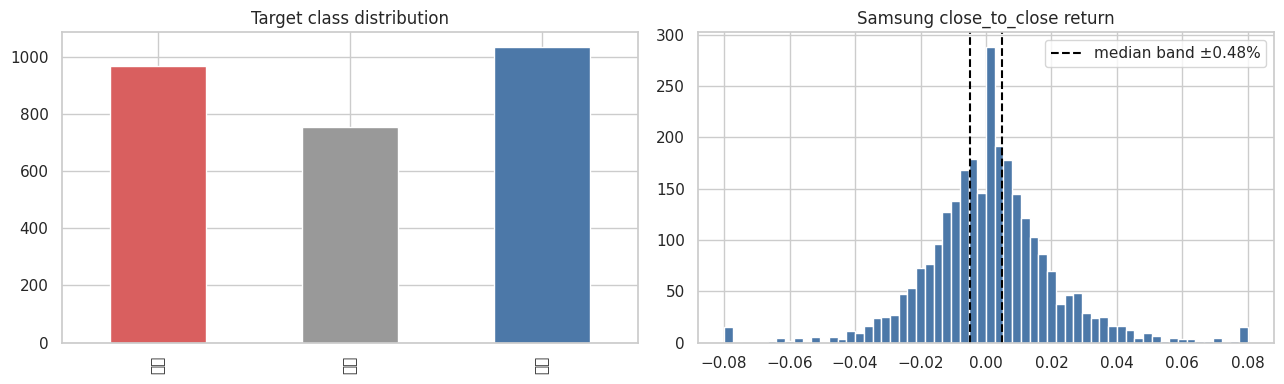

In [11]:
class_counts = model_df["target"].value_counts().sort_index()
class_table = pd.DataFrame({
    "class": [LABEL_NAMES[i] for i in class_counts.index],
    "count": class_counts.values,
    "ratio": class_counts.values / class_counts.sum(),
}, index=class_counts.index)
display(class_table.style.format({"ratio": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
class_table.set_index("class")["count"].plot.bar(ax=axes[0], color=["#d95f5f", "#999999", "#4c78a8"])
axes[0].set_title("Target class distribution")
axes[0].set_xlabel("")
model_df["target_return"].clip(-0.08, 0.08).hist(bins=60, ax=axes[1], color="#4c78a8")
median_band = float(model_df["band"].median())
axes[1].axvline(-median_band, color="black", ls="--", label=f"median band ±{median_band:.2%}")
axes[1].axvline(median_band, color="black", ls="--")
axes[1].legend()
axes[1].set_title(f"Samsung {TARGET_MODE} return")
plt.tight_layout()
plt.show()


## 4. 워크포워드 검증과 공통 평가함수

각 폴드는 과거 5년을 학습하고 다음 6개월을 예측합니다. `QUICK_MODE=True`에서는 가장 최근 3개 폴드만 실행합니다. 모든 모델의 확률 열 순서는 `[하락, 보합, 상승]`으로 고정합니다.


In [12]:
X = model_df[feature_cols].to_numpy(dtype=np.float32)
y = model_df["target"].to_numpy(dtype=np.int64)
dates = model_df.index
GAP = decomp["gap"].reindex(dates)
SESSION = decomp["session"].reindex(dates)


def make_walk_forward_folds(dates_index):
    folds = []
    start = pd.Timestamp(FIRST_TEST_DATE)
    max_date = dates_index.max()
    fold_no = 0
    while start <= max_date:
        end = start + pd.DateOffset(months=TEST_MONTHS)
        train_start = start - pd.DateOffset(years=ROLLING_TRAIN_YEARS)
        train_idx = np.where((dates_index >= train_start) & (dates_index < start))[0]
        test_idx = np.where((dates_index >= start) & (dates_index < end))[0]
        if len(train_idx) >= 500 and len(test_idx) >= 20:
            folds.append({
                "fold": fold_no, "train_idx": train_idx, "test_idx": test_idx,
                "train_start": dates_index[train_idx[0]], "train_end": dates_index[train_idx[-1]],
                "test_start": dates_index[test_idx[0]], "test_end": dates_index[test_idx[-1]],
            })
            fold_no += 1
        start = end
    if MAX_FOLDS is not None:
        folds = folds[-MAX_FOLDS:]
    return folds


folds = make_walk_forward_folds(dates)
if not folds:
    raise RuntimeError("워크포워드 폴드가 없습니다. START_DATE 또는 FIRST_TEST_DATE를 확인하세요.")

display(pd.DataFrame([{k: v for k, v in f.items() if not k.endswith("idx")} for f in folds]))


def multiclass_brier(y_true, probs):
    onehot = np.eye(3)[np.asarray(y_true, dtype=int)]
    return np.mean(np.sum((np.asarray(probs) - onehot) ** 2, axis=1))


def prediction_frame(model_name, row_dates, y_true, probs, fold_id=None, y_pred=None, extra=None):
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(probs, 1e-7, 1 - 1e-7)
    probs = probs / probs.sum(axis=1, keepdims=True)
    out = pd.DataFrame({
        "date": pd.to_datetime(row_dates),
        "y_true": np.asarray(y_true, dtype=int),
        "y_pred": probs.argmax(axis=1) if y_pred is None else np.asarray(y_pred, dtype=int),
        "p_down": probs[:, 0], "p_flat": probs[:, 1], "p_up": probs[:, 2],
        "model": model_name, "fold": fold_id,
    })
    if extra:
        for key, value in extra.items():
            out[key] = value
    return out


# ---- 월 블록 부트스트랩 ------------------------------------------------------
# 일별 예측은 서로 독립이 아니므로, 달력 월을 블록으로 복원추출해 신뢰구간을 만든다.
def month_blocks(date_index):
    key = pd.PeriodIndex(pd.DatetimeIndex(date_index), freq="M")
    return [np.where(key == m)[0] for m in key.unique()]


def block_bootstrap_ci(date_index, stat_fn, b=BOOTSTRAP_B, seed=SEED, alpha=0.05):
    """stat_fn(row_positions) -> 스칼라. (하한, 상한) 반환."""
    blocks = month_blocks(date_index)
    if not blocks:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(b):
        pick = rng.integers(0, len(blocks), len(blocks))
        idx = np.concatenate([blocks[i] for i in pick])
        try:
            draws.append(stat_fn(idx))
        except Exception:
            continue
    if not draws:
        return (np.nan, np.nan)
    return tuple(np.percentile(draws, [100 * alpha / 2, 100 * (1 - alpha / 2)]))


def metric_row(frame):
    true = frame["y_true"].to_numpy(dtype=int)
    pred = frame["y_pred"].to_numpy(dtype=int)
    probs = frame[PROB_COLS].to_numpy(dtype=float)
    return {
        "n": len(frame),
        "accuracy": accuracy_score(true, pred),
        "balanced_accuracy": balanced_accuracy_score(true, pred),
        "macro_f1": f1_score(true, pred, average="macro", zero_division=0),
        "log_loss": log_loss(true, probs, labels=[0, 1, 2]),
        "brier": multiclass_brier(true, probs),
    }


def _auc_vs_sign(score, leg):
    """방향 점수가 특정 구간(갭 또는 세션)의 부호를 얼마나 맞히는가."""
    ok = leg.notna().to_numpy() & (leg.to_numpy() != 0)
    if ok.sum() < 30:
        return np.nan
    return roc_auc_score((leg.to_numpy()[ok] > 0).astype(int), np.asarray(score)[ok])


def decomposition_row(frame, cost_bp=COST_BP):
    """모델이 실제로 무엇을 예측하는지: 갭 vs 세션, 그리고 구간별 기대손익(bp)."""
    s = frame.set_index("date").sort_index()
    score = (s["p_up"] - s["p_down"]).to_numpy()
    gap = GAP.reindex(s.index)
    ses = SESSION.reindex(s.index)
    direction = np.sign(score)
    gap_bp = float(np.nanmean(direction * gap.to_numpy())) * 1e4
    ses_bp = float(np.nanmean(direction * ses.to_numpy())) * 1e4
    lo, hi = block_bootstrap_ci(
        s.index,
        lambda idx: float(np.nanmean(direction[idx] * ses.to_numpy()[idx])) * 1e4,
    )
    return {
        "auc_gap": _auc_vs_sign(score, gap),
        "auc_session": _auc_vs_sign(score, ses),
        "gap_bp": gap_bp,
        "session_bp": ses_bp,
        "session_bp_lo": lo,
        "session_bp_hi": hi,
        "session_bp_net": ses_bp - cost_bp,
    }


def summarize_predictions(predictions, with_ci=True, with_decomposition=False):
    rows = []
    for name, group in predictions.groupby("model"):
        row = {"model": name, **metric_row(group)}
        if with_ci:
            g = group.sort_values("date")
            true = g["y_true"].to_numpy(dtype=int)
            pred = g["y_pred"].to_numpy(dtype=int)
            probs = g[PROB_COLS].to_numpy(dtype=float)
            row["bal_acc_lo"], row["bal_acc_hi"] = block_bootstrap_ci(
                g["date"], lambda i: balanced_accuracy_score(true[i], pred[i]))
            row["log_loss_lo"], row["log_loss_hi"] = block_bootstrap_ci(
                g["date"], lambda i: log_loss(true[i], probs[i], labels=[0, 1, 2]))
        if with_decomposition:
            row.update(decomposition_row(group))
        rows.append(row)
    out = pd.DataFrame(rows).set_index("model")
    order = [m for m in MODEL_ORDER if m in out.index] + [m for m in out.index if m not in MODEL_ORDER]
    return out.loc[order]


def paired_delta_ci(predictions, model_a, model_b, metric="balanced_accuracy"):
    """같은 날짜에서 두 모델의 지표 차이와 95% 신뢰구간(월 블록 부트스트랩)."""
    a = predictions[predictions["model"] == model_a].set_index("date").sort_index()
    b = predictions[predictions["model"] == model_b].set_index("date").sort_index()
    common = a.index.intersection(b.index)
    a, b = a.loc[common], b.loc[common]
    if len(common) < 60:
        return {"delta": np.nan, "lo": np.nan, "hi": np.nan, "n": len(common)}

    def stat(idx):
        fa, fb = a.iloc[idx], b.iloc[idx]
        if metric == "accuracy":
            return float(np.mean(fa["y_true"].to_numpy() == fa["y_pred"].to_numpy())
                         - np.mean(fb["y_true"].to_numpy() == fb["y_pred"].to_numpy()))
        if metric == "balanced_accuracy":
            return (balanced_accuracy_score(fa["y_true"], fa["y_pred"])
                    - balanced_accuracy_score(fb["y_true"], fb["y_pred"]))
        return (log_loss(fa["y_true"], fa[PROB_COLS].to_numpy(), labels=[0, 1, 2])
                - log_loss(fb["y_true"], fb[PROB_COLS].to_numpy(), labels=[0, 1, 2]))

    delta = stat(np.arange(len(common)))
    lo, hi = block_bootstrap_ci(common, stat)
    return {"delta": delta, "lo": lo, "hi": hi, "n": len(common)}


def folds_worse_than_prior(predictions, model_name):
    """폴드별 log loss가 '항상 보합'(클래스 사전확률)보다 나쁜 횟수."""
    g = predictions[predictions["model"] == model_name]
    base = predictions[predictions["model"] == "Always flat"].set_index(["fold", "date"])
    worse = 0
    for fold_id, grp in g.groupby("fold"):
        idx = pd.MultiIndex.from_arrays([grp["fold"], grp["date"]])
        try:
            ref = base.loc[idx]
        except KeyError:
            continue
        ll_model = log_loss(grp["y_true"], grp[PROB_COLS].to_numpy(), labels=[0, 1, 2])
        ll_base = log_loss(ref["y_true"], ref[PROB_COLS].to_numpy(), labels=[0, 1, 2])
        worse += int(ll_model >= ll_base)
    return worse

,fold,train_start,train_end,test_start,test_end
0,0,2016-01-04,2020-12-30,2021-01-04,2021-06-30
1,1,2016-07-01,2021-06-30,2021-07-01,2021-12-30
2,2,2017-01-02,2021-12-30,2022-01-04,2022-06-30
3,3,2017-07-03,2022-06-30,2022-07-01,2022-12-29
4,4,2018-01-02,2022-12-29,2023-01-02,2023-06-30
5,5,2018-07-02,2023-06-30,2023-07-03,2023-12-28
6,6,2019-01-02,2023-12-28,2024-01-02,2024-06-28
7,7,2019-07-01,2024-06-28,2024-07-01,2024-12-30
8,8,2020-01-02,2024-12-30,2025-01-02,2025-06-30
9,9,2020-07-01,2025-06-30,2025-07-01,2025-12-30


## 5. 기준선 · 로지스틱 회귀 · LightGBM

복잡한 모델은 반드시 단순 기준선보다 미래 구간에서 좋아야 합니다. 클래스 불균형을 고려해 로지스틱과 LightGBM 모두 균형 가중치를 사용합니다.


In [13]:
# 셀을 다시 실행해도 예측 프레임이 중복 적재되지 않도록, 단계별 결과를 딕셔너리에
# 보관하고 매번 새로 조립한다.
PREDICTION_PARTS = {}


def assemble_predictions():
    parts = [p for p in PREDICTION_PARTS.values() if p is not None and len(p)]
    out = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    assert not out.duplicated(["date", "model"]).any(), "예측 프레임에 중복 행이 있습니다."
    return out


def make_logistic():
    # C=0.25는 2026년 고변동 국면에서 과신이 심했다(마지막 폴드 log loss 1.25 > 사전확률 1.10).
    # C를 낮춰도 balanced accuracy는 그대로이고 확률 품질만 좋아진다.
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.01, max_iter=3000,
                                     class_weight="balanced", random_state=SEED)),
    ])


def make_lgbm(n_estimators=60, num_leaves=7):
    # 300트리 × 15리프는 그리드에서 가장 나쁜 조합이었고 클래스 사전확률보다도 log loss가
    # 높았다(1.099 vs 1.097). 60×7이 검증에서 최적이었다.
    # subsample은 subsample_freq를 켜지 않으면 아무 효과가 없으므로 아예 제거했다.
    return LGBMClassifier(
        objective="multiclass", num_class=3,
        n_estimators=n_estimators, learning_rate=0.03, num_leaves=num_leaves,
        min_child_samples=50, colsample_bytree=0.85,
        reg_alpha=0.5, reg_lambda=2.0, class_weight="balanced",
        random_state=SEED, n_jobs=-1, verbosity=-1,
    )


tabular_predictions = []
lgb_importances = []
model_selection_rows = []
# 시세만: 월별 지표(macro_)와 뉴스심리(nsi_)를 모두 뺀 것. "No macro ensemble"과 "Previous ensemble"의 입력.
market_feature_idx = [i for i, c in enumerate(feature_cols) if not c.startswith(("macro_", "nsi_", "flow_"))]
market_X = X[:, market_feature_idx]
# 뉴스심리만 뺀 것: "No NSI ensemble". Mean ensemble과의 쌍체 차이가 뉴스심리지수의 추가 효과다.
no_nsi_feature_idx = [i for i, c in enumerate(feature_cols) if not c.startswith("nsi_")]
no_nsi_X = X[:, no_nsi_feature_idx]
# 수급만 뺀 것: "No flow ensemble". Mean ensemble과의 쌍체 차이가 외국인·기관 수급의 추가 효과다.
no_flow_feature_idx = [i for i, c in enumerate(feature_cols) if not c.startswith("flow_")]
no_flow_X = X[:, no_flow_feature_idx]
# 유가·엔화만 뺀 것: "No macro price ensemble". Mean ensemble 과의 차이가 그 두 축의 추가 효과다.
no_price_feature_idx = [i for i, c in enumerate(feature_cols) if not c.startswith(MACRO_PRICE_PREFIXES)]
no_price_X = X[:, no_price_feature_idx]
MACRO_PRICE_ACTIVE = len(no_price_feature_idx) < len(feature_cols)

for fold in tqdm(folds, desc="Tabular walk-forward"):
    tr, te = fold["train_idx"], fold["test_idx"]

    # 기준선: 학습구간의 클래스 사전확률을 그대로 확률로 쓰고, 하드 예측만 보합으로 고정한다.
    # (확률을 왜곡해 argmax를 맞추면 기준선의 log loss가 부풀려져 잣대가 어긋난다.)
    prior = np.bincount(y[tr], minlength=3).astype(float) + 1
    prior = prior / prior.sum()
    tabular_predictions.append(prediction_frame(
        "Always flat", dates[te], y[te], np.tile(prior, (len(te), 1)), fold["fold"],
        y_pred=np.ones(len(te), dtype=int),
    ))

    # 기존 고정설정을 동일한 외부 폴드에서 비교해 개선 여부를 확인한다.
    old_log = make_logistic().fit(market_X[tr], y[tr])
    old_lgb = make_lgbm().fit(market_X[tr], y[tr])
    old_mean = (aligned_probabilities(old_log, market_X[te]) + aligned_probabilities(old_lgb, market_X[te])) / 2
    tabular_predictions.append(prediction_frame("Previous ensemble", dates[te], y[te], old_mean, fold["fold"]))
    if MACRO_ACTIVE:
        no_macro_probs = []
        for family in ["Logistic", "LightGBM"]:
            fitted_market = fit_direction_model(market_X, y, tr, family, seed=SEED, selection=SELECTION_METRIC)
            no_macro_probs.append(predict_direction_model(fitted_market, market_X[te]))
            model_selection_rows.append({"fold": fold["fold"], "features": "market_only", **fitted_market["selection"]})
        tabular_predictions.append(prediction_frame("No macro ensemble", dates[te], y[te],
                                                    np.mean(no_macro_probs, axis=0), fold["fold"]))
    if NSI_ACTIVE:
        no_nsi_probs = []
        for family in ["Logistic", "LightGBM"]:
            fitted_no_nsi = fit_direction_model(no_nsi_X, y, tr, family, seed=SEED, selection=SELECTION_METRIC)
            no_nsi_probs.append(predict_direction_model(fitted_no_nsi, no_nsi_X[te]))
            model_selection_rows.append({"fold": fold["fold"], "features": "no_nsi", **fitted_no_nsi["selection"]})
        tabular_predictions.append(prediction_frame("No NSI ensemble", dates[te], y[te],
                                                    np.mean(no_nsi_probs, axis=0), fold["fold"]))
    if FLOW_ACTIVE:
        no_flow_probs = []
        for family in ["Logistic", "LightGBM"]:
            fitted_no_flow = fit_direction_model(no_flow_X, y, tr, family, seed=SEED, selection=SELECTION_METRIC)
            no_flow_probs.append(predict_direction_model(fitted_no_flow, no_flow_X[te]))
            model_selection_rows.append({"fold": fold["fold"], "features": "no_flow", **fitted_no_flow["selection"]})
        tabular_predictions.append(prediction_frame("No flow ensemble", dates[te], y[te],
                                                    np.mean(no_flow_probs, axis=0), fold["fold"]))
    if MACRO_PRICE_ACTIVE:
        no_price_probs = []
        for family in ["Logistic", "LightGBM"]:
            fitted_no_price = fit_direction_model(no_price_X, y, tr, family, seed=SEED, selection=SELECTION_METRIC)
            no_price_probs.append(predict_direction_model(fitted_no_price, no_price_X[te]))
            model_selection_rows.append({"fold": fold["fold"], "features": "no_macro_price", **fitted_no_price["selection"]})
        tabular_predictions.append(prediction_frame("No macro price ensemble", dates[te], y[te],
                                                    np.mean(no_price_probs, axis=0), fold["fold"]))
    for family in ["Logistic", "LightGBM"]:
        fitted = fit_direction_model(X, y, tr, family, seed=SEED, selection=SELECTION_METRIC)
        probs = predict_direction_model(fitted, X[te])
        tabular_predictions.append(prediction_frame(family, dates[te], y[te], probs, fold["fold"]))
        model_selection_rows.append({"fold": fold["fold"], **fitted["selection"]})
        if family == "LightGBM":
            lgb_importances.append(fitted["estimator"].feature_importances_)

PREDICTION_PARTS["tabular"] = pd.concat(tabular_predictions, ignore_index=True)
predictions = assemble_predictions()
display(summarize_predictions(predictions, with_ci=False).style.format("{:.4f}", na_rep="—"))

Tabular walk-forward:   0%|          | 0/12 [00:00<?, ?it/s]

,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier
model,,,,,,
Always flat,1364.0000,0.2823,0.3333,0.1468,1.0966,0.6656
Previous ensemble,1364.0000,0.4531,0.4474,0.4479,1.0301,0.6201
No macro ensemble,1364.0000,0.4641,0.4423,0.4236,1.0280,0.6179
No NSI ensemble,1364.0000,0.4509,0.4292,0.4102,1.0340,0.6223
No flow ensemble,1364.0000,0.4655,0.4421,0.4192,1.0297,0.6189
No macro price ensemble,1364.0000,0.4729,0.4506,0.4320,1.0308,0.6202
Logistic,1364.0000,0.4641,0.4420,0.4231,1.0439,0.6244
LightGBM,1364.0000,0.4494,0.4268,0.4054,1.0441,0.6288


## 6. 직접 학습하는 Transformer Encoder

30거래일의 특징 시퀀스를 입력받아 마지막 토큰에서 세 방향의 확률을 출력합니다. 각 폴드마다 scaler와 모델을 과거 데이터로만 다시 학습합니다. 작은 데이터에서 대형 Transformer는 과적합하기 쉬우므로 의도적으로 작은 구조를 사용합니다.


In [14]:
if RUN_TRANSFORMER and TORCH_AVAILABLE:

    class DirectionTransformer(nn.Module):
        def __init__(self, n_features, seq_len, d_model=64, nhead=4, num_layers=2, dropout=0.20):
            super().__init__()
            self.seq_len = seq_len
            self.input_dropout = nn.Dropout(0.30)   # 입력 특징 단위 dropout
            self.input_proj = nn.Linear(n_features, d_model)
            # 고정 사인 위치 인코딩(학습 파라미터보다 소표본에서 안정적)
            position = torch.arange(seq_len).unsqueeze(1).float()
            div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe = torch.zeros(1, seq_len, d_model)
            pe[0, :, 0::2] = torch.sin(position * div)
            pe[0, :, 1::2] = torch.cos(position * div)
            self.register_buffer("position", pe)
            layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
                dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
            )
            self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers, enable_nested_tensor=False)
            self.norm = nn.LayerNorm(d_model)
            self.head = nn.Sequential(
                nn.Linear(d_model, d_model // 2), nn.GELU(),
                nn.Dropout(dropout), nn.Linear(d_model // 2, 3),
            )

        def forward(self, x):
            z = self.input_proj(self.input_dropout(x)) + self.position[:, :x.size(1)]
            z = self.encoder(z)
            return self.head(self.norm(z[:, -1]))


    def sequences_for_indices(X_scaled, y_array, target_indices, seq_len):
        seq_x, seq_y, kept = [], [], []
        for idx in target_indices:
            if idx < seq_len - 1:
                continue
            seq_x.append(X_scaled[idx - seq_len + 1: idx + 1])
            seq_y.append(y_array[idx])
            kept.append(idx)
        if not seq_x:
            return np.empty((0, seq_len, X_scaled.shape[1])), np.array([]), np.array([])
        return np.asarray(seq_x, dtype=np.float32), np.asarray(seq_y, dtype=np.int64), np.asarray(kept)


    def _fit_epochs(X_seq, y_seq, n_features, epochs, seed, val=None):
        """지정한 epoch 수만큼 학습한다. val이 주어지면 조기종료 이력도 함께 반환."""
        torch.manual_seed(seed)          # 전역 RNG에 의존하지 않도록 매번 명시적으로 시드
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        generator = torch.Generator().manual_seed(seed)
        loader = DataLoader(
            TensorDataset(torch.from_numpy(X_seq), torch.from_numpy(y_seq)),
            batch_size=BATCH_SIZE, shuffle=True, generator=generator, drop_last=False,
        )
        model = DirectionTransformer(n_features, SEQ_LEN).to(DEVICE)
        counts = np.bincount(y_seq, minlength=3).astype(float)
        weights = len(y_seq) / (3 * np.maximum(counts, 1))
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE))
        optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-3)

        val_loader = None
        if val is not None:
            val_loader = DataLoader(
                TensorDataset(torch.from_numpy(val[0]), torch.from_numpy(val[1])),
                batch_size=BATCH_SIZE * 2, shuffle=False,
            )
        best_state, best_val, best_epoch = None, np.inf, epochs
        patience_left = TRANSFORMER_PATIENCE
        history = []
        for epoch in range(epochs):
            model.train()
            train_losses = []
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad(set_to_none=True)
                loss = criterion(model(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_losses.append(loss.item())
            train_loss = float(np.mean(train_losses))
            if val_loader is None:
                history.append((epoch + 1, train_loss, np.nan))
                continue
            model.eval()
            val_losses = []
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    val_losses.append(criterion(model(xb), yb).item())
            val_loss = float(np.mean(val_losses)) if val_losses else train_loss
            history.append((epoch + 1, train_loss, val_loss))
            if val_loss < best_val - 1e-4:
                best_val, best_epoch = val_loss, epoch + 1
                best_state = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
                patience_left = TRANSFORMER_PATIENCE
            else:
                patience_left -= 1
                if patience_left <= 0:
                    break
        if best_state is not None:
            model.load_state_dict(best_state)
        return model, best_epoch, history


    def train_transformer(X_array, y_array, train_indices, seed=SEED, epochs=TRANSFORMER_EPOCHS):
        """조기종료로 최적 epoch를 정한 뒤, 학습 구간 전체로 다시 적합한다.
        (기존 코드는 마지막 15%를 검증에만 쓰고 학습에 넣지 않아, 실제로는 테스트
        구간보다 9개월 이른 데이터까지만 학습된 모델을 사용했다.)"""
        scaler = StandardScaler().fit(X_array[train_indices])
        X_scaled = scaler.transform(X_array).astype(np.float32)

        valid_targets = train_indices[train_indices >= SEQ_LEN - 1]
        cut = max(1, int(len(valid_targets) * 0.85))
        fit_targets, val_targets = valid_targets[:cut], valid_targets[cut:]
        if len(val_targets) < 10:
            val_targets = valid_targets[-max(10, len(valid_targets) // 10):]
            fit_targets = valid_targets[:len(valid_targets) - len(val_targets)]

        X_fit, y_fit, _ = sequences_for_indices(X_scaled, y_array, fit_targets, SEQ_LEN)
        X_val, y_val, _ = sequences_for_indices(X_scaled, y_array, val_targets, SEQ_LEN)
        _, best_epoch, history = _fit_epochs(
            X_fit, y_fit, X_array.shape[1], epochs, seed, val=(X_val, y_val))

        # 최적 epoch 수를 알았으니 검증 구간까지 포함해 다시 학습한다.
        X_all, y_all, _ = sequences_for_indices(X_scaled, y_array, valid_targets, SEQ_LEN)
        model, _, _ = _fit_epochs(X_all, y_all, X_array.shape[1], best_epoch, seed + 1)
        return model, scaler, X_scaled, history, best_epoch


    def transformer_probs(model, X_scaled, target_indices):
        dummy_y = np.zeros(len(X_scaled), dtype=np.int64)
        X_seq, _, kept = sequences_for_indices(X_scaled, dummy_y, target_indices, SEQ_LEN)
        loader = DataLoader(torch.from_numpy(X_seq), batch_size=BATCH_SIZE * 2, shuffle=False)
        probs = []
        model.eval()
        with torch.no_grad():
            for xb in loader:
                probs.append(torch.softmax(model(xb.to(DEVICE)), dim=1).cpu().numpy())
        return np.vstack(probs), kept

else:
    print("RUN_TRANSFORMER=False 또는 torch 없음: Transformer 섹션을 건너뜁니다.")

RUN_TRANSFORMER=False 또는 torch 없음: Transformer 섹션을 건너뜁니다.


In [15]:
if RUN_TRANSFORMER and TORCH_AVAILABLE:
    transformer_predictions, transformer_histories = [], []
    for fold in tqdm(folds, desc="Transformer walk-forward"):
        tr, te = fold["train_idx"], fold["test_idx"]
        model_t, scaler_t, X_scaled_t, hist_t, best_ep = train_transformer(
            X, y, tr, seed=SEED + fold["fold"])
        probs_t, kept_t = transformer_probs(model_t, X_scaled_t, te)
        transformer_predictions.append(prediction_frame(
            "Transformer", dates[kept_t], y[kept_t], probs_t, fold["fold"]))
        transformer_histories.append(
            pd.DataFrame(hist_t, columns=["epoch", "train_loss", "val_loss"]).assign(fold=fold["fold"]))
        del model_t
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    PREDICTION_PARTS["transformer"] = pd.concat(transformer_predictions, ignore_index=True)
    predictions = assemble_predictions()
    display(summarize_predictions(predictions, with_ci=False).style.format("{:.4f}", na_rep="—"))

    history_df = pd.concat(transformer_histories, ignore_index=True)
    sns.lineplot(data=history_df, x="epoch", y="val_loss", hue="fold", marker="o")
    plt.title("Transformer validation loss by fold")
    plt.show()
else:
    PREDICTION_PARTS["transformer"] = None
    predictions = assemble_predictions()

## 6.5 앙상블

`ENSEMBLE_MODELS`에 지정한 모델들의 확률을 **단순 평균**합니다.

이전 버전에는 OOF 스태킹 메타모델과 `exp(-2 × Δlog loss)` 성과가중 앙상블이 있었지만, 검증 결과 둘 다 제거했습니다.

- **스태킹**: 메타모델이 폴드에 따라 123행으로 학습되어 단순 평균보다 나빴습니다(log loss 1.0507 vs 1.0379).
- **성과가중**: 0.03 nats 차이 위에서 계산된 가중치라 사실상 균등 평균(0.32~0.34)이었고, 판별력을 잃고 사전확률에 가까워진 모델에 가장 큰 가중을 주는 부작용이 있었습니다.

정규화를 바로잡은 Logistic + LightGBM의 단순 평균이, 이전의 3모델 평균·스태킹보다 좋거나 같으면서 훨씬 단순합니다.

In [16]:
# 검증 결과 스태킹 메타모델(폴드에 따라 123행으로 학습)은 단순 평균보다 나빴고
# (log loss 1.0507 vs 1.0379), exp(-2·Δlog loss) 성과가중은 0.03 nats 차이 위에서
# 계산되어 사실상 균등 평균이었다. 그래서 둘 다 제거하고 단순 평균만 남긴다.
available = [m for m in ENSEMBLE_MODELS if m in set(predictions["model"])]
if len(available) < 2:
    print("⚠️ 앙상블을 만들 기본 모델이 부족합니다:", available)
    PREDICTION_PARTS["ensemble"] = None
else:
    wide = (
        predictions[predictions["model"].isin(available)]
        .pivot_table(index="date", columns="model", values=PROB_COLS)
        .dropna()
    )
    stacked = np.stack([wide[[(p, m) for p in PROB_COLS]].to_numpy() for m in available], axis=1)
    p_mean = stacked.mean(axis=1)
    ens_dates = pd.DatetimeIndex(wide.index)
    fold_by_date = (
        predictions[predictions["model"] == available[0]]
        .set_index("date")["fold"].reindex(ens_dates)
    )
    PREDICTION_PARTS["ensemble"] = prediction_frame(
        "Mean ensemble", ens_dates,
        model_df.loc[ens_dates, "target"].to_numpy(dtype=int),
        p_mean, fold_by_date.to_numpy(),
    )
    print(f"Mean ensemble = {' + '.join(available)} 확률의 단순 평균 ({len(ens_dates)}일)")

predictions = assemble_predictions()

native_metrics = summarize_predictions(predictions, with_ci=False)
display(native_metrics[["n", "accuracy", "balanced_accuracy", "macro_f1", "log_loss", "brier"]]
        .style.format("{:.4f}", na_rep="—"))

# 폴드별 성능: 우위가 여러 구간에서 반복되는지 확인
fold_table = (
    predictions.groupby(["fold", "model"], group_keys=False)[["y_true", "y_pred", *PROB_COLS]]
    .apply(lambda g: pd.Series(metric_row(g)))
    .reset_index()
    .pivot(index="fold", columns="model", values="balanced_accuracy")
)
cols = [m for m in MODEL_ORDER if m in fold_table.columns]
display(fold_table[cols].style.format("{:.3f}", na_rep="—")
        .set_caption("Balanced accuracy by walk-forward fold"))

Mean ensemble = Logistic + LightGBM 확률의 단순 평균 (1364일)


,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier
model,,,,,,
Always flat,1364.0000,0.2823,0.3333,0.1468,1.0966,0.6656
Previous ensemble,1364.0000,0.4531,0.4474,0.4479,1.0301,0.6201
No macro ensemble,1364.0000,0.4641,0.4423,0.4236,1.0280,0.6179
No NSI ensemble,1364.0000,0.4509,0.4292,0.4102,1.0340,0.6223
No flow ensemble,1364.0000,0.4655,0.4421,0.4192,1.0297,0.6189
No macro price ensemble,1364.0000,0.4729,0.4506,0.4320,1.0308,0.6202
Logistic,1364.0000,0.4641,0.4420,0.4231,1.0439,0.6244
LightGBM,1364.0000,0.4494,0.4268,0.4054,1.0441,0.6288
Mean ensemble,1364.0000,0.4604,0.4369,0.4135,1.0328,0.6214


model,Always flat,Previous ensemble,No macro ensemble,No NSI ensemble,No flow ensemble,No macro price ensemble,Logistic,LightGBM,Mean ensemble
fold,,,,,,,,,
0,0.333,0.424,0.414,0.413,0.427,0.442,0.411,0.400,0.403
1,0.333,0.392,0.372,0.397,0.399,0.402,0.409,0.384,0.401
2,0.333,0.482,0.485,0.469,0.466,0.472,0.485,0.460,0.473
3,0.333,0.439,0.399,0.393,0.421,0.441,0.426,0.382,0.398
4,0.333,0.443,0.449,0.455,0.418,0.479,0.425,0.454,0.450
5,0.333,0.512,0.522,0.483,0.487,0.486,0.433,0.486,0.502
6,0.333,0.468,0.477,0.430,0.451,0.446,0.480,0.457,0.452
7,0.333,0.408,0.390,0.390,0.427,0.428,0.438,0.384,0.390
8,0.333,0.437,0.436,0.418,0.427,0.435,0.452,0.434,0.436


## 8. 성능 표와 갭/세션 분해

세 종류의 표를 봅니다.

1. **전체 평가 구간 성능** — 모든 지표에 월 블록 부트스트랩 95% 신뢰구간을 붙였습니다. 일별 예측은 서로 독립이 아니므로 달력 월을 블록으로 복원추출합니다.
2. **갭 / 세션 분해** — 이 노트북에서 가장 중요한 표입니다. 모델의 방향 점수가 *전일 종가→시가 갭*의 부호를 맞히는지, *시가→종가 세션*의 부호를 맞히는지 따로 측정하고, 각 구간에서 모델 방향대로 포지션을 잡았을 때의 일평균 손익(bp)을 왕복 비용 차감 전후로 보여줍니다. **07:00 예측으로 실제 취할 수 있는 것은 세션 구간뿐입니다.**
3. **'항상 보합' 대비 쌍체 차이** — 같은 날짜에서 계산한 차이와 신뢰구간입니다. CI가 0을 포함하면 "동률"로 읽어야 합니다.



In [17]:
native_metrics = summarize_predictions(predictions, with_decomposition=True)

print("■ 전체 평가 구간 성능 (95% 신뢰구간은 달력 월 블록 부트스트랩)")
display(
    native_metrics[["n", "accuracy", "balanced_accuracy", "bal_acc_lo", "bal_acc_hi",
                    "macro_f1", "log_loss", "log_loss_lo", "log_loss_hi", "brier"]]
    .style.format("{:.4f}", na_rep="—")
)

# ---- 이 모델이 실제로 무엇을 예측하는가 --------------------------------------
print("\n■ 갭 / 세션 분해 — 07:00 예측으로 실제 취할 수 있는 것은 '세션'뿐이다")
print("   갭     = 전일 종가 → 당일 시가 (09:00에 이미 가격에 반영됨)")
print("   세션   = 당일 시가 → 당일 종가 (시가에 진입하면 취할 수 있는 유일한 구간)")
decomp_cols = ["auc_gap", "auc_session", "gap_bp", "session_bp", "session_bp_lo",
               "session_bp_hi", "session_bp_net"]
display(
    native_metrics[decomp_cols].style.format(
        {"auc_gap": "{:.3f}", "auc_session": "{:.3f}", "gap_bp": "{:+.1f}",
         "session_bp": "{:+.1f}", "session_bp_lo": "{:+.1f}", "session_bp_hi": "{:+.1f}",
         "session_bp_net": "{:+.1f}"}, na_rep="—")
    .set_caption(f"bp = 일평균 수익(베이시스포인트). net은 왕복 비용 {COST_BP:.0f}bp 차감 후.")
)

# ---- 차이가 실재하는가: 쌍체 비교 --------------------------------------------
reference = "Always flat"
compare = [m for m in MODEL_ORDER if m in set(predictions["model"]) and m != reference]
rows = []
for name in compare:
    for metric in ("balanced_accuracy", "log_loss"):
        d = paired_delta_ci(predictions, name, reference, metric=metric)
        rows.append({
            "model": name, "metric": metric, "n": d["n"],
            "delta_vs_flat": d["delta"], "lo": d["lo"], "hi": d["hi"],
            "판정": "유의" if (pd.notna(d["lo"]) and (d["lo"] > 0) == (d["hi"] > 0)) else "동률(CI가 0 포함)",
        })
    rows.append({"model": name, "metric": "folds_worse_than_prior",
                 "n": len(folds), "delta_vs_flat": folds_worse_than_prior(predictions, name),
                 "lo": np.nan, "hi": np.nan, "판정": ""})
print("\n■ '항상 보합' 대비 쌍체 차이 (CI가 0을 포함하면 동률로 읽어야 한다)")
display(pd.DataFrame(rows).set_index(["model", "metric"])
        .style.format({"delta_vs_flat": "{:+.4f}", "lo": "{:+.4f}", "hi": "{:+.4f}"}, na_rep="—"))

# 외부 평가 구간의 기존 설정 대비 개선 폭. 내부 선택 점수와 구분한다.
improvement_rows = []
for metric in ["accuracy", "balanced_accuracy", "log_loss"]:
    delta = paired_delta_ci(predictions, "Mean ensemble", "Previous ensemble", metric)
    improvement_rows.append({"metric": metric, **delta})
improvement_table = pd.DataFrame(improvement_rows)
print("■ 개선 모델 - 기존 고정설정 (외부 평가 구간, 95% CI)")
display(improvement_table)

macro_comparison = pd.DataFrame()
if MACRO_ACTIVE:
    # 뉴스심리가 켜져 있으면 '전체 - 시세만'에 뉴스심리 효과가 섞이므로, 뉴스심리를 뺀 모델과 비교한다.
    _macro_full = "No NSI ensemble" if NSI_ACTIVE else "Mean ensemble"
    macro_comparison = pd.DataFrame([
        {"metric": metric, **paired_delta_ci(predictions, _macro_full, "No macro ensemble", metric)}
        for metric in ["accuracy", "balanced_accuracy", "log_loss"]])
    print("■ 월별 지표 추가 효과: 같은 학습/평가 날짜, 같은 내부 선택 방법")
    print("⚠️ 최신 수정치로 계산한 탐색 결과입니다. 실제 누적 예측으로 확인하세요.")
    display(macro_comparison)
nsi_comparison = pd.DataFrame()
if NSI_ACTIVE:
    nsi_comparison = pd.DataFrame([
        {"metric": metric, **paired_delta_ci(predictions, "Mean ensemble", "No NSI ensemble", metric)}
        for metric in ["accuracy", "balanced_accuracy", "log_loss"]])
    print("■ 뉴스심리지수 추가 효과: Mean ensemble − No NSI ensemble (같은 날짜, 같은 방법)")
    print("⚠️ 지수 날짜+14일 정렬·재계산 이력 기준의 탐색 결과입니다. log loss는 음수가 유리하며 CI가 0을 포함하면 동률입니다.")
    display(nsi_comparison)

flow_comparison = pd.DataFrame()
if FLOW_ACTIVE:
    flow_comparison = pd.DataFrame([
        {"metric": metric, **paired_delta_ci(predictions, "Mean ensemble", "No flow ensemble", metric)}
        for metric in ["accuracy", "balanced_accuracy", "log_loss"]])
    print("■ 외국인·기관 수급 추가 효과: Mean ensemble − No flow ensemble (같은 날짜, 같은 방법)")
    print("⚠️ log loss는 음수가 유리하며 CI가 0을 포함하면 동률입니다.")
    display(flow_comparison)

macro_price_comparison = pd.DataFrame()
if MACRO_PRICE_ACTIVE:
    macro_price_comparison = pd.DataFrame([
        {"metric": metric, **paired_delta_ci(predictions, "Mean ensemble", "No macro price ensemble", metric)}
        for metric in ["accuracy", "balanced_accuracy", "log_loss"]])
    print("■ 유가·엔화 추가 효과: Mean ensemble − No macro price ensemble (같은 날짜, 같은 방법)")
    print("⚠️ 전일까지의 값만 씁니다. 장중에 반영되는 뉴스는 07:00 예측에 넣을 수 없습니다.")
    display(macro_price_comparison)


■ 전체 평가 구간 성능 (95% 신뢰구간은 달력 월 블록 부트스트랩)


,n,accuracy,balanced_accuracy,bal_acc_lo,bal_acc_hi,macro_f1,log_loss,log_loss_lo,log_loss_hi,brier
model,,,,,,,,,,
Always flat,1364.0000,0.2823,0.3333,0.3333,0.3333,0.1468,1.0966,1.0900,1.1032,0.6656
Previous ensemble,1364.0000,0.4531,0.4474,0.4176,0.4765,0.4479,1.0301,1.0123,1.0494,0.6201
No macro ensemble,1364.0000,0.4641,0.4423,0.4155,0.4670,0.4236,1.0280,1.0107,1.0458,0.6179
No NSI ensemble,1364.0000,0.4509,0.4292,0.4016,0.4540,0.4102,1.0340,1.0165,1.0516,0.6223
No flow ensemble,1364.0000,0.4655,0.4421,0.4153,0.4669,0.4192,1.0297,1.0113,1.0477,0.6189
No macro price ensemble,1364.0000,0.4729,0.4506,0.4243,0.4774,0.4320,1.0308,1.0139,1.0476,0.6202
Logistic,1364.0000,0.4641,0.4420,0.4158,0.4678,0.4231,1.0439,1.0209,1.0755,0.6244
LightGBM,1364.0000,0.4494,0.4268,0.4003,0.4525,0.4054,1.0441,1.0243,1.0640,0.6288
Mean ensemble,1364.0000,0.4604,0.4369,0.4099,0.4634,0.4135,1.0328,1.0164,1.0494,0.6214



■ 갭 / 세션 분해 — 07:00 예측으로 실제 취할 수 있는 것은 '세션'뿐이다
   갭     = 전일 종가 → 당일 시가 (09:00에 이미 가격에 반영됨)
   세션   = 당일 시가 → 당일 종가 (시가에 진입하면 취할 수 있는 유일한 구간)


,auc_gap,auc_session,gap_bp,session_bp,session_bp_lo,session_bp_hi,session_bp_net
model,,,,,,,
Always flat,0.495,0.462,-14.5,-1.7,-13.2,+10.5,-21.7
Previous ensemble,0.811,0.499,+67.8,-5.8,-12.5,+0.7,-25.8
No macro ensemble,0.809,0.496,+68.5,-1.9,-9.8,+5.9,-21.9
No NSI ensemble,0.801,0.495,+66.3,-3.4,-11.7,+4.5,-23.4
No flow ensemble,0.797,0.500,+64.1,-0.9,-8.1,+5.9,-20.9
No macro price ensemble,0.802,0.498,+67.7,-1.1,-8.3,+6.3,-21.1
Logistic,0.799,0.496,+66.0,-1.1,-8.3,+6.1,-21.1
LightGBM,0.774,0.503,+63.0,-1.3,-8.4,+6.0,-21.3
Mean ensemble,0.802,0.499,+65.8,-2.4,-10.6,+5.5,-22.4



■ '항상 보합' 대비 쌍체 차이 (CI가 0을 포함하면 동률로 읽어야 한다)


...

,metric,delta,lo,hi,n
0,accuracy,0.009531,-0.000730,0.020380,1364
1,balanced_accuracy,0.007707,-0.002002,0.018203,1364
2,log_loss,-0.001109,-0.004237,0.001992,1364


■ 외국인·기관 수급 추가 효과: Mean ensemble − No flow ensemble (같은 날짜, 같은 방법)
⚠️ log loss는 음수가 유리하며 CI가 0을 포함하면 동률입니다.


,metric,delta,lo,hi,n
0,accuracy,-0.005132,-0.020680,0.010367,1364
1,balanced_accuracy,-0.005190,-0.021404,0.011162,1364
2,log_loss,0.003164,-0.001419,0.007675,1364


■ 유가·엔화 추가 효과: Mean ensemble − No macro price ensemble (같은 날짜, 같은 방법)
⚠️ 전일까지의 값만 씁니다. 장중에 반영되는 뉴스는 07:00 예측에 넣을 수 없습니다.


,metric,delta,lo,hi,n
0,accuracy,-0.012463,-0.025793,0.000725,1364
1,balanced_accuracy,-0.013711,-0.026951,-0.001084,1364
2,log_loss,0.002024,-0.001561,0.005649,1364


/tmp/ipykernel_18636/95726717.py:41: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/95726717.py:41: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/95726717.py:41: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/95726717.py:41: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/95726717.py:41: UserWarning: Glyph 44077 (\N{HANGUL SYLLABLE GAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/95726717.py:41: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/95726717.py:41: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_l

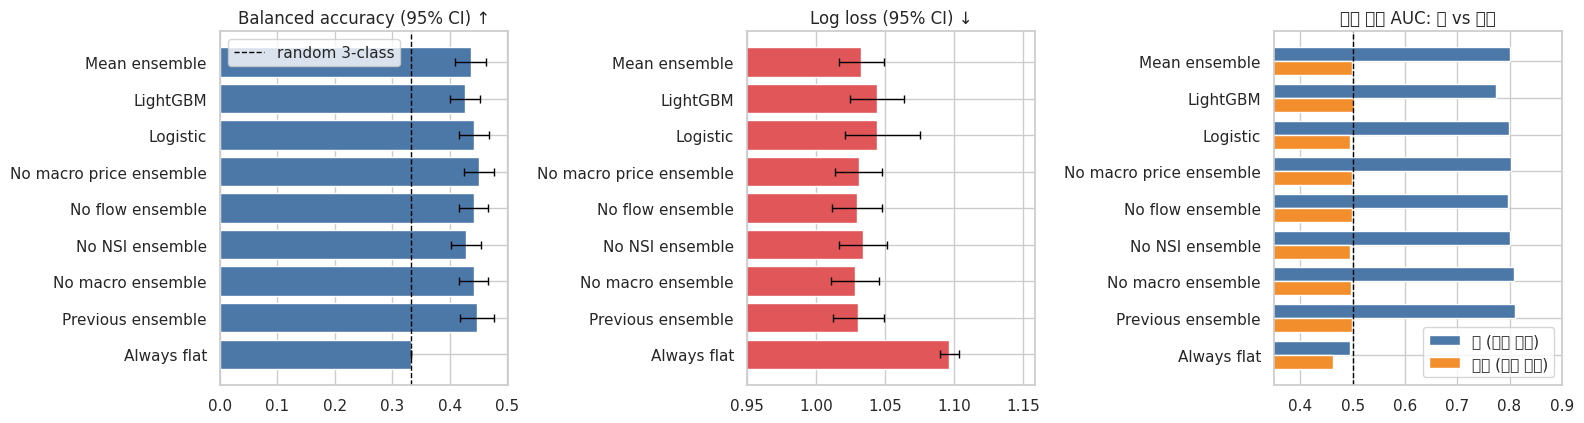

In [18]:
# 그림은 항상 전체 평가 구간에서 그린다(60일 창은 검정력이 없다).
plot_metrics = native_metrics.reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].barh(plot_metrics["model"], plot_metrics["balanced_accuracy"], color="#4c78a8")
axes[0].errorbar(
    plot_metrics["balanced_accuracy"], plot_metrics["model"],
    xerr=[plot_metrics["balanced_accuracy"] - plot_metrics["bal_acc_lo"],
          plot_metrics["bal_acc_hi"] - plot_metrics["balanced_accuracy"]],
    fmt="none", ecolor="black", capsize=3, lw=1,
)
axes[0].axvline(1 / 3, color="black", ls="--", lw=1, label="random 3-class")
axes[0].set_title("Balanced accuracy (95% CI) ↑")
axes[0].legend()

axes[1].barh(plot_metrics["model"], plot_metrics["log_loss"], color="#e15759")
axes[1].errorbar(
    plot_metrics["log_loss"], plot_metrics["model"],
    xerr=[plot_metrics["log_loss"] - plot_metrics["log_loss_lo"],
          plot_metrics["log_loss_hi"] - plot_metrics["log_loss"]],
    fmt="none", ecolor="black", capsize=3, lw=1,
)
axes[1].set_title("Log loss (95% CI) ↓")
axes[1].set_xlim(left=min(0.95, plot_metrics["log_loss_lo"].min() - 0.02))

width = 0.38
positions = np.arange(len(plot_metrics))
axes[2].barh(positions + width / 2, plot_metrics["auc_gap"], height=width,
             color="#4c78a8", label="갭 (거래 불가)")
axes[2].barh(positions - width / 2, plot_metrics["auc_session"], height=width,
             color="#f28e2b", label="세션 (거래 가능)")
axes[2].set_yticks(positions)
axes[2].set_yticklabels(plot_metrics["model"])
axes[2].axvline(0.5, color="black", ls="--", lw=1)
axes[2].set_xlim(0.35, 0.9)
axes[2].set_title("방향 판별 AUC: 갭 vs 세션")
axes[2].legend()

for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

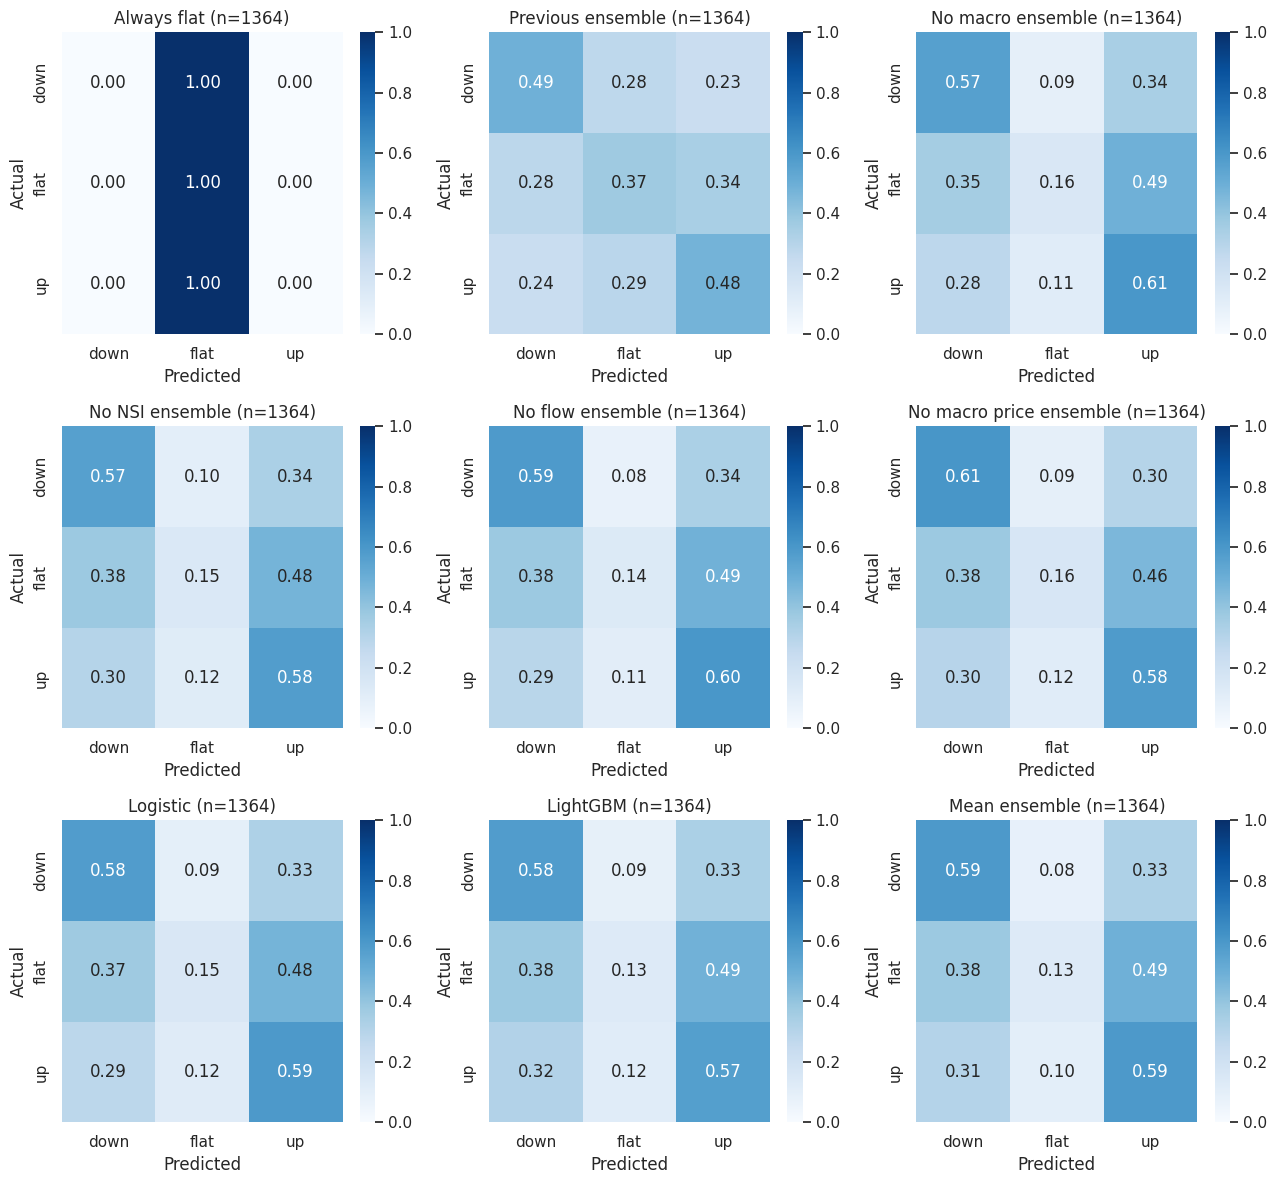

In [19]:
models_to_plot = [m for m in MODEL_ORDER if m in set(predictions["model"])]
ncols = 3
nrows = math.ceil(len(models_to_plot) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, models_to_plot):
    group = predictions[predictions["model"] == name]
    cm = confusion_matrix(group["y_true"], group["y_pred"], labels=[0, 1, 2], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=["down", "flat", "up"], yticklabels=["down", "flat", "up"], ax=ax)
    ax.set_title(f"{name} (n={len(group)})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
for ax in axes[len(models_to_plot):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

/tmp/ipykernel_18636/4023065717.py:32: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/4023065717.py:32: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/4023065717.py:32: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/4023065717.py:32: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/4023065717.py:32: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/4023065717.py:32: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18636/4023065717.py:32: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  plt

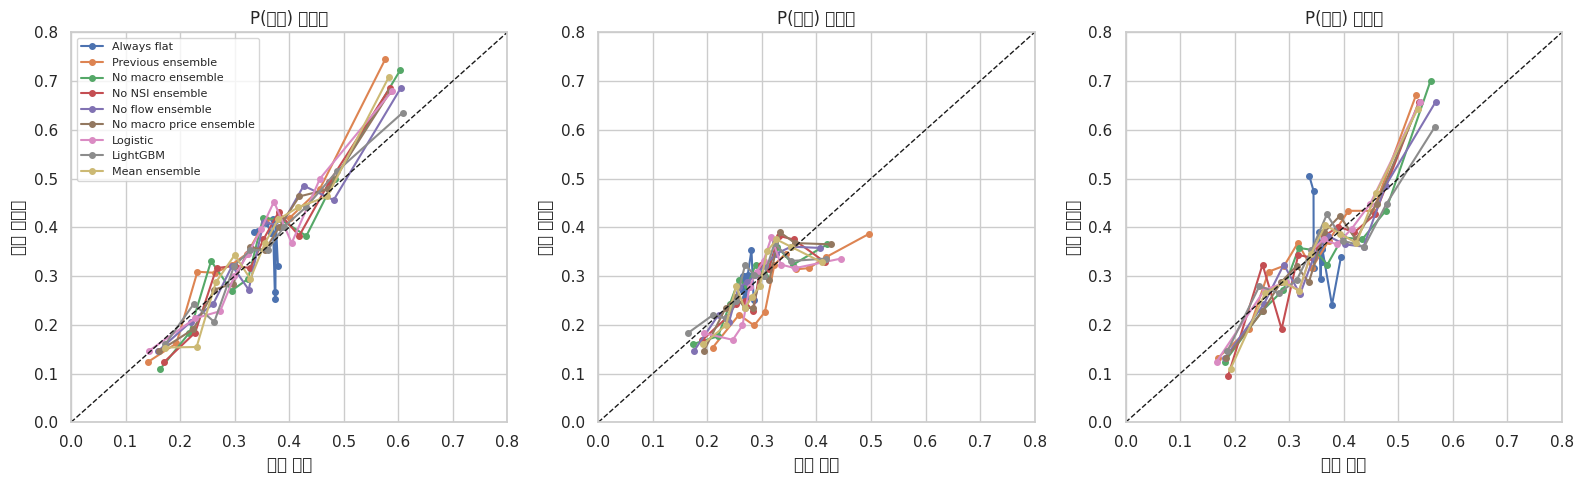

In [20]:
def reliability_by_class(frame, class_index, bins=10):
    """클래스별 예측확률을 분위로 나눠 실제 발생률과 비교한다.
    (최대확률 기준 구간화는 3-class에서 (0,1/3) 구간이 구조적으로 비어 버린다.)"""
    work = frame.copy()
    p = work[PROB_COLS[class_index]].to_numpy()
    hit = (work["y_true"].to_numpy() == class_index).astype(int)
    edges = np.unique(np.quantile(p, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return pd.DataFrame()
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, len(edges) - 2)
    out = pd.DataFrame({"bin": idx, "p": p, "hit": hit}).groupby("bin").agg(
        n=("hit", "size"), mean_p=("p", "mean"), observed=("hit", "mean"))
    return out[out["n"] >= 20]


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for class_index, ax in enumerate(axes):
    for name in models_to_plot:
        group = predictions[predictions["model"] == name]
        if len(group) < 200:
            continue
        rel = reliability_by_class(group, class_index)
        if len(rel):
            ax.plot(rel["mean_p"], rel["observed"], marker="o", ms=4, label=name)
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim(0, 0.8)
    ax.set_ylim(0, 0.8)
    ax.set_title(f"P({LABEL_NAMES[class_index]}) 신뢰도")
    ax.set_xlabel("예측 확률")
    ax.set_ylabel("실제 발생률")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. LightGBM 변수 중요도

중요도는 인과관계가 아니라 분할에 자주 사용된 정도입니다. 여러 폴드의 중요도를 평균합니다.


,mean_split_importance
micron_ret_1,102.083333
vxn_ret_1,44.250000
gdr_overnight_signal,42.583333
sp500_ret_1,41.000000
dxy_ret_1,35.750000
sam_range_1,35.250000
sam_vol_20,35.166667
kospi_ret_5,34.666667
sam_ret_2,34.500000
kospi_ret_1,33.416667


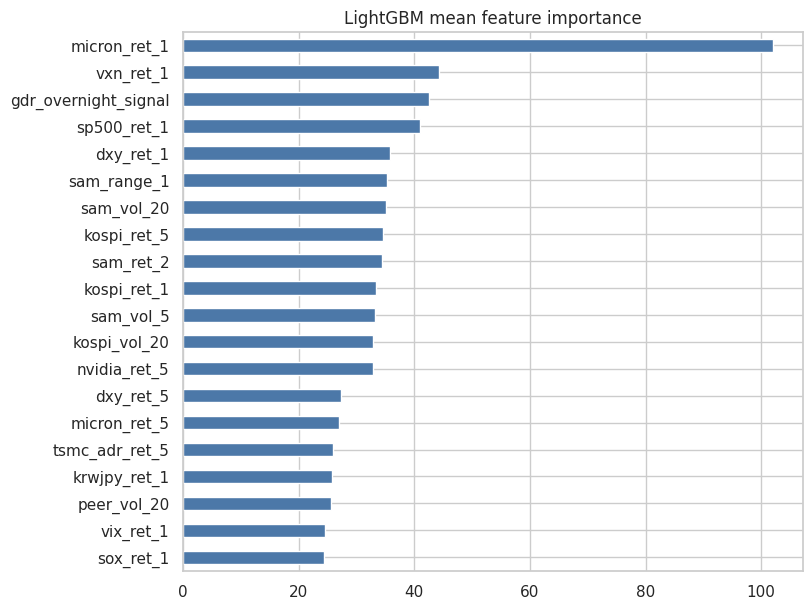

In [21]:
if lgb_importances:
    importance = pd.Series(np.mean(lgb_importances, axis=0), index=feature_cols).sort_values(ascending=False)
    display(importance.head(20).to_frame("mean_split_importance"))
    importance.head(20).sort_values().plot.barh(figsize=(8, 7), color="#4c78a8")
    plt.title("LightGBM mean feature importance")
    plt.show()


## 10. 최근 5년으로 재학습하고 다음 거래일 방향·중기 가격 예측

아래 결과는 노트북 실행 시점의 최신 공개 데이터로 계산됩니다. 기존 다음 거래일 방향과 함께 5거래일(1주일), 20거래일(1개월) 뒤 종가를 직접 회귀 방식으로 예측합니다. 한국 휴일이 끼어 예측 날짜가 틀리면 설정 셀의 `PREDICTION_DATE_OVERRIDE`를 수정하고 특징 생성 이후 셀을 다시 실행하세요.


In [22]:
RUN_ID = pd.Timestamp.now(tz="UTC").strftime("%Y%m%dT%H%M%S") + "_" + uuid.uuid4().hex[:12]
OUTPUT_DIR = STORAGE_ROOT / "runs" / RUN_ID
live_X = live_row[feature_cols].to_numpy(dtype=np.float32)
live_probs = {}

live_train_idx = rolling_train_indices(dates, prediction_date, ROLLING_TRAIN_YEARS)
logistic_full = fit_direction_model(X, y, live_train_idx, "Logistic", seed=SEED, selection=SELECTION_METRIC)
lgbm_full = fit_direction_model(X, y, live_train_idx, "LightGBM", seed=SEED, selection=SELECTION_METRIC)
live_probs["Logistic"] = predict_direction_model(logistic_full, live_X)[0]
live_probs["LightGBM"] = predict_direction_model(lgbm_full, live_X)[0]
for fitted in [logistic_full, lgbm_full]:
    model_selection_rows.append({"fold": "live", **fitted["selection"]})

transformer_full = transformer_scaler = None
if RUN_TRANSFORMER and TORCH_AVAILABLE:
    all_train_idx = live_train_idx
    transformer_full, transformer_scaler, _, transformer_full_history, _ = train_transformer(
        X, y, all_train_idx, seed=SEED + 1000)
    X_plus_live_scaled = transformer_scaler.transform(np.vstack([X, live_X])).astype(np.float32)
    live_seq = torch.from_numpy(X_plus_live_scaled[-SEQ_LEN:][None, ...]).to(DEVICE)
    transformer_full.eval()
    with torch.no_grad():
        live_probs["Transformer"] = torch.softmax(transformer_full(live_seq), dim=1).cpu().numpy()[0]


# 앙상블은 ENSEMBLE_MODELS의 단순 평균 하나만 쓴다.
# (성과가중 exp(-2·Δlog loss)는 0.03 nats 차이 위에서 계산되어 사실상 균등 평균이었고,
#  판별력을 잃고 사전확률에 가까워진 모델에 가장 큰 가중을 주는 부작용이 있었다.)
ensemble_members = [m for m in ENSEMBLE_MODELS if m in live_probs]
if len(ensemble_members) >= 2:
    live_probs["Mean ensemble"] = np.mean([live_probs[m] for m in ensemble_members], axis=0)
ensemble_weights = {m: 1.0 / len(ensemble_members) for m in ensemble_members}

market_live_models = {}
if MACRO_ACTIVE:
    for family in ["Logistic", "LightGBM"]:
        market_live_models[family] = fit_direction_model(market_X, y, live_train_idx, family, seed=SEED, selection=SELECTION_METRIC)
        model_selection_rows.append({"fold": "live", "features": "market_only", **market_live_models[family]["selection"]})
    live_probs["No macro ensemble"] = np.mean([
        predict_direction_model(fitted, live_X[:, market_feature_idx])[0]
        for fitted in market_live_models.values()], axis=0)

# ---- P15 후보: expanding 학습 창 ---------------------------------------------
# P04에서 sk_hynix의 expanding 창이 외부 평가에서 유의하게 나았지만(내부 선택은 못 골랐다),
# 계획 4절대로 최종 확인은 조정하지 않은 미래 사전 예측에서 한다. 대표 모델(5년 창)은 그대로
# 두고 후보를 별도 모델명으로 원장에 기록해 60거래일 이상 같은 날짜에서 채점한다.
# 두 종목 모두 기록한다 — 종목별로 따로 판단하기 위해서다. 보고서·앙상블에는 넣지 않는다.
CANDIDATE_MODELS = {"Candidate expanding": {"window": "expanding", "features": "market_only"}}
if MACRO_ACTIVE:
    candidate_train_idx = np.flatnonzero(pd.DatetimeIndex(dates) < prediction_date)   # 예측일 전 전체
    candidate_live = {}
    for family in ["Logistic", "LightGBM"]:
        candidate_live[family] = fit_direction_model(market_X, y, candidate_train_idx, family, seed=SEED, selection=SELECTION_METRIC)
        model_selection_rows.append({"fold": "live", "features": "market_only_expanding", **candidate_live[family]["selection"]})
    live_probs["Candidate expanding"] = np.mean([
        predict_direction_model(fitted, live_X[:, market_feature_idx])[0]
        for fitted in candidate_live.values()], axis=0)

no_nsi_live_models = {}
if NSI_ACTIVE:
    for family in ["Logistic", "LightGBM"]:
        no_nsi_live_models[family] = fit_direction_model(no_nsi_X, y, live_train_idx, family, seed=SEED, selection=SELECTION_METRIC)
        model_selection_rows.append({"fold": "live", "features": "no_nsi", **no_nsi_live_models[family]["selection"]})
    live_probs["No NSI ensemble"] = np.mean([
        predict_direction_model(fitted, live_X[:, no_nsi_feature_idx])[0]
        for fitted in no_nsi_live_models.values()], axis=0)

no_flow_live_models = {}
if FLOW_ACTIVE:
    for family in ["Logistic", "LightGBM"]:
        no_flow_live_models[family] = fit_direction_model(no_flow_X, y, live_train_idx, family, seed=SEED, selection=SELECTION_METRIC)
        model_selection_rows.append({"fold": "live", "features": "no_flow", **no_flow_live_models[family]["selection"]})
    live_probs["No flow ensemble"] = np.mean([
        predict_direction_model(fitted, live_X[:, no_flow_feature_idx])[0]
        for fitted in no_flow_live_models.values()], axis=0)

# 예측일의 이벤트 표시. 실적 시즌·직전 공시가 있는 날은 변동성이 커진다. 예측을 바꾸지는 않고
# 원장에 표시만 남겨, 나중에 '이벤트일'과 '평일'을 나눠 채점할 수 있게 한다.
prediction_event_flags = event_flags(prediction_date, disclosures) if USE_DISCLOSURES else []
# 미국 CPI·PPI·FOMC 발표는 한국 시간 밤이라 그 반응이 다음 거래일 갭에 나타난다. 예측은 그대로 두고
# 표시만 남긴다(일정표가 다루지 않는 기간이면 아무것도 붙지 않는다).
prediction_event_flags += korea_event_flags(prediction_date, STORAGE_ROOT)
upcoming_events = upcoming_us_events(last_samsung_date, STORAGE_ROOT, days=30)   # 실적 발표까지 보이게
if prediction_event_flags:
    print("이벤트 표시:", ", ".join(prediction_event_flags))

if MACRO_PRICE_ACTIVE:
    no_price_live = {}
    for family in ["Logistic", "LightGBM"]:
        no_price_live[family] = fit_direction_model(no_price_X, y, live_train_idx, family, seed=SEED, selection=SELECTION_METRIC)
        model_selection_rows.append({"fold": "live", "features": "no_macro_price", **no_price_live[family]["selection"]})
    live_probs["No macro price ensemble"] = np.mean([
        predict_direction_model(fitted, live_X[:, no_price_feature_idx])[0]
        for fitted in no_price_live.values()], axis=0)

# 이 예측을 무엇이 밀었는지. 원장 옆(attribution.csv)에만 남기고 보고서에는 띄우지 않는다.
# 기여도가 큰 특징이 '도움이 된 특징'은 아니다 — 크게 반응했는데 계속 틀렸다면 해로운 것이고,
# 그 구분은 채점이 쌓인 뒤에야 가능하다. 그래서 지금은 기록만 하고 /lab/ 에서만 본다.
# 대표 모델과 같은 특징 집합에서 뽑아야 한다. 전체 특징 모델에서 뽑으면 대표가 쓰지도 않는
# macro_*·nsi_* 가 1위로 찍혀 잘못 읽힌다.
live_contributions = []
try:
    if HEADLINE_MODEL == "No macro ensemble" and market_live_models:
        _attr_models = list(market_live_models.values())
        _attr_X, _attr_names = live_X[:, market_feature_idx], [feature_cols[i] for i in market_feature_idx]
    else:
        _attr_models = [logistic_full, lgbm_full]
        _attr_X, _attr_names = live_X, list(feature_cols)
    live_contributions = blend_contributions(
        [feature_contributions(fitted, _attr_X, _attr_names) for fitted in _attr_models])
except Exception as exc:
    print("기여도 계산 건너뜀:", type(exc).__name__, exc)

live_table = []
for name, probs in live_probs.items():
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    live_table.append({
        "model": name,
        "prediction_date": prediction_date.date().isoformat(),
        "prediction": LABEL_NAMES[int(np.argmax(probs))],
        "p_down": probs[0], "p_flat": probs[1], "p_up": probs[2],
    })
live_table = pd.DataFrame(live_table).set_index("model")

print("앙상블 구성:", ensemble_members, "(단순 평균)")

# 이전 버전과 모델 수가 다른 이유를 매번 명시한다(빠진 것이 아니라 뺀 것이다).
disabled = []
if not RUN_TRANSFORMER or not TORCH_AVAILABLE:
    disabled.append("Transformer — RUN_TRANSFORMER=True 로 켜세요"
                    + ("" if TORCH_AVAILABLE else " (torch 필요)"))
disabled.append("Stacked / Performance-weighted ensemble — 제거됨. "
                "검증에서 단순 평균보다 나빴습니다(1.0507 vs 1.0379)")
print("\n[모델 구성 안내] 표에 없는 모델:")
for item in disabled:
    print("  ·", item)

if not RECORD_FORECAST:
    print("⚠️ 장 마감 후 갱신입니다. 아래 예측은 그날 밤 미국 시장 정보가 반영되기 전의 참고값이며,")
    print("   원장에 기록되지 않습니다. 확정 예측은 다음 날 아침 06:30 실행에서 나옵니다.")
if imputed_live_features:
    print("⚠️ 과거값으로 대체된 라이브 특징:", imputed_live_features)
print("⚠️ 이 예측의 타깃은", TARGET_MODE, "입니다.",
      "close_to_close라면 예측력의 대부분은 09:00 시가에 이미 반영되는 '갭'이며,"
      " 시가 진입 후 종가 청산으로 얻을 수 있는 몫은 8절의 session_bp 열을 보세요."
      if TARGET_MODE == "close_to_close" else "")
display(live_table.style.format({"p_down": "{:.1%}", "p_flat": "{:.1%}", "p_up": "{:.1%}"}))

이벤트 표시: 미국지표:미국 소비자물가(CPI), 미국지표:미국 생산자물가(PPI)
앙상블 구성: ['Logistic', 'LightGBM'] (단순 평균)

[모델 구성 안내] 표에 없는 모델:
  · Transformer — RUN_TRANSFORMER=True 로 켜세요
  · Stacked / Performance-weighted ensemble — 제거됨. 검증에서 단순 평균보다 나빴습니다(1.0507 vs 1.0379)
⚠️ 이 예측의 타깃은 close_to_close 입니다. close_to_close라면 예측력의 대부분은 09:00 시가에 이미 반영되는 '갭'이며, 시가 진입 후 종가 청산으로 얻을 수 있는 몫은 8절의 session_bp 열을 보세요.


,prediction_date,prediction,p_down,p_flat,p_up
model,,,,,
Logistic,2026-09-14,보합,24.5%,39.9%,35.7%
LightGBM,2026-09-14,보합,26.5%,43.0%,30.5%
Mean ensemble,2026-09-14,보합,25.5%,41.5%,33.1%
No macro ensemble,2026-09-14,보합,27.5%,41.8%,30.7%
Candidate expanding,2026-09-14,보합,23.6%,39.3%,37.0%
No NSI ensemble,2026-09-14,보합,25.7%,43.4%,30.8%
No flow ensemble,2026-09-14,보합,24.3%,45.0%,30.6%
No macro price ensemble,2026-09-14,보합,23.6%,45.7%,30.7%


### 10.1 시초가예측과 1거래일·1주일·1개월 종가예측

각 시점의 미래 수익률을 **변동성 스케일 타깃 + 강한 축소(Ridge)** 로 추정합니다. 이전 버전에서 바뀐 점은 다음과 같습니다.

- 검증에서 두 회귀 모델(Ridge, LightGBM) 모두 **"수익률 0% 예측" 기준선보다 나빴는데도** 점 예측이 그대로 보고되었습니다. 이제는 손실 차이의 신뢰구간이 0을 포함하면 `signal`을 "없음"으로 두고 `predicted_return`·`predicted_close`를 **결측(`—`)으로 비웁니다.** 0.00%로 찍으면 "0%라고 예측했다"로 읽히지만, 실제로는 **예측을 하지 않은 것**이기 때문입니다. 이때 쓸 수 있는 값은 `center_close`(현재가)와 구간뿐입니다.
- 예측값은 OOF에서 추정한 **축소계수**(실제 수익률을 예측값에 회귀시킨 기울기, 0~1)를 곱한 값입니다. 축소가 없으면 20일 지평에서 예측 분산이 근거보다 10배 이상 컸습니다.
- 단일 예상 종가 대신 **변동성 스케일 구간**(`low_close` ~ `high_close`)을 함께 제공하고, 별도 최종 평가 구간의 커버리지를 `band_coverage`에 적습니다.
- LightGBM 회귀는 OOF 우위가 없고 시드에 따라 라이브 값이 몇 %p씩 흔들려 제거했습니다.
- `target_date`는 KRX 거래일 달력 기준입니다(`exchange_calendars`가 없으면 주말만 제외하고 경고합니다).
- **시초가예측**을 별도로 제공합니다. 1거래일 종가예측이 검증을 통과하는 이유는 거의 전부 전일 종가→시가 갭이므로(8절), 갭 자체를 같은 방법으로 예측해 `kind="open"`으로 원장에 남기고 **시가로 채점**합니다. 이 값은 09:00 이전에만 의미가 있고, 시가에 매수해서 얻을 수 있는 수익이 아닙니다.


In [23]:
FORECAST_HORIZONS = {"1거래일": 1, "1주일": 5, "1개월": 20}
BAND_COVERAGE = 0.80        # 예측 구간의 목표 커버리지
# 구간 폭은 q x sigma로 정해진다. sigma를 무엇으로 예측할지 고른다.
#   "simple": 최근 20일 표준편차 x sqrt(h)   ← 기본값
#   "har"   : 일/주/월 실현변동성 HAR 회귀
#
# HAR을 붙여 측정한 결과 채택하지 않았다. 적중률을 80%로 맞춰 놓고 폭을 비교하면
# 1거래일 -5.6%, 1주일 -10.0%, 1개월 +3.9%로 이득이 작거나 없고, 실제 운용 방식
# (조용한 구간에서 q를 정해 격변 구간에 적용)에서는 HAR이 평균회귀로 변동성을
# 과소예측해 적중률이 80% -> 58~67%로 무너졌다.
# simple은 실제/sigma 비율이 구간을 옮겨도 0.78~0.91로 안정적이라 적중률이 유지된다.
# 두 방식을 매 실행 같은 행에서 함께 평가해 아래 비교표로 남긴다.
VOL_MODEL = "simple"


# make_price_model(StandardScaler + Ridge(alpha=1e4)), price_design_frame, price_oof_predictions 는
# forecast_utils 헬퍼 셀에 있다. tools/run_medium_horizon.py 가 같은 함수를 써서 노트북과 수치가 같은지
# 확인한다(M01). 강한 축소 + 변동성 스케일 타깃. LightGBM 회귀는 OOF에서 우위가 없고 시드에 따라 라이브
# 값이 몇 %p씩 움직여 제거했다.


def price_forecast_variants(horizon, live_features):
    """변동성 모형별로 점 예측과 구간을 만든다. 두 방식을 같은 행에서 평가한다.

    행 d의 특징은 d-1 종가까지만 포함한다. 목표값은 d-1 종가 대비
    horizon번째 거래일(d+horizon-1)의 원본 종가 수익률이다.
    """
    # 두 변동성 방식을 같은 행에서 비교해야 공정하다(HAR은 앞부분 학습 구간이 비어 있다) — 설계 행렬
    # 함수가 그 행을 함께 뺀다.
    # 내재변동성 배율: 전일 VXN ÷ 지난 1년 중앙값. 실적·FOMC 앞에서 실현 변동성이 조용해도
    # 옵션 시장이 큰 움직임을 예상하면 구간을 그만큼 넓힌다. 특징이 아니라 sigma 에만 들어간다.
    iv_scale = None
    if "vxn" in raw and IV_INTERVAL_ACTIVE:
        _vxn = raw["vxn"]["close"].astype(float)
        iv_scale = merge_latest_available(all_dates, implied_vol_scale(_vxn), 1)
    reg, har_live = price_design_frame(feat, sam.index, feature_cols, sam_raw_close, feat["sam_vol_20"], horizon,
                                       iv_scale=iv_scale)
    sigma_live = {
        "simple": float(live_row["sam_vol_20"].iloc[0]) * np.sqrt(horizon),
        "har": har_live,
    }
    if "sigma_iv" in reg.columns:
        _live_scale = float(iv_scale.reindex([prediction_date]).iloc[0]) if iv_scale is not None else np.nan
        sigma_live["iv"] = sigma_live["simple"] * (_live_scale if np.isfinite(_live_scale) else 1.0)
    X_reg = reg[feature_cols].to_numpy(dtype=np.float32)
    y_reg = reg["future_return"].to_numpy(dtype=np.float64)
    n_splits = 3 if QUICK_MODE else 5
    template = make_price_model()

    # 동일한 날짜·변동성·분할로 20거래일 거시지표의 추가 효과를 측정한다.
    # 최종 평가 결과로 발행 모델을 자동 변경하지 않는다.
    if horizon == 20 and any(c.startswith("macro_") for c in feature_cols):
        comparison, comparison_oof = price_macro_ablation(
            X_reg, y_reg, reg[f"sigma_{VOL_MODEL}"].to_numpy(dtype=float), reg.index,
            feature_cols, horizon, template, block_bootstrap_ci,
            n_splits=n_splits, coverage=BAND_COVERAGE)
        comparison["vol_model"] = VOL_MODEL
        price_macro_comparison_rows.append(comparison)
        price_macro_oof[horizon] = comparison_oof

    results = {}
    for name in [n for n in ("simple", "har", "iv") if f"sigma_{n}" in reg.columns]:
        sigma_h = reg[f"sigma_{name}"].to_numpy(dtype=np.float64)
        z = y_reg / np.maximum(sigma_h, 1e-6)
        oof, _ = price_oof_predictions(X_reg, y_reg, sigma_h, horizon, template, n_splits)
        mask = ~np.isnan(oof)
        stats = calibrate_price_forecast(
            y_reg[mask], oof[mask], sigma_h[mask], reg.index[mask], horizon,
            block_bootstrap_ci, coverage=BAND_COVERAGE)
        fitted = clone(template).fit(X_reg, z)
        live_sigma = sigma_live[name]
        stats["live_sigma_h"] = live_sigma
        stats["vol_model"] = name
        raw_point = float(fitted.predict(live_features)[0] * live_sigma)   # 축소 전 원시 예측
        stats["raw_point"] = raw_point
        point = float(stats["oof_slope"] * raw_point)
        results[name] = (point, live_sigma * stats["band_q"], stats, fitted)
    return results


current_close = float(sam_raw_close.iloc[-1])
price_forecast_rows = []
price_forecast_stats = {}
price_forecast_models = {}
vol_comparison_rows = []
price_macro_comparison_rows = []
price_macro_oof = {}
price_variants = {}

for horizon_label, horizon in FORECAST_HORIZONS.items():
    variants = price_forecast_variants(horizon, live_X)
    price_variants[horizon] = variants
    for name, (_, _, s, _) in variants.items():
        vol_comparison_rows.append({
            "horizon": horizon_label, "vol_model": name,
            "구간폭_평균": s["band_halfwidth_mean"],
            "적중률": s["band_coverage_realized"],
            "라이브_sigma": s["live_sigma_h"],
        })
    point, half_width, stats, fitted = variants[VOL_MODEL]
    price_forecast_stats[horizon_label] = stats
    price_forecast_models[horizon_label] = fitted
    target_date = krx_sessions_ahead(prediction_date, horizon)
    if not stats["beats_baseline"]:
        # 판정은 '신호 선택' 구간에서 내린다. 최종 평가 구간의 MAE를 함께 적으면
        # 두 구간의 숫자가 한 문장에 섞여 "모델이 더 좋은데 왜 안 쓰나"로 읽힌다.
        # (mae_diff_vs_zero는 기울기를 0으로 만든 뒤 값이라 정의상 항상 0이다.)
        print(f"ℹ️ horizon={horizon}: 신호 선택 구간에서 '가격 유지' 대비 MAE 차이 "
              f"[{stats['selection_mae_diff_lo']:+.4f}, "
              f"{stats['selection_mae_diff_hi']:+.4f}] — 상한이 0 아래로 내려가지 "
              f"않아 점 예측을 내지 않습니다(기울기를 0으로 두어 현재가를 씁니다).")
    center = current_close * (1 + point)
    price_forecast_rows.append({
        "horizon": horizon_label,
        "trading_days": horizon,
        "as_of_date": last_samsung_date.date().isoformat(),
        "target_date": target_date.date().isoformat(),
        "current_close": current_close,
        "signal": "있음" if stats["beats_baseline"] else "없음",
        "predicted_return": point if stats["beats_baseline"] else np.nan,
        # 축소 전 값. 발행 예측은 아니고, 원장에서 실현 기울기(실제/원시)를 추적해 축소계수가
        # 맞는지 확인하는 데 쓴다(review_ledger).
        "raw_predicted_return": stats["raw_point"],
        "predicted_close": center if stats["beats_baseline"] else np.nan,
        "center_close": center,
        "low_close": current_close * (1 + point - half_width),
        "high_close": current_close * (1 + point + half_width),
        "band_coverage": stats["band_coverage_realized"],
        "vol_model": VOL_MODEL,
        "model_mae": stats["raw_model_mae"],
        "zero_baseline_mae": stats["zero_baseline_mae"],
        "mae_diff_lo": stats["mae_diff_lo"],
        "mae_diff_hi": stats["mae_diff_hi"],
        "oof_slope": stats["oof_slope"],
    })

price_forecast_table = pd.DataFrame(price_forecast_rows).set_index("horizon")

# ---- M07 후보(관찰용) ---------------------------------------------------------------
# guides/medium-horizon-improvement-plan.md M05·M07. 대표 예측·보고서·앙상블에는 넣지 않고 원장에 별도
# 모델명으로만 기록해 만기 도래분을 채점한다. 개발 폴드에서 기준을 통과한 후보만 등록한다(2026-09-10 고정,
# 잠금 점수를 본 뒤 바꾸지 않는다):
#   sk_hynix 5·20일 "Candidate HAR interval": 헤드라인 중심값 + 노트북 HAR 변형의 반폭(구간 목적).
#   sk_hynix 5일   "Candidate strict gate": 선택 구간 CI 상한과 평가 구간 CI 상한이 모두 0 아래일 때만 점 예측(가격 목적).
PRICE_CANDIDATES = {"sk_hynix": {5: ("har_interval", "strict_gate"), 20: ("har_interval",)}}.get(TARGET, {})
# 내재변동성 구간 후보는 두 종목·모든 지평에 둔다(2026-09-11 추가). 이벤트일 채점이 목적이다.
if IV_INTERVAL_ACTIVE:
    PRICE_CANDIDATES = {h: tuple(PRICE_CANDIDATES.get(h, ())) + ("iv_interval",)
                        for h in set(list(PRICE_CANDIDATES) + list(FORECAST_HORIZONS.values()))}
price_candidate_rows = []
for row in price_forecast_rows:
    horizon = row["trading_days"]
    variants = price_variants.get(horizon, {})
    for name in PRICE_CANDIDATES.get(horizon, ()):
        cand = dict(row)
        current = row["current_close"]
        if name == "har_interval":
            if "har" not in variants:
                continue
            _, har_half, har_stats, _ = variants["har"]
            centre_ret = row["predicted_return"] if row["signal"] == "있음" else 0.
            cand.update(model="Candidate HAR interval", candidate=name, vol_model="har",
                        low_close=current * (1 + centre_ret - har_half), high_close=current * (1 + centre_ret + har_half),
                        band_coverage=har_stats["band_coverage_realized"])
        elif name == "iv_interval":
            if "iv" not in variants:
                continue
            _, iv_half, iv_stats, _ = variants["iv"]
            centre_ret = row["predicted_return"] if row["signal"] == "있음" else 0.
            cand.update(model="Candidate IV interval", candidate=name, vol_model="iv",
                        low_close=current * (1 + centre_ret - iv_half), high_close=current * (1 + centre_ret + iv_half),
                        band_coverage=iv_stats["band_coverage_realized"])
        elif name == "strict_gate":
            stats = price_forecast_stats[row["horizon"]]
            strict = bool(stats["beats_baseline"] and np.isfinite(stats["mae_diff_hi"]) and stats["mae_diff_hi"] < 0)
            half = (row["high_close"] - row["low_close"]) / (2 * current)
            point = float(row["predicted_return"]) if strict else 0.
            cand.update(model="Candidate strict gate", candidate=name, signal="있음" if strict else "없음",
                        predicted_return=point if strict else np.nan, predicted_close=current * (1 + point) if strict else np.nan,
                        center_close=current * (1 + point), low_close=current * (1 + point - half), high_close=current * (1 + point + half))
        else:
            continue
        price_candidate_rows.append(cand)
if price_candidate_rows:
    print("■ M07 관찰 후보(원장에만 기록):", ", ".join(f"{r['model']} {r['horizon']} 신호 {r['signal']}" for r in price_candidate_rows))
vol_comparison = pd.DataFrame(vol_comparison_rows)

print("\n■ 변동성 모형 비교 — 같은 행·같은 평가 구간에서, 적중률은 비슷하고 구간은 좁을수록 좋다")
_pivot = vol_comparison.pivot(index="horizon", columns="vol_model",
                              values=["구간폭_평균", "적중률"])
_pivot[("구간폭_평균", "개선")] = (
    1 - _pivot[("구간폭_평균", "har")] / _pivot[("구간폭_평균", "simple")])
display(_pivot.style.format({
    ("구간폭_평균", "simple"): "{:.2%}", ("구간폭_평균", "har"): "{:.2%}",
    ("구간폭_평균", "개선"): "{:+.1%}",
    ("적중률", "simple"): "{:.1%}", ("적중률", "har"): "{:.1%}"}))
print(f"※ 발행에 사용한 변동성 모형: VOL_MODEL = \"{VOL_MODEL}\"")
print(f"※ 목표 적중률 {BAND_COVERAGE:.0%}. 적중률이 크게 낮아지면서 구간만 좁아진 것은 개선이 아닙니다.")

print("\n■ 종가예측 요약")
for row in price_forecast_rows:
    if row["signal"] == "있음":
        print(f"  · {row['horizon']} 뒤({row['target_date']}): "
              f"{row['predicted_close']:,.0f}원 예상 ({row['predicted_return']:+.2%}), "
              f"명목 {BAND_COVERAGE:.0%} 구간 {row['low_close']:,.0f}~{row['high_close']:,.0f}원")
    else:
        print(f"  · {row['horizon']} 뒤({row['target_date']}): "
              f"{row['center_close']:,.0f}원 (변화 없음) — 검증 미통과로 현재가를 그대로 "
              f"씁니다, 명목 {BAND_COVERAGE:.0%} 구간 "
              f"{row['low_close']:,.0f}~{row['high_close']:,.0f}원")
print("※ 표의 predicted_return/predicted_close가 '—'인 것은 출력 오류가 아니라,")
print("   신호 선택 구간에서 우위를 확인하지 못해 '예측하지 않음'으로 처리했다는 뜻입니다.")
print("   그 경우 center_close(= 현재가)를 '변화 없음'으로 보고서에 표시하며,")
print("   원장에는 예측을 내지 않았다는 사실이 남도록 계속 빈 값으로 기록합니다.")
print("※ 구간은 변동성 밴드이며 band_coverage는 독립 평가 구간의 적중률입니다. "
      "target_date는 KRX 거래일 기준입니다.")
print("※ 1거래일 종가예측이 게이트를 통과하는 것은 거의 전부 '전일 종가→시가 갭' 덕분입니다"
      "(8절 갭 AUC ≈ 0.8, 세션 AUC ≈ 0.5). 갭은 아래 '시초가예측'이 따로 예측합니다.")

display_cols = ["trading_days", "as_of_date", "target_date", "signal", "vol_model",
                "current_close", "predicted_return", "predicted_close",
                "center_close", "low_close", "high_close", "band_coverage",
                "model_mae", "zero_baseline_mae", "mae_diff_lo", "mae_diff_hi", "oof_slope"]
display(price_forecast_table[display_cols].style.format({
    "current_close": "{:,.0f}원", "predicted_return": "{:+.2%}",
    "predicted_close": "{:,.0f}원", "center_close": "{:,.0f}원",
    "low_close": "{:,.0f}원", "high_close": "{:,.0f}원",
    "band_coverage": "{:.1%}", "model_mae": "{:.2%}", "zero_baseline_mae": "{:.2%}",
    "mae_diff_lo": "{:+.4f}", "mae_diff_hi": "{:+.4f}", "oof_slope": "{:.3f}",
}, na_rep="—"))

price_macro_comparison = pd.DataFrame(price_macro_comparison_rows)
if len(price_macro_comparison):
    print("\n■ 20거래일 거시지표 추가 효과 — 같은 날짜의 수익률 MAE 비교")
    print("차이 = 거시지표 포함 − 시세만 사용. 음수가 유리하며 신뢰구간이 0을 포함하면 개선 미확인.")
    print("raw는 축소 전, center는 독립 보정·신호 선택 후 실제 발행 중심값의 오차입니다.")
    display(price_macro_comparison)
else:
    print("ℹ️ 거시지표를 사용하지 않아 20거래일 추가 효과 비교를 생략했습니다.")


# ---- 예상 시초가(갭) 예측 ----------------------------------------------------
# 1거래일 종가 예측의 신호는 거의 전부 갭이다. 그래서 갭 자체를 별도 타깃으로 두고
# "예상 시초가"로 보고한다. 종가 예측과 같은 방법(변동성 스케일 타깃 + 강한 축소 Ridge,
# OOF 보정/신호 선택/최종 평가 분리)을 쓰고, 원장에는 kind="open"으로 남겨 시가로 채점한다.
# 이 값은 09:00 이전에만 의미가 있다. 시가에 매수해서 얻을 수 있는 수익이 아니다.
def open_gap_forecast(live_features):
    gap_return = sam_gap.reindex(sam.index)                             # open_d / close_{d-1} - 1
    gap_sigma = sam_gap.rolling(20).std().shift(1).reindex(sam.index)    # d-1까지의 갭 변동성
    reg = feat.loc[sam.index, feature_cols].copy()
    reg["gap"], reg["sigma"] = gap_return, gap_sigma
    reg = reg.replace([np.inf, -np.inf], np.nan).dropna()

    X_reg = reg[feature_cols].to_numpy(dtype=np.float32)
    y_reg = reg["gap"].to_numpy(dtype=np.float64)
    sigma_h = reg["sigma"].to_numpy(dtype=np.float64)
    z = y_reg / np.maximum(sigma_h, 1e-6)
    template = make_price_model()
    oof = np.full(len(z), np.nan)
    for train_idx, valid_idx in TimeSeriesSplit(n_splits=3 if QUICK_MODE else 5).split(X_reg):
        fold_model = clone(template).fit(X_reg[train_idx], z[train_idx])
        oof[valid_idx] = fold_model.predict(X_reg[valid_idx]) * sigma_h[valid_idx]
    mask = ~np.isnan(oof)
    stats = calibrate_price_forecast(y_reg[mask], oof[mask], sigma_h[mask], reg.index[mask], 1,
                                     block_bootstrap_ci, coverage=BAND_COVERAGE)
    # 갭 방향 판별력(OOF 예측 부호 vs 실제 갭 부호). 종가 방향 모델의 갭 AUC와 같은 잣대.
    ok = mask & (y_reg != 0)
    stats["gap_sign_auc"] = float(roc_auc_score((y_reg[ok] > 0).astype(int), oof[ok])) if ok.sum() >= 30 else np.nan
    stats["gap_corr"] = float(np.corrcoef(y_reg[mask], oof[mask])[0, 1])
    fitted = clone(template).fit(X_reg, z)
    live_sigma = float(sam_gap.dropna().iloc[-20:].std())
    stats["live_sigma_h"] = live_sigma
    stats["raw_point"] = float(fitted.predict(live_features)[0] * live_sigma)
    point = float(stats["oof_slope"] * stats["raw_point"])
    return point, live_sigma * stats["band_q"], stats, fitted


open_point, open_half_width, open_forecast_stats, open_forecast_model = open_gap_forecast(live_X)
open_center = current_close * (1 + open_point)
open_forecast_row = {
    "horizon": "시초가예측", "trading_days": 1,
    "as_of_date": last_samsung_date.date().isoformat(),
    "target_date": prediction_date.date().isoformat(),
    "current_close": current_close,
    "signal": "있음" if open_forecast_stats["beats_baseline"] else "없음",
    "predicted_return": open_point if open_forecast_stats["beats_baseline"] else np.nan,
    "raw_predicted_return": open_forecast_stats["raw_point"],
    "predicted_open": open_center if open_forecast_stats["beats_baseline"] else np.nan,
    "center_open": open_center,
    "low_open": current_close * (1 + open_point - open_half_width),
    "high_open": current_close * (1 + open_point + open_half_width),
    "band_coverage": open_forecast_stats["band_coverage_realized"],
    "model_mae": open_forecast_stats["raw_model_mae"],
    "zero_baseline_mae": open_forecast_stats["zero_baseline_mae"],
    "mae_diff_lo": open_forecast_stats["mae_diff_lo"],
    "mae_diff_hi": open_forecast_stats["mae_diff_hi"],
    "oof_slope": open_forecast_stats["oof_slope"],
    "gap_sign_auc": open_forecast_stats["gap_sign_auc"],
    "gap_corr": open_forecast_stats["gap_corr"],
}
open_forecast_table = pd.DataFrame([open_forecast_row]).set_index("horizon")

print("\n■ 시초가예측 — 전일 종가 대비 당일 시가(갭). 09:00 이전에만 의미가 있고, 시가에 사서 얻는 수익이 아닙니다.")
if open_forecast_row["signal"] == "있음":
    print(f"  · {prediction_date.date()} 시가: {open_center:,.0f}원 예상 ({open_point:+.2%}), "
          f"명목 {BAND_COVERAGE:.0%} 구간 {open_forecast_row['low_open']:,.0f}~{open_forecast_row['high_open']:,.0f}원")
else:
    print(f"  · {prediction_date.date()} 시가: 점 예측 없음(신호 선택 구간에서 '갭 0%' 기준선 대비 우위 미확인), "
          f"명목 {BAND_COVERAGE:.0%} 구간 {open_forecast_row['low_open']:,.0f}~{open_forecast_row['high_open']:,.0f}원")
print(f"  · 갭 방향 AUC {open_forecast_stats['gap_sign_auc']:.3f} · 실제 갭과 상관 {open_forecast_stats['gap_corr']:.3f} · "
      f"모델 MAE {open_forecast_stats['raw_model_mae']:.2%} vs 갭 0% {open_forecast_stats['zero_baseline_mae']:.2%}")
display(open_forecast_table[["trading_days", "target_date", "signal", "current_close", "predicted_return",
                             "predicted_open", "center_open", "low_open", "high_open", "band_coverage",
                             "model_mae", "zero_baseline_mae", "mae_diff_lo", "mae_diff_hi", "oof_slope",
                             "gap_sign_auc", "gap_corr"]].style.format({
    "current_close": "{:,.0f}원", "predicted_return": "{:+.2%}", "predicted_open": "{:,.0f}원",
    "center_open": "{:,.0f}원", "low_open": "{:,.0f}원", "high_open": "{:,.0f}원",
    "band_coverage": "{:.1%}", "model_mae": "{:.2%}", "zero_baseline_mae": "{:.2%}",
    "mae_diff_lo": "{:+.4f}", "mae_diff_hi": "{:+.4f}", "oof_slope": "{:.3f}",
    "gap_sign_auc": "{:.3f}", "gap_corr": "{:.3f}",
}, na_rep="—"))


ℹ️ horizon=5: 신호 선택 구간에서 '가격 유지' 대비 MAE 차이 [-0.0006, +0.0002] — 상한이 0 아래로 내려가지 않아 점 예측을 내지 않습니다(기울기를 0으로 두어 현재가를 씁니다).
ℹ️ horizon=20: 신호 선택 구간에서 '가격 유지' 대비 MAE 차이 [-0.0020, +0.0027] — 상한이 0 아래로 내려가지 않아 점 예측을 내지 않습니다(기울기를 0으로 두어 현재가를 씁니다).
■ M07 관찰 후보(원장에만 기록): Candidate IV interval 1거래일 신호 있음, Candidate IV interval 1주일 신호 없음, Candidate IV interval 1개월 신호 없음

■ 변동성 모형 비교 — 같은 행·같은 평가 구간에서, 적중률은 비슷하고 구간은 좁을수록 좋다


※ 발행에 사용한 변동성 모형: VOL_MODEL = "simple"
※ 목표 적중률 80%. 적중률이 크게 낮아지면서 구간만 좁아진 것은 개선이 아닙니다.

■ 종가예측 요약
  · 1거래일 뒤(2026-09-14): 262,256원 예상 (+1.06%), 명목 80% 구간 248,429~276,083원
  · 1주일 뒤(2026-09-18): 259,500원 (변화 없음) — 검증 미통과로 현재가를 그대로 씁니다, 명목 80% 구간 224,642~294,358원
  · 1개월 뒤(2026-10-15): 259,500원 (변화 없음) — 검증 미통과로 현재가를 그대로 씁니다, 명목 80% 구간 186,851~332,149원
※ 표의 predicted_return/predicted_close가 '—'인 것은 출력 오류가 아니라,
   신호 선택 구간에서 우위를 확인하지 못해 '예측하지 않음'으로 처리했다는 뜻입니다.
   그 경우 center_close(= 현재가)를 '변화 없음'으로 보고서에 표시하며,
   원장에는 예측을 내지 않았다는 사실이 남도록 계속 빈 값으로 기록합니다.
※ 구간은 변동성 밴드이며 band_coverage는 독립 평가 구간의 적중률입니다. target_date는 KRX 거래일 기준입니다.
※ 1거래일 종가예측이 게이트를 통과하는 것은 거의 전부 '전일 종가→시가 갭' 덕분입니다(8절 갭 AUC ≈ 0.8, 세션 AUC ≈ 0.5). 갭은 아래 '시초가예측'이 따로 예측합니다.


,trading_days,as_of_date,target_date,signal,vol_model,current_close,predicted_return,predicted_close,center_close,low_close,high_close,band_coverage,model_mae,zero_baseline_mae,mae_diff_lo,mae_diff_hi,oof_slope
horizon,,,,,,,,,,,,,,,,,
1거래일,1,2026-09-11,2026-09-14,있음,simple,"259,500원",+1.06%,"262,256원","262,256원","248,429원","276,083원",82.4%,2.30%,2.48%,-0.0031,-0.0007,1.000
1주일,5,2026-09-11,2026-09-18,없음,simple,"259,500원",—,—,"259,500원","224,642원","294,358원",83.2%,5.84%,5.45%,+0.0000,+0.0000,0.000
1개월,20,2026-09-11,2026-10-15,없음,simple,"259,500원",—,—,"259,500원","186,851원","332,149원",79.3%,14.68%,12.84%,+0.0000,+0.0000,0.000



■ 20거래일 거시지표 추가 효과 — 같은 날짜의 수익률 MAE 비교
차이 = 거시지표 포함 − 시세만 사용. 음수가 유리하며 신뢰구간이 0을 포함하면 개선 미확인.
raw는 축소 전, center는 독립 보정·신호 선택 후 실제 발행 중심값의 오차입니다.


,horizon_days,n_evaluation,evaluation_start,evaluation_end,unit,comparison,deployment_changed,macro_slope,macro_signal,macro_interval_coverage,...,raw_mae_delta_lo,raw_mae_delta_hi,raw_macro_mae,raw_market_mae,center_mae_delta,center_mae_delta_lo,center_mae_delta_hi,center_macro_mae,center_market_mae,vol_model
0,20,469,2024-08-12,2026-08-14,return,macro_minus_market,False,0.0,False,0.793177,...,0.003204,0.025068,0.146824,0.134081,0.0,0.0,0.0,0.128382,0.128382,simple



■ 시초가예측 — 전일 종가 대비 당일 시가(갭). 09:00 이전에만 의미가 있고, 시가에 사서 얻는 수익이 아닙니다.
  · 2026-09-14 시가: 263,278원 예상 (+1.46%), 명목 80% 구간 253,883~272,674원
  · 갭 방향 AUC 0.773 · 실제 갭과 상관 0.645 · 모델 MAE 1.20% vs 갭 0% 1.63%


,trading_days,target_date,signal,current_close,predicted_return,predicted_open,center_open,low_open,high_open,band_coverage,model_mae,zero_baseline_mae,mae_diff_lo,mae_diff_hi,oof_slope,gap_sign_auc,gap_corr
horizon,,,,,,,,,,,,,,,,,
시초가예측,1,2026-09-14,있음,"259,500원",+1.46%,"263,278원","263,278원","253,883원","272,674원",86.4%,1.20%,1.63%,-0.0063,-0.0026,1.000,0.773,0.645


## 11. 결과 저장

백테스트 예측, 공통기간 성능, 다음 거래일 방향, 1주일·1개월 가격 예측, 학습 모델과 설정을 `/content/samsung_direction_outputs.zip`으로 묶습니다. 마지막 줄의 다운로드 코드는 주석을 해제해 사용하세요.


In [24]:
import io
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



predictions.sort_values(["date", "model"]).to_csv(OUTPUT_DIR / "backtest_predictions.csv", index=False)
native_metrics.to_csv(OUTPUT_DIR / "metrics_native_window.csv")
live_table.to_csv(OUTPUT_DIR / "latest_forecast.csv")
price_forecast_table.to_csv(OUTPUT_DIR / "multi_horizon_price_forecast.csv")
open_forecast_table.to_csv(OUTPUT_DIR / "open_price_forecast.csv")
pd.Series(feature_cols, name="feature").to_csv(OUTPUT_DIR / "feature_list.csv", index=False)

# ---- 매일 예측 원장: 예측 불변, 실제값/오차만 후속 실행에서 갱신 ----------------
created_at = pd.Timestamp.now(tz="UTC").isoformat()
experiment_config = {
    "schema_version": 3, "model_version": "temporal-selection-macro-v3",
    "macro_enabled": MACRO_ACTIVE, "macro_history_mode": macro_history_mode,
    "nsi_enabled": NSI_ACTIVE,
    "selection_metric": SELECTION_METRIC,
    "headline_model": HEADLINE_MODEL,
    "flow_enabled": FLOW_ACTIVE,
    # 어떤 모델을 실제로 돌렸는지도 설정의 일부다. 이것이 빠져 있으면 구성이 다른
    # 실행이 같은 config_hash로 기록되어, 나중에 "무엇을 돌렸는지" 복원할 수 없다.
    # (의도한 스위치가 아니라 실제 실행 여부를 남긴다: GPU 없음 등)
    "run_transformer": bool(RUN_TRANSFORMER and TORCH_AVAILABLE),
    "target_mode": TARGET_MODE, "band_mode": BAND_MODE,
    "vol_band_mult": VOL_BAND_MULT, "neutral_band": NEUTRAL_BAND,
    "training_years": ROLLING_TRAIN_YEARS, "ensemble_models": ENSEMBLE_MODELS,
    "seed": SEED, "feature_cols": feature_cols, "quick_mode": QUICK_MODE,
    # P15 후보. 대표 모델·앙상블에는 들어가지 않으며 원장에서 별도 모델명으로만 채점된다.
    "candidate_models": sorted(globals().get("CANDIDATE_MODELS", {})),
    # M07 가격 후보(관찰용). 헤드라인 가격 예측에는 영향이 없다.
    "price_candidates": {str(h): list(v) for h, v in globals().get("PRICE_CANDIDATES", {}).items()},
}
config_hash = hashlib.sha256(json.dumps(experiment_config, sort_keys=True).encode()).hexdigest()[:20]
common_record = {
    # 3: runtime/versions_hash 추가. config_hash(무엇을 선택했는가)와 분리해서
    #    둔다 — 환경이 바뀐 것을 "설정이 바뀌었다"고 기록하면 의미가 흐려진다.
    "schema_version": 3, "run_id": RUN_ID, "created_at_utc": created_at,
    "runtime": RUNTIME, "versions_hash": VERSIONS_HASH,
    "prediction_date": prediction_date.date().isoformat(),
    "as_of_date": last_samsung_date.date().isoformat(),
    "data_snapshot_hash": DATA_SNAPSHOT_HASH, "config_hash": config_hash,
    "target_mode": TARGET_MODE, "band": live_band,
    "imputed_features": json.dumps(imputed_live_features, ensure_ascii=False),
    "macro_snapshot_hash": macro_info.get("snapshot_hash", ""),
    "macro_history_mode": macro_history_mode if MACRO_ACTIVE else "disabled",
    # 이벤트 표시(실적 시즌·직전 공시). 예측은 그대로이고, 나중에 이벤트일과 평일을 나눠 채점하기 위한 것.
    "event_flags": "|".join(prediction_event_flags) if "prediction_event_flags" in globals() else "",
}
log_records = []
if RECORD_EVENING_ONLY:
    # 저녁 실행: 대표 앙상블 하나만 'Candidate evening forecast' 로 남긴다. 같은 예측일을 아침
    # 실행이 대표 이름으로 다시 기록하므로, 두 시점을 각각 채점해 갭 정보의 기여를 잴 수 있다.
    _evening_source = HEADLINE_MODEL if HEADLINE_MODEL in live_table.index else live_table.index[0]
    _evening_row = live_table.loc[_evening_source].to_dict()
    log_records.append({**common_record, **_evening_row, "model": EVENING_MODEL,
                        "record_id": f"{RUN_ID}:direction:{EVENING_MODEL}",
                        "kind": "direction", "horizon_days": 1,
                        "source_model": _evening_source,
                        "target_date": prediction_date.date().isoformat()})
else:
    for model_name, row in live_table.iterrows():
        log_records.append({**common_record, **row.to_dict(), "model": model_name,
                            "record_id": f"{RUN_ID}:direction:{model_name}",
                            "kind": "direction", "horizon_days": 1,
                            "target_date": prediction_date.date().isoformat()})
for row in (price_forecast_rows if not RECORD_EVENING_ONLY else []):
    log_records.append({**common_record, **row,
                        "model": "Ridge", "kind": "price", "horizon_days": row["trading_days"],
                        "record_id": f"{RUN_ID}:price:{row['trading_days']}"})
for row in (globals().get("price_candidate_rows", []) if not RECORD_EVENING_ONLY else []):
    # 관찰 후보. 모델명이 "Candidate …" 라 review_ledger 의 헤드라인 집계에서 제외된다.
    log_records.append({**common_record, **{k: v for k, v in row.items() if k != "candidate"},
                        "kind": "price", "horizon_days": row["trading_days"],
                        "record_id": f"{RUN_ID}:price_candidate:{row['candidate']}:{row['trading_days']}"})
if not RECORD_EVENING_ONLY:
    log_records.append({**common_record, **open_forecast_row,
                        "model": "Ridge", "kind": "open", "horizon_days": 1,
                        "record_id": f"{RUN_ID}:open:1"})
forecast_log_path = STORAGE_ROOT / "forecast_log.csv"
if RECORD_FORECAST:
    all_log = append_forecasts(forecast_log_path, pd.DataFrame(log_records))
else:
    # 장 마감 후 갱신: 실제값 채점과 보고서만 새로 하고 예측은 원장에 넣지 않는다.
    print("ℹ️ 이번 실행은 새 예측을 원장에 기록하지 않습니다(장 마감 후 갱신). "
          "그날의 공식 기록은 아침 실행 예측입니다.")
    all_log = pd.read_csv(forecast_log_path) if forecast_log_path.exists() else pd.DataFrame(columns=["record_id"])
evaluated_log = evaluate_forecasts(all_log, sam)
atomic_csv(evaluated_log, forecast_log_path)
daily = daily_comparison(evaluated_log)
atomic_csv(daily, STORAGE_ROOT / "daily_forecast_comparison.csv")
scored = summarize_daily(daily)
atomic_csv(scored, STORAGE_ROOT / "forecast_accuracy_summary.csv")

# ---- 실제 사전 예측만으로 계산한 최근 성능·경고 ---------------------------------
# 백테스트와 별개다. 어제 예측이 오늘 실제와 얼마나 달랐는지, 최근 20·60일 창에서
# 방향 적중률·구간 적중률·수익률 MAE가 기준선을 이기는지, 축소계수가 맞는지를 본다.
# 여기서 나온 경고는 판단 근거이지 자동 조정 트리거가 아니다(하루 결과로 설정을 바꾸면
# 백테스트가 증명한 규율이 무너진다).
_ens_name = HEADLINE_MODEL if HEADLINE_MODEL in live_probs else ("Mean ensemble" if "Mean ensemble" in live_probs else ENSEMBLE_MODELS[0])
ledger_review = review_ledger(daily, sam, ensemble_model=_ens_name, windows=(20, 60))
if ledger_review["n_scored_days"]:
    print(f"■ 채점된 사전 예측: {ledger_review['n_scored_days']}거래일 "
          f"(마지막 {ledger_review['latest_date'].date()})")
    display(ledger_review["rolling"].style.format({
        "hit_rate": "{:.1%}", "flat_share": "{:.1%}", "mean_log_loss": "{:.3f}", "prior_log_loss": "{:.3f}",
        "interval_coverage": "{:.0%}", "mae_return": "{:.2%}", "zero_mae_return": "{:.2%}",
        "realized_slope": "{:.2f}", "oof_slope_mean": "{:.2f}"}, na_rep="—"))
    for _a in ledger_review["alerts"]:
        print("⚠️", _a)
    ledger_review["rolling"].to_csv(OUTPUT_DIR / "ledger_rolling_metrics.csv", index=False)
    ledger_review["latest"].to_csv(OUTPUT_DIR / "ledger_latest_scored.csv", index=False)
else:
    print("■ 아직 채점된 사전 예측이 없습니다. 첫 예측일 다음 실행부터 실제값과 대조됩니다.")
print("■ 일별 예측/실제값 비교 (미래 날짜는 pending, 오차 = 예측 - 실제)")
display(daily.tail(20))
if len(scored):
    print("■ 실제 누적 예측 실적 (날짜별 최초 사전 예측만 집계)")
    display(scored)
print("전체 실행 기록:", forecast_log_path)
print("일별 비교:", STORAGE_ROOT / "daily_forecast_comparison.csv")

config = {
    "run_id": RUN_ID,
    "created_at_utc": created_at,
    "config_hash": config_hash,
    "experiment_config": experiment_config,
    "model_selection": model_selection_rows,
    "price_macro_comparison": price_macro_comparison.to_dict("records"),
    "macro_info": macro_info,
    "nsi_info": nsi_info,
    "flow_info": flow_info,
    "flow_comparison": flow_comparison.to_dict("records"),
    "nsi_comparison": nsi_comparison.to_dict("records"),
    "data_snapshot_hash": DATA_SNAPSHOT_HASH,
    "versions": VERSIONS,
    "assets": ASSETS,
    "start_date": START_DATE,
    "neutral_band": NEUTRAL_BAND,
    "target_mode": TARGET_MODE,
    "band_mode": BAND_MODE,
    "vol_band_mult": VOL_BAND_MULT,
    "live_band": live_band,
    "ensemble_models": ENSEMBLE_MODELS,
    "ensemble_weights": {k: float(v) for k, v in ensemble_weights.items()},
    "first_test_date": FIRST_TEST_DATE,
    "test_months": TEST_MONTHS,
    "rolling_train_years": ROLLING_TRAIN_YEARS,
    "quick_mode": QUICK_MODE,
    "seq_len": SEQ_LEN,
    "run_transformer": RUN_TRANSFORMER,
    "transformer_epochs": TRANSFORMER_EPOCHS,
    "cost_bp": COST_BP,
    "bootstrap_b": BOOTSTRAP_B,
    "last_samsung_date": last_samsung_date.date().isoformat(),
    "prediction_date": prediction_date.date().isoformat(),
    "model_rows": int(len(model_df)),
    "backtest_range": [model_df.index.min().date().isoformat(), model_df.index.max().date().isoformat()],
    "n_folds": len(folds),
    "imputed_live_features": imputed_live_features,
    "forecast_horizons": FORECAST_HORIZONS,
    "price_forecast_stats": price_forecast_stats,
    "open_forecast_stats": open_forecast_stats,
    "asset_last_bar": {n: f.index.max().date().isoformat() for n, f in raw.items()},
}
(OUTPUT_DIR / "config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")

joblib.dump(logistic_full, OUTPUT_DIR / "logistic_model.joblib")
joblib.dump(lgbm_full, OUTPUT_DIR / "lightgbm_model.joblib")
joblib.dump(open_forecast_model, OUTPUT_DIR / "open_gap_ridge.joblib")
for horizon_label, fitted_model in price_forecast_models.items():
    joblib.dump(fitted_model, OUTPUT_DIR / f"price_{FORECAST_HORIZONS[horizon_label]}d_ridge.joblib")
if RUN_TRANSFORMER and TORCH_AVAILABLE and transformer_full is not None:
    joblib.dump(transformer_scaler, OUTPUT_DIR / "transformer_scaler.joblib")
    torch.save({
        "state_dict": {k: v.detach().cpu() for k, v in transformer_full.state_dict().items()},
        "n_features": len(feature_cols), "seq_len": SEQ_LEN,
        "feature_cols": feature_cols, "version": 2,
    }, OUTPUT_DIR / "transformer_model.pt")

import shutil
for name in ["forecast_log.csv", "daily_forecast_comparison.csv", "forecast_accuracy_summary.csv"]:
    shutil.copy2(STORAGE_ROOT / name, OUTPUT_DIR / name)
pd.DataFrame(model_selection_rows).to_csv(OUTPUT_DIR / "model_selection.csv", index=False)
improvement_table.to_csv(OUTPUT_DIR / "improvement_vs_previous.csv", index=False)
if NSI_ACTIVE:
    nsi_comparison.to_csv(OUTPUT_DIR / "nsi_comparison.csv", index=False)
if FLOW_ACTIVE:
    flow_comparison.to_csv(OUTPUT_DIR / "flow_comparison.csv", index=False)
if MACRO_PRICE_ACTIVE:
    macro_price_comparison.to_csv(OUTPUT_DIR / "macro_price_comparison.csv", index=False)
if MACRO_ACTIVE:
    macro_comparison.to_csv(OUTPUT_DIR / "macro_comparison.csv", index=False)
    price_macro_comparison.to_csv(OUTPUT_DIR / "price_macro_comparison.csv", index=False)
    for horizon, oof_rows in price_macro_oof.items():
        oof_rows.to_csv(OUTPUT_DIR / f"price_macro_oof_{horizon}d.csv")
    pd.concat([f.assign(series=s) for s, f in macro_data.items()]).to_csv(OUTPUT_DIR / "macro_monthly.csv", index=False)
    feat[macro_feature_cols].to_csv(OUTPUT_DIR / "macro_daily_features.csv")
    joblib.dump({"models": market_live_models, "feature_cols": [feature_cols[i] for i in market_feature_idx]},
                OUTPUT_DIR / "market_only_models.joblib")
zip_path = shutil.make_archive(str(STORAGE_ROOT / "latest_outputs"), "zip", OUTPUT_DIR)
print("Saved:", zip_path, "| run_id:", RUN_ID)

# 필요할 때 아래 두 줄의 주석을 해제하세요.
# from google.colab import files
# files.download(zip_path)


# ---- 예측 원장을 GitHub에 올리기 ----------------------------------------------
# 다른 기기/다른 실행이 먼저 올렸을 수 있으므로, 충돌하면 원격을 다시 읽어
# record_id 기준으로 합친 뒤 재시도한다(예측은 불변, 실제값만 갱신).
def github_put(path, text, token, message, attempt=0):
    import base64
    import urllib.request
    _, sha = github_get(path, token)
    body = {"message": message, "branch": GITHUB_BRANCH,
            "content": base64.b64encode(text.encode("utf-8")).decode()}
    if sha:
        body["sha"] = sha
    url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{path}"
    request = urllib.request.Request(url, method="PUT", data=json.dumps(body).encode(),
                                     headers={"Authorization": f"Bearer {token}",
                                              "Accept": "application/vnd.github+json",
                                              "X-GitHub-Api-Version": "2022-11-28"})
    try:
        with urllib.request.urlopen(request, timeout=60) as response:
            return json.loads(response.read().decode())["content"]["sha"][:7]
    except Exception as exc:
        # 종목별 Actions 잡이 같은 브랜치에 동시에 커밋하면 드물게 409/422가 온다.
        # 파일은 서로 다르므로 잠깐 기다렸다가 sha를 다시 읽어 재시도하면 된다.
        if getattr(exc, "code", None) in (409, 422) and attempt < 3:
            time.sleep(5 * (attempt + 1))
            return github_put(path, text, token, message, attempt=attempt + 1)
        raise RuntimeError(f"GitHub 업로드 실패({type(exc).__name__} "
                           f"{getattr(exc, 'code', '')})") from None


# ---- 참고자료 보관본 갱신 (원장 발행과 별개) -----------------------------------
# 한국 정부 API(KOSIS·관세청)는 해외 IP인 GitHub Actions 러너에서 연결이 막히는 일이 잦다.
# 그래서 '한국에서 돌린 실행'이 받은 값을 저장소에 남겨 두고, 자동 실행은 그것을 쓴다.
# 이 갱신은 원장·보고서 발행과 무관하다. Colab에서 그냥 전체 실행만 해도(GITHUB_TOKEN이 있으면)
# 보관본이 새로 채워지고, Colab의 예측은 여전히 원장에 들어가지 않는다.
# 이번 실행에서 '직접 받은' 자료만 올린다 — 보관본을 다시 보관본으로 덮어쓰지 않기 위해서다.
SYNC_MACRO_CACHE = (os.environ.get("PREDICT_STOCK_SYNC_MACRO", "").strip().lower()
                    not in ("0", "false", "no", "off"))
if SYNC_MACRO_CACHE:
    _cache_token = github_token()
    if not _cache_token:
        print("ℹ️ GITHUB_TOKEN이 없어 참고자료 보관본을 갱신하지 않습니다.")
    else:
        _uploaded, _code = [], TARGET_SPEC["ticker"].split(".")[0]
        _candidates = []
        if MACRO_ACTIVE and macro_info.get("fresh"):
            for _series, _frame in macro_data.items():
                if _series in ("leading_cycle", "semiconductor_exports"):
                    _candidates.append((f"{_series}.csv", _frame.to_csv(index=False)))
        if NSI_ACTIVE and nsi_info.get("source") in ("ECOS_API", "user_csv"):
            _candidates.append(("news_sentiment.csv", nsi_frame.to_csv(index=False)))
        if FLOW_ACTIVE and flow_info.get("fresh"):
            _flow_cache = STORAGE_ROOT / "macro_cache" / f"investor_flows_{_code}.csv"
            if _flow_cache.exists():
                _candidates.append((f"investor_flows_{_code}.csv", _flow_cache.read_text(encoding="utf-8")))

        # 관세청 품목별 수출입실적. 8절 나우캐스트가 쓰는 자료이고 노트북 예측에는 쓰지 않지만,
        # 여기서만 받을 수 있어서 받는다. data.go.kr 은 해외 IP 에서 'SERVICE_KEY_IS_NOT_REGISTERED'
        # 라는 엉뚱한 오류로 거부한다(2026-09-11 확인: 같은 키가 한국에서는 resultCode 00).
        # 그래서 Actions 는 이 보관본을 쓰고, 갱신은 한국에서 도는 이 실행이 맡는다.
        _customs_key = data_go_kr_key()
        if _customs_key:
            try:
                _customs = fetch_customs_exports(pd.Timestamp(START_DATE), pd.Timestamp.now(), _customs_key)
                _candidates.append(("customs_exports.csv", _customs.to_csv(index=False)))
                print(f"관세청 수출입실적 직접 수신: {len(_customs)}개월 "
                      f"({_customs['month'].min():%Y-%m}~{_customs['month'].max():%Y-%m})")
            except Exception as exc:
                print("ℹ️ 관세청을 받지 못해 보관본을 그대로 둡니다:", str(exc)[:160])
        else:
            print("ℹ️ DATA_GO_KR_KEY 가 없어 관세청 보관본을 갱신하지 않습니다.")
        for _name, _text in _candidates:
            try:
                github_put(f"{GITHUB_MACRO_DIR}/{_name}", _text, _cache_token,
                           f"macro: {_name} ({RUNTIME} {RUN_ID})")
                _uploaded.append(_name)
            except Exception as exc:
                print(f"⚠️ 보관본 갱신 실패({_name}):", exc)
        print("참고자료 보관본 갱신:", ", ".join(_uploaded) if _uploaded
              else "(이번 실행에서 직접 받은 자료가 없어 갱신할 것이 없습니다)")


PUBLISH_FAILURES = globals().get("PUBLISH_FAILURES", [])

# ---- 기여도 기록 (보고서에는 띄우지 않는다) ----------------------------------
# 사전 예측일 때만 남긴다. 오후 실행이나 push 실행은 원장에 기록하지 않으므로 여기도 남기지 않는다.
if RECORD_FORECAST and live_contributions:
    _attr_path = STORAGE_ROOT / "attribution.csv"
    # 그날 확률을 함께 남겨야 나중에 '확신했는데 틀린 날'을 골라낼 수 있다.
    _attr_model = HEADLINE_MODEL if HEADLINE_MODEL in live_table.index else live_table.index[-1]
    _attr_probs = {k: float(live_table.loc[_attr_model, k]) for k in ("p_up", "p_down")
                   if k in live_table.columns}
    _attr_rows = [{
        "run_id": RUN_ID, "prediction_date": prediction_date.date().isoformat(),
        "as_of_date": last_samsung_date.date().isoformat(), "model": _attr_model,
        "rank": _i + 1, "feature": _c["feature"], "value": _c["value"],
        "contribution": _c["contribution"],
        "p_up": _attr_probs.get("p_up"), "p_down": _attr_probs.get("p_down"),
    } for _i, _c in enumerate(live_contributions)]
    _attr_new = pd.DataFrame(_attr_rows)
    if _attr_path.exists():
        _attr_old = pd.read_csv(_attr_path)
        _attr_new = pd.concat([_attr_old, _attr_new], ignore_index=True)
        # 같은 예측일이 여러 번 기록되면 첫 기록만 남긴다(원장 규칙과 같다).
        _attr_new = _attr_new.drop_duplicates(["prediction_date", "model", "rank"], keep="first")
    atomic_csv(_attr_new, _attr_path)
    print(f"기여도 기록: {len(_attr_rows)}개 특징 → {_attr_path.name}")

if SYNC_LEDGER_TO_GITHUB:
    try:
        token = github_token()
        # 1) 원격 원장과 이번 실행 결과를 record_id로 합친다(예측은 먼저 것을 유지).
        remote_text, _ = github_get(f"{GITHUB_LEDGER_DIR}/forecast_log.csv", token)
        merged = evaluated_log
        if remote_text:
            remote_log = pd.read_csv(io.StringIO(remote_text))
            merged = pd.concat([remote_log, evaluated_log], ignore_index=True)
            merged = merged.drop_duplicates("record_id", keep="last")
        atomic_csv(merged, forecast_log_path)
        merged_daily = daily_comparison(merged)
        atomic_csv(merged_daily, STORAGE_ROOT / "daily_forecast_comparison.csv")
        atomic_csv(summarize_daily(merged_daily), STORAGE_ROOT / "forecast_accuracy_summary.csv")
        daily = merged_daily
        ledger_review = review_ledger(daily, sam, ensemble_model=_ens_name, windows=(20, 60))

        # 2) 세 파일을 저장소에 올린다.
        for name in LEDGER_FILES:
            commit = github_put(f"{GITHUB_LEDGER_DIR}/{name}",
                                (STORAGE_ROOT / name).read_text(encoding="utf-8"),
                                token, f"data: {name} ({RUN_ID})")
            print(f"GitHub 저장: {GITHUB_LEDGER_DIR}/{name} @ {commit}")
        print(f"누적 예측 {len(merged):,}건 · https://github.com/{GITHUB_REPO}/tree/"
              f"{GITHUB_BRANCH}/{GITHUB_LEDGER_DIR}")
    except Exception as exc:
        # 원장이 저장되지 않았는데 보고서만 올라가면 Actions 는 성공으로 끝난다. 그러면 그날 예측이
        # 통째로 사라진 것을 아무도 모른다. 실패를 남겨 두었다가 마지막 셀에서 실행을 실패시킨다.
        PUBLISH_FAILURES.append(f"원장 업로드 실패: {type(exc).__name__}: {exc}")
        print("⚠️ GitHub 저장 실패:", exc)
        print("   이번 실행 기록은 런타임 로컬에만 남았습니다. latest_outputs.zip을 내려받아 두세요.")

■ 아직 채점된 사전 예측이 없습니다. 첫 예측일 다음 실행부터 실제값과 대조됩니다.
■ 일별 예측/실제값 비교 (미래 날짜는 pending, 오차 = 예측 - 실제)


,schema_version,run_id,created_at_utc,runtime,versions_hash,prediction_date,as_of_date,data_snapshot_hash,config_hash,target_mode,...,absolute_price_error,price_ape,return_error,interval_hit,center_price_error,log_loss,brier,status,is_prospective,actual_updated_at_utc
0,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00
1,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00
2,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00
3,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00
4,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00
5,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00
6,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00
7,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00
8,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00
9,3,20260911T225601_a4d85445e4f1,2026-09-11 22:56:27.619135+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,c1125b3e3d6893bddbcb,01a15a32dfbfbe7a4a16,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T22:56:27.625121+00:00


전체 실행 기록: /content/samsung_outputs/forecast_log.csv
일별 비교: /content/samsung_outputs/daily_forecast_comparison.csv
Saved: /content/samsung_outputs/latest_outputs.zip | run_id: 20260911T225601_a4d85445e4f1
ℹ️ GITHUB_TOKEN이 없어 참고자료 보관본을 갱신하지 않습니다.
기여도 기록: 5개 특징 → attribution.csv


## 12. 종합 보고서

지금까지의 결과를 한 화면으로 정리합니다. 위 셀들을 모두 실행한 뒤 이 셀을 실행하세요.

보고서는 여섯 부분으로 구성됩니다.

0. **어제 예측 vs 실제** — 실제로 미리 낸 예측만 채점한 결과와 최근 20·60일 누적 성능, 경고. 백테스트가 아니라 원장 기준입니다.
1. **실행 정보** — 언제·어떤 데이터로 돌렸는지, 재현에 필요한 식별자
2. **다음 거래일 방향** — 앙상블 예측과 클래스별 확률
3. **시초가예측과 종가예측** — 검증을 통과한 구간만 숫자를 보이고, 통과하지 못한 구간은 "예측하지 않음"으로만 표시
4. **이 예측을 어떻게 읽어야 하는가** — 갭/세션 분해와 거래 가능한 기대손익
5. **자동 판정** — 해석 체크리스트를 코드가 직접 평가한 결과
6. **이 보고서의 데이터**
7. **장기 전망 (월간)** — 반도체 수출액·선행지수 순환변동치와 3·6·12개월 수익률. 월 1회 별도 워크플로가 계산한 조각을 붙입니다(`docs/<종목>/longterm.html`).
8. **이번 분기 영업이익 추정 (월간)** — 월별 반도체 수출액으로 진행 중인 분기의 영업이익을 나우캐스트합니다(`docs/<종목>/earnings.html`).

In [25]:
PUBLISH_FAILURES = globals().get("PUBLISH_FAILURES", [])

# ---- 보고서 조각 함수는 report_html.py 에 있다(동기화 셀). 여기서는 노트북 전역을 묶어 넘긴다. ----
_fmt = fmt
_prob_bar = prob_bar
_range_bar = range_bar
_code_version = lambda: code_version(GITHUB_REPO, GITHUB_BRANCH, github_token())
_load_fragment = lambda name: load_fragment(name, TARGET, GITHUB_REPO, GITHUB_BRANCH)
_load_summary_data = lambda name: load_summary_data(name, TARGET, GITHUB_REPO, GITHUB_BRANCH)
_event_notice_html = lambda: event_notice_html(prediction_event_flags if "prediction_event_flags" in globals() else [])
_disclosure_section_html = lambda: disclosure_section_html(disclosures, disclosure_info, classify_disclosure)
_flow_section_html = lambda: flow_section_html(flow_frame, flow_info, FLOW_ACTIVE, sam["close"], last_samsung_date, flow_comparison)



def build_summary():
    """보고서에 들어갈 값을 한 번에 계산한다(계산과 표시를 분리)."""
    ens = HEADLINE_MODEL if HEADLINE_MODEL in native_metrics.index else ("Mean ensemble" if "Mean ensemble" in native_metrics.index else ENSEMBLE_MODELS[0])
    row = native_metrics.loc[ens]

    bal = paired_delta_ci(predictions, ens, "Always flat", metric="balanced_accuracy")
    ll = paired_delta_ci(predictions, ens, "Always flat", metric="log_loss")

    def significant(d, better):
        if not np.isfinite(d["lo"]) or not np.isfinite(d["hi"]):
            return False
        if d["lo"] > 0 and d["hi"] > 0:
            return better == "higher"
        if d["lo"] < 0 and d["hi"] < 0:
            return better == "lower"
        return False

    return {
        "ensemble": ens,
        "metrics": row,
        "bal_delta": bal,
        "ll_delta": ll,
        "bal_significant": significant(bal, "higher"),
        "ll_significant": significant(ll, "lower"),
        # 비용을 넘는 기대수익의 하한이 0보다 커야 "거래 가능"이라고 부를 수 있다.
        "session_tradeable": bool(np.isfinite(row["session_bp_lo"]) and row["session_bp_lo"] > COST_BP),
        "live": live_table.loc[ens] if ens in live_table.index else live_table.iloc[-1],
        "worse_folds": folds_worse_than_prior(predictions, ens),
    }


S = build_summary()

checks = [
    ("거래 가능한 구간(시가→종가)에 예측력이 있는가",
     bool(np.isfinite(S["metrics"]["auc_session"]) and S["metrics"]["auc_session"] > 0.53),
     f"세션 AUC {_fmt(S['metrics']['auc_session'])} · 0.5 = 정보 없음"),
    (f"왕복 비용 {COST_BP:.0f}bp 차감 후에도 기대수익이 양수인가",
     S["session_tradeable"],
     f"세션 일평균 {_fmt(S['metrics']['session_bp'], 'bp')} "
     f"[{_fmt(S['metrics']['session_bp_lo'], 'bp')}, {_fmt(S['metrics']['session_bp_hi'], 'bp')}] "
     f"→ 비용 차감 {_fmt(S['metrics']['session_bp_net'], 'bp')}"),
    ("balanced accuracy가 '항상 보합'보다 유의하게 높은가",
     S["bal_significant"],
     f"차이 {S['bal_delta']['delta']:+.4f} [{S['bal_delta']['lo']:+.4f}, {S['bal_delta']['hi']:+.4f}]"),
    ("확률 품질(log loss)이 클래스 사전확률보다 유의하게 좋은가",
     S["ll_significant"],
     f"차이 {S['ll_delta']['delta']:+.4f} [{S['ll_delta']['lo']:+.4f}, {S['ll_delta']['hi']:+.4f}]"),
    ("사전확률보다 나쁜 폴드가 절반 미만인가",
     S["worse_folds"] * 2 < len(folds),
     f"{S['worse_folds']} / {len(folds)} 폴드"),
    ("시초가예측(갭)이 '갭 0%' 기준선을 이기는가",
     open_forecast_row["signal"] == "있음",
     f"갭 방향 AUC {_fmt(open_forecast_stats['gap_sign_auc'])} · "
     f"MAE {open_forecast_stats['raw_model_mae']:.2%} vs 0% {open_forecast_stats['zero_baseline_mae']:.2%} — "
     "09:00 이전에만 의미 있음"),
    ("중기(5·20거래일) 종가예측에 신호가 있는가",
     any(r["signal"] == "있음" for r in price_forecast_rows if r["trading_days"] >= 5),
     " · ".join(f"{r['horizon']} {r['signal']}" for r in price_forecast_rows if r["trading_days"] >= 5)
     + " (1거래일은 갭이라 예상 시초가로 따로 봄)"),
    ("라이브 특징이 과거값으로 대체되지 않았는가",
     len(imputed_live_features) == 0,
     "대체 없음" if not imputed_live_features
     else f"{len(imputed_live_features)}개 대체: {list(imputed_live_features)}"),
    ("학습 데이터가 최신인가",
     (last_samsung_date - model_df.index.max()).days <= 5,
     f"마지막 학습일 {model_df.index.max().date()} / 최신 봉 {last_samsung_date.date()}"),
]
passed = sum(1 for _, ok, _ in checks if ok)






rows_price = ""
# 예상 시초가를 맨 위에 둔다. 1거래일 예상 종가의 '신호'는 사실상 이 갭이다.
_o = open_forecast_row
_o_signal = _o["signal"] == "있음"
_o_badge_bg, _o_badge_fg = ("#e6f2ea", "#1e6b34") if _o_signal else ("#f1f2f4", "#6b7178")
_o_point = (f'<b style="font-size:18px">{_fmt(_o["predicted_open"], "won")}</b>'
            f'<span style="color:#6b7178"> ({_fmt(_o["predicted_return"], "pct")})</span>'
            if _o_signal else
            '<b style="font-size:18px;color:#6b7178">예측하지 않음</b><br>'
            '<span style="font-size:11px;color:#8a9199">검증 미통과 — 갭 0% 기준선보다 낫다는 근거를 찾지 못했습니다. '
            '아래 구간만 참고하세요.</span>')
rows_price += (
    '<tr style="background:#fbfcfe"><td style="padding:13px 12px;border-top:1px solid #e8e8e8;vertical-align:top;width:24%">'
    f'<b>시초가예측</b><br>'
    f'<span style="font-size:11px;color:#8a9199">{_o["target_date"]} 09:00 · 전일 종가 대비 갭</span><br>'
    f'<span style="display:inline-block;margin-top:6px;background:{_o_badge_bg};color:{_o_badge_fg};'
    f'font-size:11px;padding:2px 9px;border-radius:10px">신호 {_o["signal"]}</span></td>'
    '<td style="padding:13px 12px;border-top:1px solid #e8e8e8">'
    f'{_o_point}'
    f'{_range_bar(_o["low_open"], _o["center_open"], _o["high_open"], _o["current_close"])}'
    f'<span style="font-size:11px;color:#8a9199">명목 {BAND_COVERAGE:.0%} 구간 · 독립 평가 적중률 {_o["band_coverage"]:.0%} · '
    f'갭 방향 AUC {_fmt(_o["gap_sign_auc"])} · 모델 MAE {_o["model_mae"]:.2%} vs '
    f'0% 기준선 {_o["zero_baseline_mae"]:.2%}<br>'
    '이 값은 09:00 이전에만 의미가 있습니다. 시가에 매수해서 얻을 수 있는 수익이 아닙니다.</span></td></tr>')
# 신호가 없는 예상 종가는 표에 넣지 않는다. "255,500원 (변화 없음)"처럼 숫자를 보여 주면
# 예측으로 읽히기 때문이다. 대신 아래 한 줄로 "예측하지 않았다"는 사실만 남긴다.
# (원장에는 계속 빈 값으로 기록되어 나중에 '예측 안 함'이 몇 번이었는지 셀 수 있다.)
no_signal_horizons = [r["horizon"] for r in price_forecast_rows if r["signal"] != "있음"]
# 발행률을 함께 적는다. "현재가(변화 없음)"가 예측이 아니라는 것을 숫자로 보여 주는 가장 짧은 방법이다.
# 원장의 최근 60개 예측일에서 지평별로 신호를 낸 비율(사전 예측 행만, 예측일당 첫 행).
_ledger_for_rate = pd.read_csv(forecast_log_path) if forecast_log_path.exists() else None
_issuance_parts = []
for r in price_forecast_rows:
    _s = price_issuance_summary(_ledger_for_rate, r["trading_days"])
    _issuance_parts.append(f'{r["horizon"]} {_s["issued"]}/{_s["n"]}회({_s["rate"]:.0%})' if _s["n"] else f'{r["horizon"]} 기록 없음')
_issuance_text = " · ".join(_issuance_parts)
for r in price_forecast_rows:
    has_signal = r["signal"] == "있음"
    if not has_signal:
        continue
    badge_bg, badge_fg = ("#e6f2ea", "#1e6b34") if has_signal else ("#f1f2f4", "#6b7178")
    # 신호가 없으면 기울기를 0으로 두므로 center_close는 정의상 현재가와 같다.
    # 빈칸으로 두면 "계산이 안 됐나" 싶으므로 숫자를 그대로 보여주되, 그 숫자가
    # 예측이 아니라 '변화 없음'이라는 것을 함께 적는다.
    point = (f'<b style="font-size:18px">{_fmt(r["predicted_close"], "won")}</b>'
             f'<span style="color:#6b7178"> ({_fmt(r["predicted_return"], "pct")})</span>'
             if has_signal else
             f'<b style="font-size:18px">{_fmt(r["center_close"], "won")}</b>'
             '<span style="color:#6b7178"> (변화 없음)</span><br>'
             '<span style="font-size:11px;color:#8a9199">검증 미통과 — 모델이 '
             '&#39;가격 유지&#39;보다 낫다는 근거를 찾지 못해 현재가를 그대로 씁니다</span>')
    rows_price += (
        '<tr><td style="padding:13px 12px;border-top:1px solid #e8e8e8;vertical-align:top;width:24%">'
        f'<b>종가예측 · {r["horizon"]} 뒤</b><br>'
        f'<span style="font-size:11px;color:#8a9199">{r["target_date"]} · {r["trading_days"]}거래일</span><br>'
        f'<span style="display:inline-block;margin-top:6px;background:{badge_bg};color:{badge_fg};'
        f'font-size:11px;padding:2px 9px;border-radius:10px">신호 {r["signal"]}</span></td>'
        '<td style="padding:13px 12px;border-top:1px solid #e8e8e8">'
        f'{point}'
        f'{_range_bar(r["low_close"], r["center_close"], r["high_close"], r["current_close"])}'
        f'<span style="font-size:11px;color:#8a9199">명목 {BAND_COVERAGE:.0%} 구간 · 독립 평가 적중률 {r["band_coverage"]:.0%} · '
        f'중심 {_fmt(r["center_close"], "won")} · 모델 MAE {r["model_mae"]:.2%} vs '
        f'0% 기준선 {r["zero_baseline_mae"]:.2%}</span></td></tr>')

rows_metric = ""
for name in native_metrics.index:
    m = native_metrics.loc[name]
    style = ' style="background:#f4f8fc;font-weight:600"' if name == S["ensemble"] else ""
    cell = 'style="padding:7px 11px;border-top:1px solid #eee;text-align:right"'
    rows_metric += (
        f'<tr{style}>'
        f'<td style="padding:7px 11px;border-top:1px solid #eee">{name}</td>'
        f'<td {cell}>{m["balanced_accuracy"]:.4f}<span style="color:#a5abb2;font-size:11px"> '
        f'[{m["bal_acc_lo"]:.3f}, {m["bal_acc_hi"]:.3f}]</span></td>'
        f'<td {cell}>{m["log_loss"]:.4f}<span style="color:#a5abb2;font-size:11px"> '
        f'[{m["log_loss_lo"]:.3f}, {m["log_loss_hi"]:.3f}]</span></td>'
        f'<td {cell}>{_fmt(m["auc_gap"])}</td>'
        f'<td {cell}>{_fmt(m["auc_session"])}</td>'
        f'<td {cell}>{_fmt(m["session_bp_net"], "bp")}</td></tr>')

rows_check = ""
for label, ok, detail in checks:
    mark, color = ("통과", "#1e6b34") if ok else ("미달", "#a8322a")
    rows_check += (
        f'<tr><td style="padding:8px 11px;border-top:1px solid #eee;white-space:nowrap;'
        f'color:{color};font-weight:600">{mark}</td>'
        f'<td style="padding:8px 11px;border-top:1px solid #eee">{label}</td>'
        f'<td style="padding:8px 11px;border-top:1px solid #eee;color:#8a9199;font-size:12px">'
        f'{detail}</td></tr>')

# ---- 데이터 출처 표 ---------------------------------------------------------
_ASSET_LABEL = {
    "target": f"{TARGET_NAME} (예측 대상)", "peer": "동종업체", "kospi": "KOSPI",
    "target_gdr": "런던 GDR (야간 대리변수)", "sox": "필라델피아 반도체 지수",
    "nasdaq": "Nasdaq", "sp500": "S&P 500", "micron": "Micron", "nvidia": "Nvidia",
    "tsmc_adr": "TSMC ADR", "korea_etf": "EWY 한국 ETF", "usdkrw": "원/달러 환율",
    "dxy": "달러지수", "vix": "VIX", "us10y": "미국 10년물 금리", "wti": "WTI",
    "usdjpy": "엔/달러 환율", "vxn": "나스닥100 변동성(VXN)",
}
_GROUP = {"target": "한국", "peer": "한국", "kospi": "한국", "target_gdr": "해외"}

_VAL_TD = 'style="padding:6px 10px;border-top:1px solid #eee;text-align:right;white-space:nowrap"'
# 자산마다 자릿수가 다르다. 환율·금리·지수는 소수점이 필요하고 주가는 정수가 읽기 좋다.
_ASSET_DECIMALS = {"usdkrw": 2, "usdjpy": 2, "dxy": 2, "vix": 2, "vxn": 2, "us10y": 2,
                   "wti": 2, "tsmc_adr": 2, "micron": 2, "nvidia": 2, "korea_etf": 2,
                   "target_gdr": 2, "sox": 2, "nasdaq": 2, "sp500": 2, "kospi": 2}


def _fmt_asset_value(q):
    value = q.get("last_value")
    if value is None or not np.isfinite(value):
        return "—"
    return f'{value:,.{_ASSET_DECIMALS.get(q["asset"], 0)}f}'


def _fmt_asset_change(q):
    change = q.get("change_1d")
    if change is None or not np.isfinite(change):
        return "—"
    color = "#1e6b34" if change > 0 else ("#a8322a" if change < 0 else "#6b7178")
    return f'<span style="color:{color}">{change:+.2%}</span>'


rows_data = ""
for _q in sorted(quality, key=lambda q: (q["asset"] != "target", q["asset"])):
    _stale = _q["stale_days"]
    _warn = "" if _q["status"] == "정상" and _stale <= 7 else "color:#a8322a;font-weight:600"
    rows_data += (
        f'<tr><td style="padding:6px 10px;border-top:1px solid #eee">'
        f'{_ASSET_LABEL.get(_q["asset"], _q["asset"])}</td>'
        f'<td style="padding:6px 10px;border-top:1px solid #eee;font-family:ui-monospace,monospace;'
        f'font-size:12px;color:#6b7178">{_q["ticker"]}</td>'
        f'<td {_VAL_TD}>{_fmt_asset_value(_q)}</td>'
        f'<td {_VAL_TD}>{_fmt_asset_change(_q)}</td>'
        f'<td style="padding:6px 10px;border-top:1px solid #eee;text-align:right">{_q["rows"]:,}</td>'
        f'<td style="padding:6px 10px;border-top:1px solid #eee;text-align:right;{_warn}">'
        f'{pd.Timestamp(_q["last"]).date()}</td>'
        f'<td style="padding:6px 10px;border-top:1px solid #eee;text-align:right;{_warn}">'
        f'{_q["status"]}</td></tr>')

# 위 자산 표와 같은 형식(자산 | 코드 | 최신월 | 출처)으로 통일한다. 목록·문장으로 흩어져 있으면
# 어느 지표가 살아 있고 어느 것이 보관본인지 한눈에 비교하기 어렵다.
import html as _html
def _series_last(frame, scale=1.0, unit=""):
    """월별 지표의 최신값과 전월 대비. 표에 '최신월'만 있으면 값이 무엇인지 알 수 없다."""
    if frame is None or len(frame) == 0:
        return "—", "—"
    series = pd.Series(frame["value"]).astype(float).dropna()
    if series.empty:
        return "—", "—"
    last = series.iloc[-1] / scale
    text = f"{last:,.1f}{unit}" if abs(last) < 1000 else f"{last:,.0f}{unit}"
    if len(series) < 2 or series.iloc[-2] == 0:
        return text, "—"
    change = series.iloc[-1] / series.iloc[-2] - 1
    color = "#1e6b34" if change > 0 else ("#a8322a" if change < 0 else "#6b7178")
    return text, f'<span style="color:{color}">{change:+.1%}</span>'


# 지표마다 단위가 다르다. 수출액은 억 달러로 줄여야 읽힌다.
_MACRO_UNITS = {"semiconductor_exports": (1e8, "억$"), "leading_cycle": (1.0, "")}

_macro_rows = ""
if MACRO_ACTIVE:
    for _key, _spec in MACRO_SERIES.items():
        _month = str(macro_info.get("latest_month", {}).get(_key, "?"))[:7]
        _fresh = macro_info.get("fresh", True)
        _src = "KOSIS" if _fresh else "보관본"
        _warn = "" if _fresh else "color:#a8322a;font-weight:600"
        _scale, _unit = _MACRO_UNITS.get(_key, (1.0, ""))
        _value, _change = _series_last(macro_data.get(_key), _scale, _unit)
        _macro_rows += (
            f'<tr><td style="padding:6px 10px;border-top:1px solid #eee">{_spec["name"]}</td>'
            f'<td style="padding:6px 10px;border-top:1px solid #eee;font-family:ui-monospace,monospace;'
            f'font-size:12px;color:#6b7178">{_spec["tblId"]}</td>'
            f'<td {_VAL_TD}>{_value}</td><td {_VAL_TD}>{_change}</td>'
            f'<td style="padding:6px 10px;border-top:1px solid #eee;text-align:right;{_warn}">{_month}</td>'
            f'<td style="padding:6px 10px;border-top:1px solid #eee;text-align:right;{_warn}">{_src}</td></tr>')
else:
    _macro_rows = (f'<tr><td colspan="6" style="padding:6px 10px;border-top:1px solid #eee;'
                   f'color:#a8322a">미포함 — {_html.escape(str(macro_info.get("reason", "")))}</td></tr>')

_nsi_month = nsi_info.get("last", "?")
_nsi_src = f"ECOS {nsi_info.get('stat_code', '')}" if NSI_ACTIVE else ""
_nsi_value, _nsi_change = _series_last(nsi_frame if NSI_ACTIVE else None)
_nsi_row = (
    f'<tr><td style="padding:6px 10px;border-top:1px solid #eee">뉴스심리지수</td>'
    f'<td style="padding:6px 10px;border-top:1px solid #eee;font-family:ui-monospace,monospace;'
    f'font-size:12px;color:#6b7178">{_html.escape(_nsi_src)}</td>'
    f'<td {_VAL_TD}>{_nsi_value}</td><td {_VAL_TD}>{_nsi_change}</td>'
    f'<td style="padding:6px 10px;border-top:1px solid #eee;text-align:right">{_nsi_month}</td>'
    f'<td style="padding:6px 10px;border-top:1px solid #eee;text-align:right">'
    f'{"지수+" + str(NSI_RELEASE_LAG_DAYS) + "일" if NSI_ACTIVE else "미포함"}</td></tr>'
    if NSI_ACTIVE else
    f'<tr><td colspan="6" style="padding:6px 10px;border-top:1px solid #eee;color:#a8322a">'
    f'뉴스심리지수 미포함 — {_html.escape(str(nsi_info.get("reason", "")))}</td></tr>')

_versions = " · ".join(f"{_k} {_v}" for _k, _v in VERSIONS.items() if _v)

verdict = ("이 설정에서는 <b>거래 가능한 예측력이 확인되지 않습니다.</b> "
           "방향 지표가 좋아 보이는 것은 대부분 09:00 시가에 이미 반영된 갭 때문입니다."
           if not S["session_tradeable"] else
           "거래 가능한 구간에서도 비용 차감 후 기대수익의 하한이 0보다 큽니다. "
           "표본 외 기간으로 재검증한 뒤에 판단하세요.")

# 상단 안내: 무엇이 빠진 채로 계산된 결과인지 먼저 알린다.
notices = []
if not RECORD_FORECAST:
    notices.append("<b>장 마감 후 갱신</b> — 오늘 결과 채점과 보고서만 새로 했습니다. 아래 '다음 거래일 방향'은 "
                   "그날 밤 미국 시장 정보가 반영되기 전의 참고값이고 원장에 기록되지 않습니다. "
                   "확정 예측은 다음 날 아침 06:30 실행에서 나옵니다.")
if not MACRO_ACTIVE:
    notices.append("월별 지표(선행지수·반도체 수출) <b>미포함</b> — " + str(macro_info.get("reason", "")))
elif not macro_info.get("fresh", True):
    notices.append("월별 지표: KOSIS 조회 실패로 <b>저장소에 보관된 마지막 성공분</b> 사용 "
                   f"(최신월 {macro_info.get('latest_month', {})})")
if not NSI_ACTIVE:
    notices.append("뉴스심리지수 <b>미포함</b> — " + str(nsi_info.get("reason", "")))
if not FLOW_ACTIVE:
    notices.append("외국인·기관 수급 <b>미포함</b> — " + str(flow_info.get("reason", "")))
# 보관본이 오래되면 조용히 낡은 값을 쓰게 된다. 만료(100일) 전에 미리 알린다.
_stale_note = stale_cache_note(cache_age_days(STORAGE_ROOT))
if _stale_note:
    notices.append(_stale_note)
if not (RUN_TRANSFORMER and TORCH_AVAILABLE):
    notices.append("Transformer 미실행 (RUN_TRANSFORMER=True 로 켤 수 있습니다)")
notice_html = ""
if notices:
    notice_html = (
        '<div style="background:#fdf3f2;border-left:4px solid #b5453c;padding:12px 16px;'
        'border-radius:0 5px 5px 0;margin-bottom:18px;font-size:13px">'
        '<b>이 실행에서 빠진 것</b><ul style="margin:6px 0 0;padding-left:18px">'
        + "".join(f"<li>{n}</li>" for n in notices) + "</ul></div>")

# ---- 어제 예측 vs 실제 --------------------------------------------------------
# 표는 forecast_utils.ledger_section_html이 만든다. 장 마감 후 갱신 도구가 같은 함수로 이 절만
# 다시 그려 넣기 때문에, 두 곳이 어긋나지 않으려면 한 군데서 만들어야 한다.
# 아래 주석 표시는 그 도구가 바꿔 넣을 구간의 경계다. 지우지 말 것.
LEDGER_MARK_START, LEDGER_MARK_END = "<!--LEDGER_SECTION_START-->", "<!--LEDGER_SECTION_END-->"
ledger_html = (LEDGER_MARK_START
               + ledger_section_html(ledger_review, S["ensemble"])
               + LEDGER_MARK_END)
# 장 마감 회고(tools/build_session_review.py)가 16:10에 이 자리를 채운다. 아침에는 비어 있다.
ledger_html += "<!--REVIEW_SECTION_START--><!--REVIEW_SECTION_END-->"


# ---- 이벤트 안내와 최근 공시 절 ---------------------------------------------------




event_notice_html = _event_notice_html()
disclosure_html = _disclosure_section_html() + upcoming_events_html(
    upcoming_events if "upcoming_events" in globals() else [],
    pending_earnings_note(STORAGE_ROOT))


# ---- 외국인·기관 수급 절 -------------------------------------------------------


flow_html = _flow_section_html()

# ---- 장기 전망 조각 (월 1회 tools/build_longterm_report.py가 docs/<종목>/longterm.html에 올린다) ----
# ---- 이 보고서를 만든 코드가 어느 커밋인가 -------------------------------------
# 보고서만 보고 있으면 '언제 만들었나'는 알아도 '무슨 코드로 만들었나'는 알 수 없다.
# 고친 내용이 실제로 반영됐는지 확인하려면 커밋이 필요하다.






_longterm = _load_fragment("longterm.html")
longterm_html = renumber_fragment(_longterm) if _longterm else (
    '<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">3. 장기 전망 (월간)</h3>'
    '<div style="font-size:13px;color:#6b7178">아직 계산된 장기 전망이 없습니다. 월 1회 자동 실행(장기 전망 워크플로)이 '
    '반도체 수출액·선행지수 순환변동치와 3·6·12개월 수익률의 관계를 계산해 여기에 붙입니다.</div>')

# ---- 이번 분기 영업이익 나우캐스트 조각 (같은 월간 워크플로가 docs/<종목>/earnings.html에 올린다) ----
_earnings = _load_fragment("earnings.html")
earnings_html = renumber_fragment(_earnings) if _earnings else (
    '<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
    '4. 이번 분기 영업이익 추정</h3>'
    '<div style="font-size:13px;color:#6b7178">아직 계산된 영업이익 추정이 없습니다. 월별 반도체 수출액으로 '
    '이번 분기 영업이익을 추정하려면 영업이익 이력이 필요합니다(DART_API_KEY 또는 '
    '<code>macro_inputs/operating_profit_&lt;종목&gt;.csv</code>).</div>')

# 예측 대상 거래일 라벨. 1절 제목과 판단 재료 요약이 같은 표기를 쓰도록 한 곳에서 만든다.
_weekday_ko = "월화수목금토일"[prediction_date.weekday()]
_prediction_date_label = f"{prediction_date.date()} {_weekday_ko}요일"

# ---- 단기 위치(저점·고점 판단이 아니라 위치 설명) ------------------------------------
price_pos = price_position(sam["close"])
position_html = ""
if price_pos:
    position_html = ('<div style="border:1px solid #e5e5e5;border-radius:6px;padding:14px 16px;margin-top:12px">'
                     '<div style="font-size:12px;color:#6b7178;margin-bottom:6px">지금 가격은 어디쯤인가 '
                     '<span style="color:#8a9199">· 저점·고점 판단이 아니라 위치와 과거 분포입니다</span></div>'
                     + price_position_text(price_pos, TARGET_NAME) + '</div>')

# ---- 판단 재료 요약 ------------------------------------------------------------
# 매수·매도 의견은 내지 않는다. 이 저장소가 스스로 측정한 결과가 그것을 허락하지 않는다
# (갭 AUC 0.80 vs 세션 AUC 0.50 — 예측력은 09:00 시가까지이고 의견은 그 이후에 실행된다).
# 대신 이미 계산된 값을 한곳에 모아 사람이 판단할 재료로 둔다. 새 주장을 만들지 않는다.
def _decision_cards():
    cards = []
    _lt = _load_summary_data("longterm.json")
    _er = _load_summary_data("earnings.json")
    # '내일'이라고만 적으면 어느 날인지 알 수 없다. 금요일이나 연휴 앞에서는 이틀 이상 뒤이고,
    # 실행이 밀려 오후에 보면 '내일'이 오늘일 수도 있다. 1절 제목과 같은 라벨을 쓴다.
    _when = _prediction_date_label

    # 방향·시초가·종가·영업이익은 위 '쉬운 요약'이 이미 다룬다. 같은 값을 두 번 보여 주면
    # 두 절의 관계가 흐려지므로 여기서는 빼고, 쉬운 요약에 없는 것만 모은다.

    # 1) 단기 위치. '저점인가'가 아니라 '어디쯤인가'. 자세한 설명은 1절 아래 블록에.
    _pos = globals().get("price_pos")
    if _pos:
        _p = _pos["position_60"]
        _where = ("거의 바닥 근처" if _p < .15 else "아래쪽 편" if _p < .35 else
                  "가운데쯤" if _p <= .65 else "위쪽 편" if _p <= .85 else "거의 꼭대기 근처")
        _sim, _base = _pos.get("similar"), _pos.get("baseline")
        if _sim and _base:
            _d = _sim["up_share"] - _base["up_share"]
            _tail = (f'과거 같은 자리에서 한 달 뒤 상승 {_sim["up_share"]:.0%} (평소 {_base["up_share"]:.0%}) — '
                     + ("차이 없음" if abs(_d) < .05 else f'{"조금 높음" if _d > 0 else "조금 낮음"}'))
        else:
            _tail = "과거 같은 자리 표본 부족"
        # 값 칸은 짧게. 긴 설명은 '읽는 법' 칸으로 보낸다(표가 가로로 넘치지 않게).
        cards.append({"label": "단기 위치", "value": f"{_p:.0%} 지점",
                      "detail": f"석 달 범위에서 {_where}. " + _tail
                                + ". 저점·고점 판단이 아니라 위치 설명입니다",
                      "source": "1절 아래"})

    # 3) 사이클 국면과 잔여 기간
    _dur = (_lt or {}).get("duration") or {}
    if _dur.get("phase"):
        _rem = _dur.get("remaining_median")
        cards.append({"label": "반도체 사이클", "value": str(_dur["phase"]).split("(")[0],
                      "detail": (f'{_dur["months_so_far"]}개월째 · 과거 같은 국면은 이 시점에서 '
                                 f'{_rem:.0f}개월 더 갔습니다' if _rem is not None else
                                 f'{_dur["months_so_far"]}개월째 · {_dur.get("reason", "잔여 기간 표본 부족")}'),
                      "source": "3절"})

    # 4) 밸류에이션 대용: 주가/수출액 비율 z-score
    _z = (_lt or {}).get("latest_features", {}).get("price_to_exports_z")
    if _z is not None and np.isfinite(_z):
        cards.append({"label": "주가/수출액 비율", "value": f"{_z:+.1f}σ",
                      "tone": "down" if _z > 1 else ("up" if _z < -1 else ""),
                      "detail": "5년 평균 대비. +면 수출 대비 주가가 비싼 편, -면 싼 편입니다",
                      "source": "3절"})

    # 5) 외국인 수급
    if FLOW_ACTIVE and flow_frame is not None and len(flow_frame):
        _fl = flow_frame.set_index("date").sort_index()
        _fl = _fl[_fl.index <= last_samsung_date]
        _net20 = float(_fl["foreign_net"].tail(20).sum())
        _sign = np.sign(_fl["foreign_net"].fillna(0)).iloc[::-1]
        _streak = 0
        for _v in _sign:
            if _v == 0 or (_streak and np.sign(_streak) != _v):
                break
            _streak += int(_v)
        # 20일 누적과 최근 연속은 방향이 엇갈릴 수 있다(누적은 +인데 최근 며칠은 순매도 등).
        # 한 줄에 섞으면 모순처럼 읽히므로 나눈다.
        cards.append({"label": "외국인 20일 누적", "value": f"{_net20:+,.0f}주",
                      "tone": "up" if _net20 > 0 else "down",
                      "detail": "같은 날 주가와 함께 움직입니다. 다음 날 방향을 앞서는지는 수급 절의 비교표를 보세요",
                      "source": "수급 절"})
        if _streak:
            cards.append({"label": "외국인 최근 흐름",
                          "value": f'{abs(_streak)}일 연속 {"순매수" if _streak > 0 else "순매도"}',
                          "tone": "up" if _streak > 0 else "down",
                          "detail": f'{last_samsung_date.date()}까지 · 20일 누적과 방향이 다를 수 있습니다',
                          "source": "수급 절"})

    # 이번 분기 영업이익도 쉬운 요약에 있다(여기서는 빼고 8절로 보낸다).

    # 다가오는 이벤트
    _ev = upcoming_events if "upcoming_events" in globals() else []
    if _ev:
        cards.append({"label": "다가오는 이벤트",
                      "value": f'{len(_ev)}건',
                      "detail": " · ".join(f'{e["date"]} {e["label"]}' for e in _ev[:3])
                                + " — 발표 다음 거래일은 변동폭이 커집니다",
                      "source": "공시 절"})
    return cards


_unknowns = [
    "오늘 사야 하는지, 팔아야 하는지 — 이 모델의 예측력은 09:00 시가까지이고(갭 AUC "
    f'{S["metrics"]["auc_gap"]:.2f}), 시가 이후 장중 움직임은 무작위와 구분되지 않습니다'
    f'(세션 AUC {S["metrics"]["auc_session"]:.2f}).',
    "며칠 뒤 주가 — 1주일·1개월 종가예측은 기준선을 이길 때만 발행하며, 대부분 발행되지 않습니다.",
    "장중에 나온 뉴스의 영향 — 07:00 예측에는 전일까지의 정보만 들어갑니다.",
]
if ledger_review["n_scored_days"] < 60:
    _unknowns.append(f'이 모델이 실제로 맞히는지 — 채점된 사전 예측이 {ledger_review["n_scored_days"]}일뿐입니다. '
                     "판단에는 60일이 필요합니다.")

decision_html = decision_inputs_html(
    name=TARGET_NAME, cards=_decision_cards(), unknowns=_unknowns,
    caveat="위 '쉬운 요약'이 다루는 방향·시초가·종가·영업이익은 여기서 빼고, 그 밖에 지금 "
           "알 수 있는 것만 모았습니다. 각 값의 근거와 한계는 출처 절에 있습니다. "
           "연구·교육용이며 투자 자문이 아닙니다.")

easy_html = easy_summary_html(
    name=TARGET_NAME, prediction_date=prediction_date, data_date=last_samsung_date,
    summary=S, open_forecast=open_forecast_row, price_forecasts=price_forecast_rows,
    review=ledger_review, longterm=_load_summary_data("longterm.json"),
    earnings=_load_summary_data("earnings.json"), target_mode=TARGET_MODE,
    record_forecast=RECORD_FORECAST, macro_active=MACRO_ACTIVE, nsi_active=NSI_ACTIVE)

_version = _code_version()
_version_bits = [f'생성 <b>{pd.Timestamp.now(tz="Asia/Seoul").strftime("%Y-%m-%d %H:%M")} KST</b>']
if _version["short"]:
    _link = (f'<a href="{_version["url"]}" style="color:#1a5490">{_version["short"]}</a>'
             if _version["url"] else _version["short"])
    _bit = f'코드 커밋 <code>{_link}</code>'
    if _version["message"]:
        _bit += f' “{_version["message"]}”'
    if _version["date_kst"]:
        _bit += f' · 커밋 {_version["date_kst"]}'
    _version_bits.append(_bit)
else:
    _version_bits.append("코드 커밋 정보 없음")
version_html = ('<div style="font-size:12px;color:#8a9199;margin:-8px 0 16px">'
                + " · ".join(_version_bits) + '</div>')

tiles = [
    ("학습 데이터", f"{len(model_df):,}행", f"{model_df.index.min().date()} ~ {model_df.index.max().date()}"),
    ("워크포워드 폴드", f"{len(folds)}", f"검증일 {int(S['metrics']['n']):,}일"),
    ("특징 수", f"{len(feature_cols)}", f"타깃 {TARGET_MODE}"),
    ("자동 판정", f"{passed} / {len(checks)}", "체크리스트 통과"),
]
tiles_html = "".join(
    '<div style="flex:1;min-width:150px;border:1px solid #e5e5e5;border-radius:6px;padding:13px 15px">'
    f'<div style="font-size:11px;color:#8a9199">{label}</div>'
    f'<div style="font-size:20px;font-weight:600;margin:2px 0">{value}</div>'
    f'<div style="font-size:11px;color:#8a9199">{note}</div></div>'
    for label, value, note in tiles)


html = (
    '<div style="font-family:-apple-system,\'Malgun Gothic\',sans-serif;max-width:980px;margin:0 auto;'
    'line-height:1.65;color:#1a1a1a">'

    '<div style="border-bottom:3px solid #1a1a1a;padding-bottom:11px;margin-bottom:18px">'
    '<div style="font-size:11px;letter-spacing:2px;color:#8a9199">'
    f'{TARGET_NAME} {TARGET_SPEC["ticker"]} · DIRECTION &amp; PRICE FORECAST</div>'
    '<h2 style="margin:6px 0 5px;font-size:27px">종합 보고서</h2>'
    f'<div style="font-size:12px;color:#8a9199">예측일 <b>{prediction_date.date()}</b> · '
    f'데이터 기준 <b>{last_samsung_date.date()}</b> · run_id <code>{RUN_ID}</code></div></div>'

    f'{easy_html}'

    f'{decision_html}'
    f'{version_html}'

    f'{notice_html}'
    f'<div style="display:flex;gap:14px;flex-wrap:wrap;margin-bottom:22px">{tiles_html}</div>'

    f'{ledger_html}'

    f'{event_notice_html}'
    '<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
    f'1. 다음 거래일 방향 ({_prediction_date_label}) <span style="font-weight:400;color:#8a9199;font-size:12px">'
    f'&nbsp;{S["ensemble"]} · {HEADLINE_LABEL}</span></h3>'
    '<div style="border:1px solid #e5e5e5;border-radius:6px;padding:15px">'
    f'<div style="font-size:24px;font-weight:700;margin-bottom:9px">{S["live"]["prediction"]}</div>'
    f'{_prob_bar(S["live"]["p_down"], S["live"]["p_flat"], S["live"]["p_up"])}'
    f'<div style="font-size:11px;color:#8a9199;margin-top:8px">보합 밴드 ±{live_band:.2%} · '
    '세 확률 중 최댓값이 예측 클래스입니다.</div></div>'

    f'{position_html}'

    f'{flow_html}'

    '<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
    '2. 시초가예측과 종가예측</h3>'
    '<div style="overflow-x:auto;-webkit-overflow-scrolling:touch">'
    '<table style="width:100%;min-width:320px;border-collapse:collapse;border:1px solid #e5e5e5">'
    f'{rows_price}</table></div>'
    + (('<div style="font-size:12px;color:#6b7178;margin-top:8px;padding:9px 12px;background:#f7f8fa;border-radius:5px">'
        f'<b>{" · ".join(no_signal_horizons)} 종가예측: 예측하지 않음.</b> '
        '검증에서 모델이 \'가격 유지\'보다 낫다는 근거를 찾지 못한 구간은 숫자를 내지 않습니다. '
        '숫자가 없는 것은 오류가 아니라 "모르겠다"는 뜻입니다.</div>') if no_signal_horizons else '')
    + f'<div style="font-size:11px;color:#8a9199;margin-top:6px">최근 사전 예측 발행률(예측일 기준): {_issuance_text}. '
    '발행하지 않은 날의 현재가 중심값은 예측이 아니라 "예측 없음"입니다.</div>'
    + '<div style="font-size:11px;color:#8a9199;margin-top:6px">1거래일 종가예측이 검증을 통과하는 것은 '
    '거의 전부 전일 종가→시가 갭 때문입니다(아래 5절). 그 갭은 위 "시초가예측"이 따로 예측합니다.</div>'

    # 장기 전망·영업이익은 근거가 아니라 결론이다. 예측 넷을 앞에 모아 펼쳐 두고,
    # 해설·검증·데이터는 뒤로 보내 접는다.
    f'{longterm_html}'

    f'{earnings_html}'

    '<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
    '5. 이 예측을 어떻게 읽어야 하는가</h3>'
    '<div style="background:#fdf8ec;border-left:4px solid #c8952a;padding:14px 17px;'
    'border-radius:0 5px 5px 0">'
    f'<b>{S["ensemble"]}</b>의 방향 점수는 <b>전일 종가→시가 갭</b>의 부호를 AUC '
    f'<b>{_fmt(S["metrics"]["auc_gap"])}</b>로 맞히지만, <b>시가→종가 세션</b>의 부호는 AUC '
    f'<b>{_fmt(S["metrics"]["auc_session"])}</b>입니다(0.5 = 무작위). '
    '갭은 09:00 시가에 이미 가격에 반영되므로 07:00 예측으로는 취할 수 없습니다.<br>'
    f'모델 방향대로 시가에 진입해 종가에 청산하면 일평균 '
    f'<b>{_fmt(S["metrics"]["session_bp"], "bp")}</b> '
    f'[{_fmt(S["metrics"]["session_bp_lo"], "bp")}, {_fmt(S["metrics"]["session_bp_hi"], "bp")}], '
    f'왕복 비용 {COST_BP:.0f}bp 차감 후 '
    f'<b>{_fmt(S["metrics"]["session_bp_net"], "bp")}</b>입니다.</div>'

    '<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
    '6. 모델 성능 <span style="font-weight:400;color:#8a9199;font-size:12px">'
    '&nbsp;대괄호는 월 블록 부트스트랩 95% 신뢰구간</span></h3>'
    '<div style="overflow-x:auto;-webkit-overflow-scrolling:touch">'
    '<table style="width:100%;min-width:520px;border-collapse:collapse;font-size:13px;border:1px solid #e5e5e5">'
    '<tr style="background:#fafafa;font-size:11px;color:#6b7178;letter-spacing:.5px">'
    '<th style="padding:8px 11px;text-align:left">모델</th>'
    '<th style="padding:8px 11px;text-align:right">BAL. ACC</th>'
    '<th style="padding:8px 11px;text-align:right">LOG LOSS</th>'
    '<th style="padding:8px 11px;text-align:right">갭 AUC</th>'
    '<th style="padding:8px 11px;text-align:right">세션 AUC</th>'
    '<th style="padding:8px 11px;text-align:right">순 BP/일</th></tr>'
    f'{rows_metric}</table></div>'

    '<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
    '7. 자동 판정</h3>'
    '<div style="overflow-x:auto;-webkit-overflow-scrolling:touch">'
    '<table style="width:100%;min-width:520px;border-collapse:collapse;font-size:13px;border:1px solid #e5e5e5">'
    f'{rows_check}</table></div>'

    '<h3 style="font-size:15px;margin:24px 0 9px;padding-bottom:6px;border-bottom:1px solid #ddd">'
    '8. 이 보고서의 데이터</h3>'
    '<div style="font-size:13px;color:#6b7178;margin-bottom:10px">'
    f'예측 대상 <b style="color:#1a1a1a">{TARGET_NAME} {TARGET_SPEC["ticker"]}</b> · '
    f'수집 기간 {START_DATE} ~ {last_samsung_date.date()} · '
    f'특징 {len(feature_cols)}개(시세 {len(feature_cols) - len(macro_feature_cols)} + '
    f'월별 지표 {len(macro_feature_cols)})</div>'
    '<div style="overflow-x:auto;-webkit-overflow-scrolling:touch">'
    '<table style="width:100%;min-width:640px;border-collapse:collapse;font-size:13px;'
    'border:1px solid #e5e5e5">'
    '<tr style="background:#fafafa;font-size:11px;color:#6b7178;letter-spacing:.5px">'
    '<th style="padding:8px 10px;text-align:left">자산</th>'
    '<th style="padding:8px 10px;text-align:left">티커</th>'
    '<th style="padding:8px 10px;text-align:right">마지막 값</th>'
    '<th style="padding:8px 10px;text-align:right">전일 대비</th>'
    '<th style="padding:8px 10px;text-align:right">행 수</th>'
    '<th style="padding:8px 10px;text-align:right">마지막 봉</th>'
    '<th style="padding:8px 10px;text-align:right">상태</th></tr>'
    f'{rows_data}</table></div>'
    '<div style="overflow-x:auto;-webkit-overflow-scrolling:touch;margin-top:12px">'
    '<table style="width:100%;min-width:520px;border-collapse:collapse;font-size:13px;'
    'border:1px solid #e5e5e5">'
    '<tr style="background:#fafafa;font-size:11px;color:#6b7178;letter-spacing:.5px">'
    '<th style="padding:8px 10px;text-align:left">월별·심리 지표</th>'
    '<th style="padding:8px 10px;text-align:left">코드</th>'
    '<th style="padding:8px 10px;text-align:right">최신값</th>'
    '<th style="padding:8px 10px;text-align:right">직전 대비</th>'
    '<th style="padding:8px 10px;text-align:right">최신월</th>'
    '<th style="padding:8px 10px;text-align:right">출처</th></tr>'
    f'{_macro_rows}{_nsi_row}</table></div>'
    # 7·8절이 쓴 자료. 그 절들은 별도 도구가 만들어 조각으로 끼워지므로 위 표에 잡히지 않는다.
    f'{fragment_sources_html(_load_summary_data("longterm.json"), _load_summary_data("earnings.json"))}'
    '<div style="margin-top:12px;font-size:12px;color:#8a9199">'
    f'데이터 스냅샷 <code>{DATA_SNAPSHOT_HASH}</code> · 변동성 모형 <code>{VOL_MODEL}</code> · '
    f'{_versions}<br>'
    'Yahoo Finance는 연구·교육용 편의 데이터입니다. 시세는 자산군별 마감 시각 기준으로 '
    '미완성 봉을 제거하고, 한국 지수는 대상 종목 거래일 달력에 맞춘 뒤 차분합니다.</div>'

    f'{disclosure_html}'

    '<div style="margin-top:20px;padding:14px 17px;background:#f5f6f8;border-radius:6px;'
    f'font-size:13px"><b>결론.</b> {verdict} '
    '이 노트북은 연구·교육용이며 투자 자문이 아닙니다. 결과는 '
    f'<code>{OUTPUT_DIR}</code> 와 <code>forecast_log.csv</code> 에 기록되었습니다.</div>'
    '</div>')

try:
    from IPython.display import HTML, display as _display_html
    _display_html(HTML(html))
except Exception:
    print("=" * 74)
    print(f"종합 보고서 | 예측일 {prediction_date.date()} | 데이터 기준 {last_samsung_date.date()}")
    for _n in notices:
        print("  ! 빠진 것:", _n.replace("<b>", "").replace("</b>", ""))
    print("=" * 74)
    if ledger_review["n_scored_days"]:
        print(f"채점된 사전 예측 {ledger_review['n_scored_days']}일 · 마지막 {ledger_review['latest_date'].date()}")
        for _a in ledger_review["alerts"]:
            print("  ! 경고:", _a)
    print(f"방향({S['ensemble']}): {S['live']['prediction']}  "
          f"하락 {S['live']['p_down']:.1%} / 보합 {S['live']['p_flat']:.1%} / 상승 {S['live']['p_up']:.1%}")
    print(f"시초가예측: {_fmt(open_forecast_row['predicted_open'], 'won')} ({_fmt(open_forecast_row['predicted_return'], 'pct')}) · "
          f"신호 {open_forecast_row['signal']} · 구간 {open_forecast_row['low_open']:,.0f}~{open_forecast_row['high_open']:,.0f}원")
    for r in price_forecast_rows:
        if r["signal"] == "있음":
            print(f"종가예측 {r['horizon']} 뒤: {r['predicted_close']:,.0f}원 ({r['predicted_return']:+.2%}) · "
                  f"명목 {BAND_COVERAGE:.0%} 구간 {r['low_close']:,.0f}~{r['high_close']:,.0f}원")
    if no_signal_horizons:
        print(f"{' · '.join(no_signal_horizons)} 종가예측: 예측하지 않음(검증 미통과)")
    print(f"최근 사전 예측 발행률: {_issuance_text}")
    print(f"갭 AUC {S['metrics']['auc_gap']:.3f} / 세션 AUC {S['metrics']['auc_session']:.3f} / "
          f"세션 순 {S['metrics']['session_bp_net']:+.1f}bp")
    print("-" * 74)
    for label, ok, detail in checks:
        print(f"[{'통과' if ok else '미달'}] {label}\n         {detail}")
    print("-" * 74)
    print("결론:", verdict.replace("<b>", "").replace("</b>", ""))
    print(f"데이터: {TARGET_NAME} {TARGET_SPEC['ticker']} · "
          f"{START_DATE}~{last_samsung_date.date()} · 자산 {len(quality)}개 · "
          f"특징 {len(feature_cols)}개 · 스냅샷 {DATA_SNAPSHOT_HASH}")


# ---- 보고서를 독립 HTML로 저장하고 GitHub Pages에 발행 --------------------------
# 노트북을 열지 않고도 브라우저에서 최신 보고서만 볼 수 있게 한다.
# docs/index.html      항상 최신 보고서
# docs/reports/<날짜>.html  예측일별 보관본(같은 날 다시 돌리면 덮어씀)
PUBLISH_REPORT_TO_PAGES = True

# ---- 조회수 -----------------------------------------------------------------
# 종목별로 따로 센다. 날짜별 보관본도 같은 키를 쓰므로, 한 종목의 조회수는 최신
# 보고서와 보관본을 합친 값이다. 카운터가 죽어도 보고서는 그대로 보여야 하므로
# 호출 실패는 조용히 무시한다.
_counter_html = ""
if COUNTER_ENDPOINT:
    _counter_html = (
        '<div style="margin-top:10px;font-variant-numeric:tabular-nums">'
        '조회 <span id="view-count">—</span></div>'
        '<script>(function(){'
        f'var E="{COUNTER_ENDPOINT}",P="{TARGET}";'
        'var el=document.getElementById("view-count");if(!el)return;'
        'fetch(E+"/hit?page="+encodeURIComponent(P))'
        '.then(function(r){return r.ok?r.json():null;})'
        '.then(function(d){if(d&&typeof d.total==="number")'
        'el.textContent=d.total.toLocaleString("ko-KR");})'
        '.catch(function(){});})();</script>')

# 절이 열 개를 넘고 14만 자에 이르러 목차 없이는 어디에 무엇이 있는지 알 수 없다.
# 제목에 id 를 붙이고 맨 위에 그룹별 목차를 넣는다(본문은 다시 조립하지 않는다).
html = collapse_sections(html)          # 근거·검증 절은 접어 첫 화면을 가볍게
html, _report_sections = add_report_nav(html)
print(f"목차: {len(_report_sections)}개 절 · 근거 절은 접힘")

_page = (
    '<!doctype html>\n<html lang="ko"><head><meta charset="utf-8">'
    '<meta name="viewport" content="width=device-width, initial-scale=1">'
    f'<title>{TARGET_NAME} 예측 보고서 {prediction_date.date()}</title>'
    # 넓은 표는 자기 상자 안에서만 가로로 스크롤되고, 페이지 자체는 절대
    # 옆으로 밀리지 않게 한다(휴대폰에서 보고서를 읽을 때 중요).
    '<style>html,body{overflow-x:hidden}'
    'body{margin:0;padding:24px 20px 48px;background:#fff;max-width:100%;'
    '-webkit-font-smoothing:antialiased}'
    # 긴 경로·run_id가 줄바꿈 없이 페이지 전체를 가로로 밀어내는 것을 막는다.
    'code{word-break:break-all;overflow-wrap:anywhere}'
    'img{max-width:100%}'
    '@media(max-width:640px){body{padding:16px 12px 32px}}</style></head><body>'
    # 자동 발행이 실패하면 Pages에는 옛 보고서가 그대로 남는다. 보는 쪽 브라우저에서
    # 예측일과 오늘(KST)을 비교해, 평일인데 예측일이 지났으면 상단에 알린다.
    # 휴장일에는 오탐이 나므로 문구에 그 가능성을 함께 적는다.
    '<div id="stale-note" hidden style="max-width:980px;margin:0 auto 18px;padding:12px 16px;'
    'background:#fff4e5;border:1px solid #f0c58a;border-radius:6px;'
    'font-family:-apple-system,\'Malgun Gothic\',sans-serif;font-size:13px;color:#7a4b00"></div>'
    '<script>(function(){var d=new Date(Date.now()+9*3600e3);'
    f'var p="{prediction_date.date().isoformat()}";'
    'var t=d.toISOString().slice(0,10),w=d.getUTCDay();'
    'if(t>p&&w>=1&&w<=5){var n=Math.round((Date.parse(t)-Date.parse(p))/864e5);'
    'var el=document.getElementById("stale-note");if(!el)return;el.hidden=false;'
    'el.textContent="이 보고서는 "+p+" 예측분입니다("+n+"일 지남). 오늘 자 보고서가 아직 '
    '발행되지 않았습니다. 휴장일이면 정상이고, 아니면 자동 실행(Actions)이 실패했을 수 있습니다.";}'
    '})();</script>'
    f'{html}'
    '<div style="max-width:980px;margin:28px auto 0;padding-top:14px;'
    'border-top:1px solid #e5e5e5;font-family:-apple-system,\'Malgun Gothic\',sans-serif;'
    'font-size:12px;color:#8a9199">'
    f'생성 {pd.Timestamp.now(tz="Asia/Seoul").strftime("%Y-%m-%d %H:%M")} KST · '
    f'run_id <code>{RUN_ID}</code> · '
    f'<a href="https://github.com/{GITHUB_REPO}" style="color:#1a5490">저장소</a> · '
    f'<a href="https://github.com/{GITHUB_REPO}/tree/{GITHUB_BRANCH}/{GITHUB_LEDGER_DIR}" '
    'style="color:#1a5490">예측 원장</a>'
    f'{_counter_html}'
    '</div></body></html>')

_report_path = STORAGE_ROOT / "report.html"
_report_path.write_text(_page, encoding="utf-8")
print("보고서 HTML 저장:", _report_path)

PUBLISH_STATUS = globals().get("PUBLISH_STATUS", {})

if PUBLISH_REPORT_TO_PAGES and SYNC_LEDGER_TO_GITHUB:
    try:
        _token = github_token()
        _dated = f"{GITHUB_PAGES_DIR}/reports/{prediction_date.date().isoformat()}.html"
        for _path in [f"{GITHUB_PAGES_DIR}/index.html", _dated]:
            _sha = github_put(_path, _page, _token, f"report: {prediction_date.date()} ({RUN_ID})")
            print(f"GitHub Pages 발행: {_path} @ {_sha}")
        _owner, _name = GITHUB_REPO.split("/")
        # 원장 업로드가 실패했다면 보고서만 올라간 것이므로 '발행됨'이 아니다.
        if PUBLISH_FAILURES:
            PUBLISH_STATUS[TARGET] = ("일부 실패", "; ".join(PUBLISH_FAILURES)[:80])
        else:
            PUBLISH_STATUS[TARGET] = ("발행됨", f"https://{_owner}.github.io/{_name}/{TARGET}/")
        print(f"→ https://{_owner}.github.io/{_name}/{TARGET}/")
        print("  (첫 발행이라면 저장소 Settings → Pages에서 Source를 "
              "'Deploy from a branch → main → /docs'로 한 번 설정해야 합니다.)")
    except Exception as exc:
        PUBLISH_STATUS[TARGET] = ("실패", f"{type(exc).__name__}: {str(exc)[:70]}")
        PUBLISH_FAILURES.append(f"보고서 발행 실패: {type(exc).__name__}: {exc}")
        print("⚠️ GitHub Pages 발행 실패:", exc)
        print("   보고서는", _report_path, "에 저장되어 있습니다.")
elif PUBLISH_REPORT_TO_PAGES:
    # 이 분기는 SYNC_LEDGER_TO_GITHUB가 꺼졌을 때만 온다. 왜 꺼졌는지는 첫 셀이
    # PUBLISH_SKIP_REASON에 남겨 둔다(발행 스위치 / 토큰 없음 / 원장 조회 실패).
    _reason = globals().get("PUBLISH_SKIP_REASON") or "발행이 꺼져 있습니다"
    PUBLISH_STATUS[TARGET] = ("건너뜀", _reason)
    print("ℹ️ Pages 발행을 건너뜁니다 —", _reason)
    print("   report.html을 내려받아 브라우저에서 열 수 있습니다.")

보고서 HTML 저장: /content/samsung_outputs/report.html
ℹ️ Pages 발행을 건너뜁니다 — colab 실행은 기본적으로 발행하지 않습니다 — 올리려면 PREDICT_STOCK_PUBLISH=true
   report.html을 내려받아 브라우저에서 열 수 있습니다.


## 13. Transformer 실험 기록 (자동 저장)

Transformer가 현재 앙상블(Logistic + LightGBM)에 무엇을 보태는지 **매 실행마다 같은 방식으로 재고**, 결과를 저장소 `experiments/transformer/`에 남깁니다. 예측 원장·보고서와는 별개의 기록이라 Colab에서도 올립니다(발행 계보가 섞이지 않습니다).

- 판정 규칙은 8절과 같습니다: Transformer를 넣은 3모델 평균과 현재 2모델 평균의 log loss 쌍체 차이 95% 신뢰구간이 **0을 포함하면 동률**, 상한이 0 아래면 편입 권장.
- torch가 없는 환경(GitHub Actions)에서는 건너뜁니다. 그래서 `RUN_TRANSFORMER = True`여도 매일 발행은 지금처럼 2모델로 갑니다.
- 편입은 자동으로 하지 않습니다. 누적된 `experiments/transformer/summary.csv`를 보고 `ENSEMBLE_MODELS`를 바꾸는 것은 사람이 결정합니다.

In [26]:
# == transformer-experiment ==
# Transformer가 현재 앙상블에 무엇을 보태는지 매 실행마다 재고 experiments/에 남긴다.
# 예측 원장·보고서와 별개의 기록이므로 발행 스위치와 무관하게 Colab에서도 올린다.
EXPERIMENT_DIR = "experiments/transformer"
_models_seen = set(predictions["model"])
if not (RUN_TRANSFORMER and TORCH_AVAILABLE and "Transformer" in _models_seen):
    print("Transformer가 이 실행에 없어 실험 기록을 남기지 않습니다"
          + ("" if TORCH_AVAILABLE else " (torch 없음 — GitHub Actions에서는 정상)") + ".")
else:
    # 3모델 단순 평균의 OOF. 6.5절의 2모델 평균과 같은 방식으로 만든다.
    _members = [m for m in ENSEMBLE_MODELS if m in _models_seen] + ["Transformer"]
    _wide = (predictions[predictions["model"].isin(_members)]
             .pivot_table(index="date", columns="model", values=PROB_COLS).dropna())
    _p3 = np.stack([_wide[[(p, m) for p in PROB_COLS]].to_numpy() for m in _members], axis=1).mean(axis=1)
    _dates3 = pd.DatetimeIndex(_wide.index)
    _fold3 = predictions[predictions["model"] == _members[0]].set_index("date")["fold"].reindex(_dates3)
    _plus = prediction_frame("Mean ensemble +Transformer", _dates3,
                             model_df.loc[_dates3, "target"].to_numpy(dtype=int), _p3, _fold3.to_numpy())
    _preds = pd.concat([predictions, _plus], ignore_index=True)

    _rows = []
    for _a, _b in [("Mean ensemble +Transformer", "Mean ensemble"),
                   ("Transformer", "Mean ensemble"), ("Transformer", "Always flat")]:
        for _metric in ("log_loss", "balanced_accuracy"):
            _d = paired_delta_ci(_preds, _a, _b, _metric)
            _sig = bool(pd.notna(_d["lo"]) and (_d["lo"] > 0) == (_d["hi"] > 0))
            _better = (_d["delta"] < 0) if _metric == "log_loss" else (_d["delta"] > 0)
            _rows.append({"비교": f"{_a} − {_b}", "지표": _metric, "n": int(_d["n"]),
                          "차이": float(_d["delta"]), "lo": float(_d["lo"]), "hi": float(_d["hi"]),
                          "판정": ("유의하게 " + ("우위" if _better else "열위")) if _sig else "동률(CI가 0 포함)"})
    experiment_table = pd.DataFrame(_rows)
    _cols = ["n", "balanced_accuracy", "log_loss", "brier"]
    _metrics = summarize_predictions(_preds, with_ci=False)
    _show = [m for m in ["Always flat", "Logistic", "LightGBM", "Transformer",
                         "Mean ensemble", "Mean ensemble +Transformer"] if m in _metrics.index]
    print("■ Transformer 실험 — 모델별 성능 (외부 평가 구간)")
    display(_metrics.loc[_show, _cols].style.format("{:.4f}", na_rep="—"))
    print("\n■ 쌍체 차이 (95% CI, 달력 월 블록 부트스트랩) — log_loss는 음수가 좋고, balanced_accuracy는 양수가 좋다")
    display(experiment_table.set_index(["비교", "지표"])
            .style.format({"차이": "{:+.4f}", "lo": "{:+.4f}", "hi": "{:+.4f}"}, na_rep="—"))

    _key = experiment_table[(experiment_table["비교"] == "Mean ensemble +Transformer − Mean ensemble")
                            & (experiment_table["지표"] == "log_loss")].iloc[0]
    if pd.notna(_key["hi"]) and _key["hi"] < 0:
        experiment_verdict = "편입 권장 — Transformer를 넣은 3모델 평균이 현재 2모델 평균보다 log loss가 유의하게 낮다"
    elif pd.notna(_key["lo"]) and _key["lo"] > 0:
        experiment_verdict = "편입 반대 — 넣으면 유의하게 나빠진다"
    else:
        experiment_verdict = "동률 — 현재 구성 유지 (CI가 0을 포함)"
    print(f"\n■ 판정: {experiment_verdict}")
    print("   (편입은 자동으로 하지 않는다. summary.csv가 쌓이면 ENSEMBLE_MODELS를 바꿀지 사람이 정한다.)")

    experiment_record = {
        "run_id": RUN_ID, "created_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "target": TARGET, "runtime": RUNTIME, "versions": VERSIONS, "versions_hash": VERSIONS_HASH,
        "data_snapshot_hash": DATA_SNAPSHOT_HASH, "config_hash": config_hash,
        "quick_mode": bool(QUICK_MODE), "seq_len": SEQ_LEN, "transformer_epochs": TRANSFORMER_EPOCHS,
        "transformer_patience": TRANSFORMER_PATIENCE, "device": str(DEVICE),
        "n_folds": len(folds), "evaluation_days": int(_key["n"]),
        "metrics": _metrics.loc[_show, _cols].astype(float).reset_index().to_dict("records"),
        "paired": experiment_table.to_dict("records"),
        "verdict": experiment_verdict,
    }
    _summary_row = {
        "run_id": RUN_ID, "created_at_utc": experiment_record["created_at_utc"], "target": TARGET,
        "runtime": RUNTIME, "quick_mode": bool(QUICK_MODE), "device": str(DEVICE), "n": int(_key["n"]),
        "logloss_transformer": float(_metrics.loc["Transformer", "log_loss"]),
        "logloss_ensemble2": float(_metrics.loc["Mean ensemble", "log_loss"]),
        "logloss_ensemble3": float(_metrics.loc["Mean ensemble +Transformer", "log_loss"]),
        "delta_3_vs_2": float(_key["차이"]), "lo": float(_key["lo"]), "hi": float(_key["hi"]),
        "verdict": experiment_verdict.split(" — ")[0],
    }
    _local = STORAGE_ROOT / "experiments"
    _local.mkdir(parents=True, exist_ok=True)
    _payload = json.dumps(experiment_record, ensure_ascii=False, indent=2, default=str)
    (_local / f"transformer_{RUN_ID}.json").write_text(_payload, encoding="utf-8")
    try:
        _token = github_token()
        if not _token:
            raise RuntimeError("GITHUB_TOKEN 없음")
        github_put(f"{EXPERIMENT_DIR}/{TARGET}/{RUN_ID}.json", _payload, _token,
                   f"experiment: transformer {TARGET} ({RUN_ID})")
        _path = f"{EXPERIMENT_DIR}/summary.csv"
        _old, _ = github_get(_path, _token)
        _prev = pd.read_csv(io.StringIO(_old)) if _old else pd.DataFrame()
        _all = (pd.concat([_prev, pd.DataFrame([_summary_row])], ignore_index=True)
                .drop_duplicates(["run_id", "target"], keep="last"))
        _sha = github_put(_path, _all.to_csv(index=False), _token, f"experiment: summary ({RUN_ID})")
        print(f"실험 기록 저장: {EXPERIMENT_DIR}/{TARGET}/{RUN_ID}.json · summary.csv @ {_sha} (누적 {len(_all)}건)")
        print(f"→ https://github.com/{GITHUB_REPO}/blob/{GITHUB_BRANCH}/{_path}")
    except Exception as exc:
        print(f"⚠️ 실험 기록을 GitHub에 올리지 못했습니다: {exc}")
        print(f"   로컬 사본: {_local}")

Transformer가 이 실행에 없어 실험 기록을 남기지 않습니다.


## 14. 결과 해석 체크리스트

1. **갭/세션 분해 표**의 `auc_session`이 0.5보다 의미 있게 큰가? `session_bp_net`(비용 차감 후)이 0보다 큰가? 그렇지 않다면 이 모델로 거래할 수 있는 예측력은 없다.
2. `balanced_accuracy`의 신뢰구간이 "항상 보합"의 값을 배제하는가? 점추정치만 보고 판단하지 말 것.
3. 쌍체 비교표에서 **CI가 0을 포함하는 차이는 전부 "동률"** 이다. 시드를 바꾸면 순위가 뒤집힌다.
4. `folds_worse_than_prior`가 몇 폴드인가? 절반 이상이면 그 모델은 확률 모델로서 클래스 빈도보다 못하다.
5. 하락·보합·상승 중 한 클래스만 잘 맞히는 것은 아닌가(혼동행렬 확인)?
6. **1거래일 종가예측의 신호는 갭이다.** 종가가 아니라 '시초가예측'으로 읽어야 하며, 그 값은 09:00 이전에만 의미가 있다. 원장에서는 `kind="open"` 행이 시가로 채점된다.
7. 종가예측의 `signal` 열이 "없음"이면 예상 종가는 현재가와 같다는 뜻이다. 구간(`low_close`~`high_close`) 폭을 반드시 함께 보라.
8. `balanced_accuracy`는 `VOL_BAND_MULT`에 따라 단조 증가한다. **이 지표로 밴드를 튜닝하지 말 것.**
9. 라이브 예측에 "과거값으로 대체된 특징" 경고가 떴는가? 떴다면 그 예측은 신뢰하지 말고 데이터부터 고쳐라.

### 다음 개선 순서

- **09:00 제품으로 전환**: `TARGET_MODE="open_to_close"` + 09:00 시가(`LIVE_OPEN_PRICE`) 필수 입력. 일간 종가 데이터로는 세션 구간에 정보가 거의 없음이 확인되었으므로, 08:50 예상체결가·호가 잔량 같은 장직전 정보가 유일한 돌파구다.
- KRX 투자자별 수급(외국인·기관 순매수, `pykrx`로 d+1 시점 사용), VKOSPI, 실적·배당 캘린더 추가.
- 폴드 0–5에서 모든 재량 선택(밴드 배수, `C`, `num_leaves`, 피처 목록)을 동결하고 6–10을 사전등록 홀드아웃으로 보고.
- `src/predict_stock/` 패키지 + CLI(`backtest / predict / score`)로 분리해 매일 예측·채점을 자동화.
- 최소 월 1회 재학습, `forecast_log.csv`로 매일 예측과 실제 결과를 대조.

### 하지 말 것 (측정 결과 효과가 없거나 잡음 이내)

- 시드 배깅(LightGBM 5시드 평균: bal. acc +0.004 [−0.010, +0.016])
- 일간 야후 종가에서 파생되는 값싼 피처 추가(14종 합계 +0.011, 표준오차 0.014)
- `VOL_BAND_MULT`를 balanced accuracy로 튜닝
- Transformer 확대(모든 피처의 lag-1·lag-2를 더하면 선형 모델도 나빠진다 = 시퀀스 신호가 없다). Kronos 파운데이션 모델은 기준선보다 나빠 걷어냈다(`experiments/kronos/`)

### 참고 자료

- [KRX Data Marketplace](https://data.krx.co.kr/)

## 15. 나머지 종목 이어서 실행

`RUN_TARGETS`에 두 종목 이상을 적었으면, 이 셀이 **설정 셀부터 보고서 셀까지를 종목만 바꿔 한 번 더 실행**합니다. 위에서 이미 끝난 종목은 저장·발행까지 완료된 상태이므로 다시 돌리지 않습니다.

출력은 종목별로 이어서 나오고, 원장과 보고서도 종목별 경로에 따로 쌓입니다.

- 종목 하나만 돌리려면 첫 셀에서 `RUN_TARGETS = ["samsung"]` 처럼 하나만 남기세요.
- 실행이 끝나면 노트북 변수(`live_table`, `predictions` 등)에는 **마지막 종목**의 결과가 남습니다. 앞 종목 결과는 저장된 파일과 보고서에서 확인하세요.

이어서 실행할 종목: ['sk_hynix'] (셀 26개 재실행)

■ sk_hynix 실행 시작
예측 대상: SK하이닉스 (000660.KS)
로컬 저장 위치: /content/sk_hynix_outputs
Colab 런타임이 삭제되기 전에 latest_outputs.zip을 다운로드하세요.
ℹ️ 이번 실행은 저장소에 발행하지 않습니다 — colab 실행은 기본적으로 발행하지 않습니다 — 올리려면 PREDICT_STOCK_PUBLISH=true
   결과는 런타임 로컬에만 저장됩니다.
월별 지표 보관본: leading_cycle.csv, semiconductor_exports.csv, news_sentiment.csv, investor_flows_000660.csv
{
  "python": "3.13.15",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "scikit-learn": "1.6.1",
  "lightgbm": "4.7.0",
  "yfinance": "1.7.0",
  "torch": "2.11.0+cu128"
}
실행 환경: colab · versions_hash c641f7cbc9ea
Device: cuda
{'QUICK_MODE': False, 'TARGET_MODE': 'close_to_close', 'BAND_MODE': 'vol_scaled', 'ENSEMBLE_MODELS': ['Logistic', 'LightGBM'], 'RUN_TRANSFORMER': False, 'COST_BP': 20.0}


Loading:   0%|          | 0/17 [00:00<?, ?it/s]

  target: 유령봉 17개 제거 (예: ['2015-08-14', '2017-09-26', '2020-03-09'])
  kospi: 유령봉 2개 발견(유지) (예: ['2024-09-12', '2026-06-29'])
  peer: 유령봉 18개 발견(유지) (예: ['2015-08-14', '2017-09-26', '2018-04-30'])
  sox: 유령봉 1개 발견(유지) (예: ['2019-08-13'])
  us10y: 유령봉 19개 발견(유지) (예: ['2015-10-12', '2015-11-11', '2016-10-10'])
  usdjpy: 유령봉 2개 발견(유지) (예: ['2015-01-01', '2016-01-01'])
  vxn: 유령봉 4개 발견(유지) (예: ['2017-02-15', '2017-02-16', '2017-02-17'])
데이터 스냅샷 해시: 8c549e3ed05a7017d72f
월별 지표 최신월: {'leading_cycle': '2026-07-01', 'semiconductor_exports': '2026-07-01'}
월별 지표 출처: {'leading_cycle': 'KOSIS_API', 'semiconductor_exports': 'KOSIS_API'}
⚠️ 발표 이력 CSV는 각 발표/수정 시각 이후 사용. 이력이 없는 자료는 lagged_latest_vintage(월+2 첫날) 가정이며 과거 수정치 누출 가능; 실시간 재검증 필요
자료별 시점 처리: {'leading_cycle': 'lagged_latest_vintage', 'semiconductor_exports': 'lagged_latest_vintage'}
추가 지표: {'daily_exports': 'not_provided', 'oecd_g20_cli': 'not_provided'}
뉴스심리지수: ECOS_API · 2014-07-01 ~ 2026-09-06 (4451행) · 지수 날짜+14일 이후 사용
수급: last_successful_

,class,count,ratio
target,,,
0,하락,976,35.4%
1,보합,746,27.1%
2,상승,1032,37.5%


<sk_hynix>:19: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
<sk_hynix>:19: UserWarning: Glyph 46973 (\N{HANGUL SYLLABLE RAG}) missing from font(s) DejaVu Sans.
<sk_hynix>:19: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
<sk_hynix>:19: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
<sk_hynix>:19: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
<sk_hynix>:19: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46973 (\N{HANGUL SYLLABLE RAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

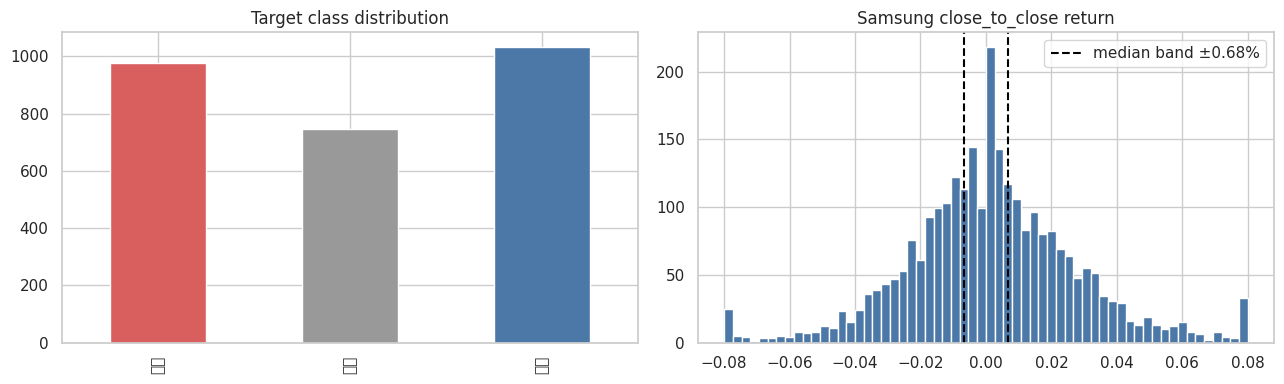

,fold,train_start,train_end,test_start,test_end
0,0,2016-01-04,2020-12-30,2021-01-04,2021-06-30
1,1,2016-07-01,2021-06-30,2021-07-01,2021-12-30
2,2,2017-01-02,2021-12-30,2022-01-04,2022-06-30
3,3,2017-07-03,2022-06-30,2022-07-01,2022-12-29
4,4,2018-01-02,2022-12-29,2023-01-02,2023-06-30
5,5,2018-07-02,2023-06-30,2023-07-03,2023-12-28
6,6,2019-01-02,2023-12-28,2024-01-02,2024-06-28
7,7,2019-07-01,2024-06-28,2024-07-01,2024-12-30
8,8,2020-01-02,2024-12-30,2025-01-02,2025-06-30
9,9,2020-07-01,2025-06-30,2025-07-01,2025-12-30


Tabular walk-forward:   0%|          | 0/12 [00:00<?, ?it/s]

,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier
model,,,,,,
Always flat,1359.0000,0.2737,0.3333,0.1433,1.0924,0.6628
Previous ensemble,1359.0000,0.4709,0.4580,0.4582,1.0199,0.6143
No macro ensemble,1359.0000,0.5004,0.4666,0.4327,1.0146,0.6085
No NSI ensemble,1359.0000,0.4982,0.4622,0.4202,1.0257,0.6162
No flow ensemble,1359.0000,0.4930,0.4570,0.4151,1.0173,0.6098
No macro price ensemble,1359.0000,0.4901,0.4540,0.4107,1.0248,0.6155
Logistic,1359.0000,0.4857,0.4500,0.4092,1.0540,0.6274
LightGBM,1359.0000,0.4915,0.4584,0.4244,1.0274,0.6168


RUN_TRANSFORMER=False 또는 torch 없음: Transformer 섹션을 건너뜁니다.
Mean ensemble = Logistic + LightGBM 확률의 단순 평균 (1359일)


,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier
model,,,,,,
Always flat,1359.0000,0.2737,0.3333,0.1433,1.0924,0.6628
Previous ensemble,1359.0000,0.4709,0.4580,0.4582,1.0199,0.6143
No macro ensemble,1359.0000,0.5004,0.4666,0.4327,1.0146,0.6085
No NSI ensemble,1359.0000,0.4982,0.4622,0.4202,1.0257,0.6162
No flow ensemble,1359.0000,0.4930,0.4570,0.4151,1.0173,0.6098
No macro price ensemble,1359.0000,0.4901,0.4540,0.4107,1.0248,0.6155
Logistic,1359.0000,0.4857,0.4500,0.4092,1.0540,0.6274
LightGBM,1359.0000,0.4915,0.4584,0.4244,1.0274,0.6168
Mean ensemble,1359.0000,0.4923,0.4561,0.4129,1.0261,0.6163


...

■ 외국인·기관 수급 추가 효과: Mean ensemble − No flow ensemble (같은 날짜, 같은 방법)
⚠️ log loss는 음수가 유리하며 CI가 0을 포함하면 동률입니다.


,metric,delta,lo,hi,n
0,accuracy,-0.000736,-0.012156,0.010816,1359
1,balanced_accuracy,-0.000896,-0.011851,0.010420,1359
2,log_loss,0.008852,0.003940,0.015088,1359


■ 유가·엔화 추가 효과: Mean ensemble − No macro price ensemble (같은 날짜, 같은 방법)
⚠️ 전일까지의 값만 씁니다. 장중에 반영되는 뉴스는 07:00 예측에 넣을 수 없습니다.


,metric,delta,lo,hi,n
0,accuracy,0.002208,-0.011558,0.015430,1359
1,balanced_accuracy,0.002138,-0.011161,0.015184,1359
2,log_loss,0.001352,-0.001550,0.004485,1359


<sk_hynix>:41: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
<sk_hynix>:41: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
<sk_hynix>:41: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
<sk_hynix>:41: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
<sk_hynix>:41: UserWarning: Glyph 44077 (\N{HANGUL SYLLABLE GAEB}) missing from font(s) DejaVu Sans.
<sk_hynix>:41: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
<sk_hynix>:41: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
<sk_hynix>:41: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
<sk_hynix>:41: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
<sk_hynix>:41: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu

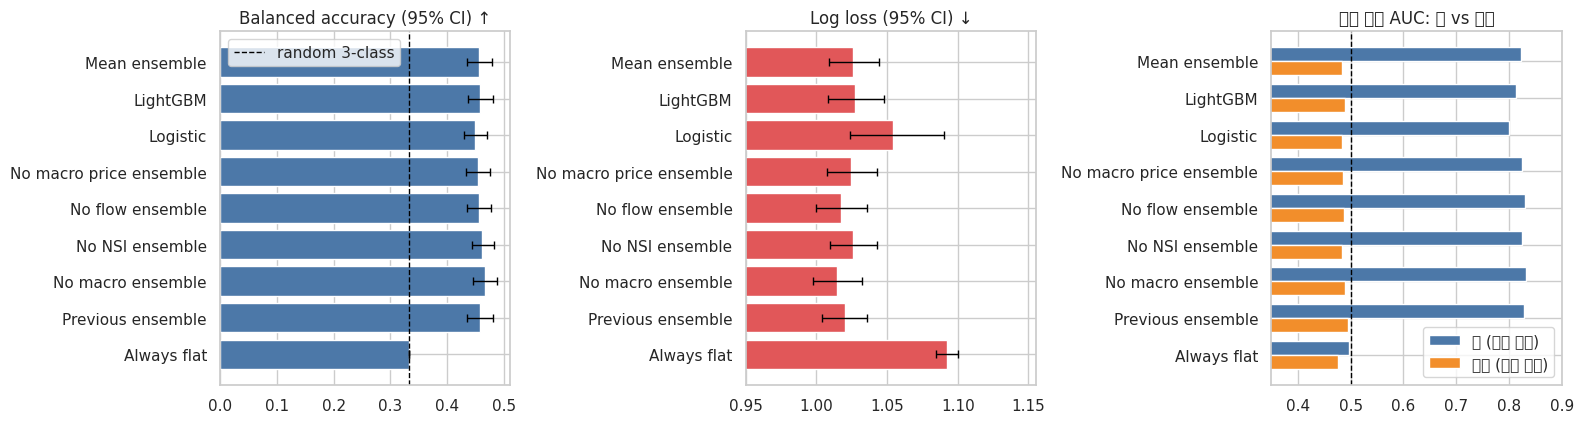

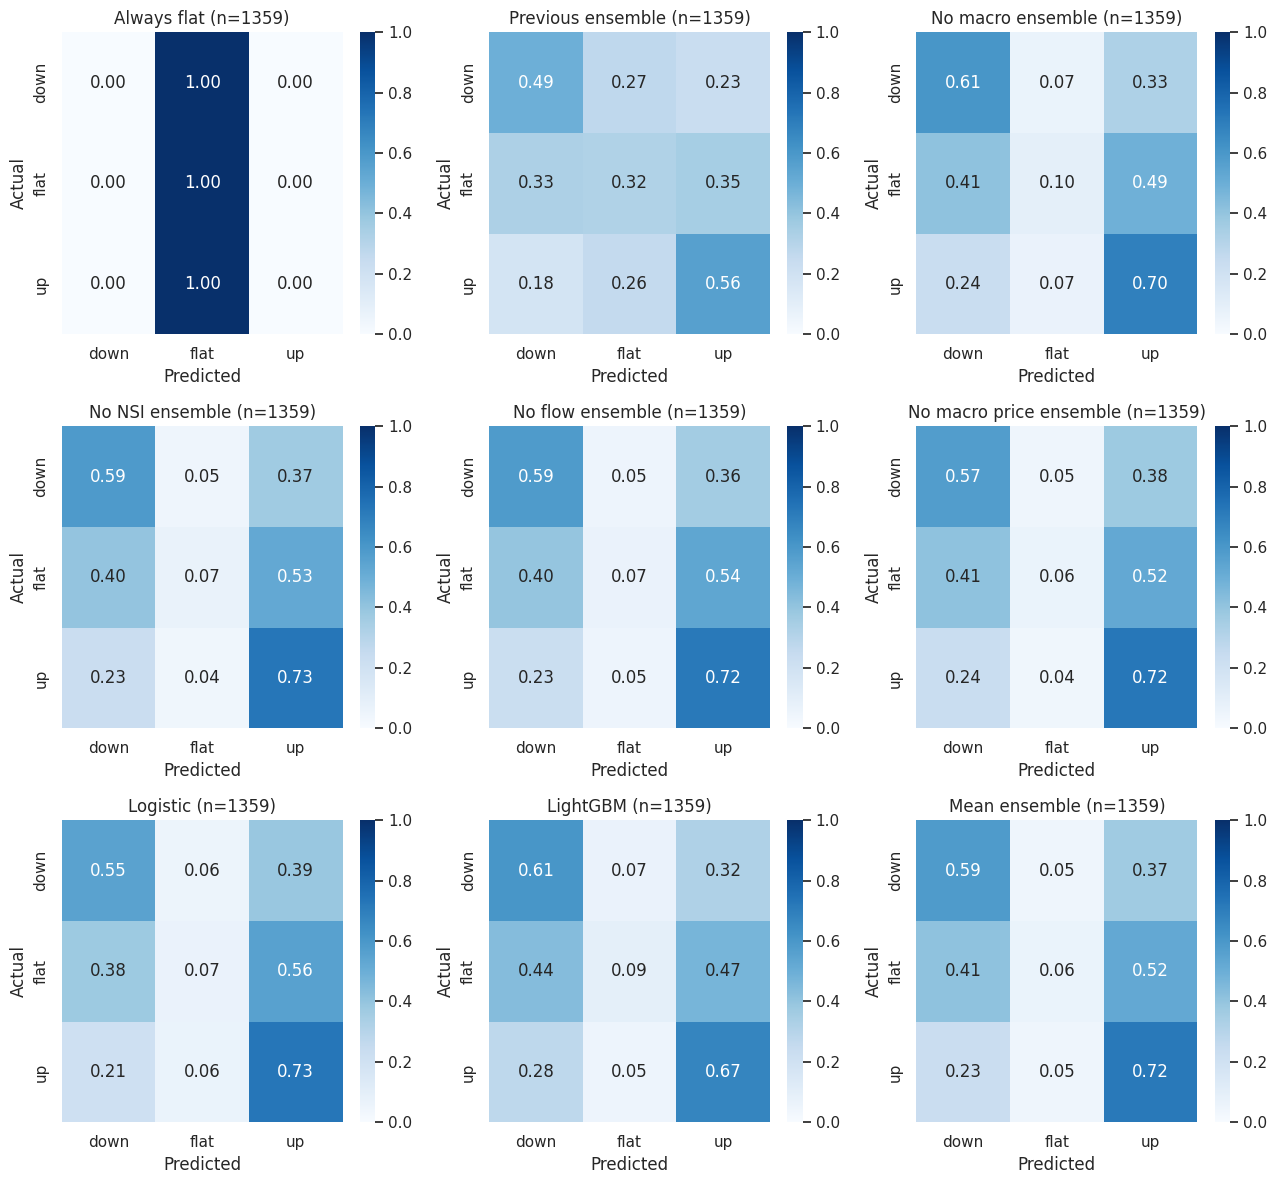

<sk_hynix>:32: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
<sk_hynix>:32: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
<sk_hynix>:32: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
<sk_hynix>:32: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
<sk_hynix>:32: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
<sk_hynix>:32: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
<sk_hynix>:32: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
<sk_hynix>:32: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
<sk_hynix>:32: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
<sk_hynix>:32: UserWarning: Glyph 46973 (\N{HANGUL SYLLABLE RAG}) missing from font(s) DejaVu Sans

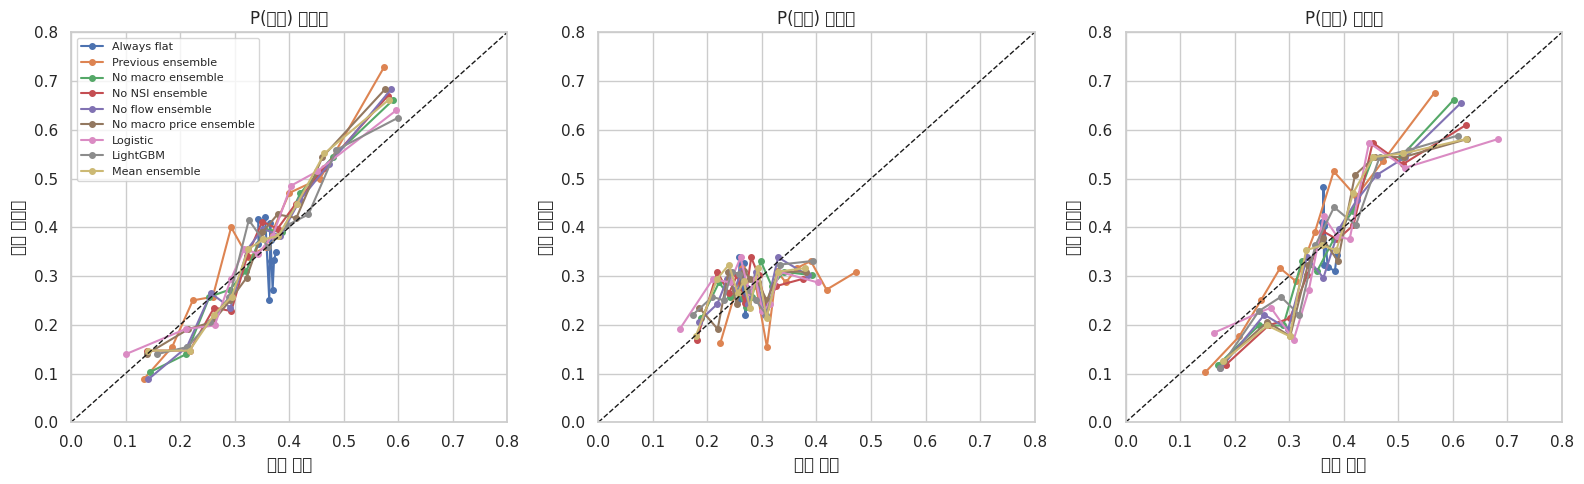

,mean_split_importance
micron_ret_1,152.666667
sam_ret_1,58.083333
sam_ret_2,52.583333
us10y_ret_1,43.083333
sam_vol_20,41.500000
kospi_ret_1,40.166667
sox_ret_1,39.750000
micron_ret_5,37.416667
sam_ret_5,32.750000
sam_range_1,32.166667


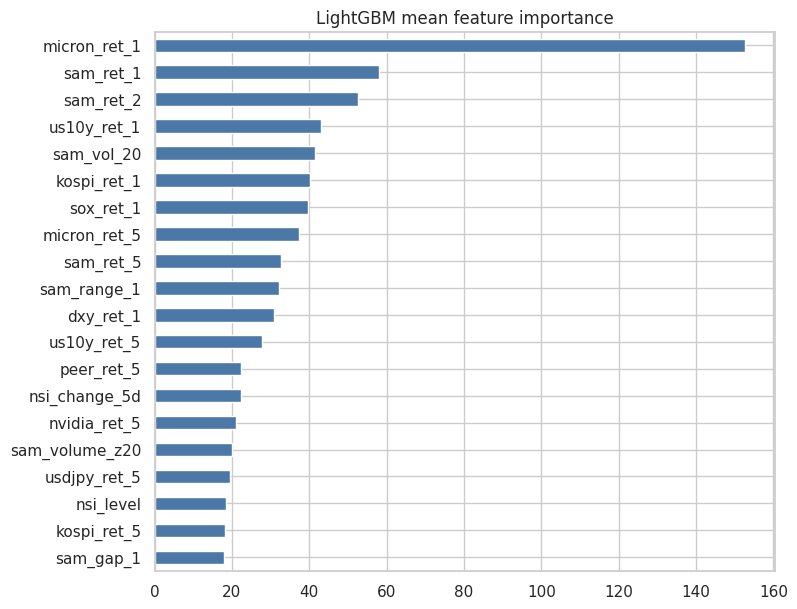

이벤트 표시: 미국지표:미국 소비자물가(CPI), 미국지표:미국 생산자물가(PPI)
앙상블 구성: ['Logistic', 'LightGBM'] (단순 평균)

[모델 구성 안내] 표에 없는 모델:
  · Transformer — RUN_TRANSFORMER=True 로 켜세요
  · Stacked / Performance-weighted ensemble — 제거됨. 검증에서 단순 평균보다 나빴습니다(1.0507 vs 1.0379)
⚠️ 이 예측의 타깃은 close_to_close 입니다. close_to_close라면 예측력의 대부분은 09:00 시가에 이미 반영되는 '갭'이며, 시가 진입 후 종가 청산으로 얻을 수 있는 몫은 8절의 session_bp 열을 보세요.


,prediction_date,prediction,p_down,p_flat,p_up
model,,,,,
Logistic,2026-09-14,상승,29.7%,27.6%,42.7%
LightGBM,2026-09-14,상승,22.3%,36.6%,41.1%
Mean ensemble,2026-09-14,상승,26.0%,32.1%,41.9%
No macro ensemble,2026-09-14,상승,24.8%,34.2%,41.0%
Candidate expanding,2026-09-14,상승,31.7%,30.8%,37.4%
No NSI ensemble,2026-09-14,상승,27.1%,31.3%,41.7%
No flow ensemble,2026-09-14,상승,27.0%,30.5%,42.5%
No macro price ensemble,2026-09-14,상승,26.0%,33.1%,40.9%


ℹ️ horizon=5: 신호 선택 구간에서 '가격 유지' 대비 MAE 차이 [-0.0007, +0.0002] — 상한이 0 아래로 내려가지 않아 점 예측을 내지 않습니다(기울기를 0으로 두어 현재가를 씁니다).
ℹ️ horizon=20: 신호 선택 구간에서 '가격 유지' 대비 MAE 차이 [-0.0035, +0.0010] — 상한이 0 아래로 내려가지 않아 점 예측을 내지 않습니다(기울기를 0으로 두어 현재가를 씁니다).
■ M07 관찰 후보(원장에만 기록): Candidate IV interval 1거래일 신호 있음, Candidate HAR interval 1주일 신호 없음, Candidate strict gate 1주일 신호 없음, Candidate IV interval 1주일 신호 없음, Candidate HAR interval 1개월 신호 없음, Candidate IV interval 1개월 신호 없음

■ 변동성 모형 비교 — 같은 행·같은 평가 구간에서, 적중률은 비슷하고 구간은 좁을수록 좋다


※ 발행에 사용한 변동성 모형: VOL_MODEL = "simple"
※ 목표 적중률 80%. 적중률이 크게 낮아지면서 구간만 좁아진 것은 개선이 아닙니다.

■ 종가예측 요약
  · 1거래일 뒤(2026-09-14): 1,828,422원 예상 (+0.91%), 명목 80% 구간 1,722,715~1,934,128원
  · 1주일 뒤(2026-09-18): 1,812,000원 (변화 없음) — 검증 미통과로 현재가를 그대로 씁니다, 명목 80% 구간 1,569,202~2,054,798원
  · 1개월 뒤(2026-10-15): 1,812,000원 (변화 없음) — 검증 미통과로 현재가를 그대로 씁니다, 명목 80% 구간 1,298,810~2,325,190원
※ 표의 predicted_return/predicted_close가 '—'인 것은 출력 오류가 아니라,
   신호 선택 구간에서 우위를 확인하지 못해 '예측하지 않음'으로 처리했다는 뜻입니다.
   그 경우 center_close(= 현재가)를 '변화 없음'으로 보고서에 표시하며,
   원장에는 예측을 내지 않았다는 사실이 남도록 계속 빈 값으로 기록합니다.
※ 구간은 변동성 밴드이며 band_coverage는 독립 평가 구간의 적중률입니다. target_date는 KRX 거래일 기준입니다.
※ 1거래일 종가예측이 게이트를 통과하는 것은 거의 전부 '전일 종가→시가 갭' 덕분입니다(8절 갭 AUC ≈ 0.8, 세션 AUC ≈ 0.5). 갭은 아래 '시초가예측'이 따로 예측합니다.


,trading_days,as_of_date,target_date,signal,vol_model,current_close,predicted_return,predicted_close,center_close,low_close,high_close,band_coverage,model_mae,zero_baseline_mae,mae_diff_lo,mae_diff_hi,oof_slope
horizon,,,,,,,,,,,,,,,,,
1거래일,1,2026-09-11,2026-09-14,있음,simple,"1,812,000원",+0.91%,"1,828,422원","1,828,422원","1,722,715원","1,934,128원",79.9%,3.04%,3.34%,-0.0040,-0.0020,1.000
1주일,5,2026-09-11,2026-09-18,없음,simple,"1,812,000원",—,—,"1,812,000원","1,569,202원","2,054,798원",74.9%,7.62%,7.88%,+0.0000,+0.0000,0.000
1개월,20,2026-09-11,2026-10-15,없음,simple,"1,812,000원",—,—,"1,812,000원","1,298,810원","2,325,190원",66.5%,19.96%,20.04%,+0.0000,+0.0000,0.000


...

,trading_days,target_date,signal,current_close,predicted_return,predicted_open,center_open,low_open,high_open,band_coverage,model_mae,zero_baseline_mae,mae_diff_lo,mae_diff_hi,oof_slope,gap_sign_auc,gap_corr
horizon,,,,,,,,,,,,,,,,,
시초가예측,1,2026-09-14,있음,"1,812,000원",+1.68%,"1,842,502원","1,842,502원","1,764,167원","1,920,837원",82.6%,1.72%,2.30%,-0.0074,-0.0043,1.000,0.810,0.634


■ 아직 채점된 사전 예측이 없습니다. 첫 예측일 다음 실행부터 실제값과 대조됩니다.
■ 일별 예측/실제값 비교 (미래 날짜는 pending, 오차 = 예측 - 실제)


,schema_version,run_id,created_at_utc,runtime,versions_hash,prediction_date,as_of_date,data_snapshot_hash,config_hash,target_mode,...,absolute_price_error,price_ape,return_error,interval_hit,center_price_error,log_loss,brier,status,is_prospective,actual_updated_at_utc
0,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00
15,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00
14,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00
13,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00
12,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00
11,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00
10,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00
9,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00
8,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00
7,3,20260911T230442_bc6154b8f063,2026-09-11 23:05:08.007959+00:00,colab,c641f7cbc9ea,2026-09-14,2026-09-11,8c549e3ed05a7017d72f,53c9db3770b61e827785,close_to_close,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending,True,2026-09-11T23:05:08.012656+00:00


전체 실행 기록: /content/sk_hynix_outputs/forecast_log.csv
일별 비교: /content/sk_hynix_outputs/daily_forecast_comparison.csv
Saved: /content/sk_hynix_outputs/latest_outputs.zip | run_id: 20260911T230442_bc6154b8f063
ℹ️ GITHUB_TOKEN이 없어 참고자료 보관본을 갱신하지 않습니다.
기여도 기록: 5개 특징 → attribution.csv


보고서 HTML 저장: /content/sk_hynix_outputs/report.html
ℹ️ Pages 발행을 건너뜁니다 — colab 실행은 기본적으로 발행하지 않습니다 — 올리려면 PREDICT_STOCK_PUBLISH=true
   report.html을 내려받아 브라우저에서 열 수 있습니다.
Transformer가 이 실행에 없어 실험 기록을 남기지 않습니다.

■ 재실행 완료: ['sk_hynix']
   노트북 변수에는 마지막 종목의 결과가 남아 있습니다.
   각 종목 결과는 저장 폴더와 보고서에서 확인하세요.

■ 종목별 발행 결과
  [SKIP] samsung    건너뜀     colab 실행은 기본적으로 발행하지 않습니다 — 올리려면 PREDICT_STOCK_PUBLISH=true
  [SKIP] sk_hynix   건너뜀     colab 실행은 기본적으로 발행하지 않습니다 — 올리려면 PREDICT_STOCK_PUBLISH=true

  ⚠️ 발행되지 않은 종목: ['samsung', 'sk_hynix']
     그 종목의 보고서는 이전 실행 결과 그대로 남아 있습니다.
     위 출력에서 해당 종목 구간의 경고를 확인하세요.


In [27]:
# 첫 종목은 위에서 이미 끝났다. 나머지를 같은 코드로 이어서 실행한다.
_remaining = list(RUN_TARGETS[1:])
if not _remaining:
    print("RUN_TARGETS에 종목이 하나뿐입니다. 추가 실행 없음.")
else:
    try:
        _history = list(In)          # IPython이 보관한 실행 셀 원문
    except NameError:
        _history = []
    _start = next((i for i, s in enumerate(_history) if "RUN_TARGETS = [" in s and "TARGET_SPEC" in s), None)
    _end = next((i for i, s in enumerate(_history) if "== transformer-experiment ==" in s), None)

    if _start is None or _end is None or _end <= _start:
        print("⚠️ 실행 히스토리에서 파이프라인 구간을 찾지 못해 추가 종목을 건너뜁니다.")
        print("   위 셀들을 순서대로 실행한 뒤 이 셀을 실행하세요"
              " (런타임 → 모두 실행이면 자동으로 충족됩니다).")
    else:
        _block = _history[_start:_end + 1]
        print(f"이어서 실행할 종목: {_remaining} (셀 {len(_block)}개 재실행)\n")
        for _t in _remaining:
            print("=" * 78)
            print(f"■ {_t} 실행 시작")
            print("=" * 78, flush=True)
            for _src in _block:
                # 매직(%%capture, !pip)은 재실행에서 제외한다.
                _code = "\n".join(l for l in _src.splitlines()
                                   if not l.lstrip().startswith(("%", "!")))
                _code = _code.replace("TARGET = RUN_TARGETS[0]", f'TARGET = "{_t}"')
                if not _code.strip():
                    continue
                exec(compile(_code, f"<{_t}>", "exec"), globals())
        print("\n" + "=" * 78)
        print(f"■ 재실행 완료: {_remaining}")
        print("   노트북 변수에는 마지막 종목의 결과가 남아 있습니다.")
        print("   각 종목 결과는 저장 폴더와 보고서에서 확인하세요.")
        print("=" * 78)


# ---- 종목별 발행 결과 -------------------------------------------------------
# 출력이 수백 줄이라 중간 경고는 묻힌다. 무엇이 실제로 발행됐는지 맨 마지막에
# 다시 모아 둔다. 여기만 보면 한 종목이 빠졌는지 바로 알 수 있다.
_done = globals().get("PUBLISH_STATUS", {})
print("\n" + "=" * 78)
print("■ 종목별 발행 결과")
print("=" * 78)
_marks = {"발행됨": "OK  ", "건너뜀": "SKIP", "실패": "FAIL",
          "일부 실패": "PART", "실행 안 됨": "MISS"}
_bad = []
for _t in RUN_TARGETS:
    _state, _detail = _done.get(_t, ("실행 안 됨", "이 실행에서 처리되지 않았습니다"))
    print(f"  [{_marks.get(_state, '?   ')}] {_t:<10} {_state:<7} {_detail}")
    if _state != "발행됨":
        _bad.append(_t)
if _bad:
    print()
    print(f"  ⚠️ 발행되지 않은 종목: {_bad}")
    print("     그 종목의 보고서는 이전 실행 결과 그대로 남아 있습니다.")
    print("     위 출력에서 해당 종목 구간의 경고를 확인하세요.")
print("=" * 78)

# 자동 실행에서는 발행 '실패'를 실행 실패로 만든다. 그러지 않으면 원장이 저장되지 않았는데도
# Actions 가 초록불로 끝나고, 그날 예측이 사라진 것을 아무도 모른다.
# '건너뜀'(발행을 끄고 돌린 경우)은 실패가 아니다 — 그건 의도한 동작이다.
# 사람이 돌리는 Colab 에서는 경고만 남기고 결과를 볼 수 있게 둔다.
# '실행 안 됨'은 이 실행이 그 종목을 다루지 않았다는 뜻이라(단일 종목 실행·테스트 등) 실패가
# 아니다. 실제로 올리려다 실패한 것만 실행 실패로 만든다.
_failed = [t for t in _bad if _done.get(t, ("", ""))[0] in ("실패", "일부 실패")]
if PUBLISH_FAILURES and RUNTIME != "colab":
    raise RuntimeError(
        "발행에 실패한 종목이 있습니다: "
        + "; ".join(PUBLISH_FAILURES)
        + " — 위 출력의 해당 구간을 확인하세요.")